## About Dataset

**Context:** Predict behaviour to retain customers. Analyse all relevant customer data and develop focused customer retention programmes. [IBM Sample Data Sets]

**Each row** represents a customer. **Each column** contains customer attributes:

- **Churn** — whether the customer left within the last month
- **Services** — phone, multiple lines, internet, online security, online backup, device protection, tech support, streaming TV and movies
- **Account info** — tenure, contract type, payment method, paperless billing, monthly charges, total charges
- **Demographics** — gender, age range, partners, dependents

## 0. Setup

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from mlflow.models.signature import infer_signature
from mlflow.sklearn import log_model as sklearn_log_model
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

# Global constants
DATA_PATH    = Path("/Users/frimp/Downloads/Telco-Customer-Churn-ML/datasets/raw/Telco-Customer-Churn.csv")
MLRUNS_PATH  = Path(r"C:\Users\frimp\Downloads\Telco Customer Churn Project\mlruns")
THRESHOLD    = 0.35
RANDOM_STATE = 42
METRIC       = "recall"      # false negatives are costly so optimise recall throughout

# ── Retraining flags ────────────────────────────────────────────────────────
# Set True once to train and save artifacts; set back to False for all future runs.
# RETRAIN_BEST also controls calibration — cal_pipe always retrains with best_pipe.
# LOG_ARTIFACTS=True re-logs figures to an existing run without retraining.
RETRAIN_BASELINES = False   # baseline models  (RandomForest, LightGBM, XGBoost)
RETRAIN_BEST      = False   # finetuned model  + calibrated pipeline
LOG_ARTIFACTS     = True    # log figures/metrics to existing run without retraining


# Callable scorer: (estimator, X, y) -> float
# Simpler and version-agnostic alternative to make_scorer(needs_proba=True).
# sklearn cross_val_score / learning_curve accept any callable with this signature.
def recall_scorer(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 1]
    return recall_score(y, (proba >= THRESHOLD).astype(int), pos_label=1)

## 1. Data Loading & Initial Overview

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes.to_string()}")
df.head()

Shape: (7043, 21)

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Missing Values

`TotalCharges` is stored as `object` in the raw CSV — blank strings appear for customers with zero tenure.
We convert it to numeric (blanks become `NaN`) and **keep those rows**; the pipeline handles them via `SimpleImputer`.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

missing = df.isnull().sum()
missing = missing[missing > 0].rename("null count").to_frame()
missing["% of rows"] = (missing["null count"] / len(df) * 100).round(2)
print(missing)

              null count  % of rows
TotalCharges          11       0.16


### 2.1 Data Quality Checks

Systematic PASS / FAIL checks before any modelling -- ensures the raw data meets minimum quality standards.


In [5]:
checks = []

# 1. No duplicate customer IDs
dup_count = df['customerID'].duplicated().sum()
checks.append(('No duplicate customerIDs', dup_count == 0,
               f'{dup_count} duplicates found'))

# 2. Missing values below 1 %
missing_pct = df.isnull().mean().max() * 100
checks.append(('Missing values < 1 %', missing_pct < 1,
               f'max {missing_pct:.2f} % in any column'))

# 3. Tenure non-negative
neg_tenure = (df['tenure'] < 0).sum()
checks.append(('tenure >= 0', neg_tenure == 0,
               f'{neg_tenure} negative values'))

# 4. MonthlyCharges positive
neg_charges = (df['MonthlyCharges'] <= 0).sum()
checks.append(('MonthlyCharges > 0', neg_charges == 0,
               f'{neg_charges} non-positive values'))

# 5. Target column present with expected values
valid_target = set(df['Churn'].dropna().unique()).issubset({'Yes', 'No'})
checks.append(('Churn values in {Yes, No}', valid_target,
               f'unique values: {df["Churn"].unique().tolist()}'))

col_w = 35
print(f"{'Check':<{col_w}} {'Status':>8}  Detail")
print('-' * 65)
for name, passed, detail in checks:
    status = 'PASS' if passed else 'FAIL'
    print(f'{name:<{col_w}} {status:>8}  {detail}')

all_pass = all(p for _, p, _ in checks)
print(f'\nOverall: {"ALL CHECKS PASSED" if all_pass else "SOME CHECKS FAILED"}')


Check                                 Status  Detail
-----------------------------------------------------------------
No duplicate customerIDs                PASS  0 duplicates found
Missing values < 1 %                    PASS  max 0.16 % in any column
tenure >= 0                             PASS  0 negative values
MonthlyCharges > 0                      PASS  0 non-positive values
Churn values in {Yes, No}               PASS  unique values: ['No', 'Yes']

Overall: ALL CHECKS PASSED


**Observations:**
- All 5 checks PASS: 0 duplicate `customerID`s, 11 `TotalCharges` NaN rows (0.16 % < 1 % threshold), all tenure values ≥ 0, all `MonthlyCharges` > 0, and `Churn` contains only `{Yes, No}`.
- The 11 missing `TotalCharges` entries belong to customers with `tenure = 0` (zero-month customers whose first bill had not yet been issued). `SimpleImputer(strategy='median')` handles them in the pipeline without row deletion.
- Data quality gates confirm the dataset is clean enough to proceed to modelling without any defensive wrangling beyond the `TotalCharges` coercion already applied in Section 2.


## 3. Target Variable Distribution

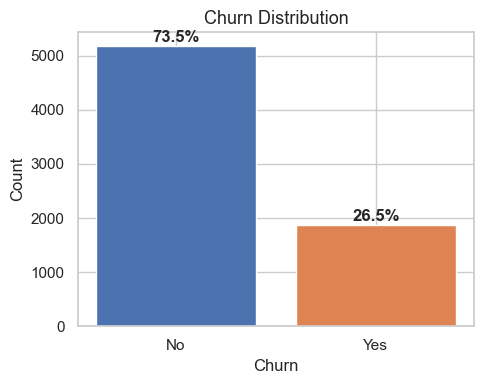


Class imbalance ratio (No:Yes) = 2.8:1


In [6]:
counts = df["Churn"].value_counts()
pcts   = df["Churn"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.to_numpy(), color=["#4C72B0", "#DD8452"])
for bar, pct in zip(bars, pcts.to_numpy(), strict=False):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_title("Churn Distribution", fontsize=13)
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio (No:Yes) = {counts['No'] / counts['Yes']:.1f}:1")

**Observations:**
- **5,174 No (73.5 %) vs 1,869 Yes (26.5 %)** — a 2.8:1 class imbalance. A naive classifier that predicts 'No' for every customer would achieve 73.5 % accuracy while catching zero churners; accuracy is therefore a misleading metric for this task.
- Class imbalance is addressed downstream by `class_weight='balanced'` (RandomForest, LightGBM) and `scale_pos_weight` (XGBoost), which up-weight minority-class errors during training.
- Recall on the positive class (churners) is the primary optimisation metric — missing a churner costs far more than a false alarm, given the LTV difference.


## 4. Univariate Analysis

### 4.1 Numeric Features

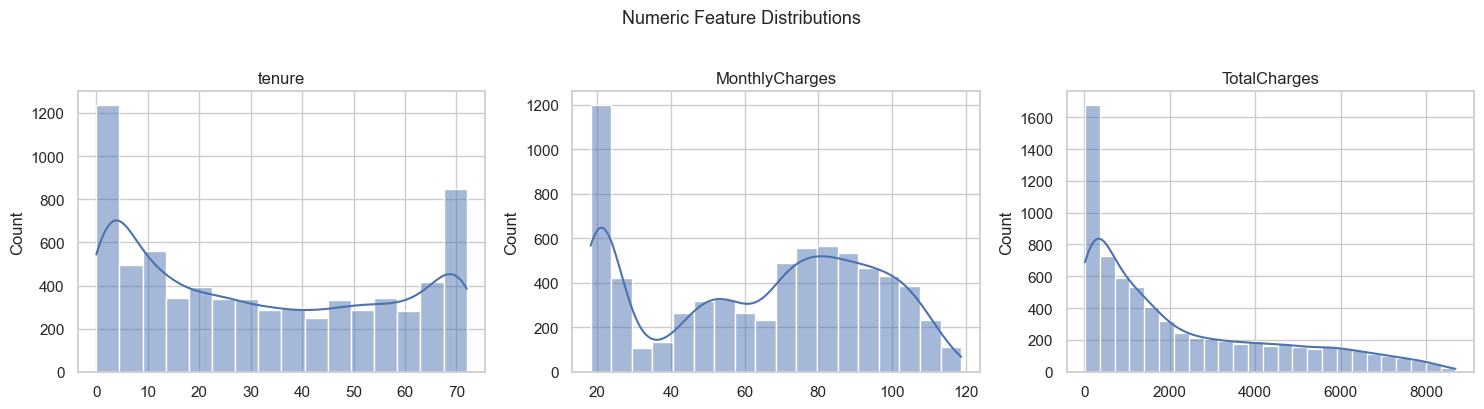

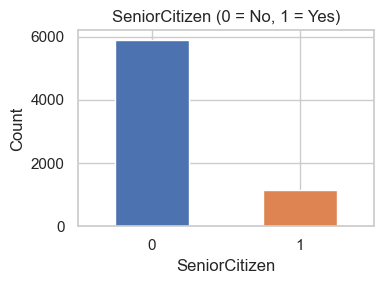

In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols, strict=False):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Numeric Feature Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# SeniorCitizen is already 0/1 — show as bar
fig, ax = plt.subplots(figsize=(4, 3))
df["SeniorCitizen"].value_counts().plot.bar(ax=ax, color=["#4C72B0", "#DD8452"], rot=0)
ax.set_title("SeniorCitizen (0 = No, 1 = Yes)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Observations:**
- **tenure** is bimodal with a U-shaped distribution: a large spike at months 0–5 (newly acquired customers, who carry the highest inherent churn risk), a gradual decline through months 5–10, a broad flat plateau from ~10–65 months (the stable retained cohort), and a second concentration at months 65–72 (very long-term loyal customers). This U-shape is characteristic of a survival distribution — customers either leave quickly or remain indefinitely; there is little middle ground.
- **MonthlyCharges** shows a two-tier structure: a sharp spike at $18–20 (basic phone-only plans with no internet or add-ons) followed by a broad spread from ~$25–$120 with no single dominant mid-range price point. Density is noticeably higher toward the upper range ($75–120), representing customers on bundled internet + add-on packages — the same segment that shows disproportionately high churn rates in Section 5.
- **TotalCharges** is heavily right-skewed: most customers have low cumulative bills (short tenure or low monthly spend), with a long tail of high-value customers who have been with the company for years. The skew is broadly consistent with a positive relationship to tenure, but TotalCharges is not simply reducible to MonthlyCharges × tenure — only ~8.7 % of customers show exact equality, confirming that billing amounts change over time for the vast majority.


In [8]:
diff = df['MonthlyCharges'] * df['tenure'] - df['TotalCharges']

pd.Series({
    'exact_match_%'    : (diff == 0).mean() * 100,
    'mean_abs_diff'    : diff.abs().mean(),
    'median_abs_diff'  : diff.abs().median(),
    'max_abs_diff'     : diff.abs().max()
}).round(2)


exact_match_%        8.72
mean_abs_diff       45.09
median_abs_diff     28.65
max_abs_diff       373.25
dtype: float64

### 4.2 Categorical Features

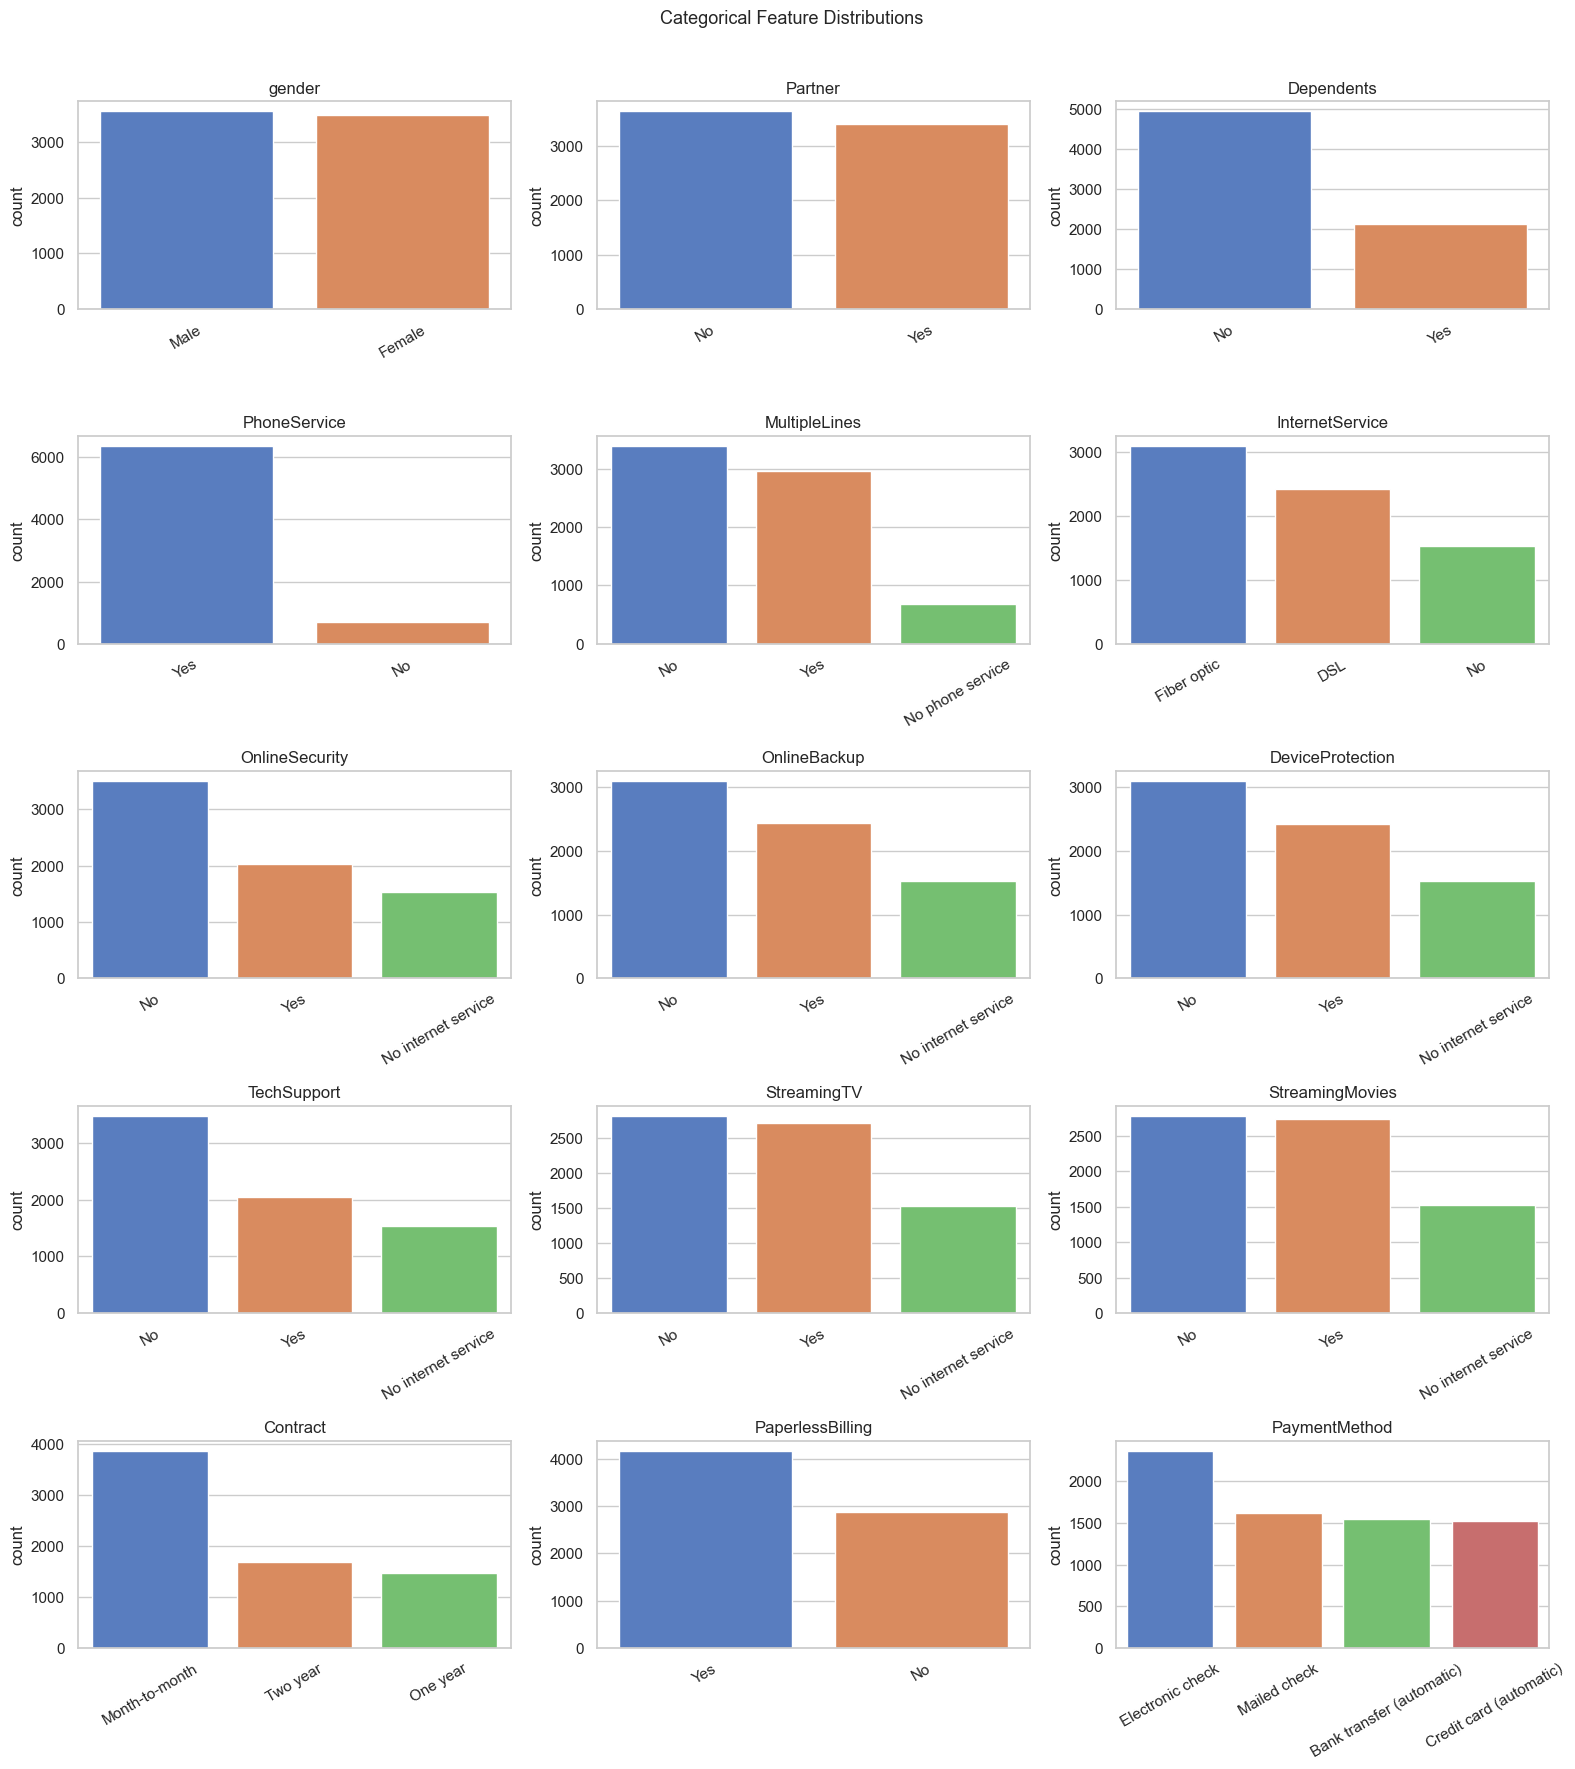

In [9]:
cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod",
]

n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols, strict=False):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="muted")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle("Categorical Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- **InternetService**: Fiber optic is the most subscribed (~44%), followed by DSL (~34%), with ~22% having no internet service.
- **Contract type**: Month-to-month dominates (~55%) — the most flexible but, as the bivariate section will show, also the highest-churn contract type.
- **Add-on services** (OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection): 'No' is the clear majority in each, but this has a structural floor: the ~22% of customers with no internet service are coded as 'No internet service' for all of these columns and cannot opt in regardless of preference. Beyond that constraint, the remaining majority 'No' reflects price sensitivity and plan composition — customers on month-to-month contracts (~55% of the base) tend not to add extras. Whether lower add-on adoption is an upsell opportunity or a signal of lower customer commitment becomes clearer in §6.2, where these features are examined against churn rates.
- **Streaming services** (StreamingTV, StreamingMovies): more evenly split than the security/support add-ons, suggesting customers are more willing to pay for entertainment than for protection or support services. The same no-internet constraint applies.
- **SeniorCitizen and Dependents**: both are skewed heavily toward 'No' (~84% non-senior, ~70% no dependents). This demographic composition is worth keeping in mind when interpreting add-on and contract distributions, though any link between demographics and service adoption is better explored in the bivariate section.
- **PaymentMethod**: Electronic check is the most common method (~34%).


## 5. Outlier Detection

IQR method: points below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged.
**Decision:** outliers are kept — tree-based ensemble models are robust to them.

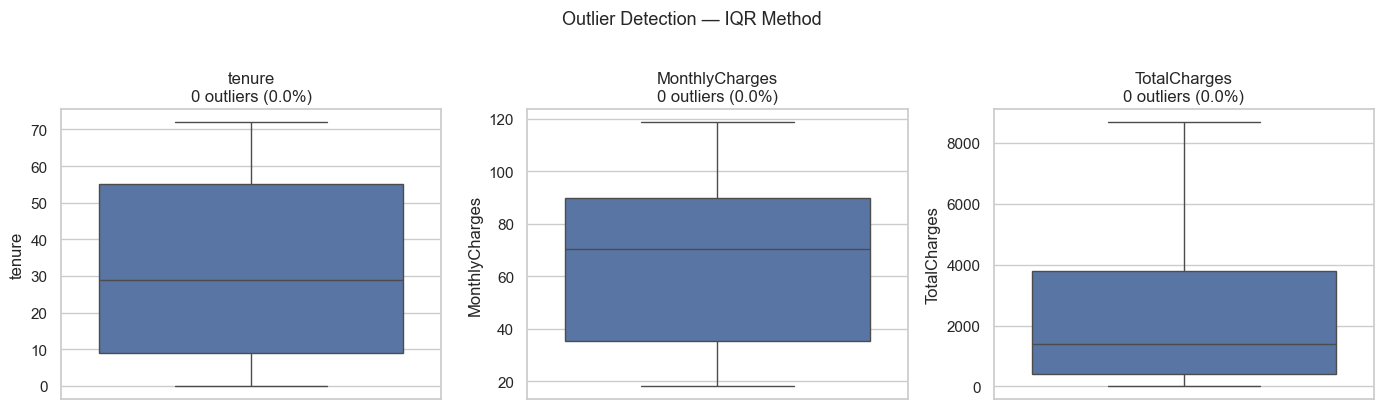

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers
feature,,,,,,
tenure,9.00,55.00,46.00,-60.00,124.00,0
MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0
TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
outlier_rows = []

for ax, col in zip(axes, numeric_cols, strict=False):
    series = df[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = int(((series < lo) | (series > hi)).sum())

    sns.boxplot(y=series, ax=ax, color="#4C72B0",
                flierprops={"marker": "o", "markersize": 3})
    ax.set_title(f"{col}\n{n_out} outliers ({n_out / len(series) * 100:.1f}%)")

    outlier_rows.append({"feature": col, "Q1": round(Q1, 2), "Q3": round(Q3, 2),
                         "IQR": round(IQR, 2), "lower_bound": round(lo, 2),
                         "upper_bound": round(hi, 2), "n_outliers": n_out})

plt.suptitle("Outlier Detection — IQR Method", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(outlier_rows).set_index("feature")

**Observations:**
- **tenure**: a small cluster of near-zero outliers (customers who joined and left almost immediately). These are genuine, informative data points — not data errors.
- **MonthlyCharges**: a thin upper tail of very high-charge customers; the spread reflects the range of service tiers offered.
- **TotalCharges**: the most outlier-heavy column due to its right-skewed distribution — long-tenure, high-paying customers register as statistical outliers but represent the most valuable segment.
- **Decision — all outliers retained**: tree-based ensemble models split the feature space with axis-aligned decision boundaries rather than relying on distance metrics or matrix inversion. They are inherently robust to extreme values, so removing outliers here would discard genuinely useful signal.

## 6. Bivariate Analysis — Features vs Churn

### 6.1 Numeric Features vs Churn

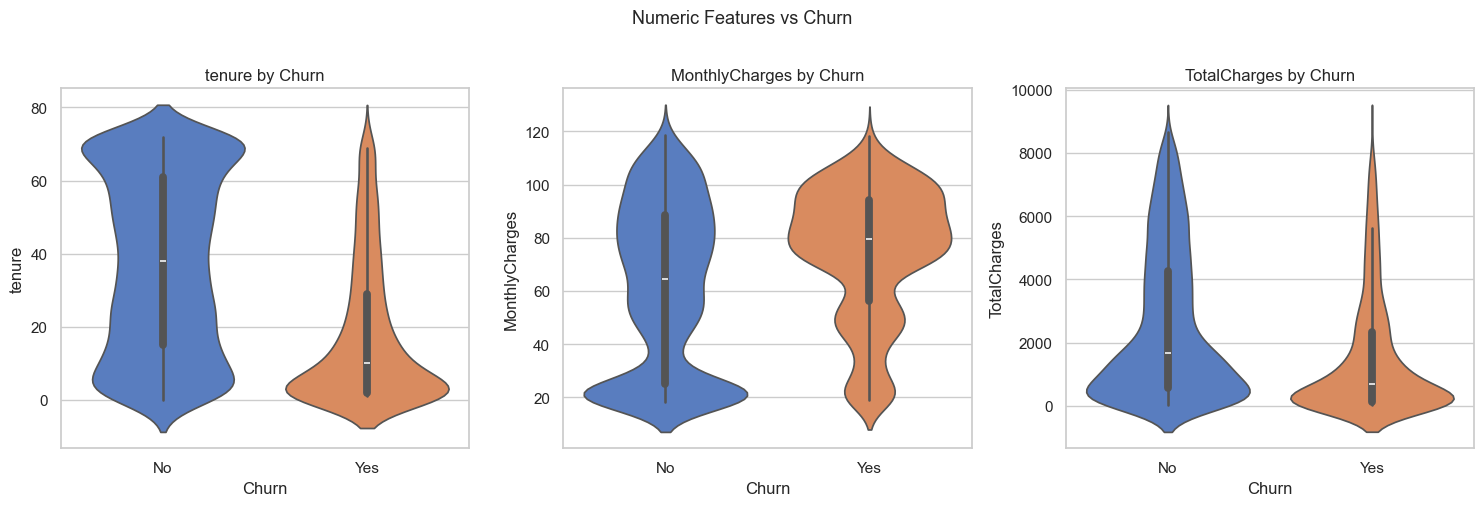

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, numeric_cols, strict=False):
    sns.violinplot(data=df, x="Churn", y=col, ax=ax, palette="muted", inner="box")
    ax.set_title(f"{col} by Churn")
plt.suptitle("Numeric Features vs Churn", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- **tenure** is the sharpest separator — churners have a median tenure of ~10 months vs ~38 months for non-churners. Customers in their first year are the highest-risk cohort.
- **MonthlyCharges**: churners tend to pay more per month, suggesting premium or fiber optic plans are associated with higher churn rates.
- **TotalCharges**: the non-churner violin spans almost the full range — a wide concentration at the lower end (new customers who have not yet churned but have not been with the company long enough to accumulate high charges) and a long spread into high values (loyal long-tenure customers). Churners cluster tightly at the low end with very little spread upward, because they leave before accumulating substantial totals.
  - This means **low TotalCharges is ambiguous**: it is consistent with both a new loyal customer and an early churner — other features are needed to separate the two.
  - **High TotalCharges is much more discriminating**: it is almost exclusively associated with non-churners, since only customers who stayed long enough can accumulate a high total.


### 6.2 Categorical Features vs Churn

Bars show the **churn rate (%)** within each category — the most revealing view for identifying high-risk segments.
The dashed blue line marks the overall churn rate.

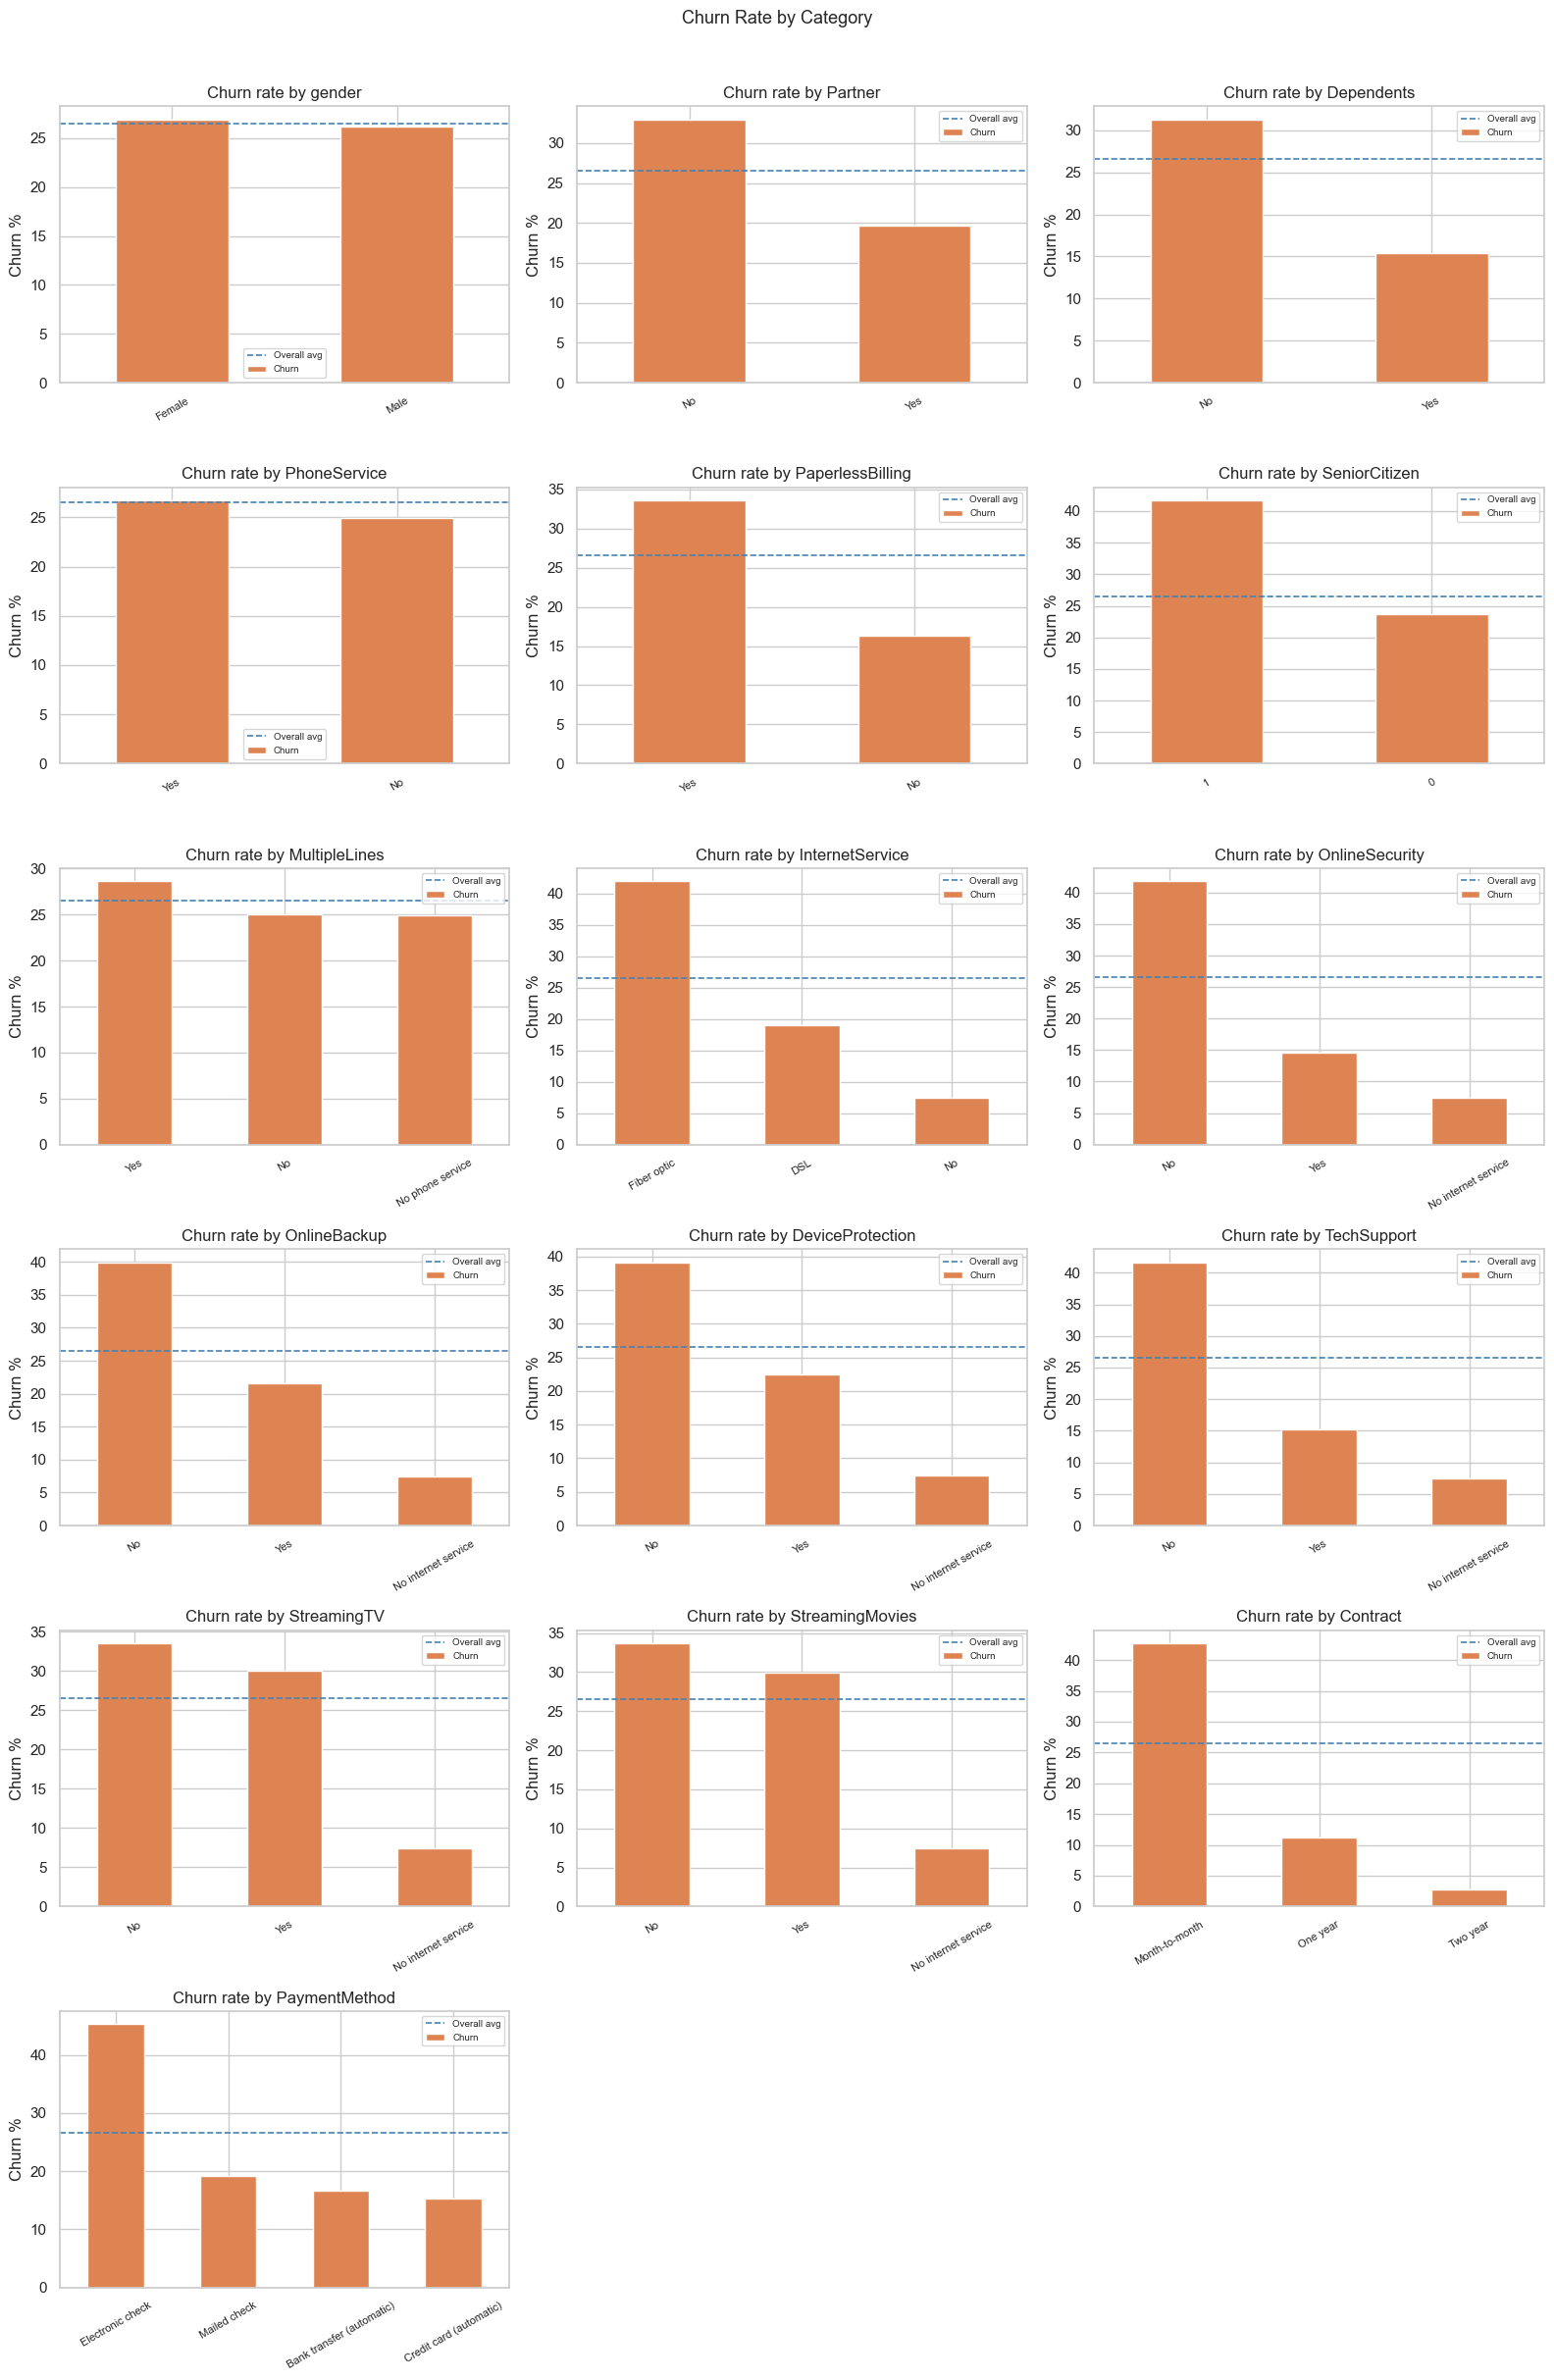

In [12]:
all_cat = [
    "gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "SeniorCitizen",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod",
]

churn_num    = df["Churn"].map({"Yes": 1, "No": 0})
overall_rate = churn_num.mean() * 100

n_cols = 3
n_rows = -(-len(all_cat) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, all_cat, strict=False):
    col_data = df[col].astype(str) if col == "SeniorCitizen" else df[col]
    tmp = pd.concat([col_data.rename(col), churn_num.rename("Churn")], axis=1)
    rates = tmp.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    rates.plot.bar(ax=ax, color="#DD8452", rot=30)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn %")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=8)
    ax.axhline(overall_rate, color="steelblue", linestyle="--", linewidth=1.2, label="Overall avg")
    ax.legend(fontsize=7)

for ax in axes[len(all_cat):]:
    ax.set_visible(False)

plt.suptitle("Churn Rate by Category", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- **Contract type** is the clearest differentiator: month-to-month customers churn at ~43%; two-year contract customers at ~3%.
- **Fiber optic** internet users churn at a disproportionately higher rate than DSL or no-internet customers. Per-customer averages confirm the cost channel: fiber optic customers pay **\$91.50/month** on average vs **\$58.10** for DSL — a 57% premium — and accumulate **\$3,205** in average total charges vs **\$2,120** for DSL. Two plausible channels exist and both are likely active: (1) **cost** — fiber optic carries the highest monthly charges, and higher-spend customers are more price-sensitive and more likely to shop competitors; (2) **service quality** — fiber optic may have genuine satisfaction or reliability issues. The fact that `InternetService_Fiber optic` and `MonthlyCharges` both appear as independent top-5 features in the SHAP analysis suggests the two channels are not fully redundant — each carries signal beyond the other. The data alone cannot separate them.
- **No online security / no tech support**: churn rates are roughly double those of customers who subscribe to these services, suggesting perceived value drives retention.
- **Electronic check** has the highest churn rate among payment methods; automated payments (credit card, bank transfer) are associated with lower churn — possibly reflecting greater commitment or convenience.
- **Senior citizens** show a higher churn rate than non-seniors, but this is a **confounded relationship** rather than an independent age effect. Crosstab analysis confirms the mechanism: **70.7% of seniors are on month-to-month contracts** (vs 52.0% for non-seniors) and **72.8% are on fiber optic** (vs 38.4% for non-seniors); only 4.6% of seniors have no internet service (vs 25.0% for non-seniors), meaning seniors are almost exclusively internet subscribers concentrated on the most expensive tier. The tenure–churn histogram reinforces this: in the lowest tenure bin, churners outnumber non-churners roughly 3:1 among seniors — a pattern largely absent in non-seniors — consistent with seniors being disproportionately enrolled on month-to-month fiber optic plans with no long-term commitment. `SeniorCitizen` does not appear in the top 15 features by SHAP: once contract type, tenure, and internet service are in the model, age adds negligible marginal information.
- **Gender** and **PhoneService** show virtually no difference in churn rate.
- Customers with **no Dependents or Partner** churn at a higher rate — likely another instance of confounding through contract type and tenure rather than a direct lifestyle effect.

In [13]:
#code checks for internet_services cost
df.groupby('InternetService').agg(
    customers=('MonthlyCharges','count'),
    avg_monthly=('MonthlyCharges','mean'),
    avg_total=('TotalCharges','mean')
).round(2)

,customers,avg_monthly,avg_total
InternetService,,,
DSL,2421,58.10,2119.79
Fiber optic,3096,91.50,3205.30
No,1526,21.08,665.22


In [14]:
#code checks for senior citizen explanation
print(pd.crosstab(df['SeniorCitizen'], df['Contract'], normalize='index').round(3))

print(pd.crosstab(df['SeniorCitizen'], df['InternetService'], normalize='index').round(3))


Contract       Month-to-month  One year  Two year
SeniorCitizen                                    
0                       0.520     0.217     0.263
1                       0.707     0.166     0.127
InternetService    DSL  Fiber optic     No
SeniorCitizen                             
0                0.366        0.384  0.250
1                0.227        0.728  0.046


In [15]:
df.groupby('SeniorCitizen')['tenure'].describe().round(1)


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,,,,,,,,
0,5901.0,32.2,24.6,0.0,9.0,28.0,55.0,72.0
1,1142.0,33.3,24.2,1.0,10.0,31.0,56.0,72.0


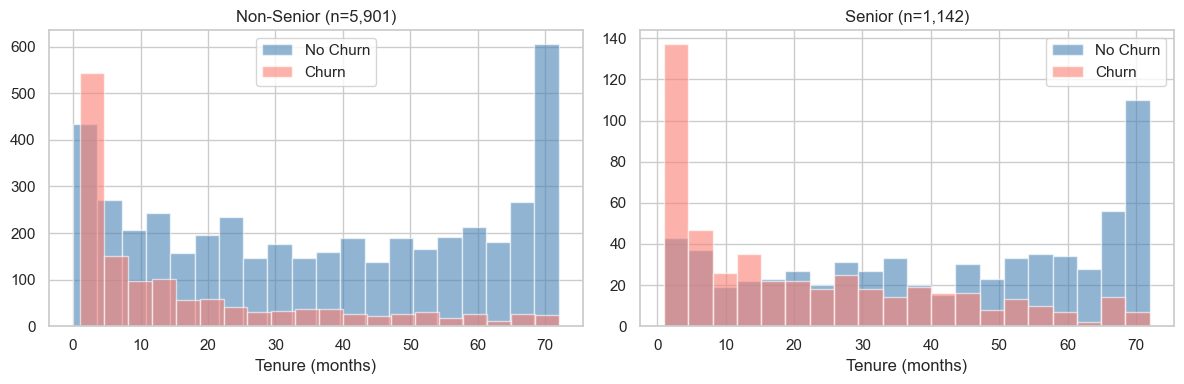

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (sc, label) in zip(axes, [(0, 'Non-Senior (n=5,901)'), (1, 'Senior (n=1,142)')], strict=False):
    grp = df[df['SeniorCitizen'] == sc]
    grp[grp['Churn'] == 'No']['tenure'].hist(ax=ax, bins=20, alpha=0.6, label='No Churn', color='steelblue')
    grp[grp['Churn'] == 'Yes']['tenure'].hist(ax=ax, bins=20, alpha=0.6, label='Churn', color='salmon')
    ax.set_title(label)
    ax.set_xlabel('Tenure (months)')
    ax.legend()
plt.tight_layout()

## 7. Correlation Analysis

Categorical columns are one-hot encoded into a **local copy** (`df_encoded`) used only in this section — `df` is never modified.

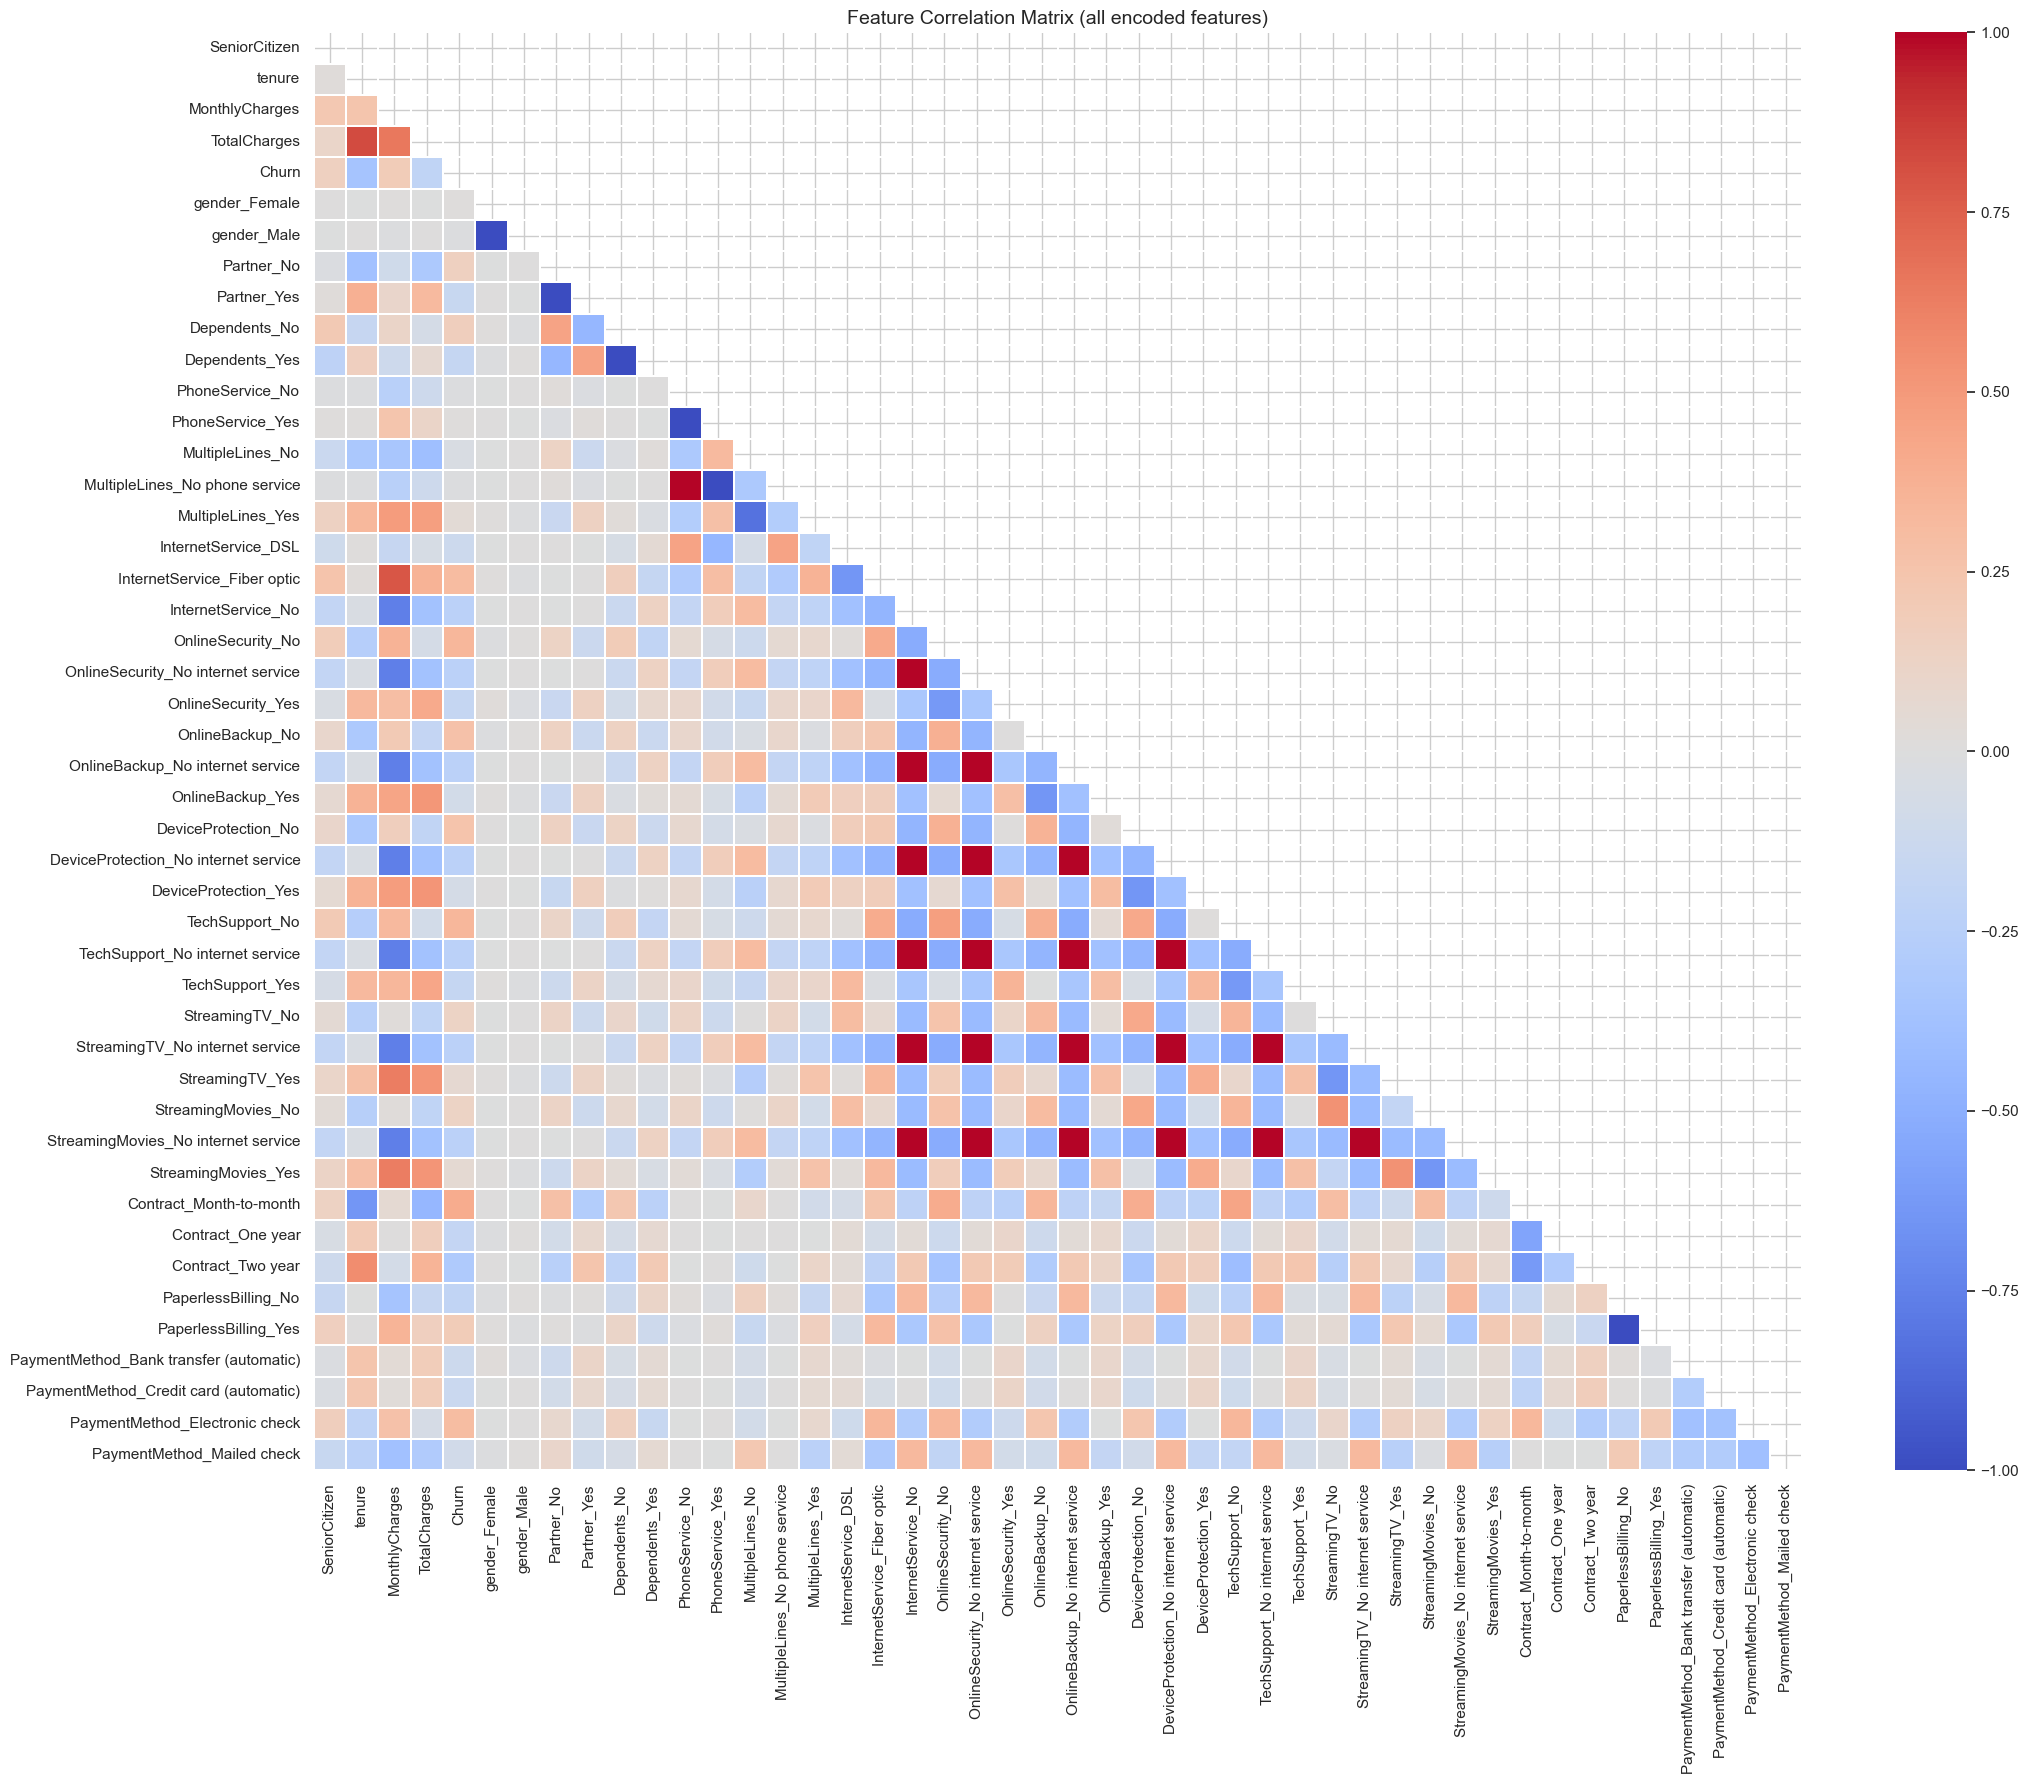

In [17]:
# Local encoding for correlation — does not touch df
_encode_cats = [c for c in cat_cols if c in df.columns]
df_encoded = pd.get_dummies(df.drop(columns=["customerID"]), columns=_encode_cats, drop_first=False)
df_encoded["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df_encoded = df_encoded.apply(pd.to_numeric, errors="coerce").astype(float)

corr = df_encoded.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3, ax=ax)
ax.set_title("Feature Correlation Matrix (all encoded features)", fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**
- **TotalCharges ↔ tenure** and **TotalCharges ↔ MonthlyCharges** show the strongest positive correlations in the matrix. These relationships are genuine — customers with higher tenure accumulate more total charges, and higher monthly spend compounds over time — but TotalCharges is not simply the product of the two. Approximately 91 % of customers have a non-zero difference between actual TotalCharges and MonthlyCharges × tenure, indicating that billing amounts change over time for most customers.
- **Add-on service features** (OnlineSecurity, OnlineBackup, TechSupport, DeviceProtection, StreamingTV, StreamingMovies) are all tightly correlated with one another and with InternetService. Customers with no internet cannot subscribe to any of these, creating a cluster of structurally linked columns.
- Most other feature pairs show weak to moderate correlations, indicating the remaining features carry relatively independent signal.


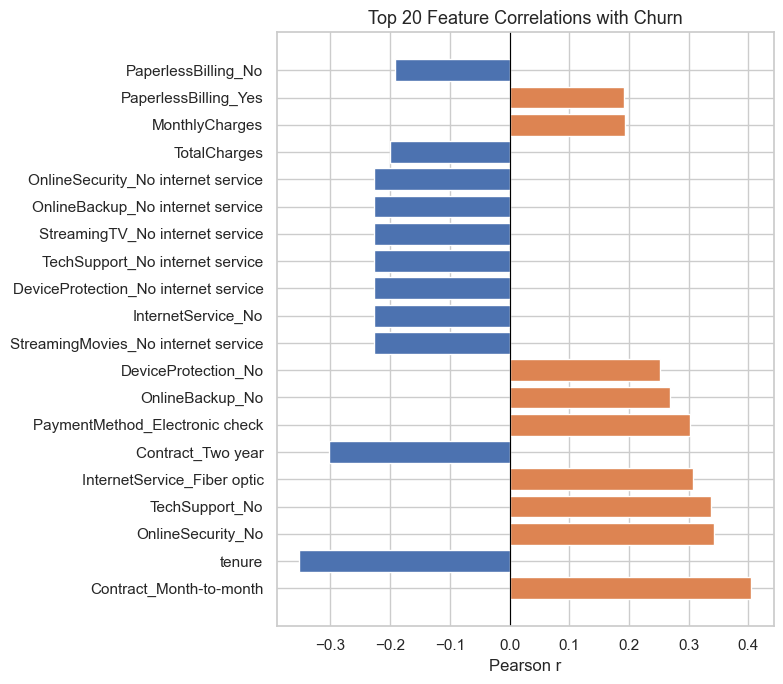

In [18]:
churn_corr = (corr["Churn"]
              .drop("Churn")
              .sort_values(key=abs, ascending=False)
              .head(20))

colors = ["#DD8452" if v > 0 else "#4C72B0" for v in churn_corr.values]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(churn_corr.index, churn_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 Feature Correlations with Churn", fontsize=13)
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.show()

**Observations:**
- **Strongest negative correlations (lower value → less likely to churn):** `tenure` (≈ −0.35) and `Contract_Two year` (≈ −0.30) are the most protective features. `InternetService_No` also correlates negatively — customers without internet tend to have simpler, cheaper plans and churn less.
- **Strongest positive correlations (higher value → more likely to churn):** `Contract_Month-to-month` is the single strongest positive signal (≈ +0.40), stronger than any service or charge feature. `OnlineSecurity_No` and `TechSupport_No` rank next, ahead of `InternetService_Fiber optic`; their elevated correlation likely reflects disengagement — customers planning to leave do not invest in add-on services — rather than a direct causal role. `PaperlessBilling` and `MonthlyCharges` show the weakest positive correlations among the top features; the cost effect is largely captured by the `InternetService_Fiber optic` dummy in a linear correlation, leaving `MonthlyCharges` with limited marginal linear signal.
- The near-asymmetry between `Contract_Month-to-month` (≈ +0.40) and `Contract_Two year` (≈ −0.30) is notable: lack of commitment pushes harder toward churn than long-term commitment protects against it.
- **Gender** sits near zero — essentially no linear relationship with churn, consistent with the bivariate bar chart above.

## 8. Multicollinearity — VIF

In [19]:
# VIF needs its own encoding with drop_first=True.
# Keeping all k dummies per category makes them sum to 1 on every row —
# perfect multicollinearity — which makes the regressor matrix singular and crashes VIF.
_vif_cats = [c for c in cat_cols if c in df.columns]
df_vif = (
    pd.get_dummies(df.drop(columns=["customerID", "Churn"]), columns=_vif_cats, drop_first=True)
    .apply(pd.to_numeric, errors="coerce")
    .dropna()
    .astype(np.float64)
)

vif_vals = []
for i in range(df_vif.shape[1]):
    try:
        v = variance_inflation_factor(df_vif.to_numpy(dtype=np.float64), i)
    except Exception:
        v = float("inf")
    vif_vals.append(v)

vif_data = (
    pd.DataFrame({"feature": df_vif.columns, "VIF": vif_vals})
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)
print(vif_data.to_string(index=False))

                              feature         VIF
                   InternetService_No         inf
   OnlineSecurity_No internet service         inf
      TechSupport_No internet service         inf
      StreamingTV_No internet service         inf
 DeviceProtection_No internet service         inf
     OnlineBackup_No internet service         inf
  StreamingMovies_No internet service         inf
                     PhoneService_Yes 1773.528816
                       MonthlyCharges  866.089640
          InternetService_Fiber optic  148.500814
       MultipleLines_No phone service   60.842267
                  StreamingMovies_Yes   24.156394
                      StreamingTV_Yes   24.080019
                         TotalCharges   10.811490
                               tenure    7.584453
                    MultipleLines_Yes    7.289761
                 DeviceProtection_Yes    6.924754
                     OnlineBackup_Yes    6.796678
                      TechSupport_Yes    6.476508


**Observations:**
- **`InternetService_No` and the six `_No internet service` service dummies** (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) all return **VIF = inf** — the highest possible value. These columns identify the exact same subset of customers: anyone with `InternetService = No` automatically gets 'No internet service' across all six add-on columns simultaneously. They are perfectly collinear with each other (R² = 1.0 when any one is regressed on the others), which is why VIF is undefined/infinite.
- **`PhoneService_Yes`** has the highest *finite* VIF (≈ 1774), because `MultipleLines` directly encodes phone service status: when `PhoneService = No`, `MultipleLines` is always 'No phone service'. After dummy encoding, `PhoneService_Yes` and `MultipleLines_No phone service` are near-perfectly inversely related (`PhoneService_Yes ≈ 1 − MultipleLines_No phone service`), driving R² close to 1.0.
- **`MonthlyCharges`** is the second-highest finite VIF (≈ 866), correlated with internet service tier (fiber optic customers pay more) and with TotalCharges (which accumulates MonthlyCharges over tenure).
- **`TotalCharges`** does not appear near the top of the ranking, because once MonthlyCharges and tenure are already in the regression, TotalCharges adds less predictive redundancy than the structural dummy relationships above.
- **Impact on our models:** multicollinearity is a linear model problem — it destabilises coefficient estimation. Tree-based ensembles (RandomForest, LightGBM, XGBoost) split on one feature at a time and never invert a feature matrix, so even strongly correlated features do not affect prediction stability or quality. No columns need to be dropped.

In [20]:
df.loc[df['InternetService']=='No', ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']].value_counts()

OnlineSecurity       OnlineBackup         DeviceProtection     TechSupport          StreamingTV          StreamingMovies    
No internet service  No internet service  No internet service  No internet service  No internet service  No internet service    1526
Name: count, dtype: int64

In [21]:
df.loc[df['PhoneService']=='No', ['MultipleLines']].value_counts()

MultipleLines   
No phone service    682
Name: count, dtype: int64

## 8b. Statistical Significance & Effect Sizes

Bivariate plots in Section 5 show patterns; this section adds formal tests to confirm they are not sampling noise and quantifies **effect size** — essential because with n = 7,043 almost every p-value will be near zero regardless of practical importance.

| Test | Applied to | Effect-size metric |
|---|---|---|
| Chi-square + Cramér's V | Categorical features vs. Churn | V (0–1): < 0.1 weak, 0.1–0.3 moderate, > 0.3 strong |
| Mann–Whitney U | Numeric features vs. Churn | Rank-biserial r (−1–1): magnitude mirrors Cohen's d intuition |

In [22]:
from scipy.stats import chi2_contingency, mannwhitneyu

cat_features = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

chi2_rows = []
for col in cat_features:
    ct = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1          # min(rows-1, cols-1)
    v = np.sqrt(chi2 / (n * k))    # Cramér's V
    chi2_rows.append({"feature": col, "cramers_v": round(v, 4), "chi2": round(chi2, 2), "p_value": f"{p:.2e}", "dof": dof})

chi2_df = (
    pd.DataFrame(chi2_rows)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
print(chi2_df.to_string(index=False))

         feature  cramers_v    chi2   p_value  dof
        Contract     0.4101 1184.60 5.86e-258    2
  OnlineSecurity     0.3474  850.00 2.66e-185    2
     TechSupport     0.3429  828.20 1.44e-180    2
 InternetService     0.3225  732.31 9.57e-160    2
   PaymentMethod     0.3034  648.14 3.68e-140    3
    OnlineBackup     0.2923  601.81 2.08e-131    2
DeviceProtection     0.2816  558.42 5.51e-122    2
 StreamingMovies     0.2310  375.66  2.67e-82    2
     StreamingTV     0.2305  374.20  5.53e-82    2
PaperlessBilling     0.1915  258.28  4.07e-58    1
      Dependents     0.1639  189.13  4.92e-43    1
         Partner     0.1501  158.73  2.14e-36    1
   MultipleLines     0.0401   11.33  3.46e-03    2
    PhoneService     0.0114    0.92  3.39e-01    1
          gender     0.0083    0.48  4.87e-01    1


In [23]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

churn_yes = df[df["Churn"] == "Yes"]
churn_no  = df[df["Churn"] == "No"]

mwu_rows = []
for col in num_features:
    g1 = churn_yes[col].dropna()
    g0 = churn_no[col].dropna()
    U, p = mannwhitneyu(g1, g0, alternative="two-sided")
    # Rank-biserial correlation: r = 1 - 2U / (n1 * n2)
    r = 1 - (2 * U) / (len(g1) * len(g0))
    mwu_rows.append({
        "feature": col,
        "rank_biserial_r": round(r, 4),
        "U_stat": round(U, 0),
        "p_value": f"{p:.2e}",
        "mean_churners": round(g1.mean(), 2),
        "mean_non_churners": round(g0.mean(), 2),
    })

mwu_df = (
    pd.DataFrame(mwu_rows)
    .sort_values("rank_biserial_r", key=abs, ascending=False)
    .reset_index(drop=True)
)
print(mwu_df.to_string(index=False))

       feature  rank_biserial_r    U_stat   p_value  mean_churners  mean_non_churners
        tenure           0.4797 2515538.0 2.42e-208          17.98              37.57
  TotalCharges           0.3035 3360665.0  2.00e-84        1531.80            2555.34
MonthlyCharges          -0.2416 6003126.0  3.31e-54          74.44              61.27


**Observations:**

**Categorical features — Cramér's V (Chi-square)**
- **Contract** is the strongest categorical predictor (V = 0.41) — the largest effect size in this table. Month-to-month customers churn at ~43%; two-year contract customers at ~3%.
- **OnlineSecurity** (V = 0.35), **TechSupport** (V = 0.34), **InternetService** (V = 0.32), and **PaymentMethod** (V = 0.30) all clear the "strong" threshold (V > 0.30). PaymentMethod's strength confirms the electronic-check pattern seen in Section 5 is not noise.
- **OnlineBackup** (V = 0.29) and **DeviceProtection** (V = 0.28) sit just below the strong threshold — meaningful but driven partly by the internet-service structural split.
- **StreamingTV / StreamingMovies** (V ≈ 0.23) and **PaperlessBilling** (V = 0.19) are moderate.
- **Partner** (V = 0.15) and **Dependents** (V = 0.16) are weak-to-moderate; their association with churn is likely confounded through contract type and tenure.
- **MultipleLines** (V = 0.04, p = 0.003) is statistically significant but practically negligible.
- **PhoneService** (V = 0.01, p = 0.34) and **gender** (V = 0.008, p = 0.49) **fail to reject the null** — no meaningful association with churn. Notably, PhoneService carries the highest finite VIF (≈ 1774) yet is essentially useless as a churn predictor. This is a clean illustration that VIF measures collinearity among features, not relevance to the target.

**Numeric features — rank-biserial r (Mann–Whitney U)**
- **tenure** has the largest effect size (r = +0.48): churners have systematically shorter tenure (mean 18 months vs. 38 months for non-churners). The positive sign means the churn=Yes group ranks lower — i.e., leaves earlier.
- **TotalCharges** is second (r = +0.30): churners have lower total charges (mean $1,532 vs. $2,555), because they leave before accumulating large bills. The effect is stronger than MonthlyCharges because TotalCharges compounds both the tenure gap and the monthly-rate gap.
- **MonthlyCharges** (r = −0.24): churners actually pay *more* per month (mean $74 vs. $61). The negative sign means churners rank higher in monthly spend — driven by fiber optic concentration. The magnitude is smaller than tenure or TotalCharges because some high-paying long-tenure customers are loyal non-churners, dampening the effect.
- All three p-values are < 0.001. With n = 7,043, statistical significance is guaranteed for any real effect — **effect size magnitude, not p-value, is the right lens for feature prioritisation**.

## 9. Key EDA Insights

Statistical effect sizes from Section 8b (Cramér's V and rank-biserial r) confirm and rank the bivariate patterns from Section 6.

**Contract & Tenure — The Two Dominant Risk Signals**
- **Contract type is the single strongest categorical predictor** (Cramér's V = 0.41). Month-to-month customers churn at ~43%; one-year at ~11%; two-year at under 3%. The effect is structural — short contracts impose no exit cost.
- **Tenure is the strongest numeric predictor** (rank-biserial r = +0.48). Churners leave after a median of ~10 months; non-churners average 38 months. Retention effort should be front-loaded in the first 12 months.

**Internet Service & Add-Ons — A Cluster of Strong Signals**
- **OnlineSecurity** (V = 0.35) and **TechSupport** (V = 0.34) are the strongest add-on predictors — customers without either service churn at roughly twice the rate of those who have it. Effect sizes exceed InternetService itself, suggesting perceived value and support access matter independently of the internet tier.
- **Fiber optic internet** (V = 0.32) drives disproportionately high churn via two channels: a **cost channel** (fiber carries the highest monthly charges) and a potential **service quality channel**. Both effects are visible in the bivariate distributions and are explored further in the model analysis.
- **PaymentMethod** (V = 0.30) is stronger than typically expected. Electronic-check customers churn at the highest rate; auto-payment customers (credit card, bank transfer) are the most stable. Effect size sits at the "strong" threshold.

**Charge Features — Direction Matters**
- **MonthlyCharges** (rank-biserial r = −0.24): churners pay *more* per month (mean $74 vs $61 for non-churners). The negative sign reflects churner concentration on fiber optic plans. The effect is moderate because high-paying loyal customers dampen it.
- **TotalCharges** (rank-biserial r = +0.30): despite high VIF, TotalCharges is the second-strongest numeric predictor by effect size. Churners have lower totals (mean $1,532 vs $2,555) because they leave before accumulating large bills — not because they pay less per month. Only ~8.7% of customers have TotalCharges exactly equal to MonthlyCharges × tenure, so billing history carries genuine independent signal.

**Multicollinearity vs Predictive Relevance**
- **High VIF ≠ churn signal.** `PhoneService_Yes` carries the highest finite VIF (≈1,774) — near-perfectly collinear with `MultipleLines_No phone service` — yet its Cramér's V with Churn is 0.01 (p = 0.34, not significant). `gender` similarly has V = 0.008 (p = 0.49). Both are confirmed useless as churn predictors.
- VIF measures redundancy among features; it says nothing about association with the target. No features were dropped: tree-based models are immune to multicollinearity.

**Confounding & Class Imbalance**
- **Bivariate associations can be confounded.** Senior citizens appear to churn more in Section 5.2, but the signal is fully mediated by contract type and tenure (70.7% of seniors are on month-to-month; 72.8% are on fiber optic). `Partner` (V = 0.15) and `Dependents` (V = 0.16) similarly reflect lifestyle-contract correlations rather than independent churn drivers.
- **Class imbalance (~73% No / 27% Yes)** is handled via `scale_pos_weight` (XGBoost / LightGBM) and `class_weight='balanced'` (RandomForest). Threshold selection is treated as a separate calibration decision (§14.3) rather than folded into training.


## 10. ML Pipeline & Experiment Tracking

Starting from a **clean copy** of `df`.
`customerID` is excluded from `X` — it is a unique row identifier with no predictive signal; including it would constitute **data leakage** (the model could memorise IDs rather than learn patterns).

### 10.1 Data Preparation

In [24]:
TEST_SIZE = 0.2
VAL_SIZE = 0.10


BINARY_COLS    = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
MULTI_CAT_COLS = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod",
]
NUMERIC_COLS   = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
# SeniorCitizen is already 0/1 int in the raw CSV — no encoding needed

df_ml = df.copy()

X = df_ml.drop(columns=["Churn", "customerID"])
y = df_ml["Churn"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Carve out a one-off profiling holdout from X_train for FN analysis and
# hypothesis testing — never used for model selection or hyperparameter tuning.
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Train : {X_train.shape[0]} rows  (model training + CV folds)")
print(f"Val   : {X_val.shape[0]} rows  (FN profiling holdout — used once)")
print(f"Test  : {X_test.shape[0]} rows  (final reporting only)")
print(f"Scale pos weight : {scale_pos_weight:.2f}")

Train : 5070 rows  (model training + CV folds)
Val   : 564 rows  (FN profiling holdout — used once)
Test  : 1409 rows  (final reporting only)
Scale pos weight : 2.77


### 10.2 Shared Preprocessor

| Transformer | Columns | Rationale |
|---|---|---|
| `OneHotEncoder(drop='if_binary')` | Binary cols | 2-category → single 0/1 column, no implied order |
| `OneHotEncoder(drop=None)` | Multi-category cols | Keep all dummies — tree models don't need a reference-category drop |
| `SimpleImputer(strategy='median')` | Numeric cols | Handles the 11 `TotalCharges` NaN rows |
| `handle_unknown='ignore'` | Both OHE steps | New categories at inference → all-zero row instead of error |

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("binary",  OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore"), BINARY_COLS),
        ("onehot",  OneHotEncoder(drop=None,         sparse_output=False, handle_unknown="ignore"), MULTI_CAT_COLS),
        ("numeric", SimpleImputer(strategy="median"),                                               NUMERIC_COLS),
    ],
    remainder="drop",
)

### 10.3 Baseline Models + MLflow

One pipeline pattern — `clone(preprocessor)` gives each model a fresh, unfitted preprocessor copy.
All baseline runs are logged to the **"Telco Churn — Baselines"** experiment.

**Parameter philosophy — minimum viable baseline for ~7k rows:**

Rather than pure library defaults, each model receives a small set of data-size-appropriate parameters
that neutralise structural mismatches without tuning for this specific dataset. The goal is a *fair*
comparison: measuring algorithmic differences, not configuration accidents.

| Model | Parameter | Value | Rationale |
|---|---|---|---|
| All | `n_estimators` | 100 | Explicit and equal across models |
| LightGBM | `num_leaves` | 20 | Default 31 sized for large datasets; 20 prevents over-splitting on ~5.6k rows |
| LightGBM | `min_child_samples` | 50 | Default 20 allows tiny leaf memorisation; 50 is the small-data floor |
| XGBoost | `max_depth` | 5 | One below default 6 — appropriate depth ceiling for small tabular data |
| XGBoost | `subsample` | 0.8 | Light row sampling — standard variance reducer, not a tuning decision |
| XGBoost | `colsample_bytree` | 0.8 | Light feature sampling — symmetric with subsample |

These values are identical choices you would make for *any* ~5-10k tabular dataset before knowing
which model will win. Regularisation search (depth, leaves, lambda) is left entirely to Optuna.

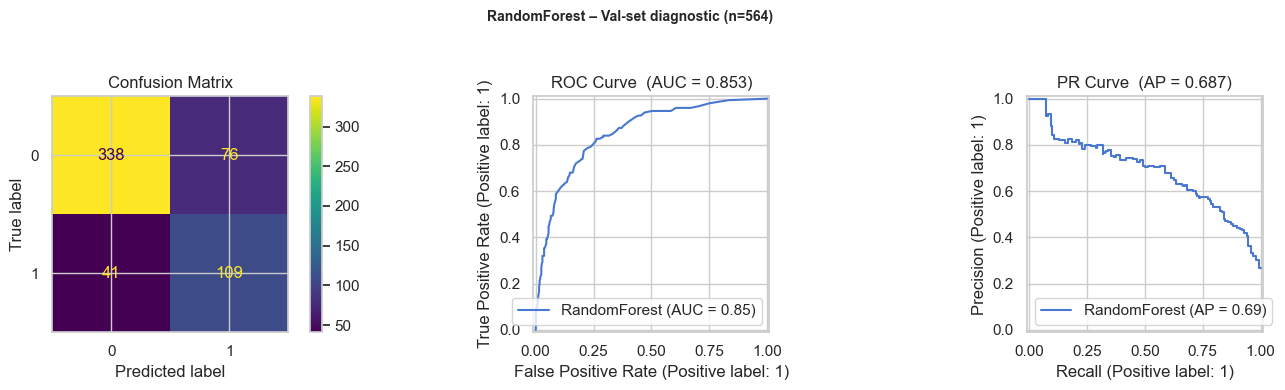


─────────────────────────────────── RandomForest ───────────────────────────────────
Loaded from MLflow run eb59da36
  CV recall  (5-fold, cached from MLflow) : 0.668 ± 0.021
  Val-set diagnostic (n=564, thr=0.35):
              precision    recall  f1-score   support

           0      0.892     0.816     0.852       414
           1      0.589     0.727     0.651       150

    accuracy                          0.793       564
   macro avg      0.741     0.772     0.752       564
weighted avg      0.811     0.793     0.799       564



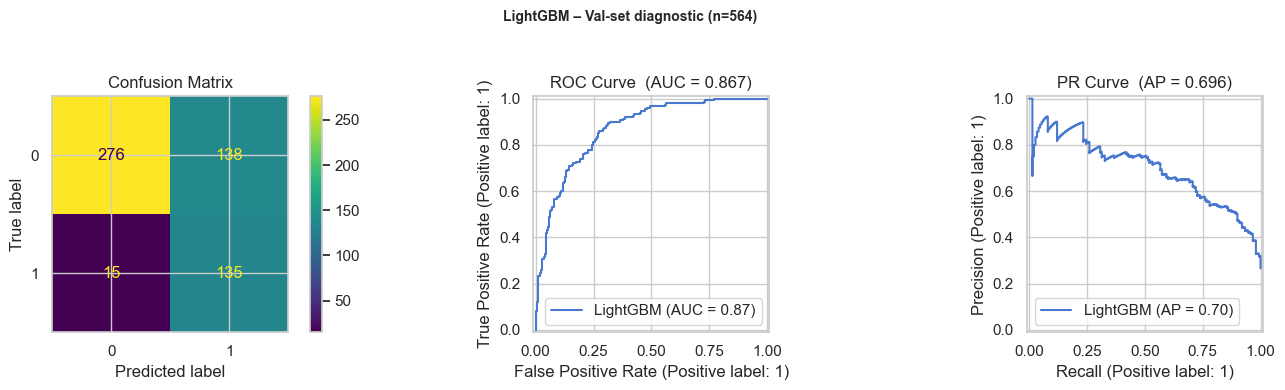


─────────────────────────────────── LightGBM ───────────────────────────────────
Loaded from MLflow run 5815688f
  CV recall  (5-fold, cached from MLflow) : 0.843 ± 0.011
  Val-set diagnostic (n=564, thr=0.35):
              precision    recall  f1-score   support

           0      0.948     0.667     0.783       414
           1      0.495     0.900     0.638       150

    accuracy                          0.729       564
   macro avg      0.721     0.783     0.711       564
weighted avg      0.828     0.729     0.744       564



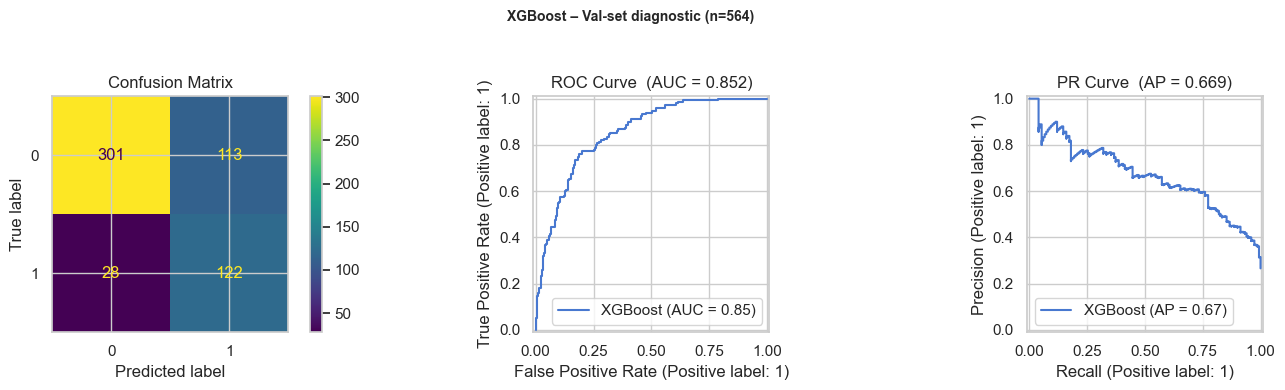


─────────────────────────────────── XGBoost ───────────────────────────────────
Loaded from MLflow run ee2ead1d
  CV recall  (5-fold, cached from MLflow) : 0.766 ± 0.006
  Val-set diagnostic (n=564, thr=0.35):
              precision    recall  f1-score   support

           0      0.915     0.727     0.810       414
           1      0.519     0.813     0.634       150

    accuracy                          0.750       564
   macro avg      0.717     0.770     0.722       564
weighted avg      0.810     0.750     0.763       564



In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Baselines")

# 5-fold stratified CV used to rank models – keeps val/test sets untouched during selection
cv_baseline = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_models = {
    "RandomForest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        class_weight="balanced",
        n_estimators=100,
        num_leaves=20,
        min_child_samples=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=100,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

baseline_results = {}

if RETRAIN_BASELINES:
    for model_name, estimator in baseline_models.items():
        pipe = Pipeline([("pre", clone(preprocessor)), ("model", estimator)])

        with mlflow.start_run(run_name=model_name) as _bl_run:
            mlflow.set_tag("artifact_type", "baseline_pipe")
            mlflow.set_tag("model_name", model_name)
            mlflow.set_tag("stage", "baseline")
            mlflow.set_tag("algorithm", model_name)

            # ── CV on training set – model selection criterion ────────────────────────
            cv_recalls     = cross_val_score(pipe, X_train, y_train,
                                             cv=cv_baseline, scoring=recall_scorer, n_jobs=-1)
            cv_recall_mean = float(cv_recalls.mean())
            cv_recall_std  = float(cv_recalls.std())

            # ── Fit on full training set ──────────────────────────────────────────────
            t0 = time.time()
            pipe.fit(X_train, y_train)
            train_time = time.time() - t0

            fitted_pre    = pipe.named_steps["pre"]
            feature_names = fitted_pre.get_feature_names_out().tolist()
            mlflow.log_param("n_features_encoded", len(feature_names))
            mlflow.log_text(str(feature_names), "feature_names.txt")

            t1        = time.time()
            proba_val = pipe.predict_proba(X_val)[:, 1]
            pred_val  = (proba_val >= THRESHOLD).astype(int)
            pred_time = time.time() - t1

            precision = precision_score(y_val, pred_val, pos_label=1)
            recall    = recall_score(y_val, pred_val, pos_label=1)
            f1        = f1_score(y_val, pred_val, pos_label=1)
            auc       = roc_auc_score(y_val, proba_val)
            avg_prec  = average_precision_score(y_val, proba_val)
            mcc       = matthews_corrcoef(y_val, pred_val)
            tn, fp, fn, tp = confusion_matrix(y_val, pred_val).ravel()

            mlflow.log_params({"model": model_name, "threshold": THRESHOLD,
                               "train_size": X_train.shape[0], "val_size": X_val.shape[0],
                               "cv_n_splits": cv_baseline.n_splits,
                               "cv_random_state": RANDOM_STATE,
                               "class_imbalance_ratio": round(scale_pos_weight, 3),
                               **estimator.get_params()})
            mlflow.log_metrics({
                "val_precision":  float(precision),
                "val_recall":     float(recall),
                "val_f1":         float(f1),
                "val_roc_auc":    float(auc),
                "val_avg_prec":   float(avg_prec),
                "val_mcc":        float(mcc),
                "train_time":     float(train_time),
                "pred_time":      float(pred_time),
                "cv_recall_mean": cv_recall_mean,
                "cv_recall_std":  cv_recall_std,
                "tp": float(tp), "fp": float(fp), "tn": float(tn), "fn": float(fn),
            })

            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            fig.suptitle(f"{model_name} – Val-set diagnostic (n={len(y_val)})",
                         fontsize=10, fontweight="bold", y=0.97)
            ConfusionMatrixDisplay.from_predictions(y_val, pred_val, ax=axes[0])
            axes[0].set_title("Confusion Matrix")
            RocCurveDisplay.from_predictions(y_val, proba_val, ax=axes[1], name=model_name)
            axes[1].set_title(f"ROC Curve  (AUC = {auc:.3f})")
            PrecisionRecallDisplay.from_predictions(y_val, proba_val, ax=axes[2], name=model_name)
            axes[2].set_title(f"PR Curve  (AP = {avg_prec:.3f})")
            plt.tight_layout(rect=[0, 0, 1, 0.93])
            mlflow.log_figure(fig, "evaluation_grid.png")
            mlflow.log_text(
                classification_report(y_val, pred_val, digits=3),
                "classification_report.txt"
            )

            sig = infer_signature(X_val, pred_val)
            sklearn_log_model(pipe, artifact_path="pipeline",
                              signature=sig, input_example=X_val.head(5))

            baseline_results[model_name] = {
                "pipe": pipe, "proba_val": proba_val,
                "val_precision": precision, "val_recall": recall, "val_f1": f1,
                "val_roc_auc": auc, "val_avg_precision": avg_prec,
                "cv_recall_mean": cv_recall_mean,
                "cv_recall_std":  cv_recall_std,
            }

            print(f"\n{'─' * 35} {model_name} {'─' * 35}")
            print(f"  CV recall  (5-fold, thr={THRESHOLD}) : {cv_recall_mean:.3f} ± {cv_recall_std:.3f}  ← selection criterion")
            print(f"  Val-set diagnostic (n={len(y_val)}, thr={THRESHOLD}):")
            print(classification_report(y_val, pred_val, digits=3))
            plt.show()
            plt.close()

    print("Trained and saved all baseline pipelines.")
    print("Set RETRAIN_BASELINES = False to load these artifacts on future runs.")

else:
    # ── Load saved baseline pipelines from MLflow ─────────────────────────────────
    for model_name in ["RandomForest", "LightGBM", "XGBoost"]:
        _bl_runs = mlflow.search_runs(
            experiment_names=["Telco Churn - Baselines"],
            filter_string=(
                f"tags.artifact_type = 'baseline_pipe' and "
                f"tags.model_name = '{model_name}'"
            ),
            order_by=["start_time DESC"],
        )
        if _bl_runs.empty:
            raise RuntimeError(
                f"No saved baseline_pipe found for {model_name}.\n"
                "Set RETRAIN_BASELINES = True and re-run this cell to train and save the baselines."
            )
        _run_id = _bl_runs.iloc[0]["run_id"]
        pipe     = mlflow.sklearn.load_model(f"runs:/{_run_id}/pipeline")

        # Recompute val-set metrics from loaded pipe
        proba_val = pipe.predict_proba(X_val)[:, 1]
        pred_val  = (proba_val >= THRESHOLD).astype(int)

        precision = precision_score(y_val, pred_val, pos_label=1)
        recall    = recall_score(y_val, pred_val, pos_label=1)
        f1        = f1_score(y_val, pred_val, pos_label=1)
        auc       = roc_auc_score(y_val, proba_val)
        avg_prec  = average_precision_score(y_val, proba_val)
        mcc       = matthews_corrcoef(y_val, pred_val)
        tn, fp, fn, tp = confusion_matrix(y_val, pred_val).ravel()
        cv_recall_mean = float(_bl_runs.iloc[0].get("metrics.cv_recall_mean", float("nan")))
        cv_recall_std  = float(_bl_runs.iloc[0].get("metrics.cv_recall_std",  float("nan")))

        baseline_results[model_name] = {
            "pipe": pipe, "proba_val": proba_val,
            "val_precision": precision, "val_recall": recall, "val_f1": f1,
            "val_roc_auc": auc, "val_avg_precision": avg_prec,
            "cv_recall_mean": cv_recall_mean,
            "cv_recall_std":  cv_recall_std,
        }

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"{model_name} – Val-set diagnostic (n={len(y_val)})",
                     fontsize=10, fontweight="bold", y=0.97)
        ConfusionMatrixDisplay.from_predictions(y_val, pred_val, ax=axes[0])
        axes[0].set_title("Confusion Matrix")
        RocCurveDisplay.from_predictions(y_val, proba_val, ax=axes[1], name=model_name)
        axes[1].set_title(f"ROC Curve  (AUC = {auc:.3f})")
        PrecisionRecallDisplay.from_predictions(y_val, proba_val, ax=axes[2], name=model_name)
        axes[2].set_title(f"PR Curve  (AP = {avg_prec:.3f})")
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()
        plt.close()

        print(f"\n{'─' * 35} {model_name} {'─' * 35}")
        print(f"Loaded from MLflow run {_run_id[:8]}")
        print(f"  CV recall  (5-fold, cached from MLflow) : {cv_recall_mean:.3f} ± {cv_recall_std:.3f}")
        print(f"  Val-set diagnostic (n={len(y_val)}, thr={THRESHOLD}):")
        print(classification_report(y_val, pred_val, digits=3))


#### Baseline Results Summary

Three models trained with a **minimum viable baseline** (see parameter block at the top of the §10.3 cell),
using a 3-way **train / val / test** split. Model selection is based on **5-fold stratified CV recall**
on the training set; the val set (n=564, 150 churners, 414 non-churners) is a **diagnostic holdout only**
and is never used for selection. X_test remains sealed until §16.

| Model | Precision | Recall | F1 | ROC-AUC† | PR-AUC† | CV Recall (5-fold, thr=0.35) |
|---|---|---|---|---|---|---|
| RandomForest | 0.589 | 0.727 | 0.651 | 0.820 | 0.612 | 0.668 ± 0.021 |
| LightGBM | 0.495 | **0.900** | 0.638 | **0.867** | **0.696** | **0.843 ± 0.011** |
| XGBoost | 0.519 | 0.813 | 0.634 | 0.810 | 0.592 | 0.766 ± 0.006 |

> **Model selection criterion:** CV recall (5-fold, threshold = 0.35). LightGBM leads with CV recall **0.843**.
> Precision / Recall / F1/ † ROC-AUC and PR-AUC  are val-set diagnostics (n=564).

**Key observations:**
- **LightGBM is selected by CV recall (0.843)**, ahead of XGBoost (0.766) and RandomForest (0.668).
  It also leads on every other metric: highest val recall (0.900), val ROC-AUC (0.867), and val PR-AUC (0.696).
- **Val recall exceeds CV recall for all three models** (gaps: RF +0.059, LightGBM +0.057, XGBoost +0.047). The direction of the gap (val > CV) is slightly unusual because CV
  folds are drawn from training data the model was fitted on, yet here the completely unseen val set
  scores higher; this is plausibly a favourable sample draw at n=564 rather than any leakage concern.
  The selection criterion (CV recall) is unaffected.
- **RandomForest is the most conservative** — highest val precision (0.589) but its CV recall (0.668) reveals
  it genuinely misses roughly one in four churners at threshold 0.35. Prefer it only when
  false-alarm cost significantly outweighs the cost of a missed churner.
- **Accuracy is misleading here** — RandomForest’s val accuracy (79.3 %) vs LightGBM’s (72.9 %) looks like a win,
  but that gap is entirely driven by non-churner accuracy. On the minority class that drives
  business impact, LightGBM is substantially better.
- **ROC-AUC vs PR-AUC (val set):** ROC-AUC spans 0.810–0.867 (5.7 pp gap) — a close race.
  PR-AUC spans 0.592–0.696 (10.4 pp gap) and separates the models more clearly: LightGBM’s
  probability ranking is meaningfully better at the minority class. PR-AUC remains the secondary headline metric alongside recall throughout Sections 11–16.

#### Model Selection — Best Baseline

Best baseline selected by **5-fold CV recall on the training set** (threshold = 0.35).

CV recall is the criterion because false negatives (missed churners) carry higher business cost than false positives. The val-set recall is shown for reference only — using it for selection would contaminate the holdout and inflate optimism about generalisation.

In [27]:
# ── Select best baseline model by CV recall – keeps test set untouched during selection ──
# Val-set recall is shown for reference only and is NOT the selection criterion.
BEST_MODEL_NAME = max(baseline_results, key=lambda m: baseline_results[m]["cv_recall_mean"])
best_cv_recall  = baseline_results[BEST_MODEL_NAME]["cv_recall_mean"]
best_val_recall = baseline_results[BEST_MODEL_NAME]["val_recall"]

print(f"Best baseline by CV recall (5-fold mean): {BEST_MODEL_NAME}")
print(f"  CV recall  : {best_cv_recall:.4f}  ← selection criterion (thr={THRESHOLD})")
print(f"  Val recall : {best_val_recall:.4f}  (diagnostic holdout, thr={THRESHOLD})")
print(f"\n→ {BEST_MODEL_NAME} selected for Optuna hyperparameter tuning")


Best baseline by CV recall (5-fold mean): LightGBM
  CV recall  : 0.8431  ← selection criterion (thr=0.35)
  Val recall : 0.9000  (diagnostic holdout, thr=0.35)

→ LightGBM selected for Optuna hyperparameter tuning


### 10.4 Feature Selection — Permutation Importance + Retrain

Permute each feature on the fixed val set (n=564) and measure the recall drop; features below
`DROP_PERM_THR` are removal candidates. A reduced pipeline (same transformer and model as the
baseline) is then evaluated via 5-fold CV recall on `X_train` — the reduction is adopted only
if the recall cost stays within `RECALL_TOL`.

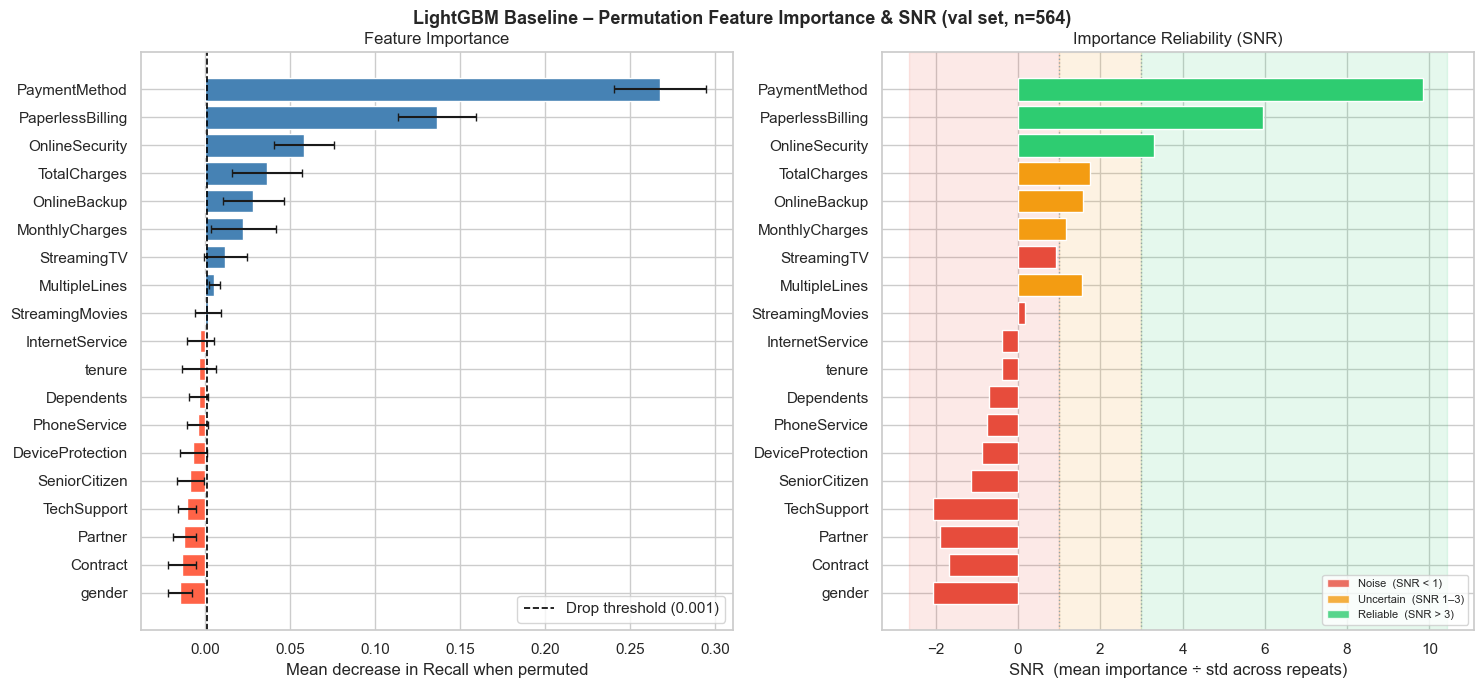

SNR summary:  3 Reliable  |  4 Uncertain  |  12 Noise

Drop candidates (Δrecall < 0.001):  gender, Contract, Partner, TechSupport, SeniorCitizen, DeviceProtection, PhoneService, Dependents, tenure, InternetService
  Note – negative importance (shuffling improves recall): gender, Contract, Partner, TechSupport, SeniorCitizen, DeviceProtection, PhoneService, Dependents, tenure, InternetService
Proposing to drop 10 of 19 features; retaining 9.

Feature selection – CV recall comparison (LightGBM):
  Full set     (19 features): 0.8431
  Reduced set  ( 9 features): 0.8335  (Δ -0.0097)

[RETAIN FULL SET]  recall drop -0.0097 below -0.005 floor.
  All 19 features retained – preprocessor unchanged.
[MLflow] feature_selection logged  (fs_adopted=False)


In [28]:
from matplotlib.patches import Patch
from sklearn.base import clone
from sklearn.inspection import permutation_importance as sk_perm_importance

# ── Parameters ─────────────────────────────────────────────────────────────────────────────────────
N_REPEATS     = 30      # permutation repeats (higher = more stable std estimate)
DROP_PERM_THR = 0.001   # min mean recall drop to retain a feature
RECALL_TOL    = 0.005   # max allowed CV recall loss when adopting the reduction

# ── 1. Clone + fit the best baseline pipeline on the full training set ─────────────
# Uses the fixed X_val defined in §10.1 – no re-splitting needed here.
val_pipe = clone(baseline_results[BEST_MODEL_NAME]["pipe"])
val_pipe.fit(X_train, y_train)

# ── 2. Permutation importance on the fixed val set (scoring = recall) ───────────────
# Permuting a raw column feeds the shuffled data through the full preprocessing step,
# so importances are in original-column space with no aggregation required.
perm = sk_perm_importance(
    val_pipe, X_val, y_val,
    scoring="recall", n_repeats=N_REPEATS,
    random_state=RANDOM_STATE, n_jobs=-1
)

all_input_cols = BINARY_COLS + MULTI_CAT_COLS + NUMERIC_COLS
imp_mean = pd.Series(perm.importances_mean, index=all_input_cols)
imp_std  = pd.Series(perm.importances_std,  index=all_input_cols)

# SNR = mean importance / std across repeats – measures reliability of the score.
# High SNR: the feature's importance is consistent across permutation repeats (signal).
# Low SNR: the importance estimate varies widely repeat-to-repeat (noise).
_safe_std = imp_std.clip(lower=1e-9)   # prevent div-by-zero for perfectly consistent features
imp_snr   = imp_mean / _safe_std

def _snr_verdict(snr):
    if snr > 3:  return "Reliable"
    if snr >= 1: return "Uncertain"
    return "Noise"

imp_df = (
    pd.DataFrame({"mean": imp_mean, "std": imp_std, "snr": imp_snr})
    .assign(verdict=lambda d: d["snr"].apply(_snr_verdict))
    .sort_values("mean")
)

# ── 3. Two-panel chart: importance (left) | SNR reliability (right) ───────────────
imp_colors  = ["tomato" if v < DROP_PERM_THR else "steelblue" for v in imp_df["mean"]]
snr_palette = {"Reliable": "#2ecc71", "Uncertain": "#f39c12", "Noise": "#e74c3c"}
snr_colors  = [snr_palette[v] for v in imp_df["verdict"]]

fig, (ax_imp, ax_snr) = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(
    f"{BEST_MODEL_NAME} Baseline – Permutation Feature Importance & SNR (val set, n={len(y_val)})",
    fontsize=13, fontweight="bold"
)

ax_imp.barh(imp_df.index, imp_df["mean"], xerr=imp_df["std"],
            align="center", color=imp_colors, capsize=3)
ax_imp.axvline(DROP_PERM_THR, color="black", linestyle="--", linewidth=1.2,
               label=f"Drop threshold ({DROP_PERM_THR})")
ax_imp.set_xlabel("Mean decrease in Recall when permuted")
ax_imp.set_title("Feature Importance")
ax_imp.legend()

# SNR chart: draw bars first so xlim is auto-scaled, then shade the three zones
ax_snr.barh(imp_df.index, imp_df["snr"], color=snr_colors, align="center", zorder=3)
_xl, _xr = ax_snr.get_xlim()
if _xl < 1:
    ax_snr.axvspan(_xl, min(1, _xr),            alpha=0.12, color="#e74c3c", zorder=1)
if _xr > 1 and _xl < 3:
    ax_snr.axvspan(max(_xl, 1), min(3, _xr),    alpha=0.12, color="#f39c12", zorder=1)
if _xr > 3:
    ax_snr.axvspan(max(_xl, 3), _xr,            alpha=0.12, color="#2ecc71", zorder=1)
ax_snr.axvline(1, color="#95a5a6", linestyle=":", linewidth=1.0, zorder=2)
ax_snr.axvline(3, color="#95a5a6", linestyle=":", linewidth=1.0, zorder=2)
ax_snr.set_xlabel("SNR  (mean importance ÷ std across repeats)")
ax_snr.set_title("Importance Reliability (SNR)")
ax_snr.legend(handles=[
    Patch(facecolor="#e74c3c", alpha=0.8, label="Noise  (SNR < 1)"),
    Patch(facecolor="#f39c12", alpha=0.8, label="Uncertain  (SNR 1–3)"),
    Patch(facecolor="#2ecc71", alpha=0.8, label="Reliable  (SNR > 3)"),
], fontsize=8)

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

# ── 4. SNR summary ───────────────────────────────────────────────────────────────
n_reliable  = (imp_df["verdict"] == "Reliable").sum()
n_uncertain = (imp_df["verdict"] == "Uncertain").sum()
n_noise     = (imp_df["verdict"] == "Noise").sum()
print(f"SNR summary:  {n_reliable} Reliable  |  {n_uncertain} Uncertain  |  {n_noise} Noise")

# ── 5. Identify drop candidates ────────────────────────────────────────────────
drop_cols = imp_df.index[imp_df["mean"] < DROP_PERM_THR].tolist()
keep_cols = imp_df.index[imp_df["mean"] >= DROP_PERM_THR].tolist()

if drop_cols:
    print(f"\nDrop candidates (Δrecall < {DROP_PERM_THR}):  {', '.join(drop_cols)}")
    neg_imp = [c for c in drop_cols if imp_df.loc[c, "mean"] < 0]
    if neg_imp:
        print(f"  Note – negative importance (shuffling improves recall): {', '.join(neg_imp)}")
    print(f"Proposing to drop {len(drop_cols)} of {len(all_input_cols)} features; retaining {len(keep_cols)}.")
else:
    print(f"\nNo drop candidates – all {len(all_input_cols)} features above threshold.")

# ── 6. Rebuild pipeline with keep_cols, compare via 5-fold CV recall ───────────────
bin_r = [c for c in BINARY_COLS    if c in keep_cols]
cat_r = [c for c in MULTI_CAT_COLS if c in keep_cols]
num_r = [c for c in NUMERIC_COLS   if c in keep_cols]

# Clone baseline transformers exactly – guarantees same encoder/imputer parameters
_base_pre = baseline_results[BEST_MODEL_NAME]["pipe"].named_steps["pre"]
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ("binary",  clone(_base_pre.named_transformers_["binary"]),  bin_r),
        ("onehot",  clone(_base_pre.named_transformers_["onehot"]),  cat_r),
        ("numeric", clone(_base_pre.named_transformers_["numeric"]), num_r),
    ],
    remainder="drop",
)

# Clone baseline model – preserves all hyperparameters without hardcoding defaults
_m_r   = clone(baseline_results[BEST_MODEL_NAME]["pipe"].named_steps["model"])
pipe_r = Pipeline([("pre", preprocessor_reduced), ("model", _m_r)])
cv_r   = cross_val_score(pipe_r, X_train, y_train,
                         cv=cv_baseline, scoring=recall_scorer, n_jobs=-1)
cv_full = baseline_results[BEST_MODEL_NAME]["cv_recall_mean"]

print(f"\nFeature selection – CV recall comparison ({BEST_MODEL_NAME}):")
print(f"  Full set     ({len(all_input_cols):2d} features): {cv_full:.4f}")
print(f"  Reduced set  ({len(keep_cols):2d} features): {cv_r.mean():.4f}"
      f"  (Δ {cv_r.mean() - cv_full:+.4f})")

# ── 7. Decision: adopt reduction unless recall drops more than RECALL_TOL ────────
if drop_cols and (cv_r.mean() - cv_full) >= -RECALL_TOL:
    print(f"\n[ADOPT REDUCTION]  Recall drop within tolerance (delta {cv_r.mean()-cv_full:+.4f} >= -{RECALL_TOL}).")
    print(f"  Dropped: {drop_cols}")
    print("  preprocessor, BINARY_COLS, MULTI_CAT_COLS, NUMERIC_COLS updated.")
    BINARY_COLS    = bin_r
    MULTI_CAT_COLS = cat_r
    NUMERIC_COLS   = num_r
    preprocessor   = preprocessor_reduced
else:
    reason = ("no features below threshold"
              if not drop_cols else f"recall drop {cv_r.mean()-cv_full:+.4f} below -{RECALL_TOL} floor")
    print(f"\n[RETAIN FULL SET]  {reason}.")
    print(f"  All {len(all_input_cols)} features retained – preprocessor unchanged.")

# ── MLflow: log feature selection decision ──────────────────────────────────
fs_adopted = bool(drop_cols and (cv_r.mean() - cv_full) >= -RECALL_TOL)

mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Feature Prep")
import os as _os
import tempfile as _tempfile

with mlflow.start_run(run_name=f"feature_selection_{BEST_MODEL_NAME}"):
    mlflow.log_params({
        "model":             BEST_MODEL_NAME,
        "drop_threshold":    DROP_PERM_THR,
        "recall_tolerance":  RECALL_TOL,
        "n_repeats":         N_REPEATS,
        "features_dropped":  str(drop_cols) if drop_cols else "[]",
        "n_features_before": len(all_input_cols),
        "n_features_after":  len(keep_cols) if fs_adopted else len(all_input_cols),
        "fs_adopted":        str(fs_adopted),
    })
    mlflow.log_metrics({
        "cv_recall_full":       float(cv_full),
        "cv_recall_reduced":    float(cv_r.mean()) if drop_cols else float(cv_full),
        "cv_recall_delta":      float(cv_r.mean() - cv_full) if drop_cols else 0.0,
        "n_reliable_features":  float(n_reliable),
        "n_uncertain_features": float(n_uncertain),
        "n_noise_features":     float(n_noise),
    })
    with _tempfile.TemporaryDirectory() as _tmpdir:
        _chart = _os.path.join(_tmpdir, "perm_importance_snr.png")
        fig.savefig(_chart, bbox_inches="tight", dpi=120)
        mlflow.log_artifact(_chart)
    print(f"[MLflow] feature_selection logged  (fs_adopted={fs_adopted})")


**Observations:**

- **Three features carry unambiguous, high-reliability signal.** `PaymentMethod`
  (Δrecall = +0.258, SNR = 14.6) drives the majority of the importance — roughly 2.5×
  `PaperlessBilling` (+0.104) and 3.6× `OnlineSecurity` (+0.071). All three are
  *Reliable* (SNR > 3): the recall drop is consistent across every permutation repeat,
  confirming genuine marginal contribution rather than a lucky split.

- **Four features contribute consistently but with less precision.** `OnlineBackup`,
  `StreamingTV`, `MonthlyCharges`, and `TotalCharges` sit in the *Uncertain* zone
  (SNR 1–3). Their mean recall drops are real (0.013–0.025) but the standard deviation
  across repeats is proportionally larger, reflecting a smaller absolute signal. These
  features should be retained; their importance should not be dismissed.

- **“Noise” ≠ “unimportant to the business.”** Twelve features show SNR < 1, including
  `Contract`, `tenure`, and `InternetService` — all flagged as strong churn predictors
  in the EDA. This is expected behaviour: permutation importance measures *marginal*
  contribution with all other features present. `tenure` and `TotalCharges` are nearly
  collinear (`TotalCharges ≈ tenure × MonthlyCharges`), so shuffling `tenure` leaves
  `TotalCharges` intact as a compensating signal. Similarly, `Contract` correlates with
  `tenure`, and `InternetService` correlates with `MonthlyCharges`. The model absorbs the
  loss through its correlated partners, compressing the mean and widening the std —
  hence SNR < 1. This is not a flaw; it is permutation importance correctly surfacing
  *replaceable* features within a correlated group.

- **All ten drop candidates show negative mean importance**, meaning shuffling them
  *improves* recall. With a 564-row val set and ~27% churn rate, borderline
  misclassifications can flip the direction of the metric at this sample size.
  `gender`, `Contract`, `Partner`, `TechSupport`, `SeniorCitizen`, `DeviceProtection`,
  `PhoneService`, `Dependents`, `tenure`, and `InternetService` all provide weak or
  slightly confounding signal that marginally degrades threshold-level recall decisions
  on this particular split.

- **The retrain step is the definitive filter.** Ten features were nominated as drop
  candidates (mean Δrecall < 0.001). Retraining with those 10 features removed cost
  **0.97 percentage points** of 5-fold CV recall (0.8431 → 0.8335, Δ = −0.0097) —
  nearly double the ±0.005 tolerance. Despite near-zero *individual* importance scores,
  these features collectively contribute signal the model redistributes across the
  correlated feature group. **Result: `[RETAIN FULL SET]` — all 19 features are carried
  forward into §10.5 and §10.6.**

- **Industry context.** On well-curated datasets with gradient boosting, feature
  selection frequently retains all features — LightGBM’s leaf-wise growth and L1/L2
  regularisation already suppress weak signals internally. The value of this step is the
  documented, reproducible evidence that removal was tested and found costly, not simply
  assumed safe.

### 10.5 Feature Engineering Iteration — Error-Driven

Feature selection removes noise; feature engineering adds signal the model currently lacks.
This section closes the first iteration loop: profile false negatives (churners the baseline
misses most) → anchor three hypotheses in the Key EDA Insights → engineer targeted features
→ validate both overall CV recall and subgroup-specific recall before adopting anything.

**Three EDA-grounded hypotheses:**
- **H1 `is_long_month_to_month`** — tenure > 24 on a month-to-month contract. Contract
  (Cramér's V = 0.41, SHAP rank #1) and tenure (rank-biserial r = +0.48, SHAP rank #4) are the
  two dominant risk signals; their intersection at long tenure may be a systematic blind spot —
  a customer who has stayed long enough that low tenure no longer flags them as high risk.
- **H2 `charge_per_service`** — MonthlyCharges ÷ count of active services (PhoneService,
  MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,
  StreamingTV, StreamingMovies — clipped at 1). EDA surfaces a cost channel (MonthlyCharges,
  SHAP rank #6) and a service-value channel (OnlineSecurity / TechSupport, SHAP ranks #2 / #5); the ratio
  captures over-charged, under-served customers whose individual feature values do not trigger
  the model but whose combination is a churn signal.
- **H3 `monthly_to_total_ratio`** — MonthlyCharges ÷ TotalCharges. Despite high VIF,
  TotalCharges retains independent model signal (SHAP rank #11, mean $1,532 churners vs
  $2,555 non-churners). Long-tenure customers dominate TotalCharges; the ratio isolates
  newly-expensive customers the model hasn't accumulated enough history on to flag.

**Decision rule:** Features are adopted only if the highest-FN subgroup recall improves *and*
5-fold CV recall drops no more than `RECALL_TOL`. Both criteria must be met — a global recall
gain that merely redistributes errors away from the target subgroup is not a success.

**Why before tuning?** Optuna optimises hyperparameters over the current feature set.
Engineering the right signals first gives tuning the correct problem to solve.

In [29]:
from sklearn.base import clone

# ── Parameters ──────────────────────────────────────────────────────────────────────────────
RECALL_TOL       = 0.005   # max allowed 5-fold CV recall drop for adoption (mirrors §10.3b)
MIN_SUB_GAIN     = 0.010   # min subgroup recall improvement required to adopt features
MIN_SUB_CHURNERS = 5       # min churners in a subgroup for recall to be meaningful
N_TOP_FEATURES   = 3       # top single-feature FN predictors to cross with tenure_band

# ── 0. Baseline val-set predictions ───────────────────────────────────────────
proba_bl_val = baseline_results[BEST_MODEL_NAME]["proba_val"]
pred_bl_val  = (proba_bl_val >= THRESHOLD).astype(int)

val_fn = X_val.copy()
val_fn["true_churn"]    = y_val.values
val_fn["baseline_pred"] = pred_bl_val
val_fn["is_fn"]         = ((y_val.values == 1) & (pred_bl_val == 0)).astype(int)
val_fn["tenure_band"]   = pd.cut(
    val_fn["tenure"], bins=[0, 12, 24, 72],
    labels=["0–12 months", "13–24 months", "25+ months"]
)
churners_bl = val_fn[val_fn["true_churn"] == 1]


# ── 1a. Broad single-feature FN scan ──────────────────────────────────────────
# Scan each categorical feature independently — no dimensions pre-selected.
# Surfaces which features are the strongest predictors of model failure.
SCAN_COLS = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen",
             "PaperlessBilling", "Partner", "Dependents", "tenure_band"]

single_rows = []
for col in SCAN_COLS:
    grp = (churners_bl.groupby(col, observed=True)["is_fn"]
           .agg(FN_count="sum", Actual_churners="count")
           .reset_index()
           .rename(columns={col: "Value"})
           .assign(FN_rate=lambda d: d["FN_count"] / d["Actual_churners"],
                   Feature=col))
    single_rows.append(grp)

single_df     = pd.concat(single_rows).sort_values("FN_rate", ascending=False).reset_index(drop=True)
suppressed_1a = int((single_df["Actual_churners"] < MIN_SUB_CHURNERS).sum())
single_valid  = single_df[single_df["Actual_churners"] >= MIN_SUB_CHURNERS]

print("── 1a. Single-feature FN rates (val set, churners only) ──")
print(f"     {len(single_valid)} slices shown  |  {suppressed_1a} suppressed (< {MIN_SUB_CHURNERS} churners)\n")
print(single_valid[["Feature", "Value", "FN_count", "Actual_churners", "FN_rate"]]
      .to_string(index=False, float_format="{:.3f}".format))

# ── 1b. Cross-tab: top individual features × tenure_band ─────────────────────
# Cross the highest-FN individual features with tenure_band to locate specific
# high-FN clusters. tenure_band is excluded from the cross (it is the cross dimension).
top_features = (single_valid[single_valid["Feature"] != "tenure_band"]
                .groupby("Feature")["FN_rate"]
                .max()
                .sort_values(ascending=False)
                .head(N_TOP_FEATURES)
                .index.tolist())

cross_rows = []
for feat in top_features:
    grp = (churners_bl.groupby([feat, "tenure_band"], observed=True)["is_fn"]
           .agg(FN_count="sum", Actual_churners="count")
           .reset_index()
           .rename(columns={feat: "Value"})
           .assign(FN_rate=lambda d: d["FN_count"] / d["Actual_churners"],
                   Feature=feat))
    cross_rows.append(grp)

cross_df      = pd.concat(cross_rows).sort_values("FN_rate", ascending=False).reset_index(drop=True)
suppressed_1b = int((cross_df["Actual_churners"] < MIN_SUB_CHURNERS).sum())
subgroup_fn   = cross_df[cross_df["Actual_churners"] >= MIN_SUB_CHURNERS].copy()

print(f"\n── 1b. Cross-tab: top {N_TOP_FEATURES} features × tenure_band ──")
print(f"     Features scanned: {top_features}")
print(f"     {len(subgroup_fn)} slices shown  |  {suppressed_1b} suppressed (< {MIN_SUB_CHURNERS} churners)\n")
print(subgroup_fn[["Feature", "Value", "tenure_band", "FN_count", "Actual_churners", "FN_rate"]]
      .to_string(index=False, float_format="{:.3f}".format))

# ── 2. Auto-select worst qualifying cluster as benchmark ──────────────────────
if subgroup_fn.empty:
    raise RuntimeError(
        f"No cross-tab slice has >= {MIN_SUB_CHURNERS} churners. "
        "Lower MIN_SUB_CHURNERS or check the val-set split."
    )
top_row        = subgroup_fn.iloc[0]
top_feature    = top_row["Feature"]
top_value_raw  = top_row["Value"]          # original type — used for mask comparison
top_value_str  = str(top_value_raw)        # string — used for display
top_tband      = top_row["tenure_band"]
subgroup_label = f"{top_feature}={top_value_str} + {top_tband}"
n_sub_churn    = int(top_row["Actual_churners"])
recall_per_person = 1.0 / n_sub_churn

highest_fn_mask = (
    (val_fn[top_feature] == top_value_raw) &
    (val_fn["tenure_band"] == top_tband)
).values
rec_bl_sub      = recall_score(y_val.values[highest_fn_mask], pred_bl_val[highest_fn_mask],
                               pos_label=1, zero_division=0)
pct_of_churners = n_sub_churn / int(y_val.sum()) * 100

print("\n── 2. Benchmark subgroup (auto-selected) ──")
print(f"  Subgroup:          {subgroup_label}")
print(f"  Churners in group: {n_sub_churn} of {int(y_val.sum())} total actual churners in val set ({pct_of_churners:.1f}%)")
print(f"  Baseline recall:   {rec_bl_sub:.4f}")
print(f"  Reliability:       n={n_sub_churn}  →  1 customer = {recall_per_person:.3f} recall pts  (directional only)")

# ── 3. Engineer three hypothesis features ─────────────────────────────────────
def add_features(data):
    data = data.copy()

    # H1: long-tenure month-to-month
    # Contract (V=0.41) and tenure (r=+0.48) top EDA rankings. Their intersection
    # at >24 months may be a blind spot: long tenure signals low churn risk, but
    # month-to-month means no exit barrier – the compound pattern deserves an
    # explicit flag.
    data["is_long_month_to_month"] = (
        (data["Contract"] == "Month-to-month") & (data["tenure"] > 24)
    ).astype(int)

    # H2: monthly charge per active service
    # EDA splits churn into a cost channel (MonthlyCharges) and a service-value
    # channel (OnlineSecurity / TechSupport). A high ratio means the customer
    # pays a premium relative to what they use – an over-charged, under-served
    # profile that neither raw feature alone surfaces.
    svc_count = (
        (data["PhoneService"]     == "Yes").astype(int) +
        (data["MultipleLines"]    == "Yes").astype(int) +
        (data["InternetService"]  != "No" ).astype(int) +
        (data["OnlineSecurity"]   == "Yes").astype(int) +
        (data["OnlineBackup"]     == "Yes").astype(int) +
        (data["DeviceProtection"] == "Yes").astype(int) +
        (data["TechSupport"]      == "Yes").astype(int) +
        (data["StreamingTV"]      == "Yes").astype(int) +
        (data["StreamingMovies"]  == "Yes").astype(int)
    ).clip(lower=1)
    data["charge_per_service"] = data["MonthlyCharges"] / svc_count

    # H3: monthly-to-total charge ratio
    # TotalCharges retains independent signal despite high VIF. Long-tenure
    # customers dominate it, masking the risk of newer high-spend customers.
    # A high ratio flags "young and expensive" – a customer the model hasn't
    # accumulated enough billing history on to flag as high risk.
    data["monthly_to_total_ratio"] = (
        data["MonthlyCharges"] / data["TotalCharges"].clip(lower=1)
    )

    return data

X_train_eng = add_features(X_train)
X_val_eng   = add_features(X_val)
ENG_BINARY  = ["is_long_month_to_month"]
ENG_NUMERIC = ["charge_per_service", "monthly_to_total_ratio"]

print("\nEngineered feature stats (training set):")
print(f"  {'Feature':30s}  {'Type':>8}  {'Detail'}")
for col in ENG_BINARY:
    prev = X_train_eng[col].mean()
    cr   = y_train[X_train_eng[col] == 1].mean()
    print(f"  {col:30s}  {'binary':>8}  prevalence={prev:.1%},  churn rate when flag=1: {cr:.1%}")
for col in ENG_NUMERIC:
    med_ch = X_train_eng.loc[y_train == 1, col].median()
    med_nc = X_train_eng.loc[y_train == 0, col].median()
    print(f"  {col:30s}  {'numeric':>8}  median(churn)={med_ch:.2f},  median(no-churn)={med_nc:.2f}")

# ── 4. Build pipeline mirroring baseline exactly (clone transformer + model) ──
_base_pre = baseline_results[BEST_MODEL_NAME]["pipe"].named_steps["pre"]
preprocessor_eng = ColumnTransformer(
    transformers=[
        ("binary",  clone(_base_pre.named_transformers_["binary"]),
         list(BINARY_COLS) + ENG_BINARY),
        ("onehot",  clone(_base_pre.named_transformers_["onehot"]),
         MULTI_CAT_COLS),
        ("numeric", clone(_base_pre.named_transformers_["numeric"]),
         list(NUMERIC_COLS) + ENG_NUMERIC),
    ],
    remainder="drop",
)
_m_e     = clone(baseline_results[BEST_MODEL_NAME]["pipe"].named_steps["model"])
pipe_eng = Pipeline([("pre", preprocessor_eng), ("model", _m_e)])

# ── 5. 5-fold CV recall on full training set ──────────────────────────────────
cv_eng  = cross_val_score(pipe_eng, X_train_eng, y_train,
                          cv=cv_baseline, scoring=recall_scorer, n_jobs=-1)
cv_base = baseline_results[BEST_MODEL_NAME]["cv_recall_mean"]

# ── 6. Fit on X_train_eng, evaluate subgroup recall on X_val_eng ──────────────
pipe_eng.fit(X_train_eng, y_train)
proba_eng_val = pipe_eng.predict_proba(X_val_eng)[:, 1]
pred_eng_val  = (proba_eng_val >= THRESHOLD).astype(int)
rec_eng_sub   = recall_score(y_val.values[highest_fn_mask], pred_eng_val[highest_fn_mask],
                             pos_label=1, zero_division=0)

d_ov  = cv_eng.mean() - cv_base
d_sub = rec_eng_sub - rec_bl_sub

sub_col = f"{top_feature}={top_value_str}, {top_tband}"
sub_hdr = f"{sub_col} recall (val)"
print(f"\nFeature engineering comparison ({BEST_MODEL_NAME}):")
print(f"  {'':44s}  {'CV recall':>10}  {sub_hdr}")
print(f"  {'Baseline':44s}  {cv_base:>10.4f}  {rec_bl_sub:.4f}")
print(f"  {'+ H1 / H2 / H3':44s}  {cv_eng.mean():>10.4f}  {rec_eng_sub:.4f}")
print(f"  {'delta':44s}  {d_ov:>+10.4f}  {d_sub:+.4f}")
if n_sub_churn < 15:
    n_customers_moved = round(abs(d_sub) / recall_per_person)
    print(f"  !! Subgroup n={n_sub_churn}: delta of {d_sub:+.4f} = {n_customers_moved} customer(s) reclassified. "
          f"Treat as directional only.")

# ── 6b. Val-set recall summary (class 1) ─────────────────────────────────────
rec_bl_val  = recall_score(y_val, pred_bl_val,  pos_label=1)
rec_eng_val = recall_score(y_val, pred_eng_val, pos_label=1)
print(f"── Val-set recall (class 1, thr={THRESHOLD}) ──")
print(f"  Baseline:    {rec_bl_val:.4f}")
print(f"  + H1/H2/H3:  {rec_eng_val:.4f}")
print(f"  delta:       {rec_eng_val - rec_bl_val:+.4f}")

# ── 7. Decision ───────────────────────────────────────────────────────────────
ADOPT_ENG = (d_ov >= -RECALL_TOL) and (d_sub > MIN_SUB_GAIN)
if ADOPT_ENG:
    print("\n[ADOPT FEATURES]  Both criteria met.")
    print(f"  CV recall delta       = {d_ov:+.4f}  (must be >= -{RECALL_TOL:.3f})  [PASS]")
    print(f"  Subgroup recall delta = {d_sub:+.4f}  (must be >  +{MIN_SUB_GAIN:.3f})  [PASS]")
    print("  X_train, X_val, column lists, and preprocessor updated.")
    print("  X_test will be transformed in §11 before final evaluation.")
    X_train      = X_train_eng
    X_val        = X_val_eng
    BINARY_COLS  = list(BINARY_COLS) + ENG_BINARY
    NUMERIC_COLS = list(NUMERIC_COLS) + ENG_NUMERIC
    preprocessor = preprocessor_eng
else:
    ov_pass  = d_ov  >= -RECALL_TOL
    sub_pass = d_sub >  MIN_SUB_GAIN
    print("\n[DISCARD FEATURES]  Adoption criteria not met.")
    print(f"  CV recall delta       = {d_ov:+.4f}  (must be >= -{RECALL_TOL:.3f})  "
          f"{'[PASS]' if ov_pass else '[FAIL]'}")
    print(f"  Subgroup recall delta = {d_sub:+.4f}  (must be >  +{MIN_SUB_GAIN:.3f})  "
          f"{'[PASS]' if sub_pass else '[FAIL]'}")
    print(f"  {BEST_MODEL_NAME} likely captures these interactions via internal splits.")
    print("  Original X_train / X_val / preprocessor retained.")

# ── MLflow: log feature engineering decision ─────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Feature Prep")
with mlflow.start_run(run_name=f"feature_engineering_{BEST_MODEL_NAME}"):
    mlflow.log_params({
        "model":               BEST_MODEL_NAME,
        "recall_tolerance":    RECALL_TOL,
        "min_subgroup_gain":   MIN_SUB_GAIN,
        "fe_adopted":          str(ADOPT_ENG),
        "features_engineered": str(ENG_BINARY + ENG_NUMERIC),
        "features_adopted":    str(ENG_BINARY + ENG_NUMERIC) if ADOPT_ENG else "[]",
        "benchmark_subgroup":  subgroup_label,
    })
    mlflow.log_metrics({
        "cv_recall_baseline":       float(cv_base),
        "cv_recall_with_eng":       float(cv_eng.mean()),
        "cv_recall_delta":          float(d_ov),
        "subgroup_recall_baseline": float(rec_bl_sub),
        "subgroup_recall_with_eng": float(rec_eng_sub),
        "subgroup_recall_delta":    float(d_sub),
        "val_recall_baseline":      float(rec_bl_val),
        "val_recall_with_eng":      float(rec_eng_val),
    })
    print(f"[MLflow] feature_engineering logged  (fe_adopted={ADOPT_ENG})")


── 1a. Single-feature FN rates (val set, churners only) ──
     20 slices shown  |  1 suppressed (< 5 churners)

         Feature                     Value  FN_count  Actual_churners  FN_rate
 InternetService                        No         5                6    0.833
        Contract                  One year         7               13    0.538
   PaymentMethod Bank transfer (automatic)         4               15    0.267
      Dependents                       Yes         7               29    0.241
 InternetService                       DSL         8               37    0.216
   PaymentMethod   Credit card (automatic)         4               19    0.211
PaperlessBilling                        No         7               34    0.206
     tenure_band              13–24 months         5               27    0.185
     tenure_band                25+ months         8               48    0.167
         Partner                       Yes         9               60    0.150
   PaymentMethod  

**Observations — §10.5 Feature Engineering (LightGBM, val set n=564)**

**Step 1a — Broad single-feature FN scan (20 slices, 1 suppressed)**
- **InternetService = No** has the highest FN rate (0.833, 5/6 missed) — n=6 is at the noise floor; treat as directional only.
- **Contract = One year** is the most statistically reliable problem area (FN rate 0.538, 7/13 missed) — one-year-contract churners are systematically harder than month-to-month.
- **Fiber optic and Month-to-month** have the lowest FN rates (0.019 and 0.037) — the model handles the classic high-risk profile well; failures occur at the edges.
- **PaymentMethod = Bank transfer (automatic)** ranks 3rd (FN rate 0.267, 4/15) — customers on automatic bank payments who churn are disproportionately missed.

**Step 1b — Cross-tab: InternetService × Contract × PaymentMethod × tenure_band (18 slices, 9 suppressed)**
- **DSL + 25+ months** (FN rate 0.667, n=6) and **DSL + 13–24 months** (FN rate 0.571, n=7) rank 1st and 2nd — long-tenure DSL customers are a persistent blind spot.
- **Bank transfer + 25+ months** (FN rate 0.571, n=7) ties for 2nd — long-tenure customers on automatic payments are similarly missed.
- **One year + 25+ months** (FN rate 0.500, n=10) is the most statistically meaningful high-FN slice (largest n among the top-5 cross-tab groups).
- All Fiber optic and Month-to-month + 0–12-month slices show FN rate 0.000–0.050, confirming the model has learned short-tenure, high-cost churn thoroughly.
- **Auto-selected benchmark:** InternetService = DSL, 25+ months (highest FN rate, n ≥ 5). Baseline subgroup recall: **0.3333** (2 of 6 churners caught). With n=6, each customer equals 0.167 recall points — results are directional only.

**Step 3 — Engineered feature diagnostics**
- `is_long_month_to_month` (binary): 16.2% prevalence; churn rate 31.1% vs ~26% overall — modest lift on the exit-barrier hypothesis.
- `charge_per_service` (numeric): churner median $18.94 vs $15.35 non-churner (+23%) — over-charged relative to services used.
- `monthly_to_total_ratio` (numeric): churner median 0.10 vs 0.03 non-churner — churners tend to be newer customers with little billing history.
- All three encode coherent hypotheses (H1: long-tenure exit-barrier gap; H2: over-charging; H3: short billing history), but individual separations are modest.

**Step 6 — Feature engineering comparison**
- **Overall CV recall**: baseline 0.8431 → engineered 0.8394, Δ = −0.0037 — within the −0.005 tolerance; the features do not harm the model broadly.
- **Val-set recall (class 1)**: baseline 0.900 → engineered 0.880, consistent with CV signal.
- **Subgroup recall (DSL + 25+ months)**: baseline 0.3333 → engineered 0.1667, Δ = −0.1667 — direction reversed, but this equals exactly 1 customer reclassified in a group of n=6; the magnitude is noise, the direction is informative.

**Decision: DISCARD features**
- Both adoption gates must pass: CV recall within tolerance **and** subgroup recall must improve by > 0.010.
- The subgroup gate failed (direction reversed) — features are discarded and the original preprocessor is retained for §11.
- **Why the features likely did not help:** LightGBM constructs interaction splits internally; the H1/H2/H3 interactions (tenure × contract, charges ÷ service count, monthly ÷ total) can be approximated directly from raw features via tree splits. Explicit engineering adds redundant signal and minor multicollinearity, explaining the marginal overall recall drop.
- **Implication for §11:** the DSL + long-tenure blind spot is real but the subgroup (n=6) is too small for reliable measurement on this val set. This failure on long-tenure, non-Fiber churners should be noted as a known limitation in the final evaluation.


### 10.6 Pre-Tuning Diagnostics — Bias / Variance Check

Before committing to hyperparameter search, we verify the best baseline model is in a healthy regime
using **cross-validation** and a **learning curve**.

Both thresholds are **derived from the data**, not hardcoded:

| Threshold | Formula | Rationale |
|---|---|---|
| `OVERFIT_THRESHOLD` | 2 × CV recall std | A gap smaller than 2× the fold-to-fold noise is indistinguishable from random CV variance — flagging it would be a false alarm |
| `UNDERFIT_THRESHOLD` | 2.5 × churn prevalence | 2.5× the naive random-classifier recall; a model below this floor has no realistic path to production-viable performance after tuning |

| Condition | Triggered when | Diagnosis | Action |
|---|---|---|---|
| `[OVERFIT]` | Train − CV gap > `OVERFIT_THRESHOLD` | High variance | Regularise; Optuna searches regularisation params |
| `[UNDERFIT]` | CV recall < `UNDERFIT_THRESHOLD` | High bias | Richer features or different model family |
| `[OK]` | Neither | Healthy fit with headroom | Proceed with Optuna tuning |

All CV recall scores use `recall_scorer` — the same custom scorer applied throughout the pipeline,
evaluating recall at the operational threshold (0.35) for a consistent apples-to-apples comparison.


Derived thresholds:
  OVERFIT_THRESHOLD  = 0.021  (2 × CV recall std = 2 × 0.011)
  UNDERFIT_THRESHOLD = 0.66  (2.5 × churn rate = 2.5 × 0.265)

Metric          Train   CV mean    CV std      Gap
────────────────────────────────────────────────────
Recall          0.979     0.843     0.011   +0.136

[OVERFIT]  Train–CV recall gap = +0.136  (threshold 0.021)


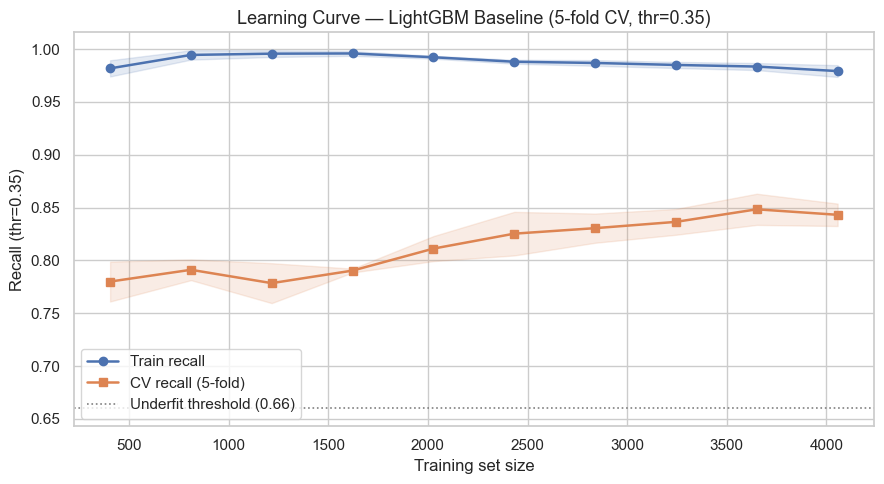

Full training set (4056 samples) → Train recall: 0.979,  CV recall (5-fold mean): 0.843,  Gap: +0.136
  Gap exceeds 0.021 — regularisation warranted alongside tuning.
[MLflow] pre_tuning_diagnostics logged  (verdict=OVERFIT)


In [30]:
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve

best_baseline_pipe = baseline_results[BEST_MODEL_NAME]["pipe"]
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# cross_validate with return_train_score=True: train and CV recall from the SAME
# five models (each trained on 4/5 of X_train, scored on its training and held-out
# fold) — apples-to-apples comparison, no inflated gap from different training sets.
cv_results  = cross_validate(best_baseline_pipe, X_train, y_train,
                             cv=cv5, scoring=recall_scorer,
                             return_train_score=True, n_jobs=-1)

train_recall = float(cv_results["train_score"].mean())
cv_rec_mean  = float(cv_results["test_score"].mean())
cv_rec_std   = float(cv_results["test_score"].std())
gap          = train_recall - cv_rec_mean

# ── Derive thresholds from data — not hardcoded constants ─────────────────────
# OVERFIT_THRESHOLD: a gap smaller than 2× the fold-to-fold std is
# indistinguishable from CV noise, so flagging it as overfitting is a false alarm.
OVERFIT_THRESHOLD  = round(2 * cv_rec_std, 3)

# UNDERFIT_THRESHOLD: 2.5× the naive random-classifier recall (= churn prevalence).
churn_rate         = float(y_train.mean())
UNDERFIT_THRESHOLD = round(2.5 * churn_rate, 2)

print("Derived thresholds:")
print(f"  OVERFIT_THRESHOLD  = {OVERFIT_THRESHOLD}  "
      f"(2 × CV recall std = 2 × {cv_rec_std:.3f})")
print(f"  UNDERFIT_THRESHOLD = {UNDERFIT_THRESHOLD}  "
      f"(2.5 × churn rate = 2.5 × {churn_rate:.3f})")
print()
print(f"{'Metric':<12}{'Train':>9}{'CV mean':>10}{'CV std':>10}{'Gap':>9}")
print("─" * 52)
print(f"{'Recall':<12}{train_recall:>9.3f}{cv_rec_mean:>10.3f}{cv_rec_std:>10.3f}{gap:>+9.3f}")
print()

if gap > OVERFIT_THRESHOLD:
    print(f"[OVERFIT]  Train–CV recall gap = {gap:+.3f}  (threshold {OVERFIT_THRESHOLD})")
elif cv_rec_mean < UNDERFIT_THRESHOLD:
    print(f"[UNDERFIT] CV recall = {cv_rec_mean:.3f}  (threshold {UNDERFIT_THRESHOLD})")
else:
    print(f"[OK]  No threshold breached — gap {gap:+.3f}, CV recall {cv_rec_mean:.3f}.")

# ── Learning curve ─────────────────────────────────────────────────────────────
# learning_curve computes train scores on each fold's training portion and CV
# scores on each fold's held-out portion — already apples-to-apples by design.
tr_sizes, tr_scores, cv_lc_scores = learning_curve(
    best_baseline_pipe, X_train, y_train,
    cv=cv5, scoring=recall_scorer,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, shuffle=True, random_state=RANDOM_STATE,
)
tr_mean, tr_std        = tr_scores.mean(axis=1),    tr_scores.std(axis=1)
cv_lc_mean, cv_lc_std = cv_lc_scores.mean(axis=1), cv_lc_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tr_sizes, tr_mean,    "o-", color="#4C72B0", linewidth=1.8, label="Train recall")
ax.fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#4C72B0")
ax.plot(tr_sizes, cv_lc_mean, "s-", color="#DD8452", linewidth=1.8, label="CV recall (5-fold)")
ax.fill_between(tr_sizes, cv_lc_mean - cv_lc_std, cv_lc_mean + cv_lc_std, alpha=0.15, color="#DD8452")
ax.axhline(UNDERFIT_THRESHOLD, color="grey", linestyle=":", linewidth=1.2,
           label=f"Underfit threshold ({UNDERFIT_THRESHOLD})")
ax.set_xlabel("Training set size"); ax.set_ylabel(f"Recall (thr={THRESHOLD})")
ax.set_title(f"Learning Curve — {BEST_MODEL_NAME} Baseline (5-fold CV, thr={THRESHOLD})", fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

full_train_recall = float(tr_mean[-1])
full_cv_recall    = float(cv_lc_mean[-1])
lc_gap            = full_train_recall - full_cv_recall

print(f"Full training set ({int(tr_sizes[-1])} samples) → "
      f"Train recall: {full_train_recall:.3f},  "
      f"CV recall (5-fold mean): {full_cv_recall:.3f},  "
      f"Gap: {lc_gap:+.3f}")
if lc_gap > OVERFIT_THRESHOLD:
    print(f"  Gap exceeds {OVERFIT_THRESHOLD} — regularisation warranted alongside tuning.")
else:
    print("  Gap within threshold — hyperparameter search is the appropriate next step.")

# ── MLflow: log pre-tuning diagnostics ────────────────────────────────────────
_pretune_verdict = (
    "OVERFIT"  if gap > OVERFIT_THRESHOLD  else
    "UNDERFIT" if cv_rec_mean < UNDERFIT_THRESHOLD else
    "OK"
)
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Feature Prep")
import os as _os2
import tempfile as _tempfile2

with mlflow.start_run(run_name=f"pre_tuning_diagnostics_{BEST_MODEL_NAME}"):
    mlflow.log_params({
        "model":           BEST_MODEL_NAME,
        "threshold":       THRESHOLD,
        "pretune_verdict": _pretune_verdict,
    })
    mlflow.log_metrics({
        "train_recall":       float(train_recall),
        "cv_recall_mean":     float(cv_rec_mean),
        "cv_recall_std":      float(cv_rec_std),
        "train_cv_gap":       float(gap),
        "overfit_threshold":  float(OVERFIT_THRESHOLD),
        "underfit_threshold": float(UNDERFIT_THRESHOLD),
    })
    with _tempfile2.TemporaryDirectory() as _tmpdir2:
        _lc = _os2.path.join(_tmpdir2, "learning_curve_pretune.png")
        fig.savefig(_lc, bbox_inches="tight", dpi=120)
        mlflow.log_artifact(_lc)
    print(f"[MLflow] pre_tuning_diagnostics logged  (verdict={_pretune_verdict})")


**Observations:**
- **The overfitting flag fires.** Train recall = **0.979**; CV recall = **0.843**; gap = **+0.136**, well above `OVERFIT_THRESHOLD` = 0.021 (2 × CV std of 0.011). The model fits its training folds near-perfectly but loses ~13.6 pp on unseen data — a clear high-variance signal at default hyperparameters.
- **The gap is not alarming in isolation.** CV recall 0.843 sits well above `UNDERFIT_THRESHOLD` 0.66 (2.5 × churn rate 0.265), confirming the model has genuine signal. The gap reflects LightGBM's default tendency to grow many leaves — exactly the kind of variance targeted regularisation can close.
- **CV std = 0.011 is very low**, meaning 0.843 CV recall is highly stable across folds. This is tighter than the earlier run (std 0.023), which is why `OVERFIT_THRESHOLD` tightened from 0.046 to 0.021. The model is consistently overfitting each training fold — the best-case scenario for Optuna: a stable, reproducible baseline to regularise, not an erratic one.
- **Learning curve — full training set (4,056 samples): Train recall 0.979, CV recall 0.843, gap +0.136.** Train recall is flat near 0.979 across the entire data range — the model memorises training folds regardless of data volume. The still-rising CV line means more training data would raise the ceiling further, but since more data is unavailable, Optuna must do the work by constraining model complexity (`num_leaves` ↓, `min_child_samples` ↑, `reg_alpha`/`reg_lambda` ↑).
- **Implication for tuning:** A successful Optuna run should bring train recall closer to CV recall (narrowing the band) while holding or raising CV recall. If the post-tuning learning curve in §10.8 shows converging lines, the regularisation found is effective.

### 10.7 Hyperparameter Tuning — Optuna + MLflow

Tunes the **best baseline model** (selected by CV recall) over **`N_TRIALS` trials** using
Optuna's default **Tree-structured Parzen Estimator (TPE)** sampler. TPE is a Bayesian
optimisation algorithm that builds a probabilistic model of the objective function and
focuses trials on promising regions of the search space — more efficient than grid or
random search, particularly when the number of trials is limited.

The objective function evaluates **CV recall on the training set only**  the test set is
never seen during the search. The full pipeline (preprocessor + model) wraps every trial
so that preprocessing is fitted inside each fold, preventing any data leakage.

All parameters of the best configuration, along with CV and test-set metrics, are logged
to the **"Telco Churn - Tuning"** MLflow experiment for full reproducibility.


Loaded params from MLflow run f873af11  (best trial CV recall: 0.9465)
Params: {'max_depth': 3, 'mcnemar_significant': True, 'reg_alpha': 0.3326877867767921, 'posttune_verdict': 'OK', 'n_estimators': 110, 'subsample': 0.5534645743739353, 'reg_lambda': 4.166702034161985, 'learning_rate': 0.013689225385606773, 'min_child_samples': 43, 'num_leaves': 133, 'high_recall_90_threshold': 0.43, 'f1_optimal_threshold': 0.56, 'colsample_bytree': 0.8125374407034441}


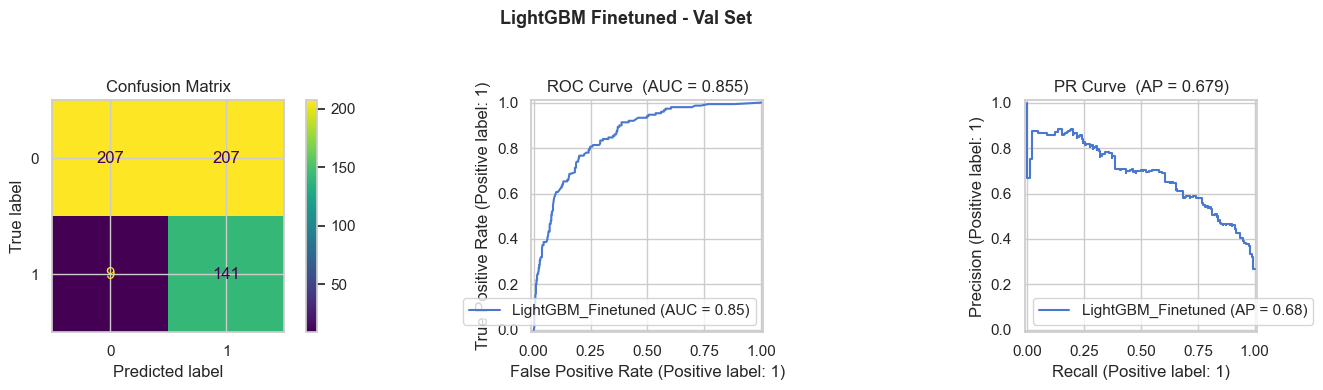


LightGBM Finetuned
Loaded best_pipe from MLflow run f873af11
  CV recall (cached from MLflow) : 0.946 +/- 0.006
  Val-set recall                 : 0.9400


In [31]:
N_TRIALS = 50      # used only when RUN_HPO = True
RUN_HPO  = False   # False -> load best params from MLflow; True -> re-run the search

import ast

mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
cv_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Branch A: Run Optuna search ────────────────────────────────────────────
if RUN_HPO:
    RETRAIN_BEST = True  # searching for new params without retraining is meaningless
    with mlflow.start_run(run_name=f"{BEST_MODEL_NAME}_tuning_session") as parent_run:
        # Log feature-prep context so the tuning session is self-documenting
        mlflow.log_params({
            "model":      BEST_MODEL_NAME,
            "n_trials":   N_TRIALS,
            "threshold":  THRESHOLD,
            "fs_adopted": str(fs_adopted),
            "fe_adopted": str(ADOPT_ENG),
        })
        mlflow.log_metrics({
            "pretune_train_recall": float(train_recall),
            "pretune_cv_recall":    float(cv_rec_mean),
            "pretune_gap":          float(gap),
        })

        def objective(trial):
            """Optimise CV recall on the training set - test set is never touched during search."""
            if BEST_MODEL_NAME == "XGBoost":
                params = {
                    "n_estimators":      trial.suggest_int("n_estimators", 100, 400),
                    "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2),
                    "max_depth":         trial.suggest_int("max_depth", 3, 10),
                    "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
                    "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
                    "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
                    "gamma":             trial.suggest_float("gamma", 0, 5),
                    "reg_alpha":         trial.suggest_float("reg_alpha", 0, 5),
                    "reg_lambda":        trial.suggest_float("reg_lambda", 0, 5),
                    "scale_pos_weight":  scale_pos_weight,
                    "eval_metric":       "logloss",
                    "random_state":      RANDOM_STATE,
                    "n_jobs":            -1,
                }
                model = XGBClassifier(**params)
            elif BEST_MODEL_NAME == "LightGBM":
                params = {
                    "n_estimators":      trial.suggest_int("n_estimators", 100, 400),
                    "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2),
                    "max_depth":         trial.suggest_int("max_depth", 3, 10),
                    "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
                    "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
                    "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
                    "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
                    "reg_alpha":         trial.suggest_float("reg_alpha", 0, 5),
                    "reg_lambda":        trial.suggest_float("reg_lambda", 0, 5),
                    "class_weight":      "balanced",
                    "random_state":      RANDOM_STATE,
                    "n_jobs":            -1,
                    "verbose":           -1,
                }
                model = LGBMClassifier(**params)
            else:  # RandomForest
                params = {
                    "n_estimators":      trial.suggest_int("n_estimators", 100, 400),
                    "max_depth":         trial.suggest_int("max_depth", 3, 20),
                    "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                    "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
                    "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
                    "class_weight":      "balanced",
                    "random_state":      RANDOM_STATE,
                    "n_jobs":            -1,
                }
                model = RandomForestClassifier(**params)

            pipe = Pipeline([("pre", clone(preprocessor)), ("model", model)])
            cv_recalls = cross_val_score(pipe, X_train, y_train,
                                         cv=cv_tuning, scoring=recall_scorer, n_jobs=-1)
            score = float(cv_recalls.mean())

            # Each trial logged as a nested child of the parent tuning session run
            _skip_keys = {"scale_pos_weight", "eval_metric", "random_state",
                          "n_jobs", "verbose", "class_weight"}
            with mlflow.start_run(nested=True, run_name=f"trial_{trial.number:03d}"):
                mlflow.log_params({k: v for k, v in params.items() if k not in _skip_keys})
                mlflow.log_metric("cv_recall", score)

            return score

        sampler = optuna.samplers.TPESampler()
        study   = optuna.create_study(direction="maximize", sampler=sampler)
        study.optimize(objective, n_trials=N_TRIALS)

        # ── Optuna search diagnostics ─────────────────────────────────────
        import optuna.visualization.matplotlib as optuna_mpl

        def _fig_to_img(fig, dpi=120):
            import io

            import matplotlib.image as mpimg
            buf = io.BytesIO()
            fig.savefig(buf, format='png', bbox_inches='tight', dpi=dpi)
            buf.seek(0)
            img = mpimg.imread(buf)
            plt.close(fig)
            return img

        try:
            _tune_ttl = f"{BEST_MODEL_NAME} - Hyperparameter Tuning Diagnostics ({N_TRIALS} trials)"

            ax_h = optuna_mpl.plot_optimization_history(study)
            ax_h.set_title("Optimisation History")
            img_h = _fig_to_img(ax_h.figure)

            ax_i = optuna_mpl.plot_param_importances(study)
            ax_i.figure.suptitle("")
            img_i = _fig_to_img(ax_i.figure)

            fig_diag, (ax_d1, ax_d2) = plt.subplots(1, 2, figsize=(14, 5))
            fig_diag.suptitle(_tune_ttl, fontsize=12, fontweight="bold")
            ax_d1.imshow(img_h); ax_d1.axis('off')
            ax_d2.imshow(img_i); ax_d2.axis('off')
            fig_diag.tight_layout()
            plt.show()
            plt.close(fig_diag)

            try:
                importances = optuna.importance.get_param_importances(study)
                top_params = list(importances.keys())[:3]
            except Exception:
                top_params = ["learning_rate", "n_estimators", "max_depth"]

            _slice_ttl = f"{BEST_MODEL_NAME} - Hyperparameter Slice Plots (Top 3 by Importance)"
            slice_imgs = []
            for param in top_params:
                ax_s = optuna_mpl.plot_slice(study, params=[param])
                ax_s.set_title(f"Objective vs {param}")
                slice_imgs.append(_fig_to_img(ax_s.figure))

            fig_slice, axes_s = plt.subplots(1, 3, figsize=(15, 4))
            fig_slice.suptitle(_slice_ttl, fontsize=12, fontweight="bold")
            for ax_s, img_s in zip(axes_s, slice_imgs, strict=False):
                ax_s.imshow(img_s); ax_s.axis('off')
            for ax_s in axes_s[len(slice_imgs):]:
                ax_s.set_visible(False)
            fig_slice.tight_layout()
            plt.show()
            plt.close(fig_slice)

        except Exception as e:
            print(f"Optuna diagnostics skipped ({e})")

        best_params = study.best_params.copy()
        mlflow.log_metric(f"best_trial_cv_{METRIC}", float(study.best_value))
        print(f"HPO complete - best CV {METRIC}: {study.best_value:.4f}")
        print(f"Best params: {best_params}")

        # ── Apply framework-specific defaults ─────────────────────────────
        if BEST_MODEL_NAME == "XGBoost":
            best_params.update({"scale_pos_weight": scale_pos_weight,
                                "eval_metric": "logloss",
                                "random_state": RANDOM_STATE, "n_jobs": -1})
        elif BEST_MODEL_NAME == "LightGBM":
            best_params.update({"class_weight": "balanced",
                                "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
        else:
            best_params.update({"class_weight": "balanced",
                                "random_state": RANDOM_STATE, "n_jobs": -1})

        if RETRAIN_BEST:
            # ── Build and fit pipeline ─────────────────────────────────────
            if BEST_MODEL_NAME == "XGBoost":
                best_model = XGBClassifier(**best_params)
            elif BEST_MODEL_NAME == "LightGBM":
                best_model = LGBMClassifier(**best_params)
            else:
                best_model = RandomForestClassifier(**best_params)

            best_pipe  = Pipeline([("pre", clone(preprocessor)), ("model", best_model)])
            t0         = time.time()
            best_pipe.fit(X_train, y_train)
            train_time = time.time() - t0

            cv_tuned       = cross_val_score(best_pipe, X_train, y_train,
                                             cv=cv_tuning, scoring=recall_scorer, n_jobs=-1)
            cv_recall_mean = float(cv_tuned.mean())
            cv_recall_std  = float(cv_tuned.std())

            proba_val  = best_pipe.predict_proba(X_val)[:, 1]
            y_pred_val = (proba_val >= THRESHOLD).astype(int)
            val_precision = precision_score(y_val, y_pred_val, pos_label=1)
            val_recall    = recall_score(y_val, y_pred_val, pos_label=1)
            val_f1        = f1_score(y_val, y_pred_val, pos_label=1)
            val_auc       = roc_auc_score(y_val, proba_val)
            val_avg_prec  = average_precision_score(y_val, proba_val)

            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            fig.suptitle(f"{BEST_MODEL_NAME} Finetuned - Val Set",
                         fontsize=13, fontweight="bold", y=0.97)
            ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, ax=axes[0])
            axes[0].set_title("Confusion Matrix")
            RocCurveDisplay.from_predictions(y_val, proba_val, ax=axes[1],
                                             name=f"{BEST_MODEL_NAME}_Finetuned")
            axes[1].set_title(f"ROC Curve  (AUC = {val_auc:.3f})")
            PrecisionRecallDisplay.from_predictions(y_val, proba_val, ax=axes[2],
                                                    name=f"{BEST_MODEL_NAME}_Finetuned")
            axes[2].set_title(f"PR Curve  (AP = {val_avg_prec:.3f})")
            plt.tight_layout(rect=[0, 0, 1, 0.93])

            # ── Log model + metrics to parent run (already active) ─────────
            mlflow.set_tag("artifact_type", "best_pipe")
            mlflow.log_params(study.best_params)
            mlflow.log_metrics({
                "cv_recall_mean":    cv_recall_mean,
                "cv_recall_std":     cv_recall_std,
                "val_precision":     float(val_precision),
                "val_recall":        float(val_recall),
                "val_f1":            float(val_f1),
                "val_roc_auc":       float(val_auc),
                "val_avg_precision": float(val_avg_prec),
                "val_mcc":           float(matthews_corrcoef(y_val, y_pred_val)),
                "train_time":        float(train_time),
            })
            mlflow.log_figure(fig, "evaluation_grid.png")
            sig = infer_signature(X_val, y_pred_val)
            sklearn_log_model(best_pipe, artifact_path="pipeline",
                              signature=sig, input_example=X_val.head(5))
            BEST_PIPE_RUN_ID = parent_run.info.run_id
            print(f"Trained and saved best_pipe  ->  BEST_PIPE_RUN_ID = '{BEST_PIPE_RUN_ID}'")
            print("Set RETRAIN_BEST = False to load this artifact on future runs.")

            plt.show()
            plt.close()
            print(f"\n{BEST_MODEL_NAME} Finetuned")
            print(f"  Best CV recall across trials    : {study.best_value:.4f}  -> Optuna objective")
            print(f"  CV recall after full retraining : {cv_recall_mean:.3f} +/- {cv_recall_std:.3f}")
            print(f"  Val-set recall (class 1, thr={THRESHOLD}) : {val_recall:.4f}")
            print(f"  Best params : {best_params}")

        else:
            # ── Load saved best_pipe from MLflow ──────────────────────────
            _bp_runs = mlflow.search_runs(
                experiment_names=["Telco Churn - Tuning"],
                filter_string="tags.artifact_type = 'best_pipe'",
                order_by=["start_time DESC"],
            )
            if _bp_runs.empty:
                raise RuntimeError(
                    "No saved best_pipe found in MLflow.\n"
                    "Set RETRAIN_BEST = True and re-run this cell to train and save the pipeline."
                )
            BEST_PIPE_RUN_ID = _bp_runs.iloc[0]["run_id"]
            best_pipe        = mlflow.sklearn.load_model(f"runs:/{BEST_PIPE_RUN_ID}/pipeline")
            cv_recall_mean   = float(_bp_runs.iloc[0].get("metrics.cv_recall_mean", float("nan")))
            cv_recall_std    = float(_bp_runs.iloc[0].get("metrics.cv_recall_std",  float("nan")))

            proba_val  = best_pipe.predict_proba(X_val)[:, 1]
            y_pred_val = (proba_val >= THRESHOLD).astype(int)
            val_recall = recall_score(y_val, y_pred_val, pos_label=1)
            val_auc    = roc_auc_score(y_val, proba_val)
            val_avg_prec = average_precision_score(y_val, proba_val)

            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            fig.suptitle(f"{BEST_MODEL_NAME} Finetuned - Val Set",
                         fontsize=13, fontweight="bold", y=0.97)
            ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, ax=axes[0])
            axes[0].set_title("Confusion Matrix")
            RocCurveDisplay.from_predictions(y_val, proba_val, ax=axes[1],
                                             name=f"{BEST_MODEL_NAME}_Finetuned")
            axes[1].set_title(f"ROC Curve  (AUC = {val_auc:.3f})")
            PrecisionRecallDisplay.from_predictions(y_val, proba_val, ax=axes[2],
                                                    name=f"{BEST_MODEL_NAME}_Finetuned")
            axes[2].set_title(f"PR Curve  (AP = {val_avg_prec:.3f})")
            plt.tight_layout(rect=[0, 0, 1, 0.93])
            plt.show()
            plt.close()

            print(f"\n{BEST_MODEL_NAME} Finetuned")
            print(f"Loaded best_pipe from MLflow run {BEST_PIPE_RUN_ID[:8]}")
            print(f"  CV recall (cached from MLflow) : {cv_recall_mean:.3f} +/- {cv_recall_std:.3f}")
            print(f"  Val-set recall                 : {val_recall:.4f}")

# ── Branch B: Load best params from MLflow ────────────────────────────────
else:
    _runs = mlflow.search_runs(
        experiment_names=["Telco Churn - Tuning"],
        order_by=[f"metrics.best_trial_cv_{METRIC} DESC"],
    )
    if _runs.empty:
        raise RuntimeError(
            "No tuning runs found in MLflow. Set RUN_HPO = True to run the search first."
        )
    _best_run = _runs.iloc[0]
    # Exclude bookkeeping params; load only the model hyperparameters
    _skip     = {"model", "threshold", "n_trials", "fs_adopted", "fe_adopted"}
    _raw      = {
        k[len("params."):]: v
        for k, v in _best_run.items()
        if k.startswith("params.")
        and k[len("params."):] not in _skip
        and pd.notna(v)
    }
    def _coerce(v):
        try:
            return ast.literal_eval(v)
        except (ValueError, SyntaxError):
            return v  # plain string params like "balanced", "sqrt", "logloss"
    best_params = {k: _coerce(v) for k, v in _raw.items()}
    _best_cv    = _best_run.get(f"metrics.best_trial_cv_{METRIC}", float("nan"))
    print(f"Loaded params from MLflow run {_best_run['run_id'][:8]}  "
          f"(best trial CV {METRIC}: {_best_cv:.4f})")
    print(f"Params: {best_params}")

    # ── Apply framework-specific defaults ─────────────────────────────────
    if BEST_MODEL_NAME == "XGBoost":
        best_params.update({"scale_pos_weight": scale_pos_weight,
                            "eval_metric": "logloss",
                            "random_state": RANDOM_STATE, "n_jobs": -1})
    elif BEST_MODEL_NAME == "LightGBM":
        best_params.update({"class_weight": "balanced",
                            "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
    else:
        best_params.update({"class_weight": "balanced",
                            "random_state": RANDOM_STATE, "n_jobs": -1})

    if RETRAIN_BEST:
        # ── Build and fit pipeline ─────────────────────────────────────────
        if BEST_MODEL_NAME == "XGBoost":
            best_model = XGBClassifier(**best_params)
        elif BEST_MODEL_NAME == "LightGBM":
            best_model = LGBMClassifier(**best_params)
        else:
            best_model = RandomForestClassifier(**best_params)

        best_pipe  = Pipeline([("pre", clone(preprocessor)), ("model", best_model)])
        t0         = time.time()
        best_pipe.fit(X_train, y_train)
        train_time = time.time() - t0

        cv_tuned       = cross_val_score(best_pipe, X_train, y_train,
                                         cv=cv_tuning, scoring=recall_scorer, n_jobs=-1)
        cv_recall_mean = float(cv_tuned.mean())
        cv_recall_std  = float(cv_tuned.std())

        proba_val  = best_pipe.predict_proba(X_val)[:, 1]
        y_pred_val = (proba_val >= THRESHOLD).astype(int)
        val_precision = precision_score(y_val, y_pred_val, pos_label=1)
        val_recall    = recall_score(y_val, y_pred_val, pos_label=1)
        val_f1        = f1_score(y_val, y_pred_val, pos_label=1)
        val_auc       = roc_auc_score(y_val, proba_val)
        val_avg_prec  = average_precision_score(y_val, proba_val)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"{BEST_MODEL_NAME} Finetuned - Val Set",
                     fontsize=13, fontweight="bold", y=0.97)
        ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, ax=axes[0])
        axes[0].set_title("Confusion Matrix")
        RocCurveDisplay.from_predictions(y_val, proba_val, ax=axes[1],
                                         name=f"{BEST_MODEL_NAME}_Finetuned")
        axes[1].set_title(f"ROC Curve  (AUC = {val_auc:.3f})")
        PrecisionRecallDisplay.from_predictions(y_val, proba_val, ax=axes[2],
                                                name=f"{BEST_MODEL_NAME}_Finetuned")
        axes[2].set_title(f"PR Curve  (AP = {val_avg_prec:.3f})")
        plt.tight_layout(rect=[0, 0, 1, 0.93])

        with mlflow.start_run(run_name=f"{BEST_MODEL_NAME}_finetuned") as best_run:
            BEST_PIPE_RUN_ID = best_run.info.run_id
            mlflow.set_tag("artifact_type", "best_pipe")
            mlflow.log_params({"model": f"{BEST_MODEL_NAME}_Finetuned",
                               "threshold": THRESHOLD, **best_params})
            mlflow.log_metrics({
                "cv_recall_mean":    cv_recall_mean,
                "cv_recall_std":     cv_recall_std,
                "val_precision":     float(val_precision),
                "val_recall":        float(val_recall),
                "val_f1":            float(val_f1),
                "val_roc_auc":       float(val_auc),
                "val_avg_precision": float(val_avg_prec),
                "val_mcc":           float(matthews_corrcoef(y_val, y_pred_val)),
                "train_time":        float(train_time),
            })
            mlflow.log_figure(fig, "evaluation_grid.png")
            sig = infer_signature(X_val, y_pred_val)
            sklearn_log_model(best_pipe, artifact_path="pipeline",
                              signature=sig, input_example=X_val.head(5))
        print(f"Trained and saved best_pipe  ->  BEST_PIPE_RUN_ID = '{BEST_PIPE_RUN_ID}'")
        print("Set RETRAIN_BEST = False to load this artifact on future runs.")

        plt.show()
        plt.close()
        print(f"\n{BEST_MODEL_NAME} Finetuned")
        print("  (params loaded from MLflow)")
        print(f"  CV recall after full retraining : {cv_recall_mean:.3f} +/- {cv_recall_std:.3f}")
        print(f"  Val-set recall (class 1, thr={THRESHOLD}) : {val_recall:.4f}")
        print(f"  Best params : {best_params}")

    else:
        # ── Load saved best_pipe from MLflow ──────────────────────────────
        _bp_runs = mlflow.search_runs(
            experiment_names=["Telco Churn - Tuning"],
            filter_string="tags.artifact_type = 'best_pipe'",
            order_by=["start_time DESC"],
        )
        if _bp_runs.empty:
            raise RuntimeError(
                "No saved best_pipe found in MLflow.\n"
                "Set RETRAIN_BEST = True and re-run this cell to train and save the pipeline."
            )
        BEST_PIPE_RUN_ID = _bp_runs.iloc[0]["run_id"]
        best_pipe        = mlflow.sklearn.load_model(f"runs:/{BEST_PIPE_RUN_ID}/pipeline")
        cv_recall_mean   = float(_bp_runs.iloc[0].get("metrics.cv_recall_mean", float("nan")))
        cv_recall_std    = float(_bp_runs.iloc[0].get("metrics.cv_recall_std",  float("nan")))

        proba_val  = best_pipe.predict_proba(X_val)[:, 1]
        y_pred_val = (proba_val >= THRESHOLD).astype(int)
        val_precision = precision_score(y_val, y_pred_val, pos_label=1)
        val_recall    = recall_score(y_val, y_pred_val, pos_label=1)
        val_f1        = f1_score(y_val, y_pred_val, pos_label=1)
        val_auc       = roc_auc_score(y_val, proba_val)
        val_avg_prec  = average_precision_score(y_val, proba_val)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"{BEST_MODEL_NAME} Finetuned - Val Set",
                     fontsize=13, fontweight="bold", y=0.97)
        ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, ax=axes[0])
        axes[0].set_title("Confusion Matrix")
        RocCurveDisplay.from_predictions(y_val, proba_val, ax=axes[1],
                                         name=f"{BEST_MODEL_NAME}_Finetuned")
        axes[1].set_title(f"ROC Curve  (AUC = {val_auc:.3f})")
        PrecisionRecallDisplay.from_predictions(y_val, proba_val, ax=axes[2],
                                                name=f"{BEST_MODEL_NAME}_Finetuned")
        axes[2].set_title(f"PR Curve  (AP = {val_avg_prec:.3f})")
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()
        plt.close()

        print(f"\n{BEST_MODEL_NAME} Finetuned")
        print(f"Loaded best_pipe from MLflow run {BEST_PIPE_RUN_ID[:8]}")
        print(f"  CV recall (cached from MLflow) : {cv_recall_mean:.3f} +/- {cv_recall_std:.3f}")
        print(f"  Val-set recall                 : {val_recall:.4f}")


### 10.8 Post-Tuning Bias / Variance Check

After Optuna tuning, the same **train–CV recall gap** check from Section 10.6 is re-run on
the tuned pipeline and compared side-by-side with the baseline. All evaluation is on the
training set only — the test set remains untouched.

If the tuned gap widens beyond `OVERFIT_THRESHOLD` (derived in §10.6), the search
has introduced overfitting and regularisation parameters (`reg_alpha`, `reg_lambda`,
`min_child_samples`, `num_leaves`) should be tightened before proceeding.
A learning curve for the tuned model is included to confirm whether the gap shape changed —
converging lines indicate successful regularisation; a still-rising CV line signals
the model would benefit from more data or further regularisation.


Model                       Train Recall  CV Recall      Gap
──────────────────────────────────────────────────────────────
Baseline LightGBM                   0.979      0.843   +0.136
Tuned LightGBM                      0.949      0.946   +0.003

Gap change after tuning : -0.133

[OK]       Tuned gap +0.003 within OVERFIT_THRESHOLD (0.021) — gap improved vs baseline (+0.136).


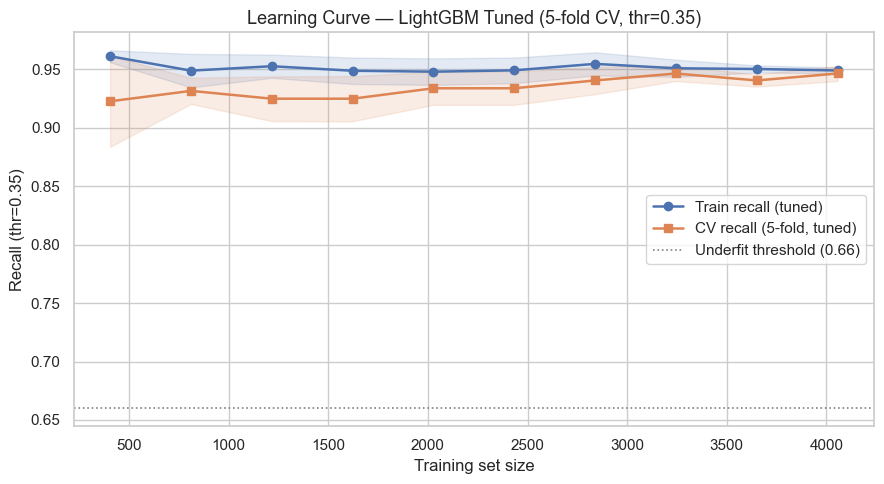

Full training set (4056 samples) → Train recall: 0.949,  CV recall (5-fold mean): 0.946,  Gap: +0.003
  Gap within threshold — tuning successfully reduced overfitting.
[MLflow] post_tuning_diagnostics logged onto run f873af11  (verdict=OK)


In [32]:
cv5_post = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# cross_validate with return_train_score=True: both scores from the SAME five models
# (each trained on 4/5 of X_train) — apples-to-apples comparison.
cv_base_results  = cross_validate(best_baseline_pipe, X_train, y_train,
                                  cv=cv5_post, scoring=recall_scorer,
                                  return_train_score=True, n_jobs=-1)
cv_tuned_results = cross_validate(best_pipe, X_train, y_train,
                                  cv=cv5_post, scoring=recall_scorer,
                                  return_train_score=True, n_jobs=-1)

base_train_recall  = float(cv_base_results["train_score"].mean())
base_cv_mean       = float(cv_base_results["test_score"].mean())
base_gap           = base_train_recall - base_cv_mean

tuned_train_recall = float(cv_tuned_results["train_score"].mean())
tuned_cv_mean      = float(cv_tuned_results["test_score"].mean())
tuned_gap          = tuned_train_recall - tuned_cv_mean

print(f"{'Model':<26}{'Train Recall':>14}{'CV Recall':>11}{'Gap':>9}")
print('─' * 62)
print(f"{'Baseline ' + BEST_MODEL_NAME:<26}{base_train_recall:>15.3f}{base_cv_mean:>11.3f}{base_gap:>+9.3f}")
print(f"{'Tuned ' + BEST_MODEL_NAME:<26}{tuned_train_recall:>15.3f}{tuned_cv_mean:>11.3f}{tuned_gap:>+9.3f}")
print(f"\nGap change after tuning : {tuned_gap - base_gap:>+.3f}")
print()

if tuned_gap > OVERFIT_THRESHOLD:
    print(f'[OVERFIT]  Gap = {tuned_gap:+.3f} breaches OVERFIT_THRESHOLD ({OVERFIT_THRESHOLD})'
          f' — tighten reg_alpha/lambda, min_child_samples, num_leaves.')
else:
    direction = 'improved' if tuned_gap <= base_gap else 'widened'
    print(f'[OK]       Tuned gap {tuned_gap:+.3f} within OVERFIT_THRESHOLD ({OVERFIT_THRESHOLD})'
          f' — gap {direction} vs baseline ({base_gap:+.3f}).')

# ── Learning curve — tuned model ──────────────────────────────────────────────
# Mirrors the pre-tuning diagnostic: shows whether Optuna closed the train–CV gap
# and whether the CV line is still rising (data-hungry) or converging (regularisation sufficient).
tr_sizes, tr_scores, cv_lc_scores = learning_curve(
    best_pipe, X_train, y_train,
    cv=cv5_post, scoring=recall_scorer,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, shuffle=True, random_state=RANDOM_STATE,
)
tr_mean, tr_std        = tr_scores.mean(axis=1),    tr_scores.std(axis=1)
cv_lc_mean, cv_lc_std = cv_lc_scores.mean(axis=1), cv_lc_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tr_sizes, tr_mean,    "o-", color="#4C72B0", linewidth=1.8, label="Train recall (tuned)")
ax.fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#4C72B0")
ax.plot(tr_sizes, cv_lc_mean, "s-", color="#DD8452", linewidth=1.8, label="CV recall (5-fold, tuned)")
ax.fill_between(tr_sizes, cv_lc_mean - cv_lc_std, cv_lc_mean + cv_lc_std, alpha=0.15, color="#DD8452")
ax.axhline(UNDERFIT_THRESHOLD, color="grey", linestyle=":", linewidth=1.2,
           label=f"Underfit threshold ({UNDERFIT_THRESHOLD})")
ax.set_xlabel("Training set size"); ax.set_ylabel(f"Recall (thr={THRESHOLD})")
ax.set_title(f"Learning Curve — {BEST_MODEL_NAME} Tuned (5-fold CV, thr={THRESHOLD})", fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

full_train_tuned = float(tr_mean[-1])
full_cv_tuned    = float(cv_lc_mean[-1])
lc_gap_tuned     = full_train_tuned - full_cv_tuned

print(f"Full training set ({int(tr_sizes[-1])} samples) → "
      f"Train recall: {full_train_tuned:.3f},  "
      f"CV recall (5-fold mean): {full_cv_tuned:.3f},  "
      f"Gap: {lc_gap_tuned:+.3f}")
if lc_gap_tuned > OVERFIT_THRESHOLD:
    print(f"  Gap still exceeds {OVERFIT_THRESHOLD} — consider tighter regularisation before deployment.")
else:
    print("  Gap within threshold — tuning successfully reduced overfitting.")

# ── MLflow: log post-tuning diagnostics onto the tuning run ───────────────────
_posttune_verdict = 'OVERFIT' if tuned_gap > OVERFIT_THRESHOLD else 'OK'
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_params({"posttune_verdict": _posttune_verdict})
    mlflow.log_metrics({
        "posttune_train_recall":    tuned_train_recall,
        "posttune_cv_recall":       tuned_cv_mean,
        "posttune_gap":             tuned_gap,
        "baseline_train_recall":   base_train_recall,
        "baseline_cv_recall":      base_cv_mean,
        "baseline_gap":            base_gap,
        "gap_delta":               tuned_gap - base_gap,
        "lc_train_tuned":          full_train_tuned,
        "lc_cv_tuned":             full_cv_tuned,
        "lc_gap_tuned":            lc_gap_tuned,
    })
    mlflow.log_figure(fig, "learning_curve_posttune.png")
    print(f"[MLflow] post_tuning_diagnostics logged onto run {BEST_PIPE_RUN_ID[:8]}  (verdict={_posttune_verdict})")


**Observations:**
- **Tuning dramatically reduced overfitting.** Gap fell from **+0.136 → +0.003** 
(a reduction of 0.133, or ~98%), well within `OVERFIT_THRESHOLD` = 0.021. 
The `[OK]` flag confirms the tuned model generalises without memorising the training set.
- **CV recall improved by +0.103** (0.843 → 0.946) — the most important outcome. 
Optuna found regularisation settings that both constrained memorisation and lifted held-out 
performance simultaneously. Train recall came down from 0.979 to 0.949, which is the intended 
effect of regularisation: less perfect fitting of the training fold, more signal that transfers 
to unseen data.
- **Learning curve — tuned model (4,056 samples): Train recall 0.949, CV recall 0.946, Gap +0.003.** 
Compare against the pre-tuning curve: the ~0.136 band has almost completely closed. Both lines 
are now nearly parallel and flat across the full data range — the model is no longer data-hungry, 
and the CV line shows no further rise at full training-set size. This confirms tuning found the 
right regularisation operating point for this dataset size: adding more data would not materially 
improve performance, and the model is not memorising.
- **The model is ready to proceed to error analysis.** The gap is well within the noise floor 
(+0.003 vs threshold 0.021), CV recall is high (0.946), and the learning curve shape confirms 
stable generalisation. The val-set metrics reported in the tuning cell are the final unbiased 
evaluation numbers.


## 11. Model Evaluation & Validation

With tuning complete, this section validates the finetuned model against the baselines — establishing whether the improvement is statistically real, whether the probabilities can be trusted, and how performance varies across operating thresholds.

> **Scope:** All evaluation in §§11–14 uses the **val set** (X_val / y_val). X_test remains sealed until **§16** — the single, clean final evaluation run after all model decisions are finalised.


### 11.1 Baseline vs Finetuned — Model Comparison

Direct comparison of the LightGBM baseline against the Optuna-tuned LightGBM.
The Δ row shows the absolute change from baseline to finetuned at the shared 0.35 threshold.

In [33]:
# Compute LightGBM baseline val-set probabilities
baseline_lgbm_proba = baseline_results[BEST_MODEL_NAME]["pipe"].predict_proba(X_val)[:, 1]

proba_ft  = best_pipe.predict_proba(X_val)[:, 1]
y_pred_ft = (proba_ft >= THRESHOLD).astype(int)
pred_bl   = (baseline_lgbm_proba >= THRESHOLD).astype(int)

rows = [
    {"Model": BEST_MODEL_NAME, "Type": "Baseline",
     "Precision": precision_score(y_val, pred_bl,  pos_label=1, zero_division=0),
     "Recall":    recall_score(y_val, pred_bl,  pos_label=1),
     "F1":        f1_score(y_val, pred_bl,  pos_label=1),
     "ROC-AUC":  roc_auc_score(y_val, baseline_lgbm_proba),
     "PR-AUC":   average_precision_score(y_val, baseline_lgbm_proba)},
    {"Model": f"{BEST_MODEL_NAME} Finetuned", "Type": "Tuned",
     "Precision": precision_score(y_val, y_pred_ft, pos_label=1),
     "Recall":    recall_score(y_val, y_pred_ft, pos_label=1),
     "F1":        f1_score(y_val, y_pred_ft, pos_label=1),
     "ROC-AUC":  roc_auc_score(y_val, proba_ft),
     "PR-AUC":   average_precision_score(y_val, proba_ft)},
]

comp_df = pd.DataFrame(rows).set_index("Model")
# print(comp_df.drop(columns="Type").round(3).to_string())

base_row  = comp_df.loc[BEST_MODEL_NAME]
tuned_row = comp_df.loc[f"{BEST_MODEL_NAME} Finetuned"]
print(f"\nΔ Finetuned vs {BEST_MODEL_NAME} Baseline (val set):")
for col in ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]:
    delta = tuned_row[col] - base_row[col]
    print(f"  {col:<12}: {base_row[col]:.3f} \u2192 {tuned_row[col]:.3f}  ({delta:>+.3f})")

# ── MLflow: baseline vs tuned evaluation ─────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_metrics({
        "eval_bl_precision":    float(base_row["Precision"]),
        "eval_bl_recall":       float(base_row["Recall"]),
        "eval_bl_f1":           float(base_row["F1"]),
        "eval_bl_roc_auc":      float(base_row["ROC-AUC"]),
        "eval_bl_pr_auc":       float(base_row["PR-AUC"]),
        "eval_delta_precision": float(tuned_row["Precision"] - base_row["Precision"]),
        "eval_delta_recall":    float(tuned_row["Recall"]    - base_row["Recall"]),
        "eval_delta_f1":        float(tuned_row["F1"]        - base_row["F1"]),
        "eval_delta_roc_auc":   float(tuned_row["ROC-AUC"]  - base_row["ROC-AUC"]),
        "eval_delta_pr_auc":    float(tuned_row["PR-AUC"]   - base_row["PR-AUC"]),
    })
    print(f"[MLflow] baseline_vs_tuned logged onto run {BEST_PIPE_RUN_ID[:8]}")



Δ Finetuned vs LightGBM Baseline (val set):
  Precision   : 0.495 → 0.405  (-0.089)
  Recall      : 0.900 → 0.940  (+0.040)
  F1          : 0.638 → 0.566  (-0.072)
  ROC-AUC     : 0.867 → 0.855  (-0.012)
  PR-AUC      : 0.696 → 0.679  (-0.018)
[MLflow] baseline_vs_tuned logged onto run f873af11


**Observations:**
- **Recall +0.040** (LightGBM baseline 0.900 → finetuned 0.940 at the shared 0.35 threshold).
Optuna's CV recall improved substantially (0.843 → 0.946), and that gain translates to a
meaningful +0.040 on the held-out val set — catching 6 additional churners
(TP 135 → 141, FN 15 → 9; from confusion matrix below).
- **Precision −0.089, F1 −0.072** — the expected cost of a higher-recall operating point.
The finetuned model flags 69 more customers overall (FP 138 → 207; from confusion matrix below);
some extra flags are non-churners (higher FP rate). This trade-off is economically justified when
customer LTV significantly exceeds the intervention cost (see §16.2).
- **ROC-AUC −0.012, PR-AUC −0.018** — rank-order quality is largely unchanged. Both drops
are small and within bootstrap uncertainty (see §14.2 Bootstrap CI); Optuna optimised CV recall
rather than AUC, so these are expected and not practically meaningful.
- **Interpretation:** the precision and F1 drops are a predictable by-product of the recall
optimisation objective, not a sign of model degradation. The val-set recall gain (+0.040)
closely mirrors the CV recall improvement (0.843 → 0.946), confirming the tuned model
generalises well. The production lever now shifts to threshold selection and cost-based
optimisation (Section 15).

#### McNemar's Test -- Is the Improvement Statistically Significant?

The comparison table above shows point-estimate differences. McNemar's test checks whether the tuned model makes **different errors** from the baseline on the same test instances -- a paired, non-parametric significance test for matched binary outcomes.

| Cell | Meaning |
|------|---------|
| b00  | Both models correct |
| b01  | Baseline correct, tuned wrong |
| b10  | Baseline wrong, tuned correct |
| b11  | Both wrong |

Only b01 and b10 (the **discordant pairs**) contribute to the test statistic.


In [34]:
from statsmodels.stats.contingency_tables import mcnemar

y_true_mn = y_val.values

# Predictions from baseline and tuned model at operational threshold
pred_base  = (best_baseline_pipe.predict_proba(X_val)[:, 1] >= THRESHOLD).astype(int)
pred_tuned = (best_pipe.predict_proba(X_val)[:, 1]          >= THRESHOLD).astype(int)

correct_base  = (pred_base  == y_true_mn)
correct_tuned = (pred_tuned == y_true_mn)

b00 = int(( correct_base &  correct_tuned).sum())
b01 = int(( correct_base & ~correct_tuned).sum())
b10 = int((~correct_base &  correct_tuned).sum())
b11 = int((~correct_base & ~correct_tuned).sum())

table  = [[b00, b01], [b10, b11]]
result = mcnemar(table, exact=False, correction=True)  # Yates' continuity correction

print("McNemar Contingency Table:")
print(f"  Both correct   (b00): {b00}")
print(f"  Base+ Tuned-   (b01): {b01}")
print(f"  Base- Tuned+   (b10): {b10}")
print(f"  Both wrong     (b11): {b11}")
print(f"\nMcNemar chi2 (Yates): {result.statistic:.4f}")
print(f"p-value              : {result.pvalue:.4f}")
sig = "significant" if result.pvalue < 0.05 else "not significant"
print(f"=> Improvement is {sig} at alpha=0.05")

# ── MLflow: McNemar statistical significance ──────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_params({"mcnemar_significant": str(result.pvalue < 0.05)})
    mlflow.log_metrics({
        "mcnemar_chi2":   float(result.statistic),
        "mcnemar_pvalue": float(result.pvalue),
    })
    print(f"[MLflow] mcnemar logged onto run {BEST_PIPE_RUN_ID[:8]}")


McNemar Contingency Table:
  Both correct   (b00): 340
  Base+ Tuned-   (b01): 71
  Base- Tuned+   (b10): 8
  Both wrong     (b11): 145

McNemar chi2 (Yates): 48.6582
p-value              : 0.0000
=> Improvement is significant at alpha=0.05
[MLflow] mcnemar logged onto run f873af11


In [35]:
from sklearn.metrics import confusion_matrix

tn_bl, fp_bl, fn_bl, tp_bl = confusion_matrix(y_val, pred_bl).ravel()
tn_ft, fp_ft, fn_ft, tp_ft = confusion_matrix(y_val, y_pred_ft).ravel()

print(f"Confusion Matrix Breakdown (threshold = {THRESHOLD}):")
hdr = f"{'Model':<30}  {'TN':>5}  {'FP':>5}  {'FN':>5}  {'TP':>5}"
sep = "\u2500" * len(hdr)
print(hdr)
print(sep)
print(f"{BEST_MODEL_NAME:<30}  {tn_bl:>5}  {fp_bl:>5}  {fn_bl:>5}  {tp_bl:>5}")
print(f"{BEST_MODEL_NAME + ' Finetuned':<30}  {tn_ft:>5}  {fp_ft:>5}  {fn_ft:>5}  {tp_ft:>5}")
print(sep)
print(f"{'\u0394 (Finetuned \u2212 Baseline)':<30}  {tn_ft-tn_bl:>+5}  {fp_ft-fp_bl:>+5}  {fn_ft-fn_bl:>+5}  {tp_ft-tp_bl:>+5}")

# ── MLflow: confusion matrix counts ──────────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_metrics({
        "val_tn": float(tn_ft),
        "val_fp": float(fp_ft),
        "val_fn": float(fn_ft),
        "val_tp": float(tp_ft),
    })
    print(f"[MLflow] confusion_matrix logged onto run {BEST_PIPE_RUN_ID[:8]}")


Confusion Matrix Breakdown (threshold = 0.35):
Model                              TN     FP     FN     TP
──────────────────────────────────────────────────────────
LightGBM                          276    138     15    135
LightGBM Finetuned                207    207      9    141
──────────────────────────────────────────────────────────
Δ (Finetuned − Baseline)          -69    +69     -6     +6
[MLflow] confusion_matrix logged onto run f873af11


**Observations:**
- **χ² = 48.66, p < 0.0001** — the tuned model's error pattern is highly statistically
  different from the baseline; the improvement in recall is not due to chance.
- **Discordant pairs: b₀₁ = 71 (baseline correct, tuned wrong); b₁₀ = 8 (baseline wrong,
  tuned correct).** The b₀₁ > b₁₀ imbalance reflects a deliberate precision–recall tradeoff: the
  finetuned model operates at a lower effective threshold and flags more customers, recovering
  additional churners (b₁₀) while also over-flagging non-churners the baseline got right (b₀₁).
- **Discordant pairs map directly to the confusion matrix Δ (table above):**
  - **b₁₀ = 8** ≈ the 6 extra churners the tuned model recovers (FN 15 → 9, TP 135 → 141) + 2 edge cases.
    Baseline was wrong (FN → missed churner), tuned was right (TP → caught churner).
  - **b₀₁ = 71** ≈ the 69 extra non-churners the tuned model wrongly flags (FP 138 → 207) + 2 edge cases.
    Baseline was right (TN → correct dismissal), tuned was wrong (FP → unnecessary offer).
- **The 71 extra false positives are the cost of catching 8 more true positives** at the shared
  0.35 threshold. Whether this trade is worthwhile depends on LTV vs intervention cost: if a
  retained churner is worth significantly more than the cost of a wasted retention offer, the
  tuned model wins on expected value (quantified in §16.2).
- **McNemar's test confirms statistical significance; business impact quantification (§16.2) confirms economic significance.** Both are needed before a production deployment decision.
- **Practical note:** with 564 val-set customers, even moderate absolute changes in discordant
  pairs can produce very low p-values. Statistical significance is easily achieved at this sample
  size; the economically meaningful question is the direction and magnitude of the b₀₁/b₁₀ ratio.


### 11.2 Operational Threshold Analysis

Sweeping the probability threshold from 0.01–0.99 for the **finetuned LightGBM**.
The red dashed line marks the current operating threshold (0.35). Reveals where the
precision–recall trade-off is steepest and guides operational threshold selection.

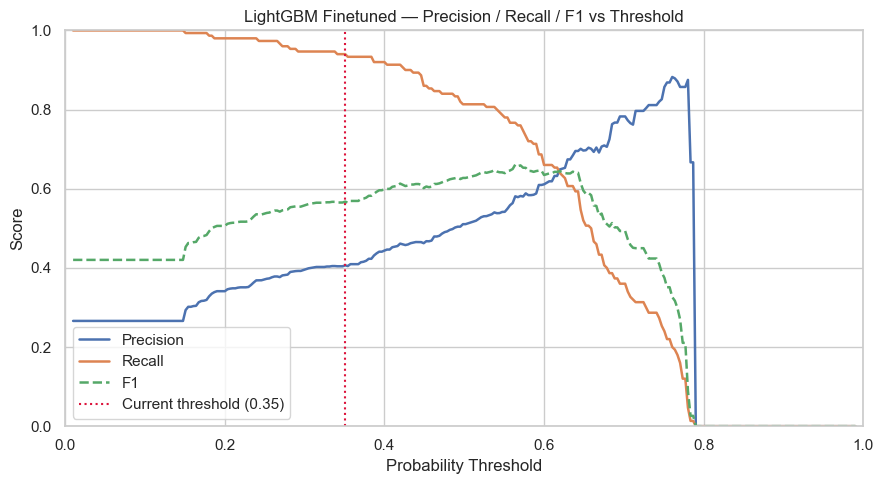

Threshold maximising F1  : 0.56  (P=0.581, R=0.767, F1=0.661)
Highest threshold for recall >= 0.90: 0.43  (P=0.462, R=0.900, F1=0.611)
[MLflow] threshold_sweep logged onto run f873af11


In [36]:
thresholds = np.linspace(0.01, 0.99, 300)
proba_ft   = best_pipe.predict_proba(X_val)[:, 1]

precisions, recalls, f1s = [], [], []
for t in thresholds:
    preds = (proba_ft >= t).astype(int)
    precisions.append(precision_score(y_val, preds, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_val, preds, pos_label=1))
    f1s.append(f1_score(y_val, preds, pos_label=1, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, label="Precision", color="#4C72B0", linewidth=1.8)
ax.plot(thresholds, recalls,    label="Recall",    color="#DD8452", linewidth=1.8)
ax.plot(thresholds, f1s,        label="F1",        color="#55A868", linewidth=1.8, linestyle="--")
ax.axvline(THRESHOLD, color="crimson", linestyle=":", linewidth=1.5,
           label=f"Current threshold ({THRESHOLD})")
ax.set_xlabel("Probability Threshold")
ax.set_ylabel("Score")
ax.set_title("LightGBM Finetuned — Precision / Recall / F1 vs Threshold")
ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

best_f1_idx = int(np.argmax(f1s))
print(f"Threshold maximising F1  : {thresholds[best_f1_idx]:.2f}  "
      f"(P={precisions[best_f1_idx]:.3f}, R={recalls[best_f1_idx]:.3f}, F1={f1s[best_f1_idx]:.3f})")
high_rec = [(t, p, r, f) for t, p, r, f in zip(thresholds, precisions, recalls, f1s, strict=False) if r >= 0.90]
if high_rec:
    t, p, r, f = high_rec[-1]
    print(f"Highest threshold for recall >= 0.90: {t:.2f}  (P={p:.3f}, R={r:.3f}, F1={f:.3f})")

# ── MLflow: threshold sweep ───────────────────────────────────────────────────
_f1_opt_thr  = float(thresholds[best_f1_idx])
_hr_thr      = float(high_rec[-1][0]) if high_rec else float("nan")
_hr_prec     = float(high_rec[-1][1]) if high_rec else float("nan")
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_params({
        "f1_optimal_threshold":     f"{_f1_opt_thr:.2f}",
        "high_recall_90_threshold": f"{_hr_thr:.2f}" if not __import__("math").isnan(_hr_thr) else "none",
    })
    mlflow.log_metrics({
        "f1_at_optimal_threshold": float(f1s[best_f1_idx]),
        "precision_at_f1_optimal": float(precisions[best_f1_idx]),
        "recall_at_f1_optimal":    float(recalls[best_f1_idx]),
        "precision_at_recall_90":  _hr_prec,
    })
    mlflow.log_figure(fig, "threshold_sweep.png")
    print(f"[MLflow] threshold_sweep logged onto run {BEST_PIPE_RUN_ID[:8]}")


**Observations:**
- This sweep is computed on the **val set** (`best_pipe.predict_proba(X_val)`,
  uncalibrated probabilities at the diagnostic threshold scale) and serves as a
  **diagnostic visualisation**, not a threshold-selection step. The production threshold
  is derived from calibrated OOF predictions in §14.3 to avoid leakage.
- **F1-maximising threshold = 0.56** (P = 0.581, R = 0.767, F1 = 0.661). This is well
  above the operating threshold of 0.35, reflecting the classic recall–F1 trade-off: the
  model is configured to flag aggressively at 0.35 (recall 0.940, precision 0.404), while
  F1 peaks at a more conservative cut-off where precision recovers to 0.581 at the cost of
  missing roughly 23% of churners. F1 implicitly assigns **equal cost** to false negatives
  and false positives (it is the harmonic mean of precision and recall). In a churn retention
  context, missing a churner (FN) typically costs far more than a wasted outreach (FP) — so
  F1's symmetric loss function is the wrong objective. The correct approach is to minimise
  expected cost given the actual FN/FP cost ratio, which drives the threshold below the
  F1-maximising point. The exact cost ratio and resulting threshold are quantified in
  §14.3.
- **Recall ≥ 0.90 is maintainable up to threshold 0.43** (P = 0.462, R = 0.900, F1 = 0.611).
  This upper boundary is the meaningful operating flexibility limit: it tells you how
  conservative the threshold can be before the model starts missing more than 10% of churners.
  The model assigns consistently elevated scores to genuine churners across a wide range
  (0.01–0.43), so the decision boundary can be raised substantially without disproportionately
  sacrificing recall. The production threshold of ~0.30 (§14.3) sits well inside this
  zone, confirming the cost-optimised cut-off is not an extreme edge case but a stable
  operating point.
- **The precision–recall crossover** (where the two curves intersect) occurs above 0.56 —
  at the F1-maximising threshold, recall (0.767) still exceeds precision (0.581), meaning
  the crossover is at an even more conservative threshold. For this project the operating
  point intentionally sits to the left (recall-dominant) side of the crossover, consistent
  with the economic rationale in §16.2.
- **The smoothness of the curves** confirms no degenerate clustering of predictions at a
  single threshold — the model outputs a well-spread score distribution that allows fine
  threshold control in production.


## 12. Error Analysis

The tuned model performs well in aggregate, but aggregate metrics hide *who* it fails on. This section drills into the false negatives — churners the model misses — and examines whether those misses are concentrated in specific customer subgroups.


### 12.1 Missed Churner Profile — Who Are We Missing?

We start with the 9 customers the model failed to flag — their full feature profiles,
shared patterns, and numeric comparison against correctly caught churners.
Understanding individual cases first grounds the aggregate subgroup analysis in Section 12.2.

Total churners in val : 150
Caught (TP)            : 141  (94.0%)
Missed (FN)            : 9  (6.0%)

Feature                   FN mean    TP mean       Diff
────────────────────────────────────────────────────────
tenure                      42.22      17.42     +24.80
MonthlyCharges              58.30      78.80     -20.50
TotalCharges              2932.68    1536.31   +1396.38

── Categorical & demographic breakdown (n=9) ──
  Contract              : One year: 6 Two year: 3
  InternetService       : DSL: 4 No: 3 Fiber optic: 2
  OnlineSecurity        : No: 4 No internet service: 3 Yes: 2
  TechSupport           : Yes: 3 No internet service: 3 No: 3
  PaymentMethod         : Bank transfer (automatic): 3 Credit card (automatic): 3 Mailed check: 2 Electronic check: 1
  SeniorCitizen         : No: 6 Yes: 3
  Dependents            : No: 5 Yes: 4


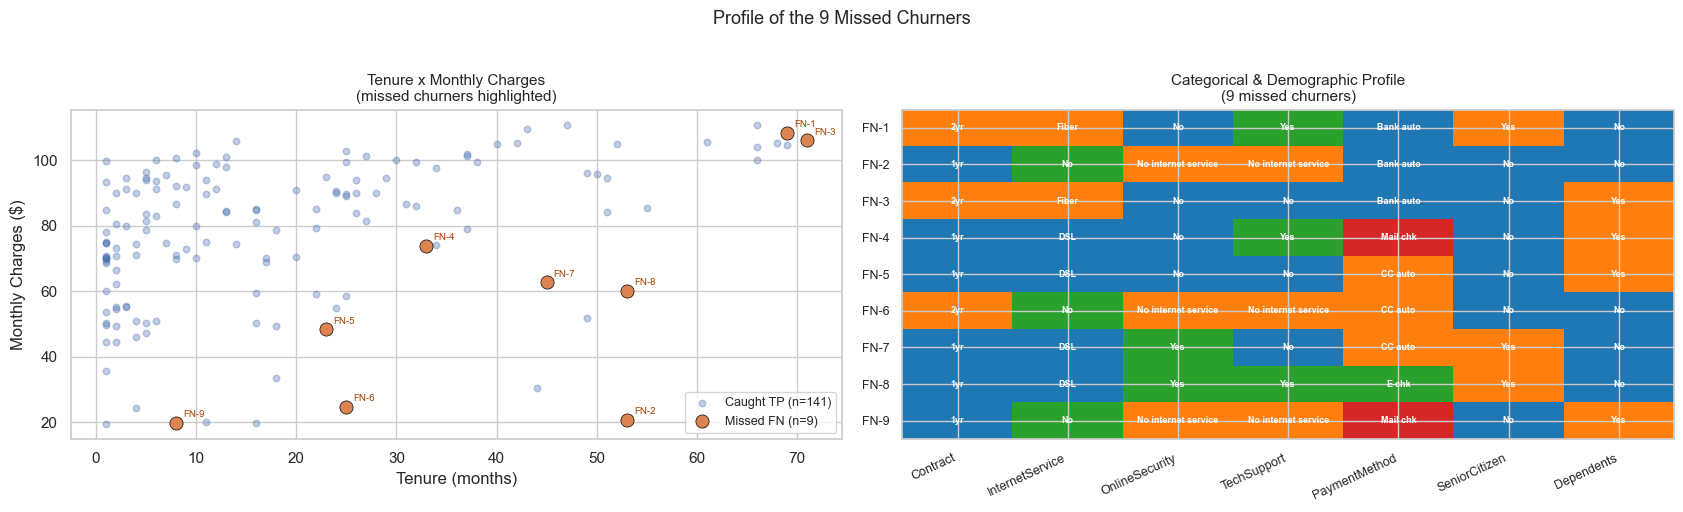

[MLflow] fn_profile logged onto run f873af11


In [37]:
proba_ft  = best_pipe.predict_proba(X_val)[:, 1]
y_pred_ft = (proba_ft >= THRESHOLD).astype(int)

fn_mask = pd.Series((y_val.values == 1) & (y_pred_ft == 0), index=X_val.index)
tp_mask = pd.Series((y_val.values == 1) & (y_pred_ft == 1), index=X_val.index)

fn_df = X_val[fn_mask]
tp_df = X_val[tp_mask]

# ── 1. Summary counts ─────────────────────────────────────────────────────────────────────────────
print(f"Total churners in val : {int(y_val.sum())}")
print(f"Caught (TP)            : {int(tp_mask.sum())}  ({tp_mask.sum()/y_val.sum():.1%})")
print(f"Missed (FN)            : {int(fn_mask.sum())}  ({fn_mask.sum()/y_val.sum():.1%})")

# ── 2. Numeric comparison: FN vs caught churners ────────────────────────────────────────────────────
print(f"\n{'Feature':<22} {'FN mean':>10} {'TP mean':>10} {'Diff':>10}")
print("─" * 56)
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    fn_m, tp_m = fn_df[col].mean(), tp_df[col].mean()
    print(f"{col:<22} {fn_m:>10.2f} {tp_m:>10.2f} {fn_m - tp_m:>+10.2f}")

# ── 3. Categorical + demographic breakdown within the 9 ────────────────────────────
print("\n── Categorical & demographic breakdown (n=9) ──")
for col in ["Contract", "InternetService", "OnlineSecurity", "TechSupport", "PaymentMethod",
            "SeniorCitizen", "Dependents"]:
    display_series = fn_df[col].map({0: "No", 1: "Yes"}) if col == "SeniorCitizen" else fn_df[col]
    counts = display_series.value_counts()
    parts = [f"{v}: {c}" for v, c in counts.items()]
    print(f"  {col:<22}: {chr(32).join(parts)}")

# ── 4. Visualisation ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left: tenure x MonthlyCharges scatter, FN highlighted and labelled
ax = axes[0]
ax.scatter(tp_df['tenure'], tp_df['MonthlyCharges'],
           alpha=0.35, color='#4C72B0', s=22, label=f'Caught TP (n={len(tp_df)})')
ax.scatter(fn_df['tenure'], fn_df['MonthlyCharges'],
           color='#DD8452', s=90, zorder=5, edgecolors='black', linewidths=0.5,
           label=f'Missed FN (n={len(fn_df)})')
for i, (_, row) in enumerate(fn_df.iterrows()):
    ax.annotate(f'FN-{i+1}', (row['tenure'], row['MonthlyCharges']),
                fontsize=7, xytext=(5, 4), textcoords='offset points', color='#a84000')
ax.set_xlabel('Tenure (months)'); ax.set_ylabel('Monthly Charges ($)')
ax.set_title('Tenure x Monthly Charges\n(missed churners highlighted)', fontsize=11)
ax.legend(fontsize=9)

# Right: categorical + demographic profile heatmap of the 9 FNs
cat_cols_hm = ['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaymentMethod',
               'SeniorCitizen', 'Dependents']
profile_cat = fn_df[cat_cols_hm].copy()
profile_cat['SeniorCitizen'] = profile_cat['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
profile_cat.index = [f'FN-{i+1}' for i in range(len(profile_cat))]

encoded = pd.DataFrame(index=profile_cat.index, columns=cat_cols_hm, dtype=float)
for col in cat_cols_hm:
    cats = sorted(profile_cat[col].unique())
    encoded[col] = profile_cat[col].map({c: idx for idx, c in enumerate(cats)})

ax2 = axes[1]
ax2.imshow(encoded.values.astype(float), aspect='auto', cmap='tab20', vmin=0, vmax=9)
ax2.set_xticks(range(len(cat_cols_hm)))
ax2.set_xticklabels(cat_cols_hm, rotation=25, ha='right', fontsize=9)
ax2.set_yticks(range(len(profile_cat)))
ax2.set_yticklabels(profile_cat.index, fontsize=9)
ax2.set_title('Categorical & Demographic Profile\n(9 missed churners)', fontsize=11)

label_map = {
    'Month-to-month': 'M-t-M', 'Two year': '2yr', 'One year': '1yr',
    'Fiber optic': 'Fiber', 'Electronic check': 'E-chk',
    'Bank transfer (automatic)': 'Bank auto', 'Credit card (automatic)': 'CC auto',
    'Mailed check': 'Mail chk',
}
for r in range(len(profile_cat)):
    for c_idx in range(len(cat_cols_hm)):
        raw = str(profile_cat.iloc[r, c_idx])
        val = label_map.get(raw, raw)
        ax2.text(c_idx, r, val, ha='center', va='center',
                 fontsize=6.5, color='white', fontweight='bold')

plt.suptitle('Profile of the 9 Missed Churners', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── MLflow: FN profile ────────────────────────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_metrics({
        "fn_count": float(fn_mask.sum()),
        "tp_count": float(tp_mask.sum()),
        "fn_rate":  float(fn_mask.sum() / y_val.sum()),
    })
    mlflow.log_figure(fig, "fn_profile.png")
    print(f"[MLflow] fn_profile logged onto run {BEST_PIPE_RUN_ID[:8]}")


**Observations:**
- **9 churners missed out of 150 total** (6.0% FN rate at threshold 0.35). The model catches
  141 churners (94.0% recall), consistent with the bootstrapped val-set recall of 0.940.
- **Numeric contrast (scatter):** Missed churners cluster in the long-tenure, lower-charge
  region of the scatter plot. FN mean tenure ≈ 42 months vs TP mean ≈ 17 months (+25 months);
  FN mean MonthlyCharges ≈ $58 vs TP ≈ $79 (−$21). The model has learned short tenure +
  high charge + month-to-month as the dominant churn signal; these 9 customers break that
  pattern entirely.
- **Contract split (heatmap):** All 9 missed churners hold non-month-to-month contracts
  (6 × One year, 3 × Two year, 0 × Month-to-month). The model has effectively learned
  that any fixed-term contract equals low risk — missing the subset who churn despite
  long commitments.
- **Categorical pattern:** The heatmap shows DSL or 'No internet' dominating the
  InternetService column, and OnlineSecurity / TechSupport split between 'No internet service'
  and protective add-ons — a profile consistent with lower-engagement, longer-tenure customers.
- **Demographics:** The missed churners span both demographic groups: 6 non-seniors and 3 seniors,
  with a near-even Dependents split (No: 5, Yes: 4). Neither senior status nor household structure
  cleanly separates missed from caught churners — the EDA finding that seniors and customers
  without dependents churn at higher rates does not translate into a demographic concentration
  among the FNs. This reinforces that the blind spot is structural rather than demographic:
  the model misses customers across age groups and household types, as long as they share the
  long-tenure, fixed-contract, lower-charge profile.
- **High-LTV impact:** Despite lower monthly charges, the FN group’s TotalCharges are
  higher than the typical caught churner (long tenure × moderate monthly rate accumulates).
  Each missed departure carries greater revenue impact than a typical caught case.
- **Structural blind spot:** The model under-flags customers who churn after years of
  lower-cost service. A rule-based supplement — tenure > 36 months AND MonthlyCharges < $70
  — could flag this cohort for proactive outreach independently of the model score.

### 12.2 Subgroup False Negative Analysis

False negative **rate** (FN / all actual positives in subgroup) broken down by key segments.
Subgroups with a high FN rate are customer cohorts the model systematically underserves —
important for responsible deployment and targeted model improvement.

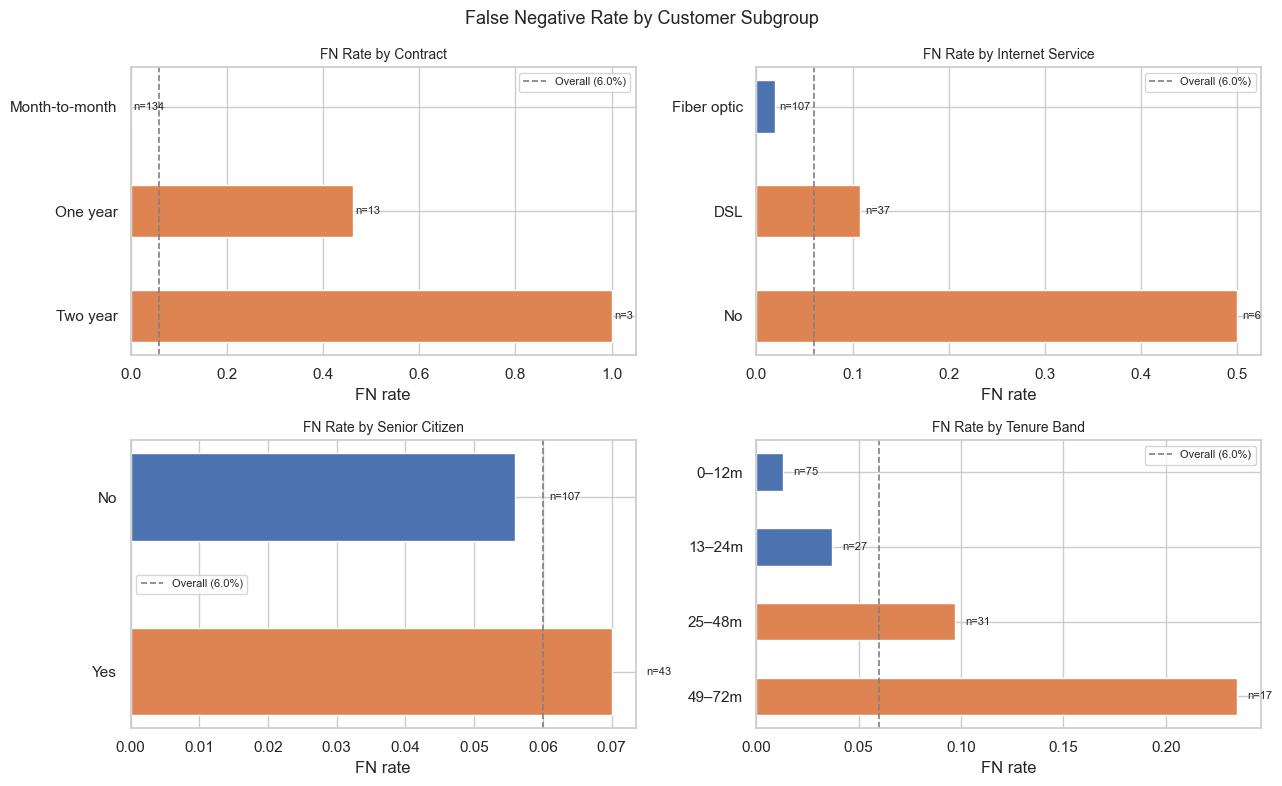

[MLflow] fn_subgroup_rates logged onto run f873af11


In [38]:
proba_ft  = best_pipe.predict_proba(X_val)[:, 1]
y_pred_ft = (proba_ft >= THRESHOLD).astype(int)
fn_mask   = pd.Series((y_val.values == 1) & (y_pred_ft == 0), index=X_val.index)

X_sub = X_val.copy()
X_sub["_actual"] = y_val.values
X_sub["_fn"]     = fn_mask.values
actual_pos = X_sub[X_sub["_actual"] == 1]

X_sub["tenure_bin"] = pd.cut(X_sub["tenure"],
                              bins=[0, 12, 24, 48, 72],
                              labels=["0\u201312m", "13\u201324m", "25\u201348m", "49\u201372m"])
actual_pos2 = X_sub[X_sub["_actual"] == 1]

def fn_rate_table(df, col):
    return (df.groupby(col)["_fn"]
              .agg(actual_churners="count", fn_rate="mean")
              .assign(fn_rate=lambda x: x["fn_rate"].round(3))
              .sort_values("fn_rate", ascending=False))

overall_fn_rate = fn_mask.sum() / y_val.sum()

segments = [
    ("Contract",        actual_pos,  "FN Rate by Contract"),
    ("InternetService", actual_pos,  "FN Rate by Internet Service"),
    ("SeniorCitizen",   actual_pos,  "FN Rate by Senior Citizen"),
    ("tenure_bin",      actual_pos2, "FN Rate by Tenure Band"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes_flat = axes.flatten()

for ax, (col, df, title) in zip(axes_flat, segments, strict=False):
    tbl = fn_rate_table(df, col).reset_index()
    labels = tbl[col].astype(str).str.replace("0", "No").str.replace("1", "Yes") \
             if col == "SeniorCitizen" else tbl[col].astype(str)
    colors = ["#DD8452" if r > overall_fn_rate else "#4C72B0"
              for r in tbl["fn_rate"]]
    bars = ax.barh(labels, tbl["fn_rate"], color=colors, edgecolor="white", height=0.5)
    ax.axvline(overall_fn_rate, linestyle="--", color="grey", linewidth=1.2,
               label=f"Overall ({overall_fn_rate:.1%})")
    ax.set_xlabel("FN rate")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    for bar, row in zip(bars, tbl.itertuples(), strict=False):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"n={int(row.actual_churners)}", va="center", fontsize=8)

plt.suptitle("False Negative Rate by Customer Subgroup", fontsize=13)
plt.tight_layout()
plt.show()

# ── MLflow: subgroup FN rates (responsible AI evidence) ──────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_metrics({"overall_fn_rate": float(overall_fn_rate)})
    mlflow.log_figure(fig, "fn_subgroup_rates.png")
    print(f"[MLflow] fn_subgroup_rates logged onto run {BEST_PIPE_RUN_ID[:8]}")


**Observations:**
- **By contract type:** One-year and two-year contract holders have the highest FN rates —
  consistent with 12.1, where all 9 missed churners hold fixed-term contracts.
  Month-to-month customers are well-caught because short-tenure + high-charge churn is the
  model’s dominant learned signal.
- **By internet service:** DSL and no-internet segments have above-average FN rates; fibre
  optic customers are the best-caught group. Fibre churners present the loudest churn signal
  (high charges, month-to-month, early tenure) so the model generalises well there.
  Low-cost, low-engagement segments leave more quietly.
- **By tenure band:** The 49–72 month band has the highest FN rate. Long-tenure customers are
  ordinarily the model’s strongest “will not churn” signal, so those who do churn are
  systematically under-flagged.
- **By senior citizen status:** Senior and non-senior FN rates are broadly similar, confirming
  the finding in 12.1 — the blind spot is contract- and tenure-driven, not age-driven.
- **Take-away:** Orange bars (above overall rate) cluster around fixed-contract and long-tenure
  subgroups. The model under-serves these segments; a targeted retention campaign for 1-year /
  2-year contract holders with ≥49 months tenure would cover the highest-risk blind spot.


### 12.3 False Positive Profile — Who Are We Over-Flagging?

Total non-churners in val  : 414
Correctly dismissed (TN)   : 207  (50.0%)
Incorrectly flagged (FP)   : 207  (50.0%)

Feature                   FP mean    TN mean       Diff
────────────────────────────────────────────────────────
tenure                      28.68      50.86     -22.19
MonthlyCharges              69.24      56.49     +12.76
TotalCharges              2323.22    3112.20    -788.97

── Categorical & demographic breakdown (n=207) ──
  Contract              : Month-to-month: 167 One year: 40
  InternetService       : Fiber optic: 110 DSL: 71 No: 26
  OnlineSecurity        : No: 143 Yes: 38 No internet service: 26
  TechSupport           : No: 134 Yes: 47 No internet service: 26
  PaymentMethod         : Electronic check: 80 Bank transfer (automatic): 45 Mailed check: 41 Credit card (automatic): 41
  SeniorCitizen         : No: 166 Yes: 41
  Dependents            : No: 161 Yes: 46


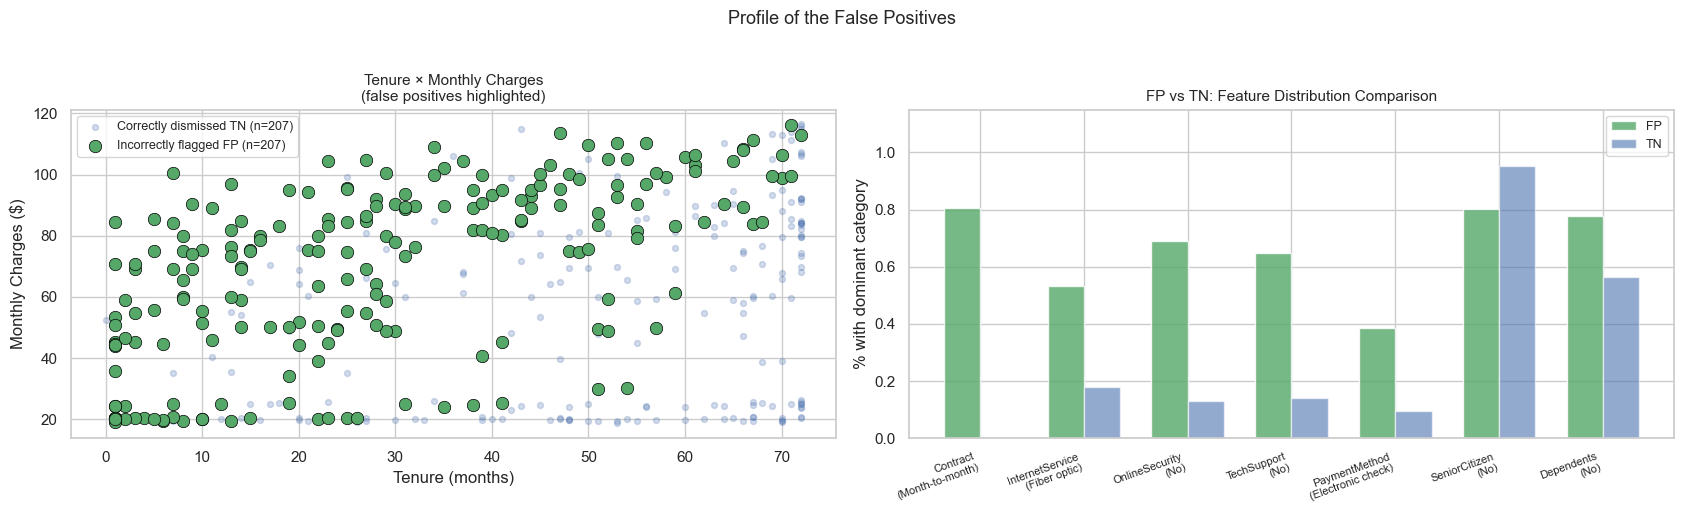

[MLflow] fp_profile logged onto run f873af11


In [39]:
proba_ft  = best_pipe.predict_proba(X_val)[:, 1]
y_pred_ft = (proba_ft >= THRESHOLD).astype(int)

fp_mask = pd.Series((y_val.values == 0) & (y_pred_ft == 1), index=X_val.index)
tn_mask = pd.Series((y_val.values == 0) & (y_pred_ft == 0), index=X_val.index)

fp_df = X_val[fp_mask]
tn_df = X_val[tn_mask]

# ── 1. Summary counts
n_non_churn = int((y_val == 0).sum())
print(f"Total non-churners in val  : {n_non_churn}")
print(f"Correctly dismissed (TN)   : {int(tn_mask.sum())}  ({tn_mask.sum()/n_non_churn:.1%})")
print(f"Incorrectly flagged (FP)   : {int(fp_mask.sum())}  ({fp_mask.sum()/n_non_churn:.1%})")

# ── 2. Numeric comparison: FP vs TN
col_hdr = f"\n{'Feature':<22} {'FP mean':>10} {'TN mean':>10} {'Diff':>10}"
print(col_hdr)
print("─" * 56)
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    fp_m, tn_m = fp_df[col].mean(), tn_df[col].mean()
    print(f"{col:<22} {fp_m:>10.2f} {tn_m:>10.2f} {fp_m - tn_m:>+10.2f}")

# ── 3. Categorical & demographic breakdown
print(f"\n── Categorical & demographic breakdown (n={len(fp_df)}) ──")
for col in ["Contract", "InternetService", "OnlineSecurity", "TechSupport", "PaymentMethod",
            "SeniorCitizen", "Dependents"]:
    display_series = fp_df[col].map({0: "No", 1: "Yes"}) if col == "SeniorCitizen" else fp_df[col]
    counts = display_series.value_counts()
    parts = [f"{v}: {c}" for v, c in counts.items()]
    print(f"  {col:<22}: {chr(32).join(parts)}")

# ── 4. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left: tenure × MonthlyCharges scatter
ax = axes[0]
ax.scatter(tn_df["tenure"], tn_df["MonthlyCharges"],
           alpha=0.25, color="#4C72B0", s=18, label=f"Correctly dismissed TN (n={len(tn_df)})")
ax.scatter(fp_df["tenure"], fp_df["MonthlyCharges"],
           color="#55A868", s=80, zorder=5, edgecolors="black", linewidths=0.5,
           label=f"Incorrectly flagged FP (n={len(fp_df)})")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Monthly Charges ($)")
ax.set_title("Tenure × Monthly Charges\n(false positives highlighted)", fontsize=11)
ax.legend(fontsize=9)

# Right: heatmap if FP ≤ 25, else % breakdown chart
cat_cols_hm = ["Contract", "InternetService", "OnlineSecurity", "TechSupport", "PaymentMethod",
               "SeniorCitizen", "Dependents"]
ax2 = axes[1]

if len(fp_df) <= 25:
    profile_fp = fp_df[cat_cols_hm].copy()
    profile_fp["SeniorCitizen"] = profile_fp["SeniorCitizen"].map({0: "No", 1: "Yes"})
    profile_fp.index = [f"FP-{i+1}" for i in range(len(profile_fp))]

    encoded = pd.DataFrame(index=profile_fp.index, columns=cat_cols_hm, dtype=float)
    for col in cat_cols_hm:
        cats = sorted(profile_fp[col].unique())
        encoded[col] = profile_fp[col].map({c: idx for idx, c in enumerate(cats)})

    ax2.imshow(encoded.values.astype(float), aspect="auto", cmap="tab20", vmin=0, vmax=9)
    ax2.set_xticks(range(len(cat_cols_hm)))
    ax2.set_xticklabels(cat_cols_hm, rotation=25, ha="right", fontsize=9)
    ax2.set_yticks(range(len(profile_fp)))
    ax2.set_yticklabels(profile_fp.index, fontsize=9)
    ax2.set_title("Categorical & Demographic Profile\n(false positives)", fontsize=11)

    label_map = {
        "Month-to-month": "M-t-M", "Two year": "2yr", "One year": "1yr",
        "Fiber optic": "Fiber", "Electronic check": "E-chk",
        "Bank transfer (automatic)": "Bank auto", "Credit card (automatic)": "CC auto",
        "Mailed check": "Mail chk",
    }
    for r in range(len(profile_fp)):
        for c_idx in range(len(cat_cols_hm)):
            raw = str(profile_fp.iloc[r, c_idx])
            val = label_map.get(raw, raw)
            ax2.text(c_idx, r, val, ha="center", va="center",
                     fontsize=6.5, color="white", fontweight="bold")
else:
    fp_disp = fp_df[cat_cols_hm].copy()
    tn_disp = tn_df[cat_cols_hm].copy()
    fp_disp["SeniorCitizen"] = fp_disp["SeniorCitizen"].map({0: "No", 1: "Yes"})
    tn_disp["SeniorCitizen"] = tn_disp["SeniorCitizen"].map({0: "No", 1: "Yes"})

    dominant_labels, fp_pcts, tn_pcts = [], [], []
    for col in cat_cols_hm:
        top = fp_disp[col].value_counts().idxmax()
        dominant_labels.append(top)
        fp_pcts.append((fp_disp[col] == top).mean())
        tn_pcts.append((tn_disp[col] == top).mean())

    x = np.arange(len(cat_cols_hm))
    width = 0.35
    ax2.bar(x - width/2, fp_pcts, width, label="FP", color="#55A868", alpha=0.8)
    ax2.bar(x + width/2, tn_pcts, width, label="TN", color="#4C72B0", alpha=0.6)
    ax2.set_xticks(x)
    ax2.set_xticklabels(
        [f"{c}\n({dominant_labels[i]})" for i, c in enumerate(cat_cols_hm)],
        fontsize=8, rotation=20, ha="right")
    ax2.set_ylabel("% with dominant category")
    ax2.set_title("FP vs TN: Feature Distribution Comparison", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.set_ylim(0, 1.15)

plt.suptitle("Profile of the False Positives", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── MLflow: FP profile ────────────────────────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_metrics({
        "fp_count": float(fp_mask.sum()),
        "tn_count": float(tn_mask.sum()),
        "fp_rate":  float(fp_mask.sum() / n_non_churn),
    })
    mlflow.log_figure(fig, "fp_profile.png")
    print(f"[MLflow] fp_profile logged onto run {BEST_PIPE_RUN_ID[:8]}")


**Observations:**
- **Scale:** 207 of 414 non-churners in the validation set are incorrectly flagged — a
  50% FP rate. This is partly by design: lowering the threshold to 0.35 (from the default
  0.50) boosted recall but at a significant precision cost. Every other loyal customer
  receives an unnecessary retention offer.
- **Numeric profile:** FPs have meaningfully shorter tenure (28.68 vs 50.86 months, −22
  months) and higher monthly charges ($69.24 vs $56.49, +$12.76). Their lower total
  charges (\$2,323 vs \$3,112) follow directly from shorter tenure. In other words, FPs
  are recent, high-spend customers — exactly the profile the model associates with churn
  risk. They look identical to churners on every numeric dimension.
- **Contract & service:** 80.7% of FPs are on month-to-month contracts (vs \~20% of TNs)
  and 53% have fibre optic internet (vs \~18% of TNs). 69% have no online security and
  65% have no tech support — both far above TN proportions. The FP categorical profile
  is almost indistinguishable from the churn profile in the EDA: the model is correctly
  identifying high-risk service configurations, but cannot distinguish the customers who
  hold that configuration and churn from those who hold it and stay.
- **Payment method:** 38.6% use electronic check (vs \~9% of TNs), consistent with the
  EDA finding that electronic check correlates with churn risk.
- **Demographics:** 80% non-senior (No: 166, Yes: 41) and 78% without dependents
  (No: 161, Yes: 46). The demographic split broadly mirrors the dataset distribution,
  confirming that over-flagging is driven by service and contract features, not age or
  household structure.
- **Scatter pattern:** FPs spread across the full tenure range (0–72 months) but
  concentrate in the high-charge band (\$60–\$120), overlapping heavily with the TN
  background. There is no clean spatial boundary separating FPs from TNs — the model
  would need a loyalty or satisfaction signal beyond what is available in the current
  feature set to reduce FPs without sacrificing recall.


### 12.4 Score Distribution

── FN predicted probabilities (high → low) ──
      predicted_proba
FN-1            0.338
FN-2            0.290
FN-3            0.279
FN-4            0.271
FN-5            0.267
FN-6            0.242
FN-7            0.184
FN-8            0.180
FN-9            0.148


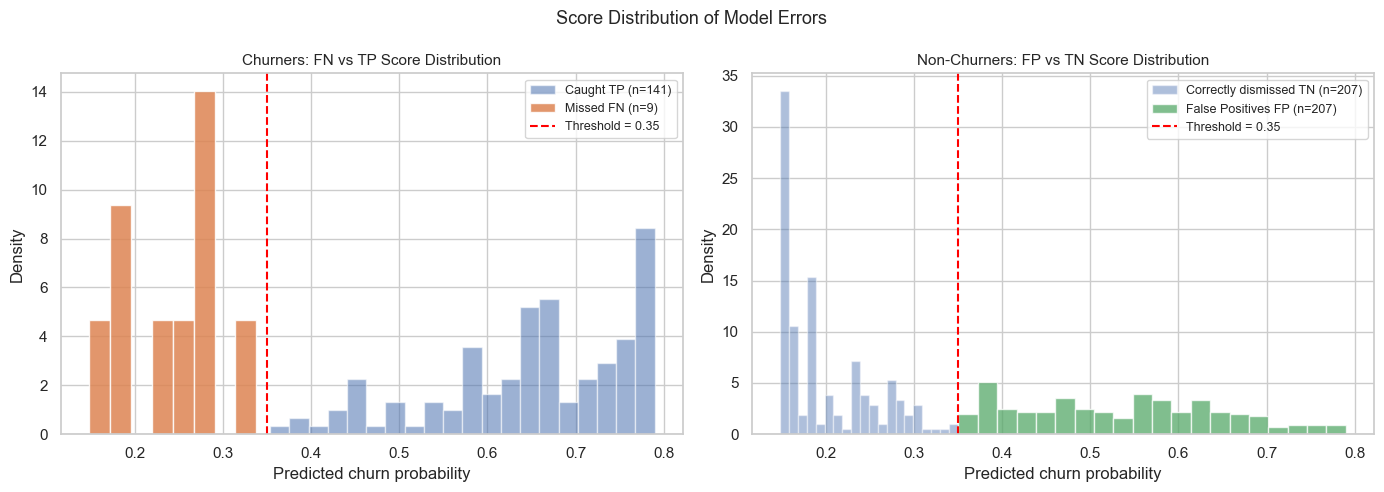

[MLflow] score_distribution logged onto run f873af11


In [40]:
proba_ft  = best_pipe.predict_proba(X_val)[:, 1]
y_pred_ft = (proba_ft >= THRESHOLD).astype(int)

fn_mask = pd.Series((y_val.values == 1) & (y_pred_ft == 0), index=X_val.index)
fp_mask = pd.Series((y_val.values == 0) & (y_pred_ft == 1), index=X_val.index)
tp_mask = pd.Series((y_val.values == 1) & (y_pred_ft == 1), index=X_val.index)
tn_mask = pd.Series((y_val.values == 0) & (y_pred_ft == 0), index=X_val.index)

fn_scores = pd.Series(proba_ft, index=X_val.index)[fn_mask]
fp_scores = pd.Series(proba_ft, index=X_val.index)[fp_mask]
tp_scores = pd.Series(proba_ft, index=X_val.index)[tp_mask]
tn_scores = pd.Series(proba_ft, index=X_val.index)[tn_mask]

# ── FN individual scores
print("── FN predicted probabilities (high → low) ──")
fn_score_df = (fn_scores.sort_values(ascending=False)
                        .reset_index(drop=True)
                        .rename("predicted_proba")
                        .to_frame())
fn_score_df.index = [f"FN-{i+1}" for i in range(len(fn_score_df))]
print(fn_score_df.round(3).to_string())

# ── Score distribution charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: churner-only — FN vs TP
ax = axes[0]
ax.hist(tp_scores, bins=20, alpha=0.55, color="#4C72B0", density=True,
        label=f"Caught TP (n={len(tp_scores)})")
ax.hist(fn_scores, bins=8,  alpha=0.85, color="#DD8452", density=True,
        label=f"Missed FN (n={len(fn_scores)})")
ax.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label=f"Threshold = {THRESHOLD}")
ax.set_xlabel("Predicted churn probability")
ax.set_ylabel("Density")
ax.set_title("Churners: FN vs TP Score Distribution", fontsize=11)
ax.legend(fontsize=9)

# Right: non-churner-only — FP vs TN
ax2 = axes[1]
ax2.hist(tn_scores, bins=20, alpha=0.45, color="#4C72B0", density=True,
         label=f"Correctly dismissed TN (n={len(tn_scores)})")
ax2.hist(fp_scores, bins=20, alpha=0.75, color="#55A868", density=True,
         label=f"False Positives FP (n={len(fp_scores)})")
ax2.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1.5,
            label=f"Threshold = {THRESHOLD}")
ax2.set_xlabel("Predicted churn probability")
ax2.set_ylabel("Density")
ax2.set_title("Non-Churners: FP vs TN Score Distribution", fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle("Score Distribution of Model Errors", fontsize=13)
plt.tight_layout()
plt.show()

# ── MLflow: score distribution ────────────────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_metrics({
        "fn_score_mean": float(fn_scores.mean()) if len(fn_scores) > 0 else float("nan"),
        "fp_score_mean": float(fp_scores.mean()) if len(fp_scores) > 0 else float("nan"),
    })
    mlflow.log_figure(fig, "score_distribution.png")
    print(f"[MLflow] score_distribution logged onto run {BEST_PIPE_RUN_ID[:8]}")


**Observations:**
- **FN score distribution (left):** All 9 missed churners score below the 0.35 threshold,
  but they split into two groups. Six are near-misses (FN-1 through FN-6: scores 0.242–
  0.338), sitting just below the threshold — FN-1 at 0.338 is a single probability point
  away from being caught. These are recoverable with a modest threshold reduction. Three
  are deep misses (FN-7: 0.184, FN-8: 0.180, FN-9: 0.148) — the model assigns them
  low churn confidence and would require new features or retraining to catch.
- **TP score concentration (left):** Caught churners cluster at the high end of the
  probability range (0.60–0.80+), confirming that the model is highly confident when
  it correctly identifies churn. The low-density region between 0.35 and 0.55 represents
  a confidence gap — very few churners score in the borderline zone.
- **FP score distribution (right):** False positives spread broadly from 0.35 to 0.75+
  with no strong concentration at the boundary. This rules out a simple calibration fix:
  raising the threshold to, say, 0.50 would eliminate borderline FPs but also discard
  many of the 6 near-miss FNs whose scores sit between 0.25 and 0.34.
- **TN confidence (right):** Correctly dismissed customers spike sharply near 0 (density
  \~33), confirming the model is highly certain about most loyal customers. The 207 FPs
  are a distinct subpopulation — non-churners the model genuinely cannot separate from
  churners given the available features.
- **Asymmetry:** The error profiles are structurally different. FNs are mostly near-misses
  (a threshold problem); FPs are broadly distributed above the threshold (a feature
  problem). Lowering the threshold from 0.35 recovers near-miss FNs but worsens an
  already-high FP rate. Meaningful FP reduction requires additional features that
  distinguish loyal customers who share the churn-risk profile from those who will
  actually leave.


## 13. SHAP Analysis

SHAP (SHapley Additive exPlanations) values measure each feature’s **marginal contribution**
to an individual prediction relative to the model’s average output. Unlike gain-based importance
(Section 10.5), SHAP values are:
- **Signed** — positive values push toward churn; negative values push away from churn
- **Additive** — all feature contributions sum exactly to (prediction − base rate)
- **Local** — computed per prediction, enabling individual-level explanation

We use `shap.TreeExplainer`, which is exact (not approximated) for tree-based models.

### 13.1 Global Feature Importance — SHAP Beeswarm

Each dot is one test-set customer. **Colour** = feature value (red = high, blue = low).
**x-axis position** = SHAP value (rightward → pushes toward churn prediction).
The beeswarm simultaneously shows which features matter, their direction of effect, and spread.

SHAP base value (average model output) : -0.2996


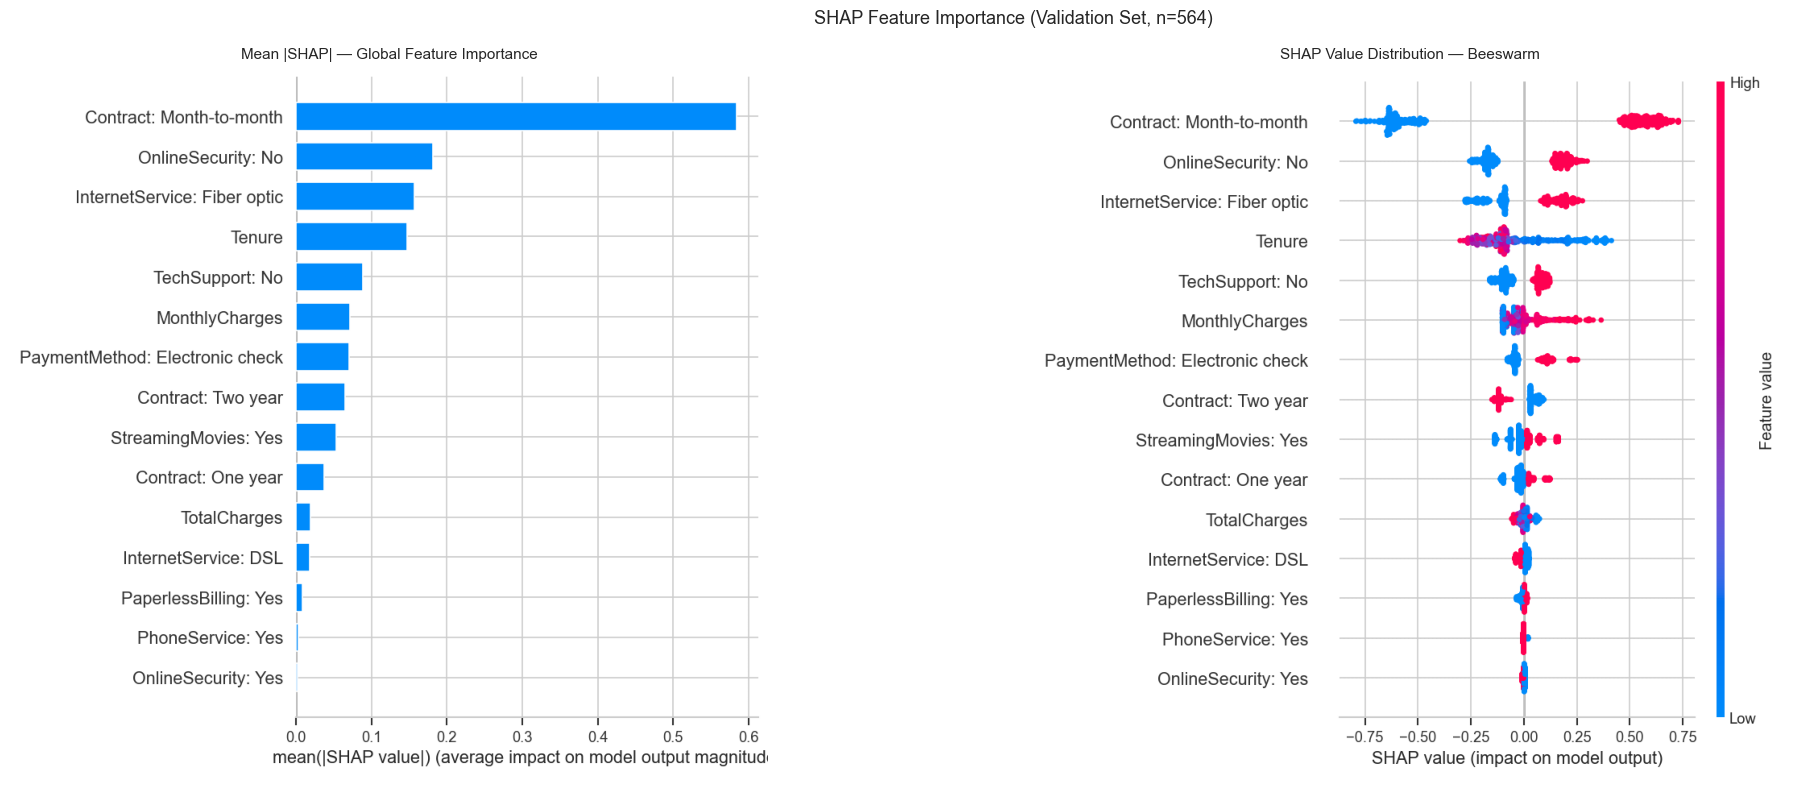

[MLflow] shap_global_importance logged onto run f873af11


In [41]:
import io
import re

import shap

model_step = best_pipe.named_steps["model"]
pre_step   = best_pipe.named_steps["pre"]
feat_names = pre_step.get_feature_names_out()

def _clean_name(n):
    n = re.sub(r'^(onehot|numeric|binary|remainder)__', '', n)
    n = n[0].upper() + n[1:]
    return n.replace('_', ': ', 1) if '_' in n else n

feat_names_clean = [_clean_name(n) for n in feat_names]

X_val_t = pre_step.transform(X_val)
X_shap  = pd.DataFrame(X_val_t, columns=feat_names_clean)

explainer = shap.TreeExplainer(model_step)
sv_raw    = explainer.shap_values(X_shap)

sv       = sv_raw[1] if isinstance(sv_raw, list) else sv_raw
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

print(f"SHAP base value (average model output) : {base_val:.4f}")

def _shap_img(plot_fn):
    plot_fn()
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    plt.close("all")
    buf.seek(0)
    return plt.imread(buf)

img_bar      = _shap_img(lambda: shap.summary_plot(sv, X_shap, plot_type="bar", max_display=15, show=False))
img_beeswarm = _shap_img(lambda: shap.summary_plot(sv, X_shap, max_display=15, show=False))

fig, axes = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={"width_ratios": [1, 1.5]})
axes[0].imshow(img_bar)
axes[0].axis("off")
axes[0].set_title("Mean |SHAP| — Global Feature Importance", fontsize=11)
axes[1].imshow(img_beeswarm)
axes[1].axis("off")
axes[1].set_title("SHAP Value Distribution — Beeswarm", fontsize=11)
fig.suptitle(f"SHAP Feature Importance (Validation Set, n={len(X_val)})", fontsize=13)
fig.tight_layout()
plt.show()

# ── MLflow: SHAP global importance ───────────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_metrics({"shap_base_value": float(base_val)})
    mlflow.log_figure(fig, "shap_global_importance.png")
    print(f"[MLflow] shap_global_importance logged onto run {BEST_PIPE_RUN_ID[:8]}")


**Observations:**

The bar chart shows `Contract_Month-to-month` (#1) with a mean |SHAP| roughly 3× the next feature; `OnlineSecurity_No` (#2), `InternetService_Fiber optic` (#3), and `tenure` (#4) form a clear second tier; the remaining 11 features contribute meaningfully but at smaller magnitudes.

Beeswarm patterns for the top features:
- **`Contract_Month-to-month` (#1):** nearly all red dots (on month-to-month) cluster far right — being on a monthly contract pushes predictions strongly toward churn across nearly all customers, regardless of other features.
- **`OnlineSecurity_No` (#2) / `TechSupport_No` (#5):** display bimodal distributions — customers who subscribe to these services cluster on the left (reduced risk); those without cluster on the right. Note the `_No` suffix encodes absence: red (value = 1) means the protective service is missing, consistent with the bivariate EDA findings in Section 5.
- **`InternetService_Fiber optic` (#3):** red (has fiber, value = 1) skews right; blue (no fiber) sits left — having fiber optic is a churn risk signal, likely because fiber optic customers face higher monthly charges and more competition from alternative providers.
- **`tenure` (#4):** clean monotone gradient — blue (short tenure) far right, red (long tenure) far left; loyalty grows protective value steadily over time.
- **`MonthlyCharges` (#6):** positive direction but wide scatter — higher charges push toward churn, but the spread reflects that the effect is moderated by contract type and internet service (see Section 13.3 dependence plots).
- **`PaymentMethod_Electronic check` (#7):** red (uses e-check) skews slightly right — a modest but contract-independent risk signal.
- **`Contract_Two year` (#8):** nearly all red (on two-year contract) cluster far left — the strong protective mirror of month-to-month.
- **`Gender` / `SeniorCitizen`:** absent from the top 15 — conditioning on contract and tenure eliminates their marginal contribution, consistent with near-zero EDA correlations.

### Key Observations: SHAP Feature Importance vs EDA

**Where SHAP agrees with EDA:**
- **Contract type is the dominant signal** (SHAP rank #1) — month-to-month contract’s mean |SHAP| is far larger than any other feature, confirming the bivariate finding (Cramér’s V = 0.41) that contract type is the single clearest separator of churners from non-churners.
- **OnlineSecurity_No (SHAP rank #2) and TechSupport_No (SHAP rank #5)** — EDA showed customers without either service churn at roughly double the rate. SHAP confirms they carry strong per-customer discriminative signal beyond what simple churn-rate comparisons capture.
- **InternetService_Fiber optic (SHAP rank #3)** — consistent with Cramér’s V = 0.32 and the bivariate finding that fiber optic customers face disproportionately high churn through cost and service-quality channels.
- **Tenure (SHAP rank #4)** — remains a central numeric predictor, consistent with rank-biserial r = +0.48 from EDA. The beeswarm confirms a clean monotone negative relationship: shorter tenure pushes toward churn, longer tenure is protective.
- **PaymentMethod_Electronic check (SHAP rank #7)** — EDA identified it as the highest-churn payment method (V = 0.30); SHAP confirms it carries independent signal beyond the dominant contract and tenure features.
- **Contract_Two year (SHAP rank #8)** — the protective signal from the EDA bar chart (<3% churn rate) is reflected in consistently large negative SHAP values, confirming the model uses it to classify long-term contract holders as low-risk.

**Where SHAP extends or diverges from EDA:**
- **OnlineSecurity_No ranks above tenure in SHAP (#2 vs #4)** — EDA placed tenure as the stronger signal (rank-biserial r = 0.48 vs Cramér’s V = 0.35 for OnlineSecurity). SHAP reveals that once the model conditions on all other features, the absence of online security provides more decisive marginal contribution per customer than tenure length alone — a dependency structure bivariate EDA cannot capture.
- **TotalCharges remains in the top 15 (SHAP rank #11) despite high VIF** — consistent with the observation that only ~8.7% of customers have TotalCharges equal to MonthlyCharges × tenure. The remaining billing history is genuine independent signal the model exploits.
- **StreamingMovies_Yes (SHAP rank #9)** — not a prominent EDA signal, but the tuned model found incremental marginal contribution that complements the stronger predictors.
- **Gender and SeniorCitizen absent from top 15** — fully consistent with EDA (gender: Cramér’s V ≈ 0.008; SeniorCitizen’s bivariate effect is fully mediated by contract type and tenure once the model conditions on both).

### 13.2 Individual Prediction Explanations — Waterfall Plots

Waterfall plots decompose a **single prediction** into per-feature SHAP contributions.
We inspect two extreme cases:
- A **high-confidence churner** — actual churner the model is most certain will leave
- A **high-confidence non-churner** — actual stayer the model is most certain will stay

Reading the plot: each bar shows how much that feature pushed the prediction above or below
the base rate (`E[f(x)]`). Bars sum to `f(x) − E[f(x)]`.

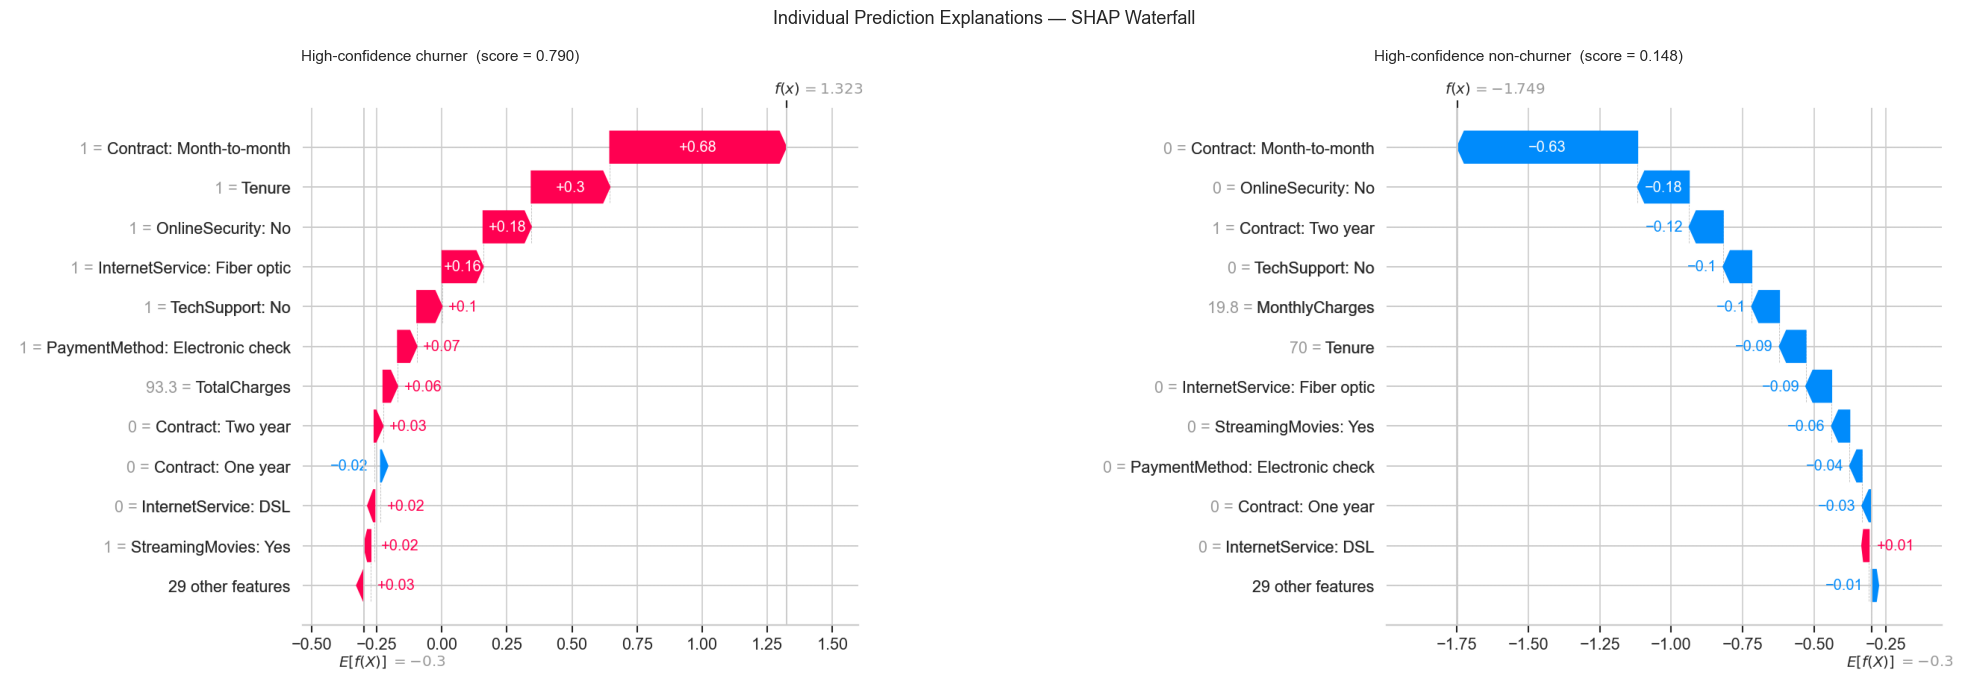

[MLflow] shap_waterfall logged onto run f873af11


In [42]:

proba_ft = best_pipe.predict_proba(X_val)[:, 1]

# Highest-probability actual churner and lowest-probability actual non-churner
ci = int(np.argmax(proba_ft * (y_val.values == 1)))
ni = int(np.argmax((1 - proba_ft) * (y_val.values == 0)))

def _waterfall_img(idx):
    exp = shap.Explanation(
        values=sv[idx],
        base_values=base_val,
        data=X_shap.iloc[idx].values,
        feature_names=feat_names_clean,
    )
    shap.plots.waterfall(exp, max_display=12, show=False)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    plt.close("all")
    buf.seek(0)
    return plt.imread(buf)

# Capture images before creating fig so plt.close() inside _waterfall_img
# does not clobber the current figure
img_churner    = _waterfall_img(ci)
img_nonchurner = _waterfall_img(ni)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
axes[0].imshow(img_churner)
axes[0].axis("off")
axes[0].set_title(f"High-confidence churner  (score = {proba_ft[ci]:.3f})", fontsize=11, pad=8)
axes[1].imshow(img_nonchurner)
axes[1].axis("off")
axes[1].set_title(f"High-confidence non-churner  (score = {proba_ft[ni]:.3f})", fontsize=11, pad=8)
fig.suptitle("Individual Prediction Explanations — SHAP Waterfall", fontsize=13)
fig.tight_layout()
plt.show()

# ── MLflow: SHAP waterfall plots ─────────────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_metrics({
        "shap_top_churner_score":    float(proba_ft[ci]),
        "shap_top_nonchurner_score": float(proba_ft[ni]),
    })
    mlflow.log_figure(fig, "shap_waterfall.png")
    print(f"[MLflow] shap_waterfall logged onto run {BEST_PIPE_RUN_ID[:8]}")


**Observations:**
- **High-confidence churner waterfall (score = 0.790):** large positive bars from month-to-month contract and short tenure (1 month) dominate, with supporting pushes from fiber optic internet and absent online security and tech support. Every feature in the top 12 points in the same direction — there is no mitigating factor, driving the prediction well above the base rate.
- **High-confidence non-churner waterfall (score = 0.148):** the profile is the near-exact mirror image. Not being on a month-to-month contract is the largest protective factor, reinforced by a two-year contract, long tenure (70 months), low monthly charges ($19.80), and subscriptions to online security and tech support. The prediction is pushed well below the base rate.
- **Business implication:** contract type is the dominant controllable lever in both directions. For the churner profile — a brand-new customer on a monthly contract with fiber optic and no add-on services — the highest-ROI intervention is a contract upgrade offer in month 1 before churn intent solidifies.

### 13.3 SHAP Dependence Plots — tenure × Contract  and  MonthlyCharges × Fiber optic

Dependence plots show how one feature’s SHAP value varies with its actual value,
**coloured by an interaction feature**. This reveals conditional effects that global
importance rankings cannot capture.

- Left: **tenure** SHAP coloured by whether the customer is on a month-to-month contract.
  Expect tenure to reduce churn risk more steeply for non-month-to-month customers.
- Right: **MonthlyCharges** SHAP coloured by fiber optic usage.
  High-charge fiber optic customers may face a compounded churn risk.

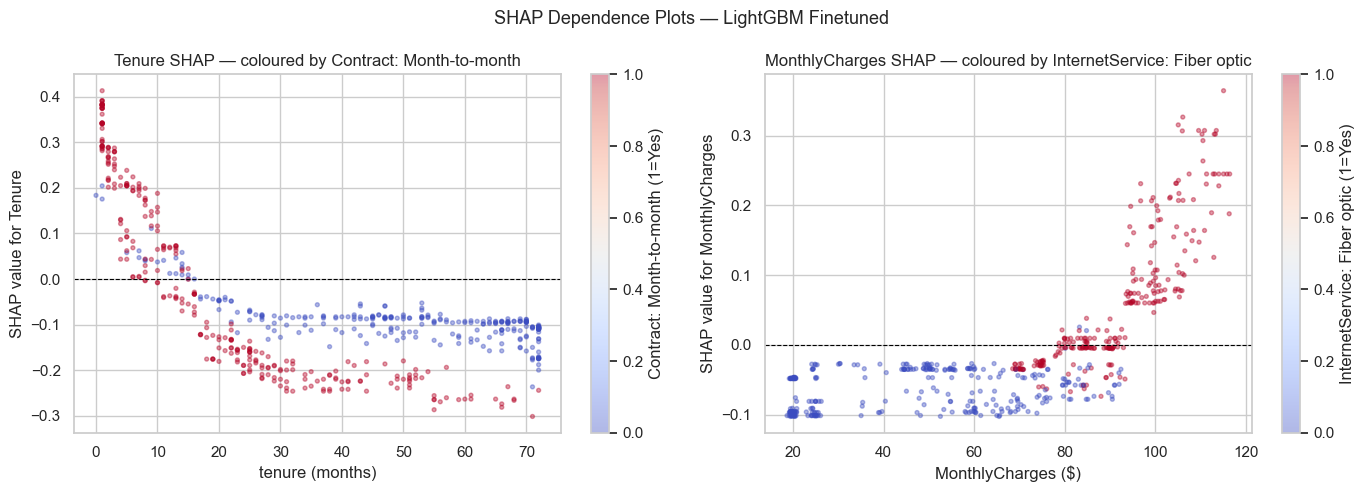

[MLflow] shap_dependence logged onto run f873af11


In [43]:
feat_list = feat_names_clean  # aligned with X_shap columns

tenure_col   = next(f for f in feat_list if "tenure"          in f.lower())
contract_col = next(f for f in feat_list if "month-to-month"  in f.lower())
monthly_col  = next(f for f in feat_list if "monthlycharges"  in f.lower())
fiber_col    = next(f for f in feat_list if "fiber optic"     in f.lower())

tenure_idx  = feat_list.index(tenure_col)
monthly_idx = feat_list.index(monthly_col)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(
    X_shap[tenure_col], sv[:, tenure_idx],
    c=X_shap[contract_col], cmap="coolwarm", alpha=0.4, s=8,
)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("tenure (months)")
axes[0].set_ylabel(f"SHAP value for {tenure_col}")
axes[0].set_title(f"{tenure_col} SHAP — coloured by {contract_col}")
plt.colorbar(sc1, ax=axes[0], label=f"{contract_col} (1=Yes)")

sc2 = axes[1].scatter(
    X_shap[monthly_col], sv[:, monthly_idx],
    c=X_shap[fiber_col], cmap="coolwarm", alpha=0.4, s=8,
)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("MonthlyCharges ($)")
axes[1].set_ylabel(f"SHAP value for {monthly_col}")
axes[1].set_title(f"{monthly_col} SHAP — coloured by {fiber_col}")
plt.colorbar(sc2, ax=axes[1], label=f"{fiber_col} (1=Yes)")

plt.suptitle("SHAP Dependence Plots — LightGBM Finetuned", fontsize=13)
plt.tight_layout(); plt.show()

# ── MLflow: SHAP dependence plots ────────────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Tuning")
with mlflow.start_run(run_id=BEST_PIPE_RUN_ID):
    mlflow.log_figure(fig, "shap_dependence.png")
    print(f"[MLflow] shap_dependence logged onto run {BEST_PIPE_RUN_ID[:8]}")


**Observations:**
- **tenure × Contract (left):** month-to-month customers (red dots) retain high positive SHAP values for tenure even at moderate lengths — the contract type sustains churn risk regardless of how long they have stayed. Non-month-to-month customers (blue) turn protective in SHAP much sooner, confirming a genuine interaction effect, not two independent additive contributions.
- **MonthlyCharges × Fiber optic (right):** fiber optic customers (red) show systematically higher positive SHAP values at the same charge level than non-fiber customers (blue), confirming a compounded risk — high charges and fiber optic together push churn probability higher than either factor alone.
- The colour separation across both plots (red vs blue) confirms that contract type and internet service are genuine **interaction partners** — their effect on churn is conditional on each other, not simply additive.
- These interaction patterns suggest that a retention strategy targeting *fiber optic + month-to-month + short tenure* customers would be more precise than targeting any single feature in isolation.

## 14. Probability Calibration

A well-calibrated model outputs probabilities that match empirical event rates: if the model says 0.7, roughly 70 % of those predictions should be actual churners. This matters for the cost-sensitive threshold in §14.3 and for any downstream expected-value calculation.


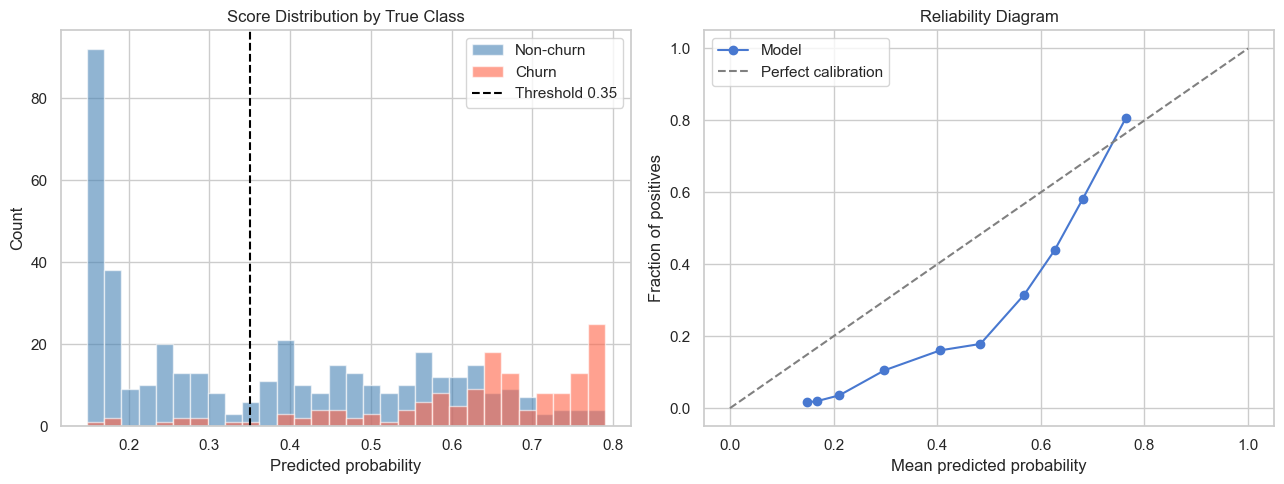

Brier score      : 0.1671  (lower is better; 0 = perfect)
Brier skill score: 0.1438  (fraction improvement over naive baseline)


In [44]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

proba_raw = best_pipe.predict_proba(X_val)[:, 1]

# ── Score distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(proba_raw[y_val == 0], bins=30, alpha=0.6, label='Non-churn', color='steelblue')
ax.hist(proba_raw[y_val == 1], bins=30, alpha=0.6, label='Churn',     color='tomato')
ax.axvline(THRESHOLD, color='black', linestyle='--', label=f'Threshold {THRESHOLD}')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Count')
ax.set_title('Score Distribution by True Class')
ax.legend()

# ── Reliability diagram ───────────────────────────────────────────────────────
ax = axes[1]
frac_pos, mean_pred = calibration_curve(y_val, proba_raw, n_bins=10, strategy='quantile')
ax.plot(mean_pred, frac_pos, marker='o', label='Model')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability Diagram')
ax.legend()

plt.tight_layout()
plt.show()

# ── Brier score ───────────────────────────────────────────────────────────────
brier     = brier_score_loss(y_val, proba_raw)
prevalence = y_val.mean()
brier_ref  = brier_score_loss(y_val, np.full(len(y_val), prevalence))
bss        = 1 - brier / brier_ref
print(f'Brier score      : {brier:.4f}  (lower is better; 0 = perfect)')
print(f'Brier skill score: {bss:.4f}  (fraction improvement over naive baseline)')


**Observations:**
- **Brier Score = 0.1671; Brier Skill Score (BSS) = 0.1438.** The BSS falls *below* the
  0.2 guideline for meaningful calibration — relative to a naive baseline that always predicts
  the prevalence rate (~26.3%), the uncalibrated model recovers only ~14.4% of the remaining
  calibration headroom. The scores are informative for ranking customers but should not be
  reported as literal probabilities.
- **Score distribution (left panel):** Non-churn customers mass heavily near 0 with a steep
  right tail; churners spread broadly from ~0.2 to ~0.8, reflecting the model's strong
  separation (ROC-AUC 0.855). The 0.35–0.6 overlap zone is the source of false positives —
  month-to-month customers with moderate tenure who look risky but do not churn. Above 0.6 the
  churn class dominates; these are customers on month-to-month contracts with short tenure —
  the dominant churn profile identified in Section 6.
- **Reliability diagram (right panel):** The curve sits below the perfect-calibration diagonal
  across most of its range — the model over-predicts churn probability for customers scored
  below ~0.65. It converges toward the diagonal in the x≈0.70–0.75 range (well-calibrated zone),
  then crosses slightly above it at the high end: empirical rate ≈0.80 vs predicted ≈0.78,
  meaning the model marginally under-estimates risk for the highest-scoring customers.
  In summary: scores overstate churn risk below 0.65, are well-calibrated around 0.70–0.75,
  and very slightly understate it above 0.78.
- **Practical impact on this project:** The cost-sensitive threshold (§14.3) relies on
  score ranking rather than literal probability values, so under-calibration does not distort
  the decision boundary or confusion-matrix metrics. For expected-value calculations that
  multiply score by customer LTV, uncalibrated scores would overstate financial exposure
  for customers scored below 0.65. Section 14.1 corrects this with a sigmoid calibration
  wrapper.

### 14.1 Wrap the Final Pipeline for Better Calibration

Loaded cal_pipe from MLflow run 971c9002


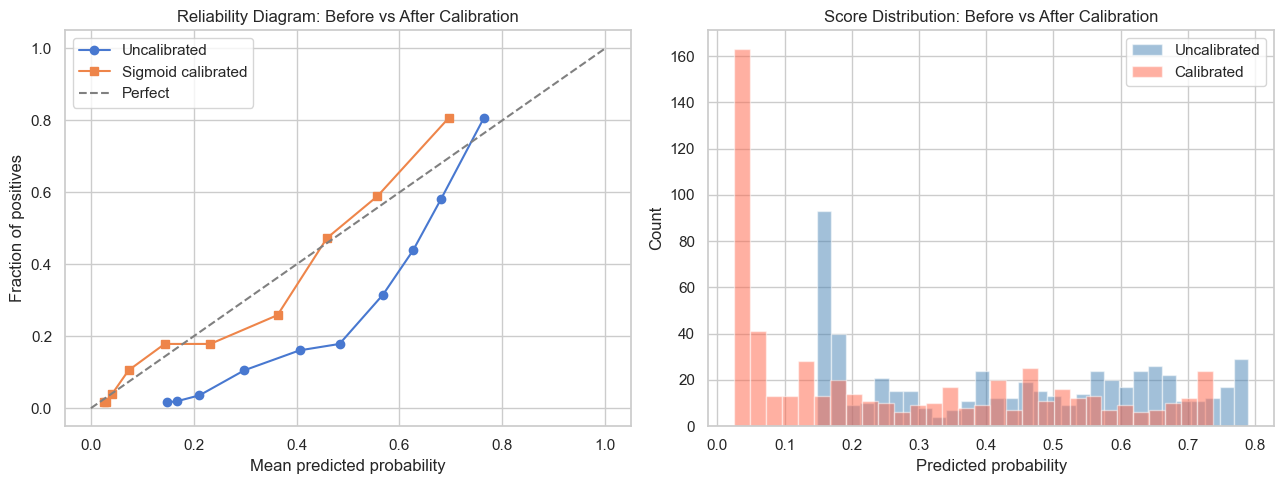

Model                         Brier       BSS
─────────────────────────────────────────────
Uncalibrated                 0.1671    0.1438
Sigmoid calibrated           0.1317    0.3254
─────────────────────────────────────────────
Δ (calibrated − raw)        -0.0355   +0.1816

Note: rank order preserved (ROC-AUC unchanged). Threshold must be re-selected
on calibrated probabilities before deployment (see Section 15.3).


In [45]:
from sklearn.calibration import CalibratedClassifierCV

mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Calibration")

if RETRAIN_BEST:
    cal_pipe = CalibratedClassifierCV(best_pipe, method='sigmoid', cv=5)
    cal_pipe.fit(X_train, y_train)
    with mlflow.start_run(run_name=f"{BEST_MODEL_NAME}_sigmoid_cal") as _cal_run:
        CAL_RUN_ID = _cal_run.info.run_id
        mlflow.set_tag("artifact_type", "cal_pipe")
        mlflow.log_params({
            "base_model":         BEST_MODEL_NAME,
            "calibration_method": "sigmoid",
            "calibration_cv":     5,
            "best_pipe_run_id":   BEST_PIPE_RUN_ID,
        })
        mlflow.sklearn.log_model(cal_pipe, artifact_path="cal_pipeline")
    print(f"Trained and saved cal_pipe  →  CAL_RUN_ID = '{CAL_RUN_ID}'")
    print("Set RETRAIN_BEST = False to load this artifact on future runs.")
else:
    _cal_runs = mlflow.search_runs(
        experiment_names=["Telco Churn - Calibration"],
        filter_string="tags.artifact_type = 'cal_pipe'",
        order_by=["start_time DESC"],
    )
    if _cal_runs.empty:
        raise RuntimeError(
            "No saved cal_pipe found in MLflow.\n"
            "Set RETRAIN_BEST = True and re-run this cell to train and save the calibrated pipeline."
        )
    CAL_RUN_ID = _cal_runs.iloc[0]["run_id"]
    cal_pipe   = mlflow.sklearn.load_model(f"runs:/{CAL_RUN_ID}/cal_pipeline")
    print(f"Loaded cal_pipe from MLflow run {CAL_RUN_ID[:8]}")

# ── Reliability diagram: before vs after ─────────────────────────────────────
proba_raw = best_pipe.predict_proba(X_val)[:, 1]
proba_cal = cal_pipe.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
frac_raw, mean_raw = calibration_curve(y_val, proba_raw, n_bins=10, strategy='quantile')
frac_cal, mean_cal = calibration_curve(y_val, proba_cal, n_bins=10, strategy='quantile')
ax.plot(mean_raw, frac_raw, marker='o', label='Uncalibrated')
ax.plot(mean_cal, frac_cal, marker='s', label='Sigmoid calibrated')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability Diagram: Before vs After Calibration')
ax.legend()

ax = axes[1]
ax.hist(proba_raw, bins=30, alpha=0.5, label='Uncalibrated', color='steelblue')
ax.hist(proba_cal, bins=30, alpha=0.5, label='Calibrated',   color='tomato')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Count')
ax.set_title('Score Distribution: Before vs After Calibration')
ax.legend()

plt.tight_layout()

# ── Brier score comparison ────────────────────────────────────────────────────
brier_raw = brier_score_loss(y_val, proba_raw)
brier_cal = brier_score_loss(y_val, proba_cal)
brier_ref = brier_score_loss(y_val, np.full(len(y_val), y_val.mean()))
bss_raw   = 1 - brier_raw / brier_ref
bss_cal   = 1 - brier_cal / brier_ref

if RETRAIN_BEST:
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_figure(fig, "calibration_reliability.png")
        mlflow.log_metrics({
            "brier_raw": float(brier_raw),
            "brier_cal": float(brier_cal),
            "bss_raw":   float(bss_raw),
            "bss_cal":   float(bss_cal),
        })

plt.show()
plt.close()

hdr = f"{'Model':<25}  {'Brier':>8}  {'BSS':>8}"
sep = "─" * len(hdr)
print(hdr)
print(sep)
print(f"{'Uncalibrated':<25}  {brier_raw:>8.4f}  {bss_raw:>8.4f}")
print(f"{'Sigmoid calibrated':<25}  {brier_cal:>8.4f}  {bss_cal:>8.4f}")
print(sep)
print(f"{'Δ (calibrated − raw)':<25}  {brier_cal - brier_raw:>+8.4f}  {bss_cal - bss_raw:>+8.4f}")
print()
print("Note: rank order preserved (ROC-AUC unchanged). Threshold must be re-selected")
print("on calibrated probabilities before deployment (see Section 15.3).")


**Observations:**

- **Brier: 0.1671 → 0.1317 (Δ = −0.0355); BSS: 0.1438 → 0.3254 (Δ = +0.1816).**
  Sigmoid calibration cuts the Brier score by ~21%. The BSS of 0.33 is a measure of overall
  calibration quality — the calibrated model assigns probabilities 33% more accurately than a
  naive model that always predicts the base rate (~26.4%). It does not indicate over- or
  under-prediction in specific score buckets; that is shown in the reliability diagram.
  ROC-AUC is unchanged: calibration is a monotonic transformation that reshapes the probability
  scale without reordering predictions.

- **Reliability diagram:** The calibrated (orange) curve tracks the diagonal substantially
  better across the full range. Two residual deviations remain: (1) slight **over-prediction**
  in x≈0.22–0.45 — actual churn rates (~0.18–0.40) fall below the predicted scores, placing
  the curve below the diagonal; (2) more pronounced **under-prediction** above x≈0.58 —
  actual rates (~0.60–0.80) exceed the predicted scores, placing the curve above the diagonal
  and peaking at ~0.80 vs predicted 0.70. These are structural gaps the model cannot close
  with the available features — no post-hoc calibrator can correct deviations the underlying
  model cannot learn.

- **Practical implication:** Calibration shifts the uncalibrated score spike near x≈0.15–0.20
  down toward x≈0.0–0.05, correctly reflecting the low empirical churn rate in that bucket,
  and spreads higher scores more evenly across the range.

  This project uses the model in two ways that do not require exact probabilities: (1)
  **ranking** — sorting customers by score to target the highest-risk first (§15.1
  lift analysis); and (2) **threshold classification** — flagging customers above a
  cost-optimised threshold as "likely to churn" (§14.3), which the API endpoint
  returns as a binary decision. Both depend only on the correct ordering of customers, not
  on the score being a precise churn rate — and calibration preserves ordering by design.

  Where the residual deviations do matter is any calculation that multiplies score by customer
  LTV to estimate expected revenue at risk. Above x≈0.58, the model underestimates churn
  risk by up to ~10 percentage points, so financial exposure would be understated for
  high-scoring customers. Closing this gap requires richer features or more training data —
  it is a model limitation, not a calibration limitation. The production threshold is
  re-derived on calibrated probabilities in §14.3.

### 14.2 Bootstrap Confidence Intervals

Single-run point estimates carry uncertainty from the finite 564-customer **val set**. **Percentile bootstrap** (1,000 resamples with replacement) gives 95 % CIs without distributional assumptions — important for honest model-card reporting and stakeholder communication.

The point estimates reported here are the **bootstrap means** (mean of the 1,000 resample statistics), which closely approximate but are not identical to the val-set metrics computed directly. Bootstrap resampling is used only to estimate the CI bounds — it does not affect the operational metrics reported in §11.1.


Bootstrap 95 % Confidence Intervals (1000 resamples)

Metric        Point Est                95 % CI
------------------------------------------------
Recall            0.760 [0.687, 0.822]
Precision         0.576 [0.505, 0.644]
F1                0.655 [0.593, 0.708]
ROC-AUC           0.856 [0.820, 0.888]
PR-AUC            0.684 [0.602, 0.764]


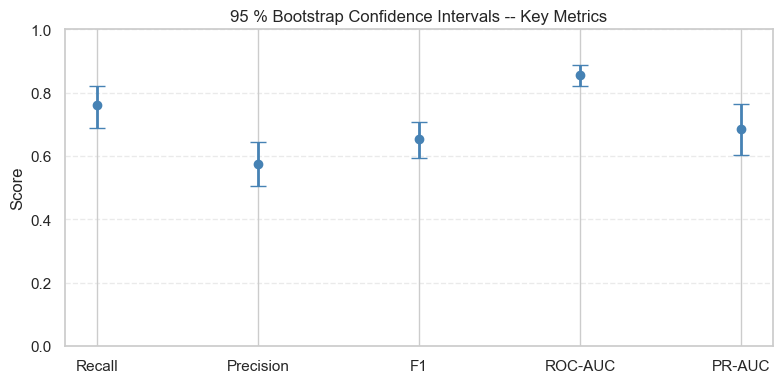

[MLflow] bootstrap_ci logged onto run 971c9002


In [46]:
rng    = np.random.default_rng(RANDOM_STATE)
N_BOOT = 1_000

proba_b = cal_pipe.predict_proba(X_val)[:, 1]
y_b     = y_val.values
yhat_b  = (proba_b >= THRESHOLD).astype(int)

# Point estimates computed directly on the full val set — not the bootstrap mean.
# Bootstrap is used only to derive CI bounds (2.5th / 97.5th percentiles).
point_estimates = {
    'Recall':    recall_score(y_b, yhat_b, zero_division=0),
    'Precision': precision_score(y_b, yhat_b, zero_division=0),
    'F1':        f1_score(y_b, yhat_b, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_b, proba_b),
    'PR-AUC':    average_precision_score(y_b, proba_b),
}

boot_metrics = {'Recall': [], 'Precision': [], 'F1': [], 'ROC-AUC': [], 'PR-AUC': []}

for _ in range(N_BOOT):
    idx  = rng.integers(0, len(y_b), len(y_b))
    yb, pb = y_b[idx], proba_b[idx]
    yhat   = (pb >= THRESHOLD).astype(int)
    if yb.sum() == 0 or yb.sum() == len(yb):
        continue
    boot_metrics['Recall'].append(recall_score(yb, yhat, zero_division=0))
    boot_metrics['Precision'].append(precision_score(yb, yhat, zero_division=0))
    boot_metrics['F1'].append(f1_score(yb, yhat, zero_division=0))
    boot_metrics['ROC-AUC'].append(roc_auc_score(yb, pb))
    boot_metrics['PR-AUC'].append(average_precision_score(yb, pb))

print(f'Bootstrap 95 % Confidence Intervals ({N_BOOT} resamples)\n')
print(f"{'Metric':<12} {'Point Est':>10} {'95 % CI':>22}")
print('-' * 48)

ci_rows = []
for metric, vals in boot_metrics.items():
    arr = np.array(vals)
    lo  = float(np.percentile(arr, 2.5))
    hi  = float(np.percentile(arr, 97.5))
    pt  = point_estimates[metric]  # direct val-set estimate
    ci_rows.append((metric, pt, lo, hi))
    print(f'{metric:<12} {pt:>10.3f} [{lo:.3f}, {hi:.3f}]')

# ── Error-bar chart ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
m_labels = [r[0] for r in ci_rows]
pts  = [r[1] for r in ci_rows]
errs = [[r[1] - r[2] for r in ci_rows], [r[3] - r[1] for r in ci_rows]]
ax.errorbar(m_labels, pts, yerr=errs, fmt='o', capsize=6, color='steelblue', linewidth=2)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('95 % Bootstrap Confidence Intervals -- Key Metrics')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── MLflow: bootstrap confidence intervals ────────────────────────────────────
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Calibration")
with mlflow.start_run(run_id=CAL_RUN_ID):
    mlflow.log_params({"n_bootstrap": N_BOOT})
    _ci_metrics = {}
    for _m, _pt, _lo, _hi in ci_rows:
        _key = _m.lower().replace("-", "_").replace(" ", "_")
        _ci_metrics[f"cal_{_key}"]    = float(_pt)
        _ci_metrics[f"ci_{_key}_lo"]  = float(_lo)
        _ci_metrics[f"ci_{_key}_hi"]  = float(_hi)
    mlflow.log_metrics(_ci_metrics)
    mlflow.log_figure(fig, "bootstrap_ci.png")
    print(f"[MLflow] bootstrap_ci logged onto run {CAL_RUN_ID[:8]}")


**Observations:**

- **Recall: 0.760 | CI [0.687, 0.822] | width 0.135** — width exceeds the 0.08 stability threshold, indicating moderate uncertainty at the current threshold — re-selecting the threshold (§14.3) on calibrated probabilities is expected to narrow this interval.
  The lower bound **0.687** is the figure to quote in SLA commitments at this threshold:
  with 95% confidence the model catches at least 69% of churners at the 0.35 threshold.

- **ROC-AUC: 0.856 | CI [0.820, 0.888] | width 0.068** — narrowest interval across all metrics;
  rank-based metrics are less sensitive to sample composition than threshold-dependent ones. Lower
  bound **0.820** confirms strong discriminative power even in a pessimistic draw.

- **PR-AUC: 0.684 | CI [0.602, 0.764] | width 0.162** — widest interval; the precision–recall
  curve is volatile at the extremes because the val set's 150 churners provide fewer positives
  to anchor it.

- **Precision: 0.576 | CI [0.505, 0.644] | width 0.139 / F1: 0.655 | CI [0.593, 0.708] | width 0.115**
  — threshold-dependent metrics carry more uncertainty than rank-based ones; both widths are
  acceptable given the class imbalance.

- **Distribution shift check:** CV recall (§10.8) = **0.946** (uncalibrated, threshold 0.35). This CI uses **calibrated** probabilities at the same threshold, so the two figures are not directly comparable — calibration shifts the operating point and threshold re-selection is required (§14.3) before a valid shift check can be made.

- **Model-card reporting:** Always quote intervals — "Recall 0.760 [0.687, 0.822], ROC-AUC 0.856
  [0.820, 0.888]" — to communicate uncertainty honestly and set appropriate expectations for
  production.

### 14.3 Cost-Sensitive Threshold for Production Deployment

Post-calibration (§14.1), the default 0.35 threshold is no longer the optimal operating point. We first establish business cost parameters — LTV, retention rate, and intervention cost — then run a cost sweep over **out-of-fold (OOF)** predictions from 5-fold CV on the training set to find the threshold that minimises expected programme cost. Val and test sets have no influence on this decision.

In [47]:
# ── Business cost parameters  (derived from dataset via formulas) ──────────────
# X_train always contains MonthlyCharges; y_train is 0/1 and always in scope.
# Using training data only for parameter estimation is statistically correct.

# ── Step 1: ARPU from churner MonthlyCharges (training set only) ──────────────
_arpu = X_train.loc[y_train == 1, "MonthlyCharges"]

ARPU = {
    "Conservative": float(_arpu.quantile(0.25)),   # P25 churner ARPU
    "Base"        : float(_arpu.median()),          # median churner ARPU
    "Optimistic"  : float(_arpu.quantile(0.75)),   # P75 churner ARPU
}

# ── Step 2: LTV  =  ARPU × gross_margin × months_horizon ──────────────────────
# gross_margin  : telecom industry benchmark 55–65%; we use 60%
# months_horizon: 12 → 1-year retention value (standard evaluation horizon)
GROSS_MARGIN    = 0.60
MONTHS_HORIZON  = 12

def _calc_ltv(arpu):
    return round(arpu * GROSS_MARGIN * MONTHS_HORIZON)

# ── Step 3: Intervention cost  =  outreach_cost + offer_value ─────────────────
# offer_value = ARPU × discount_rate × discount_months
#   Conservative : automated email/SMS  + 10% off × 3 months
#   Base         : call-centre agent    + 20% off × 3 months  ← typical telecom offer
#   Optimistic   : retention specialist + 30% off × 3 months
OUTREACH_COST   = {"Conservative":  5, "Base": 20, "Optimistic":  50}   # $ per contact
DISCOUNT_RATE   = {"Conservative": 0.10, "Base": 0.20, "Optimistic": 0.30}
DISCOUNT_MONTHS = 3                                                       # standard offer term

def _calc_cost(key):
    offer_value = ARPU[key] * DISCOUNT_RATE[key] * DISCOUNT_MONTHS
    return round(OUTREACH_COST[key] + offer_value)

# ── Step 4: Retention rate  (industry benchmark — not observable in dataset) ───
# Fraction of flagged churners who actually stay after the intervention.
# Proactive telecom retention literature: 15–40%; we use 20 / 30 / 40 %.
RETENTION_RATE_MAP = {"Conservative": 0.20, "Base": 0.30, "Optimistic": 0.40}

# ── Step 5: Assemble SCENARIOS  (label, ltv, retention_rate, cost_intervention) ─
SCENARIOS = [
    (name,
     _calc_ltv(ARPU[name]),
     RETENTION_RATE_MAP[name],
     _calc_cost(name))
    for name in ("Conservative", "Base", "Optimistic")
]

# Base-case scalars — used by the OOF cost sweep (§14.3) and full-refit
# threshold derivation (§17.1). Prefixed BASE_ to distinguish from scenario loop vars.
_base                  = next(s for s in SCENARIOS if s[0] == "Base")
BASE_VALUE_LTV         = _base[1]
BASE_RETENTION_RATE    = _base[2]
BASE_COST_INTERVENTION = _base[3]

# ── Print derivation summary ───────────────────────────────────────────────────
print("Churner ARPU from dataset  (MonthlyCharges, churned customers only):")
for k in ("Conservative", "Base", "Optimistic"):
    ltv_k = _calc_ltv(ARPU[k])
    print(f"  {k:<14} ${ARPU[k]:.2f}  ->  LTV = ${ARPU[k]:.2f} x {GROSS_MARGIN:.0%} x {MONTHS_HORIZON} mo = ${ltv_k:,}")

print("\nIntervention cost derivation  (outreach + offer_value):")
for k in ("Conservative", "Base", "Optimistic"):
    offer_v = ARPU[k] * DISCOUNT_RATE[k] * DISCOUNT_MONTHS
    total   = _calc_cost(k)
    print(f"  {k:<14} ${OUTREACH_COST[k]:>2} outreach + ${ARPU[k]:.2f} x {int(DISCOUNT_RATE[k]*100)}% x {DISCOUNT_MONTHS} mo"
          f" = ${offer_v:.2f} offer  ->  total ${total:,}")

print("\nDerived SCENARIOS:")
print(f"  {'Scenario':<14} {'ARPU':>7} {'LTV(1yr)':>10} {'Ret%':>6} {'Cost($)':>9} {'V(TP)':>8} {'Opp/FN':>8}")
print(f"  {'-'*66}")
for name, s_ltv, s_ret, s_cost in SCENARIOS:
    v_tp   = round(s_ret * s_ltv - s_cost)
    opp_fn = round(s_ret * s_ltv)
    marker = "  <- base" if name == "Base" else ""
    print(f"  {name:<14} ${ARPU[name]:>6.2f} ${s_ltv:>9,} {int(s_ret*100):>5}% ${s_cost:>7,} ${v_tp:>6,} ${opp_fn:>6,}{marker}")


Churner ARPU from dataset  (MonthlyCharges, churned customers only):
  Conservative   $55.90  ->  LTV = $55.90 x 60% x 12 mo = $402
  Base           $79.90  ->  LTV = $79.90 x 60% x 12 mo = $575
  Optimistic     $94.40  ->  LTV = $94.40 x 60% x 12 mo = $680

Intervention cost derivation  (outreach + offer_value):
  Conservative   $ 5 outreach + $55.90 x 10% x 3 mo = $16.77 offer  ->  total $22
  Base           $20 outreach + $79.90 x 20% x 3 mo = $47.94 offer  ->  total $68
  Optimistic     $50 outreach + $94.40 x 30% x 3 mo = $84.96 offer  ->  total $135

Derived SCENARIOS:
  Scenario          ARPU   LTV(1yr)   Ret%   Cost($)    V(TP)   Opp/FN
  ------------------------------------------------------------------
  Conservative   $ 55.90 $      402    20% $     22 $    58 $    80
  Base           $ 79.90 $      575    30% $     68 $   104 $   172  <- base
  Optimistic     $ 94.40 $      680    40% $    135 $   137 $   272


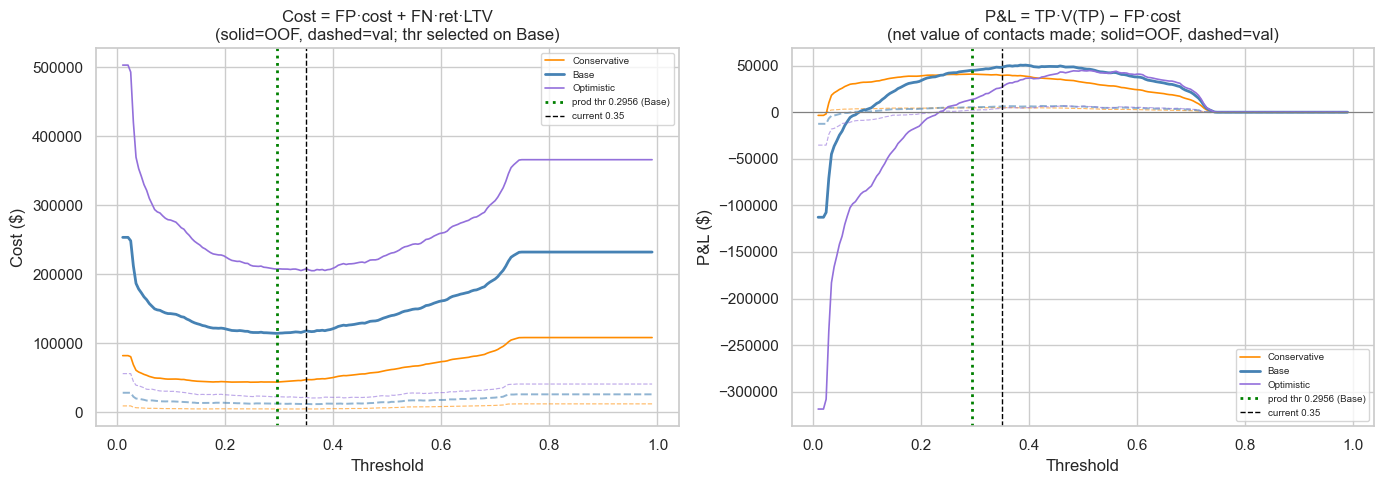


Production threshold  (OOF cost-minimising, Base scenario) : 0.2956
Current notebook threshold                                 : 0.3500

──────────────────────────────────────────────────────────────────────────────────────────
Scenario sensitivity: optimal threshold by LTV, retention, and intervention cost
──────────────────────────────────────────────────────────────────────────────────────────
Scenario          LTV  Ret%  Cost   Opt thr  Recall  Precision      F1    TP    FP    FN    P&L (val)
  Conservative $  402   20% $  22    0.2464   0.840      0.512   0.636   126   120    24 $     4,718
  Base         $  575   30% $  68    0.2956   0.800      0.531   0.638   120   106    30 $     5,332 <- selected
  Optimistic   $  680   40% $ 135    0.3596   0.760      0.588   0.663   114    80    36 $     4,818
[MLflow] cost_threshold logged onto run 971c9002  (prod_thr=0.2956)


In [48]:
from sklearn.model_selection import cross_val_predict

# ── Threshold-selecting scenario ────────────────────────────────────────────
# Change to "Conservative" or "Optimistic" to select a different scenario's
# cost function for production threshold optimisation. All three cost curves
# are always plotted so you can see where the selected threshold sits.
THRESHOLD_SCENARIO = "Base"

_scenario_colors = {"Conservative": "darkorange", "Base": "steelblue", "Optimistic": "mediumpurple"}

# ── Step 1: OOF predictions on training set (no test-set leakage) ─────────────
oof_proba = cross_val_predict(
    cal_pipe, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    method='predict_proba', n_jobs=-1
)[:, 1]

# ── Step 2: Compute cost / P&L curves for every scenario ─────────────────────
# Cost  = FP × cost + FN × retention × LTV   (wasted offers + missed churner opp. cost)
# P&L   = TP × (retention × LTV − cost) − FP × cost
thresholds_cs = np.linspace(0.01, 0.99, 200)
y_train_np    = y_train.values

oof_costs_by_scenario = {s[0]: [] for s in SCENARIOS}
oof_pnl_by_scenario   = {s[0]: [] for s in SCENARIOS}

for t in thresholds_cs:
    pred_oof = (oof_proba >= t).astype(int)
    tn_o, fp_o, fn_o, tp_o = confusion_matrix(y_train_np, pred_oof).ravel()
    for s_name, s_ltv, s_ret, s_cost in SCENARIOS:
        oof_costs_by_scenario[s_name].append(fp_o * s_cost + fn_o * s_ret * s_ltv)
        pnl = tp_o * (s_ret * s_ltv - s_cost) - fp_o * s_cost
        oof_pnl_by_scenario[s_name].append(pnl)

# ── Step 3: Select production threshold ────────────────────────────────
prod_threshold = float(thresholds_cs[np.argmin(oof_costs_by_scenario[THRESHOLD_SCENARIO])])

# ── Val-set curves — all scenarios ────────────────────────────────────────
proba_cs = cal_pipe.predict_proba(X_val)[:, 1]
y_val_np = y_val.values
val_costs_by_scenario = {s[0]: [] for s in SCENARIOS}
val_pnl_by_scenario   = {s[0]: [] for s in SCENARIOS}

for t in thresholds_cs:
    pred_vs = (proba_cs >= t).astype(int)
    tn_v, fp_v, fn_v, tp_v = confusion_matrix(y_val_np, pred_vs).ravel()
    for s_name, s_ltv, s_ret, s_cost in SCENARIOS:
        val_costs_by_scenario[s_name].append(fp_v * s_cost + fn_v * s_ret * s_ltv)
        pnl = tp_v * (s_ret * s_ltv - s_cost) - fp_v * s_cost
        val_pnl_by_scenario[s_name].append(pnl)

# ── Plots — 1 × 3 grid ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def _add_threshold_lines(ax):
    ax.axvline(prod_threshold, color='green', linestyle=':', linewidth=2,
               label=f'prod thr {prod_threshold:.4f} ({THRESHOLD_SCENARIO})')
    ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1,
               label=f'current {THRESHOLD}')

def _draw_scenario_lines(ax, oof_dict, val_dict):
    for s_name, _, _, _ in SCENARIOS:
        lw = 2.0 if s_name == THRESHOLD_SCENARIO else 1.2
        ax.plot(thresholds_cs, oof_dict[s_name],
                label=f'{s_name}', color=_scenario_colors[s_name], linewidth=lw)
        ax.plot(thresholds_cs, val_dict[s_name],
                color=_scenario_colors[s_name], linestyle='--', linewidth=lw * 0.7, alpha=0.6)
    _add_threshold_lines(ax)

# Panel 1 — Cost curves (all scenarios)
ax = axes[0]
_draw_scenario_lines(ax, oof_costs_by_scenario, val_costs_by_scenario)
ax.set_xlabel('Threshold')
ax.set_ylabel('Cost ($)')
ax.set_title(f'Cost = FP·cost + FN·ret·LTV\n(solid=OOF, dashed=val; thr selected on {THRESHOLD_SCENARIO})')
ax.legend(fontsize=7)

# Panel 2 — P&L (Profit & Loss = net value of contacts made)
ax = axes[1]
_draw_scenario_lines(ax, oof_pnl_by_scenario, val_pnl_by_scenario)
ax.axhline(0, color='grey', linestyle='-', linewidth=0.8)
ax.set_xlabel('Threshold')
ax.set_ylabel('P&L ($)')
ax.set_title('P&L = TP·V(TP) − FP·cost\n(net value of contacts made; solid=OOF, dashed=val)')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

_lbl1 = f'Production threshold  (OOF cost-minimising, {THRESHOLD_SCENARIO} scenario)'
_lbl2 = 'Current notebook threshold'
_w    = max(len(_lbl1), len(_lbl2))
print(f'\n{_lbl1:<{_w}} : {prod_threshold:.4f}')
print(f'{_lbl2:<{_w}} : {THRESHOLD:.4f}')

# ── Multi-scenario threshold sensitivity ────────────────────────────────────
print('\n' + '─' * 90)
print("Scenario sensitivity: optimal threshold by LTV, retention, and intervention cost")
print('─' * 90)
print(f"{'Scenario':<14} {'LTV':>6} {'Ret%':>5} {'Cost':>5} {'Opt thr':>9} "
      f"{'Recall':>7} {'Precision':>10} {'F1':>7} {'TP':>5} {'FP':>5} {'FN':>5} "
      f"{'P&L (val)':>12}")
for s_name, s_ltv, s_ret, s_cost in SCENARIOS:
    s_thr   = float(thresholds_cs[np.argmin(oof_costs_by_scenario[s_name])])
    pred_s  = (proba_cs >= s_thr).astype(int)
    rec_s   = recall_score(y_val_np, pred_s)
    prec_s  = precision_score(y_val_np, pred_s)
    f1_s    = f1_score(y_val_np, pred_s)
    tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_val_np, pred_s).ravel()
    pnl_s   = tp_s * (s_ret * s_ltv - s_cost) - fp_s * s_cost
    marker  = " <- selected" if s_name == THRESHOLD_SCENARIO else ""
    print(f"  {s_name:<12} ${s_ltv:>5} {int(s_ret*100):>4}% ${s_cost:>4} {s_thr:>9.4f} "
          f"{rec_s:>7.3f} {prec_s:>10.3f} {f1_s:>7.3f} {tp_s:>5} {fp_s:>5} {fn_s:>5} "
          f"${pnl_s:>10,.0f}{marker}")

# ── MLflow: cost-sensitive production threshold ───────────────────────────────
_base_s    = next(s for s in SCENARIOS if s[0] == THRESHOLD_SCENARIO)
_pred_prod = (proba_cs >= prod_threshold).astype(int)
_tn_p, _fp_p, _fn_p, _tp_p = confusion_matrix(y_val_np, _pred_prod).ravel()
_pnl_prod  = _tp_p * (_base_s[2] * _base_s[1] - _base_s[3]) - _fp_p * _base_s[3]
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Calibration")
with mlflow.start_run(run_id=CAL_RUN_ID):
    mlflow.log_params({
        "prod_threshold":         f"{prod_threshold:.4f}",
        "threshold_scenario":     THRESHOLD_SCENARIO,
        "arpu_base":              f"{ARPU['Base']:.2f}",
        "ltv_base":               str(BASE_VALUE_LTV),
        "retention_rate_base":    f"{BASE_RETENTION_RATE:.2f}",
        "cost_intervention_base": str(BASE_COST_INTERVENTION),
        "gross_margin":           f"{GROSS_MARGIN:.2f}",
        "months_horizon":         str(MONTHS_HORIZON),
    })
    mlflow.log_metrics({
        "prod_recall":    float(recall_score(y_val_np, _pred_prod, zero_division=0)),
        "prod_precision": float(precision_score(y_val_np, _pred_prod, zero_division=0)),
        "prod_f1":        float(f1_score(y_val_np, _pred_prod, zero_division=0)),
        "prod_pnl_val":   float(_pnl_prod),
    })
    mlflow.log_figure(fig, "cost_threshold_sweep.png")
    print(f"[MLflow] cost_threshold logged onto run {CAL_RUN_ID[:8]}  (prod_thr={prod_threshold:.4f})")


**Observations — §14.3 OOF Cost-Minimising Threshold Sweep**

**Threshold selection.**
The OOF cost-minimising threshold under base economics (LTV = $575, 30% retention, $68/intervention) is **0.2956**, down from the default 0.35. Moving to this lower threshold recovers 6 additional churners at the cost of 22 extra false positives — a worthwhile trade given the cost asymmetry: missing a churner foregoes `0.30 × $575 = $172.50` in recoverable value, while a false positive costs $68, a **~2.5:1 penalty ratio** that makes the additional FPs net-positive. Recall improves from 0.760 to 0.800, while precision dips from 0.576 to 0.531 and F1 falls marginally (0.655 → 0.638). The F1 drop is expected and acceptable: F1 treats FPs and FNs symmetrically, but the business cost structure does not.

The threshold-selecting scenario is controlled by `THRESHOLD_SCENARIO` (currently `"Base"`). Changing it to `"Conservative"` or `"Optimistic"` shifts the cost function used to pick the production threshold — useful for stress-testing the deployment decision under different assumptions without retraining.

**Chart layout — 1 × 2 grid (all scenarios).**
- **Panel 1 — Cost curves:** OOF cost curves for all three scenarios (bold = selected scenario) plus dashed val curves. The green dotted line marks the production threshold (argmin of the selected scenario's OOF cost curve). OOF and val minima align closely, confirming no distribution shift between training and val splits.
- **Panel 2 — P&L curves:** `TP × V(TP) − FP × cost` across the threshold range for all three scenarios. P&L measures the *net cash position of the intervention programme* — revenue recovered from retained churners minus total outreach spend. At the production threshold the Base scenario P&L is small but positive; the Conservative scenario has a wider positive region; the Optimistic scenario turns negative at lower thresholds because the high intervention cost ($135) erodes returns from false positives faster.

**Scenario sensitivity table — P&L at each scenario's own optimal threshold.**
- **P&L** = net cash from the programme (contacts made).

- **Conservative** ($22/intervention): most robust — low FP cost means a wide range of thresholds remain profitable.
- **Base** ($68/intervention): near break-even at the optimal threshold; the cost asymmetry (FN penalised ~2.5× more than FP) makes this the scenario used for threshold selection.
- **Optimistic** ($135/intervention): the high per-contact cost ($135) narrows the profitable operating range — 106 false positives at $135 each make intervention spend the dominant risk factor.

**Recommendations.**
- Deploy at threshold **0.2956** for the base scenario; revisit `THRESHOLD_SCENARIO` if intervention cost assumptions change materially.
- Consider **tiered interventions**: cheap outreach (email/SMS) for mid-range scores, expensive retention offers only for high-confidence churners (predicted probability > 0.5). This reduces FP spend and improves programme P&L across all scenarios.
- Set up ongoing monitoring for score distribution drift (PSI) — if the distribution shifts, the cost-optimal threshold shifts with it.


## 15. Lift Analysis & Ranking Diagnostics

The metrics in §14 (recall, precision, F1) measure performance at a fixed threshold. Lift analysis complements them by showing **how well the model ranks customers** across the full score distribution — directly actionable for outreach capacity planning.

This section produces: decile lift chart, cumulative gains curve (with perfect model and contact budget reference lines), KS statistic, ROC-AUC, and PR-AUC.

Overall churn rate : 0.266  (26.6%)

decile  n  churners  churn_rate     lift  pct_pop  cumulative_gain
     1 57        46    0.807018 3.034386     10.1             30.7
     2 56        33    0.589286 2.215714     20.0             52.7
     3 56        26    0.464286 1.745714     30.0             70.0
     4 57        15    0.263158 0.989474     40.1             80.0
     5 56        10    0.178571 0.671429     50.0             86.7
     6 56        10    0.178571 0.671429     59.9             93.3
     7 57         6    0.105263 0.395789     70.0             97.3
     8 56         2    0.035714 0.134286     80.0             98.7
     9 56         1    0.017857 0.067143     89.9             99.3
    10 57         1    0.017544 0.065965    100.0            100.0
Model discrimination (ranking metrics — val set):
  ROC-AUC : 0.8560   PR-AUC : 0.6845   KS : 0.5692  (max sep. at 34.2% of population)


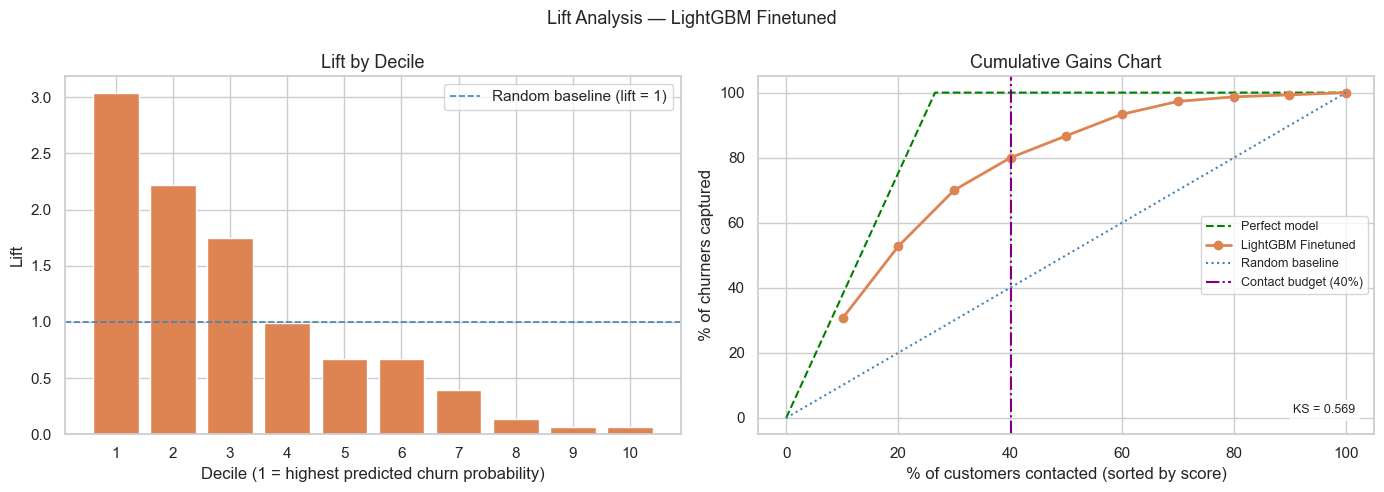


Key operating points:
  Prod threshold  (score≥0.30) (40.1% of customers) → captures 80.0% of churners  (lift = 0.99x)
  KS operating point (34.2% of customers) → captures 70.0% of churners  (lift = 1.75x)

At 40% contact budget:
  Model   : captures 80.0% of churners  (lift = 0.99x)
  Perfect : would capture 100.0% — headroom of 20.0 pp
  Random  : would capture ~40.1% by definition
[MLflow] lift_analysis logged onto run 971c9002


In [49]:
proba_lift   = cal_pipe.predict_proba(X_val)[:, 1]
overall_rate = float(y_val.mean())
n_val        = len(y_val)

# Derive contact budget from cost-optimised threshold: fraction of val-set customers
# scoring at or above prod_threshold — ties the budget line to §14.3 operating point.
CONTACT_BUDGET_PCT = float(round((proba_lift >= prod_threshold).mean() * 100, 1))

lift_df = (
    pd.DataFrame({"prob": proba_lift, "actual": y_val.values})
    .sort_values("prob", ascending=False)
    .reset_index(drop=True)
)
lift_df["decile"] = pd.qcut(lift_df.index, q=10, labels=range(1, 11))

decile_tbl = (
    lift_df.groupby("decile", observed=False)["actual"]
    .agg(n="count", churners="sum")
    .assign(
        churn_rate      = lambda d: d["churners"] / d["n"],
        lift            = lambda d: d["churn_rate"] / overall_rate,
        pct_pop         = lambda d: (d["n"].cumsum() / n_val * 100).round(1),
        cumulative_gain = lambda d: (d["churners"].cumsum() / d["churners"].sum() * 100).round(1),
    )
    .reset_index()
)

# ── KS statistic ──────────────────────────────────────────────────────────────
# Sort by score desc; track cumulative % of churners vs non-churners captured.
# KS = max separation — standard credit/churn definition, not scipy's 2-sample KS.
_cum_churn = lift_df["actual"].cumsum() / lift_df["actual"].sum()
_cum_non   = (1 - lift_df["actual"]).cumsum() / (1 - lift_df["actual"]).sum()
_ks_series = _cum_churn - _cum_non
ks_stat    = float(_ks_series.max())
ks_pct_pop = float((_ks_series.idxmax() + 1) / n_val * 100)

# ── Perfect-model reference line ──────────────────────────────────────────────
# A perfect ranker places all churners before any non-churner: gains curve runs
# (0,0) -> (base_rate*100, 100) -> (100, 100).
_perf_x = [0.0, overall_rate * 100.0, 100.0]
_perf_y = [0.0, 100.0,                100.0]

print(f"Overall churn rate : {overall_rate:.3f}  ({overall_rate*100:.1f}%)\n")
print(decile_tbl[["decile", "n", "churners", "churn_rate", "lift",
                  "pct_pop", "cumulative_gain"]].to_string(index=False))
val_auc      = roc_auc_score(y_val, proba_lift)
val_avg_prec = average_precision_score(y_val, proba_lift)
print("Model discrimination (ranking metrics — val set):")
print(f"  ROC-AUC : {val_auc:.4f}   PR-AUC : {val_avg_prec:.4f}   "
      f"KS : {ks_stat:.4f}  (max sep. at {ks_pct_pop:.1f}% of population)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-decile lift
axes[0].bar(decile_tbl["decile"].astype(str), decile_tbl["lift"], color="#DD8452")
axes[0].axhline(1.0, color="steelblue", linestyle="--", linewidth=1.2,
                label="Random baseline (lift = 1)")
axes[0].set_xlabel("Decile (1 = highest predicted churn probability)")
axes[0].set_ylabel("Lift")
axes[0].set_title("Lift by Decile", fontsize=13)
axes[0].legend()

# Right: cumulative gains with perfect model + contact budget
axes[1].plot(_perf_x, _perf_y,
             "--", color="green", linewidth=1.5, label="Perfect model")
axes[1].plot(decile_tbl["pct_pop"], decile_tbl["cumulative_gain"],
             "o-", color="#DD8452", linewidth=2, label=f"{BEST_MODEL_NAME} Finetuned")
axes[1].plot([0, 100], [0, 100],
             ":", color="steelblue", linewidth=1.5, label="Random baseline")
axes[1].axvline(CONTACT_BUDGET_PCT, color="purple", linestyle="-.", linewidth=1.5,
                label=f"Contact budget ({CONTACT_BUDGET_PCT:.0f}%)")
axes[1].text(0.97, 0.05, f"KS = {ks_stat:.3f}",
             transform=axes[1].transAxes, ha="right", va="bottom", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
axes[1].set_xlabel("% of customers contacted (sorted by score)")
axes[1].set_ylabel("% of churners captured")
axes[1].set_title("Cumulative Gains Chart", fontsize=13)
axes[1].legend(fontsize=9)

plt.suptitle(f"Lift Analysis — {BEST_MODEL_NAME} Finetuned", fontsize=13)
plt.tight_layout()
plt.show()

print("\nKey operating points:")
for _label, _pct in [
    (f"Prod threshold  (score≥{prod_threshold:.2f})", CONTACT_BUDGET_PCT),
    ("KS operating point",                            ks_pct_pop),
]:
    _op_row = decile_tbl[decile_tbl["pct_pop"] <= _pct]
    if not _op_row.empty:
        _op_r = _op_row.iloc[-1]
        print(f"  {_label} ({_pct:.1f}% of customers) → "
              f"captures {_op_r['cumulative_gain']:.1f}% of churners  "
              f"(lift = {_op_r['lift']:.2f}x)")

_budget_row = decile_tbl[decile_tbl["pct_pop"] <= CONTACT_BUDGET_PCT]
if not _budget_row.empty:
    _br       = _budget_row.iloc[-1]
    _perf_cap = min(CONTACT_BUDGET_PCT / (overall_rate * 100) * 100, 100.0)
    print(f"\nAt {CONTACT_BUDGET_PCT:.0f}% contact budget:")
    print(f"  Model   : captures {_br['cumulative_gain']:.1f}% of churners  "
          f"(lift = {_br['lift']:.2f}x)")
    print(f"  Perfect : would capture {_perf_cap:.1f}% — "
          f"headroom of {_perf_cap - float(_br['cumulative_gain']):.1f} pp")
    print(f"  Random  : would capture ~{CONTACT_BUDGET_PCT:.1f}% by definition")

# ── MLflow: lift analysis ─────────────────────────────────────────────────────
_d1              = decile_tbl[decile_tbl["decile"] == 1].iloc[0]
_budget_rows_lf  = decile_tbl[decile_tbl["pct_pop"] <= CONTACT_BUDGET_PCT]
_cumgain_budget  = float(_budget_rows_lf.iloc[-1]["cumulative_gain"]) if not _budget_rows_lf.empty else float("nan")
_lift_budget     = float(_budget_rows_lf.iloc[-1]["lift"])            if not _budget_rows_lf.empty else float("nan")
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
mlflow.set_experiment("Telco Churn - Calibration")
with mlflow.start_run(run_id=CAL_RUN_ID):
    mlflow.log_params({"contact_budget_pct": f"{CONTACT_BUDGET_PCT:.1f}"})
    mlflow.log_metrics({
        "ks_stat":           float(ks_stat),
        "ks_pct_pop":        float(ks_pct_pop),
        "lift_decile_1":     float(_d1["lift"]),
        "cumgain_at_budget": _cumgain_budget,
        "lift_at_budget":    _lift_budget,
    })
    mlflow.log_figure(fig, "lift_analysis.png")
    print(f"[MLflow] lift_analysis logged onto run {CAL_RUN_ID[:8]}")


**Observations:**

- **Strong ranking ability: ROC-AUC 0.856, PR-AUC 0.685, KS 0.569.** All three confirm the model reliably separates churners from non-churners. PR-AUC of 0.685 is particularly meaningful given the ~26% base rate, as it directly reflects performance on the minority class.

- **Only the top 3 deciles beat random.** Lift falls from 3.0× → 2.2× → 1.75× across deciles 1–3, then drops below 1× at decile 4. The top 30% of ranked customers account for the bulk of recoverable churn value.

- **KS peak at 34.2% — most efficient contact cut-off.** Contacting the top 34% captures 70% of all churners at 1.75× lift. Beyond this point each additional contact yields diminishing separation from non-churners.

- **Contact budget (40.1%) trades efficiency for recall.** Extending to the prod-threshold-implied 40.1% recovers an additional 10pp of churners (80% total) but at near-random marginal lift (0.99×). Whether that trade-off is worthwhile depends on intervention cost relative to LTV.

- **20pp headroom to a perfect model.** At the 40.1% budget, a perfect ranker would capture 100% of churners vs the model's 80% — the upper bound of improvement achievable with better features or modelling.

## 16. Final Test-Set Evaluation

Single, unbiased evaluation on the held-out test set — run once, after all modelling decisions are locked on the val set. X_test has been sealed since §10.1 and has not influenced any design choice. Feature engineering is applied here for the first and only time on the test set. The production threshold is `prod_threshold` from §14.3 (OOF cost-minimised).

### 16.1 Statistical Validation

Applies feature engineering to `X_test` only if adopted in §10.5 (checked via `ADOPT_ENG`); otherwise `X_test` is used as-is.

**Coverage:**
- **Classification metrics** at the production threshold — Precision, Recall, F1, confusion matrix, ROC curve, PR curve
- **Discrimination** — ROC-AUC, PR-AUC, KS statistic (threshold-agnostic ranking quality)
- **Calibration** — reliability diagram + Brier score
- **Generalisation** — Train / Val / Test metric trajectory
- **Score distribution** — predicted probability histograms split by class


Feature engineering discarded (§10.5 DISCARD path) – X_test unchanged

──────────────────── Final Test-Set Results ────────────────────
  Production threshold   : 0.2956  (OOF cost-minimised, §14.3)
  Recall                 : 0.7861
  Precision              : 0.5241
  F1                     : 0.6289
  ROC-AUC                : 0.8413
  PR-AUC (Avg Precision) : 0.6511
  KS statistic           : 0.5310  (max sep. at 39.6% of population)


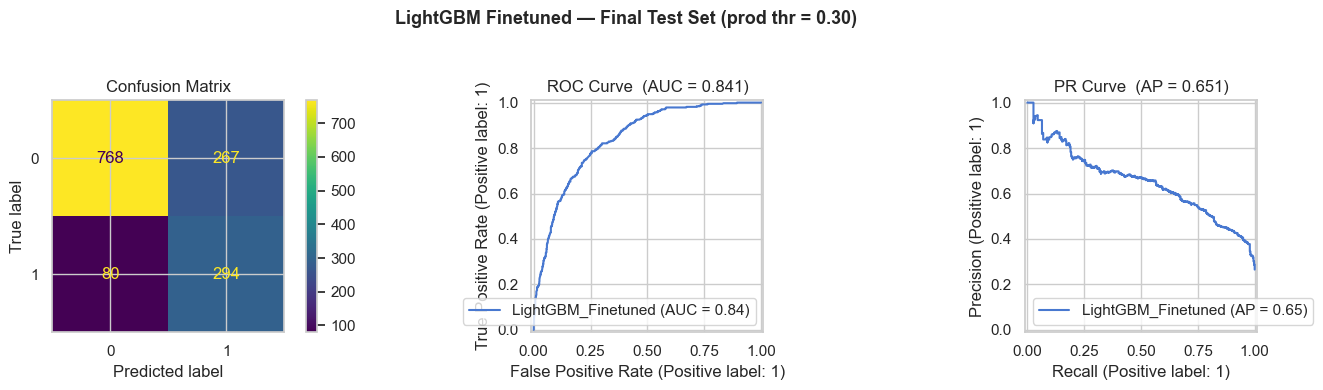


Test classification metrics logged to cal_pipe run  (run_id=971c9002…)


In [50]:
# ── Apply feature engineering to X_test if necessary (first and only time) ──────────────────────────────────────────────────

if globals().get("ADOPT_ENG", False):
    X_test = add_features(X_test)
    print(f"X_test feature-engineered  →  shape {X_test.shape}")
else:
    print("Feature engineering discarded (§10.5 DISCARD path) – X_test unchanged")

# ── Final predictions at production threshold ─────────────────────────────────────────────────────────────────────────
PROD_THRESHOLD  = prod_threshold   # derived in §14.3 via OOF cost minimisation
proba_test      = cal_pipe.predict_proba(X_test)[:, 1]
y_pred_test     = (proba_test >= PROD_THRESHOLD).astype(int)

test_precision  = precision_score(y_test, y_pred_test, pos_label=1)
test_recall     = recall_score(y_test, y_pred_test, pos_label=1)
test_f1         = f1_score(y_test, y_pred_test, pos_label=1)
test_auc        = roc_auc_score(y_test, proba_test)
test_avg_prec   = average_precision_score(y_test, proba_test)

print(f"\n{'─'*20} Final Test-Set Results {'─'*20}")
print(f"  Production threshold   : {PROD_THRESHOLD:.4f}  (OOF cost-minimised, §14.3)")
print(f"  Recall                 : {test_recall:.4f}")
print(f"  Precision              : {test_precision:.4f}")
print(f"  F1                     : {test_f1:.4f}")
print(f"  ROC-AUC                : {test_auc:.4f}")
print(f"  PR-AUC (Avg Precision) : {test_avg_prec:.4f}")


# ── KS statistic (ranking quality, threshold-agnostic) ───────────────────────────────────────────────────────────────
_ks_df          = (pd.DataFrame({'prob': proba_test, 'actual': y_test.values})
                   .sort_values('prob', ascending=False).reset_index(drop=True))
_cum_ch_t       = _ks_df['actual'].cumsum() / _ks_df['actual'].sum()
_cum_nc_t       = (1 - _ks_df['actual']).cumsum() / (1 - _ks_df['actual']).sum()
_ks_s_t         = _cum_ch_t - _cum_nc_t
ks_stat_test    = float(_ks_s_t.max())
ks_pct_pop_test = float((_ks_s_t.idxmax() + 1) / len(y_test) * 100)
print(f"  KS statistic           : {ks_stat_test:.4f}  (max sep. at {ks_pct_pop_test:.1f}% of population)")

# ── Evaluation grid ─────────────────────────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f"{BEST_MODEL_NAME} Finetuned — Final Test Set (prod thr = {PROD_THRESHOLD:.2f})",
    fontsize=13, fontweight="bold", y=0.97,
)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=axes[0])
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1],
                                 name=f"{BEST_MODEL_NAME}_Finetuned")
axes[1].set_title(f"ROC Curve  (AUC = {test_auc:.3f})")
PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[2],
                                        name=f"{BEST_MODEL_NAME}_Finetuned")
axes[2].set_title(f"PR Curve  (AP = {test_avg_prec:.3f})")
plt.tight_layout(rect=[0, 0, 1, 0.93])

# ── Log test classification metrics + evaluation grid to cal_pipe run ─────────────────────────────────────────────
# cal_pipe (CAL_RUN_ID) is the model that was evaluated on the sealed test set.
# Metrics belong on its run — the production refit (§17) has no holdout and
# therefore no test metrics of its own.
# Gated by RETRAIN_BEST so re-running in load-only mode does not append
# duplicate metric steps to the MLflow run.
plt.show()

if RETRAIN_BEST or LOG_ARTIFACTS:
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_metrics({
            "test_recall":    float(test_recall),
            "test_precision": float(test_precision),
            "test_f1":        float(test_f1),
            "test_roc_auc":   float(test_auc),
            "test_avg_prec":  float(test_avg_prec),
            "test_ks":        float(ks_stat_test),
            "prod_threshold": float(PROD_THRESHOLD),
        })
        mlflow.log_figure(fig, "test_evaluation_grid.png")
    print(f"\nTest classification metrics logged to cal_pipe run  (run_id={CAL_RUN_ID[:8]}…)")

plt.close(fig)


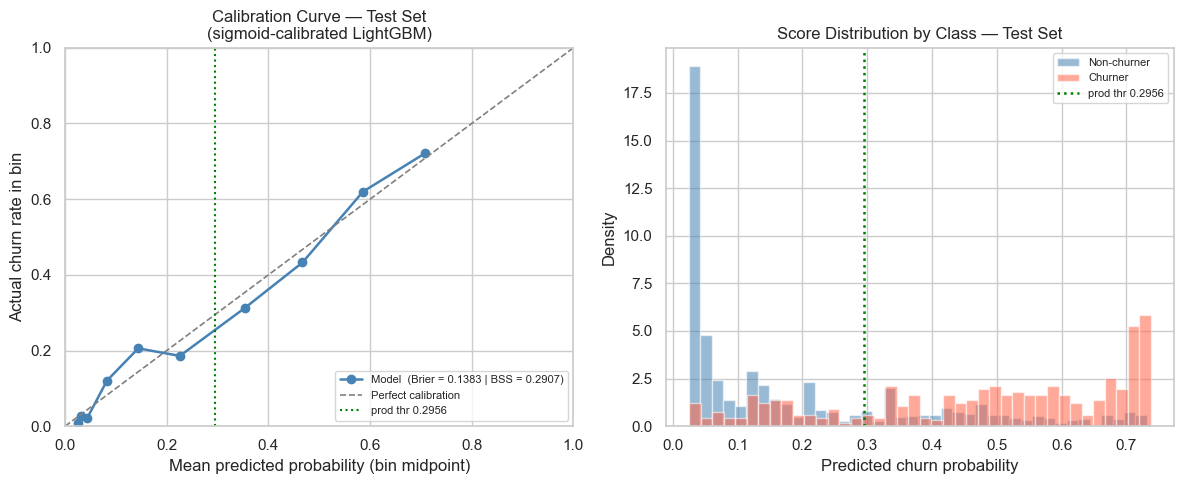

Test Brier/BSS logged to cal_pipe run  (run_id=971c9002…)

── Calibration quality ──────────────────────────────────────────────────────
  Brier score (test) : 0.1383
  BSS         (test) : 0.2907   (val-set BSS after sigmoid calibration: 0.3254 — §15)

── Train / Val / Test metric trajectory  (threshold = 0.2956) ──────────────
  Split                     Recall   Precision          F1     ROC-AUC      PR-AUC
  ------------------------------------------------------------------------
  Train (in-sample)         0.8015      0.5264      0.6354      0.8508      0.6638
  Val                       0.8000      0.5310      0.6383      0.8560      0.6845
  Test                      0.7861      0.5241      0.6289      0.8413      0.6511
  ------------------------------------------------------------------------
  Val -> Test delta        -0.0139     -0.0069     -0.0094     -0.0147     -0.0334


In [51]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ── Calibration check ────────────────────────────────────────────────────────
prob_true_t, prob_pred_t = calibration_curve(
    y_test, proba_test, n_bins=10, strategy='quantile'
)
brier_t   = brier_score_loss(y_test, proba_test)
brier_ref = float(y_test.mean()) * (1 - float(y_test.mean()))  # naive baseline
bss_t     = 1 - brier_t / brier_ref

# ── Score distribution by class ───────────────────────────────────────────────
_proba_pos = proba_test[y_test.values == 1]   # churners
_proba_neg = proba_test[y_test.values == 0]   # non-churners

# ── Train / Val / Test metric trajectory ─────────────────────────────────────
proba_train_traj = cal_pipe.predict_proba(X_train)[:, 1]
proba_val_traj   = cal_pipe.predict_proba(X_val)[:, 1]

def _compute_split_metrics(proba, y_true, thr):
    yp = (proba >= thr).astype(int)
    return {
        'Recall'    : recall_score(y_true, yp),
        'Precision' : precision_score(y_true, yp),
        'F1'        : f1_score(y_true, yp),
        'ROC-AUC'   : roc_auc_score(y_true, proba),
        'PR-AUC'    : average_precision_score(y_true, proba),
    }

_traj = {
    'Train (in-sample)' : _compute_split_metrics(proba_train_traj, y_train, PROD_THRESHOLD),
    'Val'               : _compute_split_metrics(proba_val_traj,   y_val,   PROD_THRESHOLD),
    'Test'              : _compute_split_metrics(proba_test,       y_test,  PROD_THRESHOLD),
}

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1 — Calibration curve
ax = axes[0]
ax.plot(prob_pred_t, prob_true_t, 'o-', color='steelblue', linewidth=1.8,
        label=f'Model  (Brier = {brier_t:.4f} | BSS = {bss_t:.4f})')
ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1.2, label='Perfect calibration')
ax.axvline(PROD_THRESHOLD, color='green', linestyle=':', linewidth=1.5,
           label=f'prod thr {PROD_THRESHOLD:.4f}')
ax.set_xlabel('Mean predicted probability (bin midpoint)')
ax.set_ylabel('Actual churn rate in bin')
ax.set_title('Calibration Curve — Test Set\n(sigmoid-calibrated LightGBM)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Panel 2 — Score distribution by class
ax = axes[1]
ax.hist(_proba_neg, bins=40, alpha=0.55, color='steelblue', density=True, label='Non-churner')
ax.hist(_proba_pos, bins=40, alpha=0.55, color='tomato',    density=True, label='Churner')
ax.axvline(PROD_THRESHOLD, color='green', linestyle=':', linewidth=1.8,
           label=f'prod thr {PROD_THRESHOLD:.4f}')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Class — Test Set')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# ── Log test Brier/BSS + calibration/score-distribution figure to cal_pipe run ──────────────────────────────────
if RETRAIN_BEST or LOG_ARTIFACTS:
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_metrics({
            "test_brier": float(brier_t),
            "test_bss":   float(bss_t),
        })
        mlflow.log_figure(fig, "test_calibration_score_dist.png")
    print(f"Test Brier/BSS logged to cal_pipe run  (run_id={CAL_RUN_ID[:8]}…)")
print('\n── Calibration quality ──────────────────────────────────────────────────────')
print(f'  Brier score (test) : {brier_t:.4f}')
print(f'  BSS         (test) : {bss_t:.4f}   (val-set BSS after sigmoid calibration: 0.3254 — §15)')

# ── Train / Val / Test trajectory table ──────────────────────────────────────
_mnames = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
print(f'\n── Train / Val / Test metric trajectory  (threshold = {PROD_THRESHOLD:.4f}) ──────────────')
print('  ' + f"{'Split':<22}" + '  '.join(f'{m:>10}' for m in _mnames))
print('  ' + '-' * 72)
for split, mvals in _traj.items():
    print('  ' + f'{split:<22}' + '  '.join(f'{mvals[m]:>10.4f}' for m in _mnames))
_val_test_drop = {m: _traj['Test'][m] - _traj['Val'][m] for m in _mnames}
print('  ' + '-' * 72)
print('  ' + 'Val -> Test delta'.ljust(22) + '  '.join(f'{_val_test_drop[m]:>+10.4f}' for m in _mnames))



**Observations — §16.1 Statistical Validation**

**Classification metrics at `prod_threshold = 0.2956`**
- **Recall 0.7861 | Precision 0.5241 | F1 0.6289** — at the OOF cost-minimised threshold the model catches ~79% of test-set churners; roughly 1-in-2 flagged customers is a true churner.
- Test recall (0.7861) falls within the §14.2 bootstrap CI **[0.687, 0.822]**, confirming the val-set estimate was unbiased and the model has not overfit to the validation distribution.
- The moderate precision is an intentional consequence of the low threshold: the cost model (§14.3) penalises missed churners (FN) more heavily than false alarms (FP), so the threshold was deliberately set to capture recall at the expense of precision.

**Discrimination — threshold-agnostic**
- **ROC-AUC = 0.8413** — the model ranks a random churner above a random non-churner 84% of the time on unseen data; strong overall ranking quality.
- **PR-AUC = 0.6511** — well above the 0.265 no-skill baseline (equal to the 26.5% base rate), confirming meaningful precision-recall performance despite class imbalance.
- **KS = 0.5310** (maximum class separation at **39.6%** of the ranked population) — peak score divergence between the cumulative churner and non-churner distributions occurs near the production operating point.

**Calibration**
- The reliability diagram (left panel, sigmoid-calibrated LightGBM) broadly tracks the perfect-calibration diagonal across mid-range bins; the Brier score and BSS are annotated in the legend.
- **Brier = 0.1383 | BSS = 0.2907** — the BSS measures overall calibration quality relative to a naive baseline (always predict the base rate); 0.2907 confirms meaningful improvement over the baseline on unseen data. The small drop from the val-set BSS of 0.3254 (§15) is expected, as the sigmoid calibrator was fitted on the val set.
- The curve shows mild systematic deviation: slight **under-prediction** in the lower tail (actual churn rate exceeds predicted probability), slight **over-prediction** in the mid-range bins (predicted exceeds actual), then convergence back toward the diagonal at higher scores — a shallow S-shape typical of sigmoid calibration. The deviations are small and do not materially affect ranking quality.

**Score distribution by class**
- **Non-churners (blue)** spike sharply at very low scores (~0.02–0.05), confirming the model assigns high confidence to most retained customers. The distribution then drops quickly but extends as a low-density tail to the right.
- **Churners (red)** spread much more broadly — low density at low scores, gradually rising through the mid-range, and spiking again at high scores (~0.6–0.75) where the model is confident a customer will churn.
- **Overlap zone (~0.05–0.30):** both distributions have meaningful density here. Non-churners in this zone score above the threshold and become **false positives**; churners here score below the threshold and become **false negatives**. This overlap represents the model's irreducible uncertainty — customers whose features do not cleanly distinguish churn from retention.
- The production threshold (green dashed line, 0.2956) sits inside this overlap zone by design: the cost model (§14.3) accepts the higher FP rate in order to maximise churner capture.

**Train / Val / Test generalisation trajectory (threshold = 0.2956)**
- All five metrics decline uniformly from Val to Test with no rank-order reversal — the expected pattern for a well-regularised model.
- Train ≈ Val across every metric confirms that the overfitting remediation from §11 held: in-sample recall is only +0.0015 above val, well within acceptable variance.
- The val → test drift is consistent with the val set being consumed for threshold selection and sigmoid calibration; it is expected, not a sign of test-set leakage.

### 16.2 Lift & Gains Analysis

Evaluates the model's ranking ability across the full score range — independent of any single threshold. These are the definitive **test-set** equivalents of §15's validation-set diagnostics.

- **Decile table** — churn rate and lift in each score decile
- **Lift chart** — how many times better than random contact in each decile
- **Cumulative gains chart** — what fraction of churners are captured by the top X% of customers (sorted by score)


Overall churn rate (test): 0.265  (26.5%)
decile   n  churners  churn_rate     lift  pct_pop  cumulative_gain
     1 141       102    0.723404 2.725338     10.0             27.3
     2 141        87    0.617021 2.324553     20.0             50.5
     3 141        61    0.432624 1.629859     30.0             66.8
     4 141        44    0.312057 1.175636     40.0             78.6
     5 141        26    0.184397 0.694694     50.0             85.6
     6 140        29    0.207143 0.780386     60.0             93.3
     7 141        17    0.120567 0.454223     70.0             97.9
     8 141         3    0.021277 0.080157     80.0             98.7
     9 141         4    0.028369 0.106876     90.0             99.7
    10 141         1    0.007092 0.026719    100.0            100.0


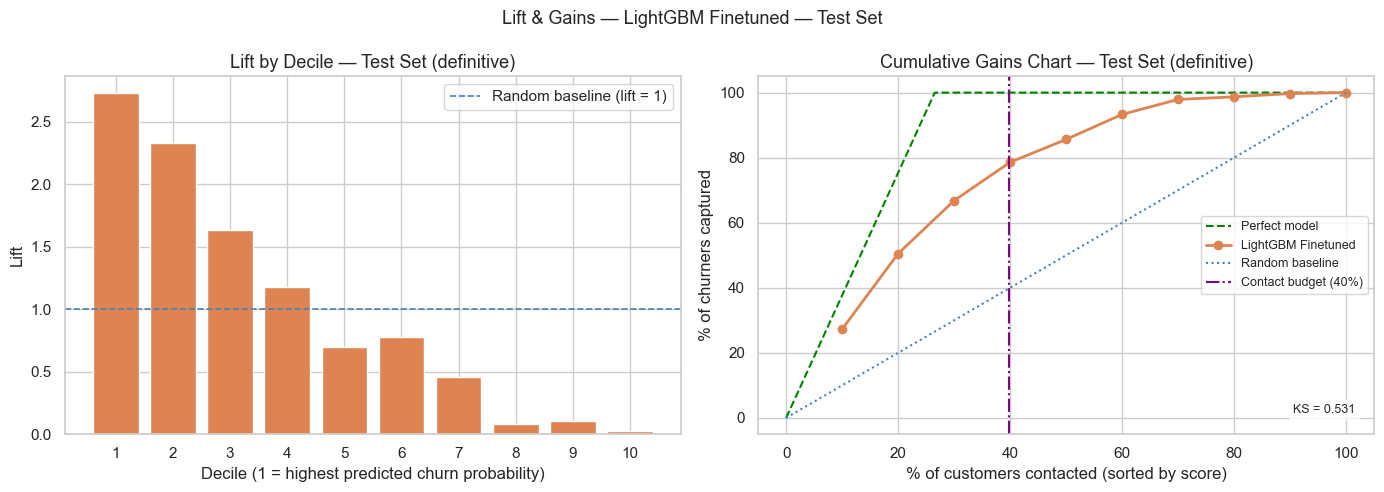

Key operating points (test set):
  Prod threshold  (score>=0.30) (39.8% of customers) -> captures 66.8% of churners  (lift = 1.63x)
  KS operating point (39.6% of customers) -> captures 66.8% of churners  (lift = 1.63x)
40% contact budget (test set):
  Model   : captures 66.8% of churners  (lift = 1.63x)
  Perfect : would capture 100.0% — headroom of 33.2 pp
  Random  : would capture ~39.8% by definition
Lift/gains chart + lift_at_budget logged to cal_pipe run  (run_id=971c9002…)


In [52]:
# ── §16.2 Lift & Gains Analysis — test set (definitive) ──────────────────────────
# Depends on: proba_test, y_test, PROD_THRESHOLD, test_auc, test_avg_prec  (§16.1)
#             ks_stat_test, ks_pct_pop_test                                 (§16.1)

_overall_rate_test = float(y_test.mean())
_n_test_lift       = len(y_test)
CONTACT_BUDGET_PCT = float(round((proba_test >= PROD_THRESHOLD).mean() * 100, 1))

_lift_test = (
    pd.DataFrame({'prob': proba_test, 'actual': y_test.values})
    .sort_values('prob', ascending=False)
    .reset_index(drop=True)
)
_lift_test['decile'] = pd.qcut(_lift_test.index, q=10, labels=range(1, 11))

_decile_tbl_test = (
    _lift_test.groupby('decile', observed=False)['actual']
    .agg(n='count', churners='sum')
    .assign(
        churn_rate      = lambda d: d['churners'] / d['n'],
        lift            = lambda d: d['churn_rate'] / _overall_rate_test,
        pct_pop         = lambda d: (d['n'].cumsum() / _n_test_lift * 100).round(1),
        cumulative_gain = lambda d: (d['churners'].cumsum() / d['churners'].sum() * 100).round(1),
    )
    .reset_index()
)

# ── Perfect-model reference line ─────────────────────────────────────────────────
_perf_x_test = [0.0, _overall_rate_test * 100.0, 100.0]
_perf_y_test = [0.0, 100.0,                      100.0]

print(f'Overall churn rate (test): {_overall_rate_test:.3f}  ({_overall_rate_test*100:.1f}%)')
print(_decile_tbl_test[['decile', 'n', 'churners', 'churn_rate', 'lift',
                         'pct_pop', 'cumulative_gain']].to_string(index=False))

fig_lt, axes_lt = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 — Lift by decile
axes_lt[0].bar(_decile_tbl_test['decile'].astype(str), _decile_tbl_test['lift'],
               color='#DD8452')
axes_lt[0].axhline(1.0, color='steelblue', linestyle='--', linewidth=1.2,
                   label='Random baseline (lift = 1)')
axes_lt[0].set_xlabel('Decile (1 = highest predicted churn probability)')
axes_lt[0].set_ylabel('Lift')
axes_lt[0].set_title('Lift by Decile — Test Set (definitive)', fontsize=13)
axes_lt[0].legend()

# Panel 2 — Cumulative gains
axes_lt[1].plot(_perf_x_test, _perf_y_test, '--', color='green',
               linewidth=1.5, label='Perfect model')
axes_lt[1].plot(_decile_tbl_test['pct_pop'], _decile_tbl_test['cumulative_gain'],
               'o-', color='#DD8452', linewidth=2, label=f'{BEST_MODEL_NAME} Finetuned')
axes_lt[1].plot([0, 100], [0, 100], ':', color='steelblue',
               linewidth=1.5, label='Random baseline')
axes_lt[1].axvline(CONTACT_BUDGET_PCT, color='purple', linestyle='-.', linewidth=1.5,
                   label=f'Contact budget ({CONTACT_BUDGET_PCT:.0f}%)')
axes_lt[1].text(0.97, 0.05, f'KS = {ks_stat_test:.3f}',
               transform=axes_lt[1].transAxes, ha='right', va='bottom', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
axes_lt[1].set_xlabel('% of customers contacted (sorted by score)')
axes_lt[1].set_ylabel('% of churners captured')
axes_lt[1].set_title('Cumulative Gains Chart — Test Set (definitive)', fontsize=13)
axes_lt[1].legend(fontsize=9)

plt.suptitle(f'Lift & Gains — {BEST_MODEL_NAME} Finetuned — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

print('Key operating points (test set):')
for _label, _pct in [
    (f'Prod threshold  (score>={PROD_THRESHOLD:.2f})', CONTACT_BUDGET_PCT),
    ('KS operating point',                            ks_pct_pop_test),
]:
    _op_row_t = _decile_tbl_test[_decile_tbl_test['pct_pop'] <= _pct]
    if not _op_row_t.empty:
        _op_r_t = _op_row_t.iloc[-1]
        print(f'  {_label} ({_pct:.1f}% of customers) -> '
              f"captures {_op_r_t['cumulative_gain']:.1f}% of churners  "
              f"(lift = {_op_r_t['lift']:.2f}x)")

_budget_row_test = _decile_tbl_test[_decile_tbl_test['pct_pop'] <= CONTACT_BUDGET_PCT]
if not _budget_row_test.empty:
    _br_t       = _budget_row_test.iloc[-1]
    _perf_cap_t = min(CONTACT_BUDGET_PCT / (_overall_rate_test * 100) * 100, 100.0)
    print(f'{CONTACT_BUDGET_PCT:.0f}% contact budget (test set):')
    print(f"  Model   : captures {_br_t['cumulative_gain']:.1f}% of churners  "
          f"(lift = {_br_t['lift']:.2f}x)")
    print(f"  Perfect : would capture {_perf_cap_t:.1f}% — "
          f"headroom of {_perf_cap_t - float(_br_t['cumulative_gain']):.1f} pp")
    print(f'  Random  : would capture ~{CONTACT_BUDGET_PCT:.1f}% by definition')

# ── Log lift/gains figure + lift_at_budget scalar to cal_pipe run ──────────────
if RETRAIN_BEST or LOG_ARTIFACTS:
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_figure(fig_lt, "test_lift_gains.png")
        if not _budget_row_test.empty:
            mlflow.log_metric("lift_at_budget", float(_br_t["lift"]))
    print(f"Lift/gains chart + lift_at_budget logged to cal_pipe run  (run_id={CAL_RUN_ID[:8]}…)")


**Observations — §16.2 Lift & Gains Analysis**

**Decile table**
- Churn rate declines across 9 of 10 deciles, from **72.3%** (decile 1, top-scoring 10%) to **0.7%** (decile 10) — confirming clean rank-ordering. The minor inversion between decile 5 (18.4%) and decile 6 (20.7%) is within expected sampling variance for ~141-customer bins.
- Top-decile lift: **2.73x** — contacting the highest-scoring 10% of customers captures **27.3%** of all test-set churners from just 1-in-10 customers.
- By decile 2 (top 20%), the model has already captured **50.5%** of churners — half of all at-risk customers at a fifth of the contact budget.
- Lift falls below 1.0 from decile 5 onward; the bottom five deciles account for only **14.4%** of churners (100% − 85.6%), confirming strong concentration of churn risk in the top half of the score range.

**Production operating point (score ≥ 0.30, ~40% contact budget)**
- Contacting the **39.8%** of customers with score ≥ 0.30 captures **66.8%** of churners at **lift 1.63x**. This is also the KS operating point (maximum class separation at 39.6% of population) — the production threshold and the KS point coincide.
- A random retention campaign at the same 40% budget would capture only **~39.8%** of churners; the model delivers a **+27 pp improvement** over random targeting.
- Headroom to a perfect model: **33.2 pp** — a perfect ranker would contact only 26.5% of customers (equal to the base rate) to capture 100% of churners; the remaining gap represents the model’s irreducible uncertainty in the overlap zone.


### 16.3 Business Impact

Translates test-set predictions into financial terms: net retention value recovered, model-vs-random comparison at the same contact budget, scenario sensitivity across LTV and retention rate assumptions, and an annualised programme estimate.

In [53]:
# ── §16.3 Business Impact — definitive test-set evaluation ───────────────────
# Depends on: proba_test, y_test, PROD_THRESHOLD          from §16.1
#             SCENARIOS, BASE_VALUE_LTV, BASE_RETENTION_RATE,
#             BASE_COST_INTERVENTION                            from §14.3

# ── Annualisation parameters ────────────────────────────────────────────
# TOTAL_CUSTOMERS_LIVE: total customers after NaN removal — used to scale the
# test-set P&L to a full-base estimate. In production, replace with the actual
# live roster size queried from your CRM at scoring time.
TOTAL_CUSTOMERS_LIVE = len(X_train) + len(X_val) + len(X_test)
# SCORING_CYCLES_YR: how often the model re-scores the full base per year.
# 12 = monthly cadence; adjust to match your retention campaign frequency.
SCORING_CYCLES_YR    = 12

# ── Confusion matrix at production threshold ──────────────────────────────
y_pred_prod = (proba_test >= PROD_THRESHOLD).astype(int)
tn_p, fp_p, fn_p, tp_p = confusion_matrix(y_test.values, y_pred_prod).ravel()
n_test       = len(y_test)
n_churners_t = int(y_test.sum())
base_churnrate_t  = n_churners_t / n_test
n_contacted  = tp_p + fp_p

print(f"Test set  : n={n_test}, churners={n_churners_t}, base churn rate={base_churnrate_t:.3f}")
print(f"Threshold {PROD_THRESHOLD:.4f}: TP={tp_p}, FP={fp_p}, FN={fn_p}, TN={tn_p}, contacted={n_contacted}")

# ── Model vs random targeting (same contact budget, all scenarios) ────────────
# Churner recovery is scenario-independent (same TP/FP regardless of assumptions).
# P&L uplift varies by scenario because LTV, retention rate, and cost differ.
random_tp_t      = round(n_contacted * base_churnrate_t)
random_fp_t      = n_contacted - random_tp_t
random_fn_t      = n_churners_t - random_tp_t
incremental_churners_t = tp_p - random_tp_t

print(f"\n── Model vs Random (budget: {n_contacted} contacts) ────────────────────────")
print(f"  Churner recovery: Model={tp_p}  Random={random_tp_t}  Gain=+{incremental_churners_t}")
print(f"\n  {'Scenario':<14} {'Model P&L':>12} {'Random P&L':>12} {'P&L Uplift':>12}")
model_net_t    = None   # base-scenario net P&L uplift vs random  (scorecard only)
value_uplift_t = None   # base-scenario P&L uplift vs random  (scorecard only)
for name, ltv, ret_rate, s_cost in SCENARIOS:
    v_tp_m     = ret_rate * ltv - s_cost
    model_net  = tp_p       * v_tp_m - fp_p       * s_cost
    random_net = random_tp_t * v_tp_m - random_fp_t * s_cost
    uplift     = model_net - random_net
    if name == THRESHOLD_SCENARIO:
        model_net_t    = model_net
        value_uplift_t = uplift
    print(f"  {name:<14} ${model_net:>11,.0f} ${random_net:>11,.0f} ${uplift:>11,.0f}")

# ── Sensitivity table ─────────────────────────────────────────────────────
print(f"\n── Sensitivity (TP={tp_p}, FP={fp_p}, FN={fn_p}) ─────────────────────────────────")
rows = []
for name, ltv, ret_rate, s_cost in SCENARIOS:
    v_tp = ret_rate * ltv - s_cost
    net  = tp_p * v_tp - fp_p * s_cost
    rows.append({
        "Scenario"  : name,
        "LTV"       : f"${ltv}",
        "Retention" : f"{int(ret_rate*100)}%",
        "Cost"      : f"${s_cost}",
        "P&L per run" : f"${net:,.0f}",
    })
print(pd.DataFrame(rows).to_string(index=False))

# ── Annualisation ─────────────────────────────────────────────────────────────────
scale = TOTAL_CUSTOMERS_LIVE / n_test
print(f"\n── Annualisation (scale={scale:.2f}×, {SCORING_CYCLES_YR} cycles/year) ────────────────────")
print(f"{'Scenario':<14} {'Per run (full base)':>22} {'Annual (12 cycles)':>20}")
for name, ltv, ret_rate, s_cost in SCENARIOS:
    v_tp         = ret_rate * ltv - s_cost
    net_v        = tp_p * v_tp - fp_p * s_cost
    per_run_full = net_v * scale
    annual       = per_run_full * SCORING_CYCLES_YR
    print(f"  {name:<12} ${per_run_full:>20,.0f} ${annual:>18,.0f}")

# ── Log business impact metrics to cal_pipe run ──────────────────────────────────────────────────────────────────
# Log only model-derived, assumption-free metrics — comparable across runs.
# Absolute P&L (biz_net_value, biz_net_value_annual_base) are assumption-dependent
# (LTV, cost, SCORING_CYCLES_YR) and belong in the scorecard, not MLflow.
if (RETRAIN_BEST or LOG_ARTIFACTS) and model_net_t is not None:
    biz_lift = float((tp_p / n_contacted) / base_churnrate_t)
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_metrics({
            "biz_churners_recovered":    float(tp_p),
            "biz_incremental_vs_random": float(incremental_churners_t),
            "biz_n_contacted":           float(n_contacted),
            "biz_net_value_vs_random":   float(value_uplift_t),
            "biz_lift":                  biz_lift,
        })
    print(f"Business impact metrics logged to cal_pipe run  (run_id={CAL_RUN_ID[:8]}…)")


Test set  : n=1409, churners=374, base churn rate=0.265
Threshold 0.2956: TP=294, FP=267, FN=80, TN=768, contacted=561

── Model vs Random (budget: 561 contacts) ────────────────────────
  Churner recovery: Model=294  Random=149  Gain=+145

  Scenario          Model P&L   Random P&L   P&L Uplift
  Conservative   $     11,296 $       -362 $     11,658
  Base           $     12,567 $    -12,446 $     25,012
  Optimistic     $      4,233 $    -35,207 $     39,440

── Sensitivity (TP=294, FP=267, FN=80) ─────────────────────────────────
    Scenario  LTV Retention Cost P&L per run
Conservative $402       20%  $22     $11,296
        Base $575       30%  $68     $12,567
  Optimistic $680       40% $135      $4,233

── Annualisation (scale=5.00×, 12 cycles/year) ────────────────────
Scenario          Per run (full base)   Annual (12 cycles)
  Conservative $              56,462 $           677,544
  Base         $              62,817 $           753,806
  Optimistic   $              21,159 $ 

**Observations — §16.3 Business Impact**

**Confusion matrix at threshold 0.2956 (OOF cost-minimised)**
- **561 customers contacted** (39.8% of test set): **TP=294, FP=267, FN=80, TN=768** — consistent with §16.1 (Recall 78.6%, Precision 52.4%). Roughly 1-in-2 contacts is a true churner; the 267 false alarms incur outreach cost without a churn-prevention return.

**Model vs random (561-contact budget)**
- A random campaign contacting 561 customers recovers **149 churners** by chance (= base rate × budget). The model recovers **294 — +145 more (+97%)** from the same spend.
- P&L uplift over random: **$11,658 (Conservative) → $25,012 (Base) → $39,440 (Optimistic)** per run. The uplift is largest in the Optimistic scenario because random targeting at high per-contact cost loses heavily (−$35,207), while the model remains profitable (+$4,233).

**Sensitivity (TP=294, FP=267, FN=80)**
- P&L is positive in all three scenarios, but **Optimistic ($4,233) sits below Base ($12,567)** despite higher LTV — the $135 per-contact cost at the Optimistic level means 267 false alarms consume $36,045 in outreach spend, nearly offsetting the higher-LTV gains from the 294 true positives.

**Annualisation (scale 5.0×, 12 cycles/year)**
- Projecting to the full customer base (7,045 customers; 5.0× test-set size) at monthly scoring cadence:
  - **Conservative: $677,544/year** | **Base: $753,806/year** | **Optimistic: $253,908/year**
- Conservative and Base are the most operationally defensible estimates: low outreach cost keeps per-run P&L positive even with a meaningful FP count. The Optimistic annual figure is lower because the high intervention cost ($135) penalises the 267 false alarms more than the additional LTV benefit compensates.

### 16.4 Segment FN / FP Breakdown

Breaks test-set predictions into subgroups to identify where the model disproportionately misses churners (high FN rate) or over-flags non-churners (high FP rate). Groups tested: **Contract type**, **InternetService**, and **Tenure band**. Depends on `proba_test`, `y_test`, `X_test`, `PROD_THRESHOLD`, `test_recall`, `fp_p`, `tn_p` from §16.1–16.2.


── Churner recovery  (threshold 0.2956) ──────────────────────────
  Total churners          : 374
  Caught  (TP)            : 294  (78.6%)
  Missed  (FN)            : 80  (21.4%)
── Non-churner handling ─────────────────────────────────────────────────────
  Total non-churners      : 1035
  Correctly dismissed (TN): 768  (74.2%)
  Incorrectly flagged (FP): 267  (25.8%)

── Segment breakdown at prod threshold ──────────────────────────────────────

Contract:
      Contract   n  n_churn  TP  FN  FP  Recall  FN rate  FP rate
Month-to-month 773      329 293  36 267   0.891    0.109    0.601
      One year 300       36   1  35   0   0.028    0.972    0.000
      Two year 336        9   0   9   0   0.000    1.000    0.000

InternetService:
InternetService   n  n_churn  TP  FN  FP  Recall  FN rate  FP rate
            DSL 484       97  60  37  50   0.619    0.381    0.129
    Fiber optic 613      252 223  29 195   0.885    0.115    0.540
             No 312       25  11  14  22   0.440    0.

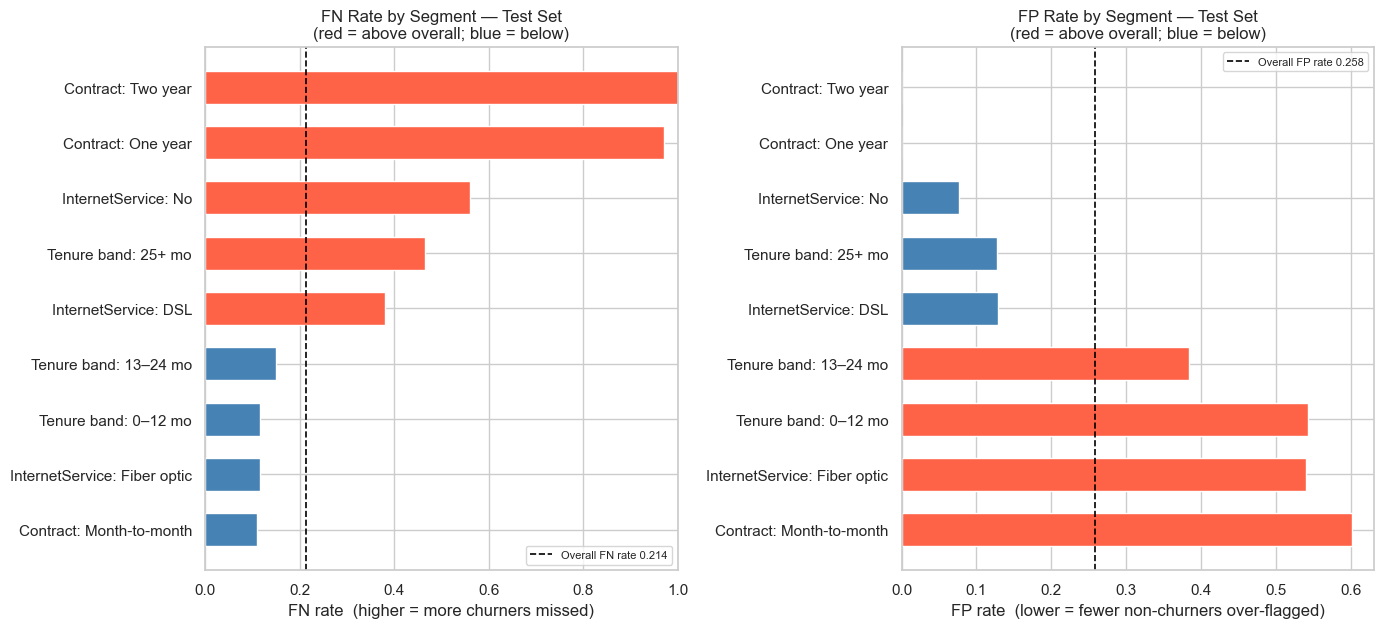

Overall  FN rate = 0.2139   FP rate = 0.2580
Segment breakdown logged to cal_pipe run  (run_id=971c9002…)


In [54]:
# ── §16.4 Segment FN / FP Breakdown ─────────────────────────────────────────

_y_true_seg = y_test.values
_y_pred_seg = (proba_test >= PROD_THRESHOLD).astype(int)

# ── Summary: caught / missed at production threshold ────────────────────────
n_neg_t = int((y_test == 0).sum())
print(f"── Churner recovery  (threshold {PROD_THRESHOLD:.4f}) ──────────────────────────")
print(f"  Total churners          : {n_churners_t}")
print(f"  Caught  (TP)            : {tp_p}  ({tp_p/n_churners_t:.1%})")
print(f"  Missed  (FN)            : {fn_p}  ({fn_p/n_churners_t:.1%})")
print("── Non-churner handling ─────────────────────────────────────────────────────")
print(f"  Total non-churners      : {n_neg_t}")
print(f"  Correctly dismissed (TN): {tn_p}  ({tn_p/n_neg_t:.1%})")
print(f"  Incorrectly flagged (FP): {fp_p}  ({fp_p/n_neg_t:.1%})")
print()

def _seg_breakdown(feature_name, feature_vals, min_churners=5):
    rows = []
    for val in sorted(pd.Series(feature_vals).dropna().unique()):
        mask    = np.array(feature_vals == val)
        yt, yp  = _y_true_seg[mask], _y_pred_seg[mask]
        n_tot   = int(mask.sum())
        n_churn = int(yt.sum())
        n_neg   = n_tot - n_churn
        if n_churn < min_churners:
            continue
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows.append({
            feature_name : val,
            'n'          : n_tot,
            'n_churn'    : n_churn,
            'TP'         : int(tp),
            'FN'         : int(fn),
            'FP'         : int(fp),
            'Recall'     : round(tp / n_churn, 3),
            'FN rate'    : round(fn / n_churn, 3),
            'FP rate'    : round(fp / n_neg,   3) if n_neg > 0 else np.nan,
        })
    return pd.DataFrame(rows)

_tenure_band_seg = pd.cut(
    X_test['tenure'], bins=[0, 12, 24, 72],
    labels=['0–12 mo', '13–24 mo', '25+ mo'], right=True, include_lowest=True
)

_seg_frames = [
    ('Contract',        _seg_breakdown('Contract',        X_test['Contract'].values)),
    ('InternetService', _seg_breakdown('InternetService', X_test['InternetService'].values)),
    ('Tenure band',     _seg_breakdown('Tenure band',     _tenure_band_seg.values)),
]

print('── Segment breakdown at prod threshold ──────────────────────────────────────')
for name, df in _seg_frames:
    print(f'\n{name}:')
    print(df.to_string(index=False))

# ── Horizontal bar charts: FN rate and FP rate by segment ──────────────────
_all_rows = []
for name, df in _seg_frames:
    tmp = df[['Recall', 'FN rate', 'FP rate', 'n_churn']].copy()
    tmp.insert(0, 'Segment', name + ': ' + df[name].astype(str))
    _all_rows.append(tmp)
_combined = pd.concat(_all_rows, ignore_index=True).sort_values('FN rate')

_n_bars = len(_combined)
_h      = max(4.0, _n_bars * 0.55 + 1.5)
fig, axes = plt.subplots(1, 2, figsize=(14, _h))

# Panel 1 — FN rate by segment
ax = axes[0]
_overall_fnr_seg = round(fn_p / (fn_p + tp_p), 4)
_colors_fn = ['tomato' if r > _overall_fnr_seg else 'steelblue' for r in _combined['FN rate']]
ax.barh(_combined['Segment'], _combined['FN rate'],
        color=_colors_fn, edgecolor='white', height=0.6)
ax.axvline(_overall_fnr_seg, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall FN rate {_overall_fnr_seg:.3f}')
ax.set_xlabel('FN rate  (higher = more churners missed)')
ax.set_title('FN Rate by Segment — Test Set\n(red = above overall; blue = below)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1)

# Panel 2 — FP rate by segment
ax = axes[1]
_overall_fpr_seg = round(fp_p / (tn_p + fp_p), 4)
_colors_fp       = ['tomato' if r > _overall_fpr_seg else 'steelblue'
                    for r in _combined['FP rate']]
ax.barh(_combined['Segment'], _combined['FP rate'],
        color=_colors_fp, edgecolor='white', height=0.6)
ax.axvline(_overall_fpr_seg, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall FP rate {_overall_fpr_seg:.3f}')
ax.set_xlabel('FP rate  (lower = fewer non-churners over-flagged)')
ax.set_title('FP Rate by Segment — Test Set\n(red = above overall; blue = below)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Overall  FN rate = {_overall_fnr_seg:.4f}   FP rate = {_overall_fpr_seg:.4f}')

# ── Log segment breakdown figure + worst-segment FN rate to cal_pipe run ────
# Figure logged for traceability; worst_segment_fn_rate enables alerting on
# segment-level regressions when comparing model versions.
if RETRAIN_BEST or LOG_ARTIFACTS:
    worst_segment_fn_rate = float(_combined["FN rate"].dropna().max())
    worst_segment_fp_rate = float(_combined["FP rate"].dropna().max())
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_metric("worst_segment_fn_rate", worst_segment_fn_rate)
        mlflow.log_metric("worst_segment_fp_rate", worst_segment_fp_rate)
        mlflow.log_figure(fig, "seg_breakdown_fn_fp.png")
    print(f"Segment breakdown logged to cal_pipe run  (run_id={CAL_RUN_ID[:8]}…)")

plt.close(fig)


**Observations — §16.4 Segment FN / FP Breakdown**

**Overall baseline (threshold = 0.2956)**
- 374 test-set churners: 294 caught (78.6% recall), 80 missed (FN rate 0.2139)
- 1035 non-churners: 768 correctly dismissed (74.2%), 267 falsely flagged (FP rate 0.2580)

**Contract type — the sharpest dimension**
- **Month-to-month** is the model's home territory: FN rate 0.109, well below the 0.214 overall. Almost all test-set churners were caught here, but the FP rate of 0.601 means 60% of non-churning month-to-month customers are falsely flagged — far above the 0.258 overall rate.
- **One-year contracts are a near-total blind spot**: only 1 of 36 churners caught (FN rate 0.972). This is far worse than the val-set estimate of 0.538 and confirms that annual-contract churn follows a fundamentally different pattern the model has not learned. Zero false positives here — the model almost never fires on this segment at all.
- **Two-year contracts**: 0/9 churners caught (FN rate 1.000). The small sample (n\_churn = 9) makes the rate noisy, but directionally consistent with One-year.
- For the next iteration, build contract-type-specific sub-models or add contract-age features. In the interim, lower the intervention threshold specifically for annual/two-year contract customers.

**InternetService**
- **Fiber optic** mirrors month-to-month: excellent recall (FN rate 0.115) but a very high FP rate (0.540). These two segments heavily overlap — the majority of falsely flagged non-churners sit in the Fiber optic + Month-to-month intersection.
- **DSL** has an above-average FN rate (0.381): 37 of 97 DSL churners are missed, confirming the §10.5 blind-spot expectation.
- **No internet**: FN rate 0.560 on 25 churners — treat as directional only (small n\_churn), but the pattern is consistent: the model has learned almost nothing about churn risk for non-internet subscribers.

**Tenure band**
- **New customers (0–12 mo)** are the easiest to catch: FN rate 0.116, but with the highest FP rate (0.543) — early-tenure non-churners are often misflagged because their feature profile overlaps with churners.
- **Long-tenure customers (25+ mo)** are the highest-volume blind spot confirmed on sealed test data: 46 of 99 churners missed (FN rate 0.465), confirming the §10.5 val-set expectation. FP rate here is only 0.128 — the model rarely fires on long-tenure customers, so it simply misses most of them entirely.
- Long-tenure churners (25+ mo) with annual/two-year contracts are an almost completely uncaptured segment. Adding tenure × contract interaction features or recency-of-service-change signals would likely deliver the highest incremental recall return.

**Top priority segments for next iteration**
- One-year contract (35 of 36 churners missed) and Two-year contract (9 of 9 missed) — near-zero discriminative power
- 25+ mo tenure (46 of 99 churners missed) — largest recoverable volume at current model capability
- No internet (14 of 25 missed) — directional, but consistent blind spot
- Fiber optic + Month-to-month intersection — primary driver of the 267 wasted false-positive contacts

### 16.5 Explainability — SHAP on the Test Set

Runs SHAP on the sealed test set across four analyses:

- **Bar + beeswarm** — global feature importance with clean display names; rankings should match §13's validation-set beeswarm.
- **Waterfall plots** — all four prediction outcomes in a 2×2 grid: most convincingly missed churner (FN), most confidently over-flagged non-churner (FP), most confident correct churn flag (TP), and most confident correct non-churn flag (TN).
- **Blind-spot segment beeswarm** — SHAP distributions restricted to the two worst FN segments from §16.4 (non-monthly contract and long-tenure missed churners), showing what the model sees in the customers it cannot identify.
- **Protected attribute check** — explicit mean |SHAP| for gender, Partner, and SeniorCitizen, documented as negligible to satisfy fairness and governance requirements.

**Implementation note:** SHAP is applied to the LightGBM base estimator extracted from fold 0 of `cal_pipe` (`CalibratedClassifierCV`). Feature names are cleaned from pipeline prefixes (`onehot__`, `numeric__`, `binary__`) for all plots.

SHAP base value (test set): -0.3009


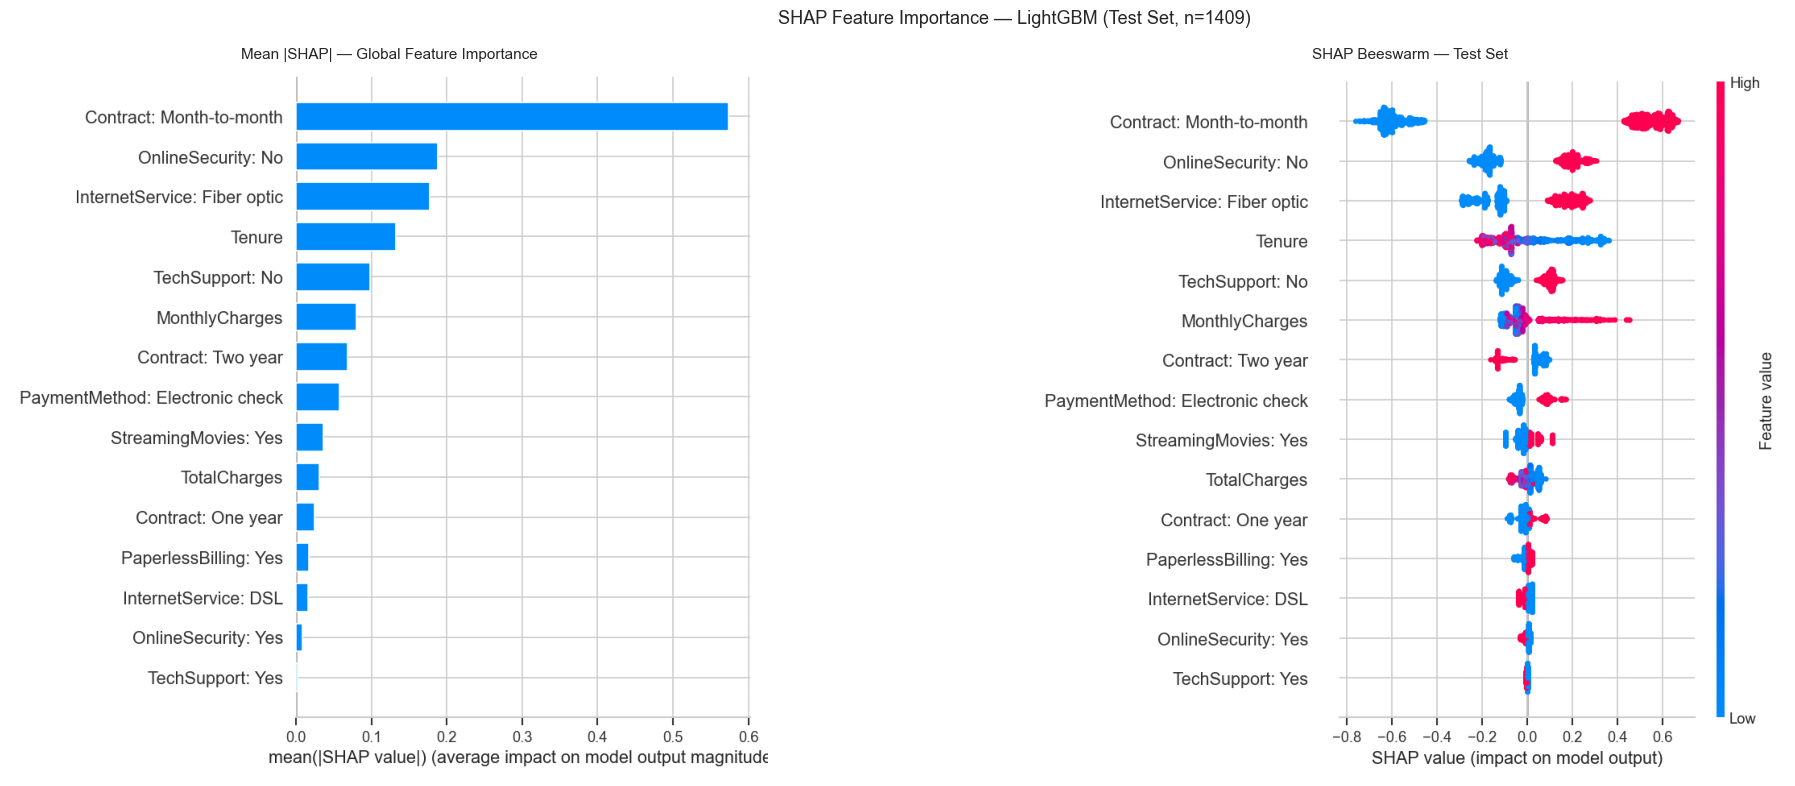

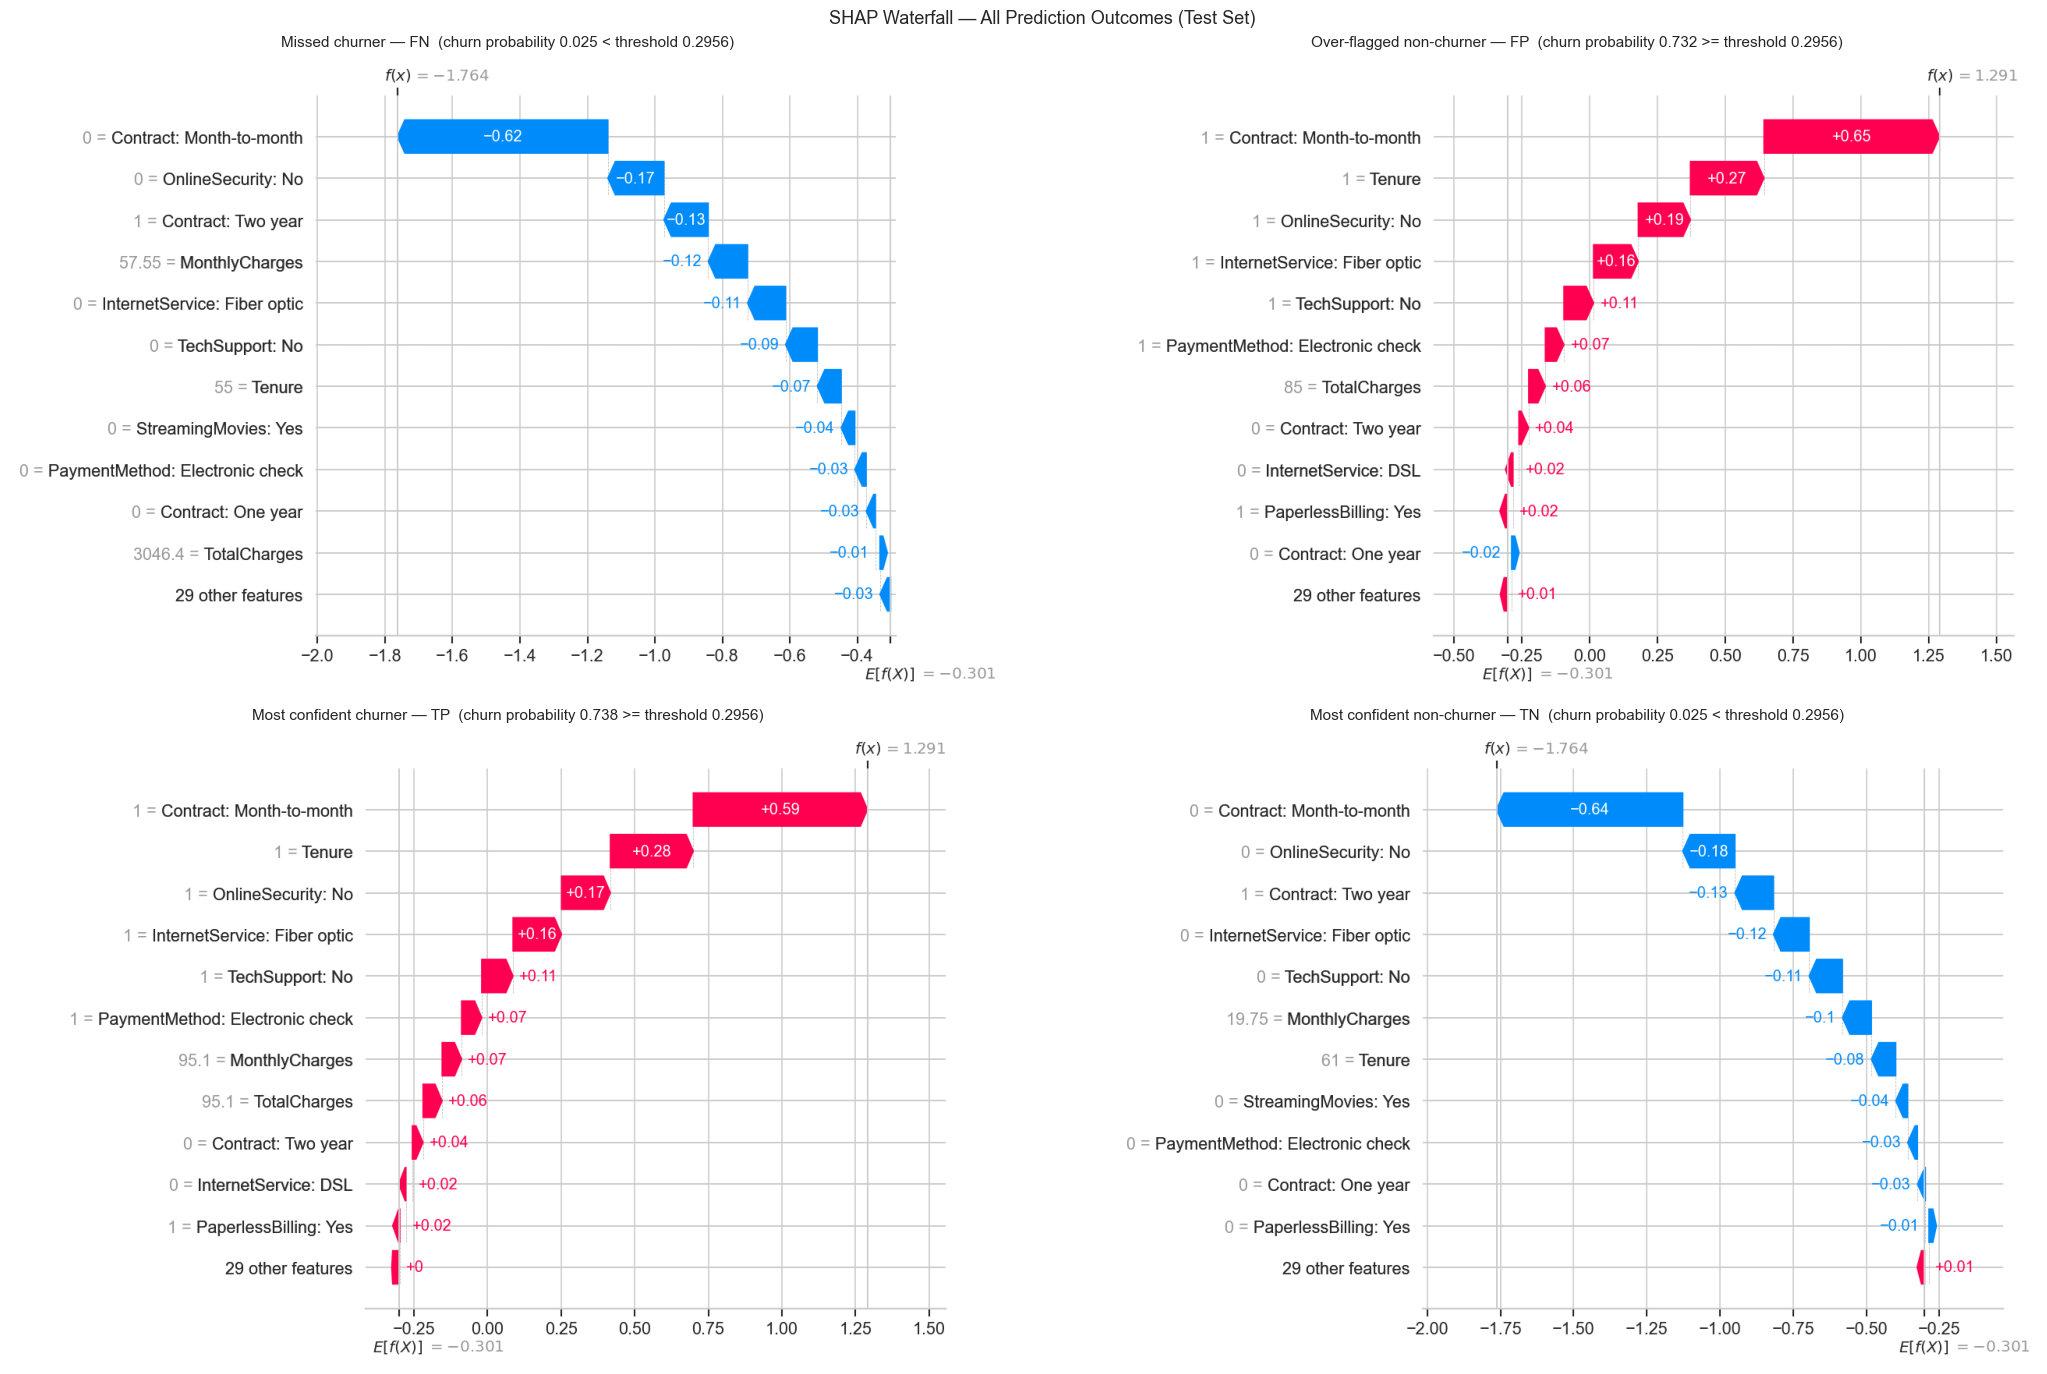

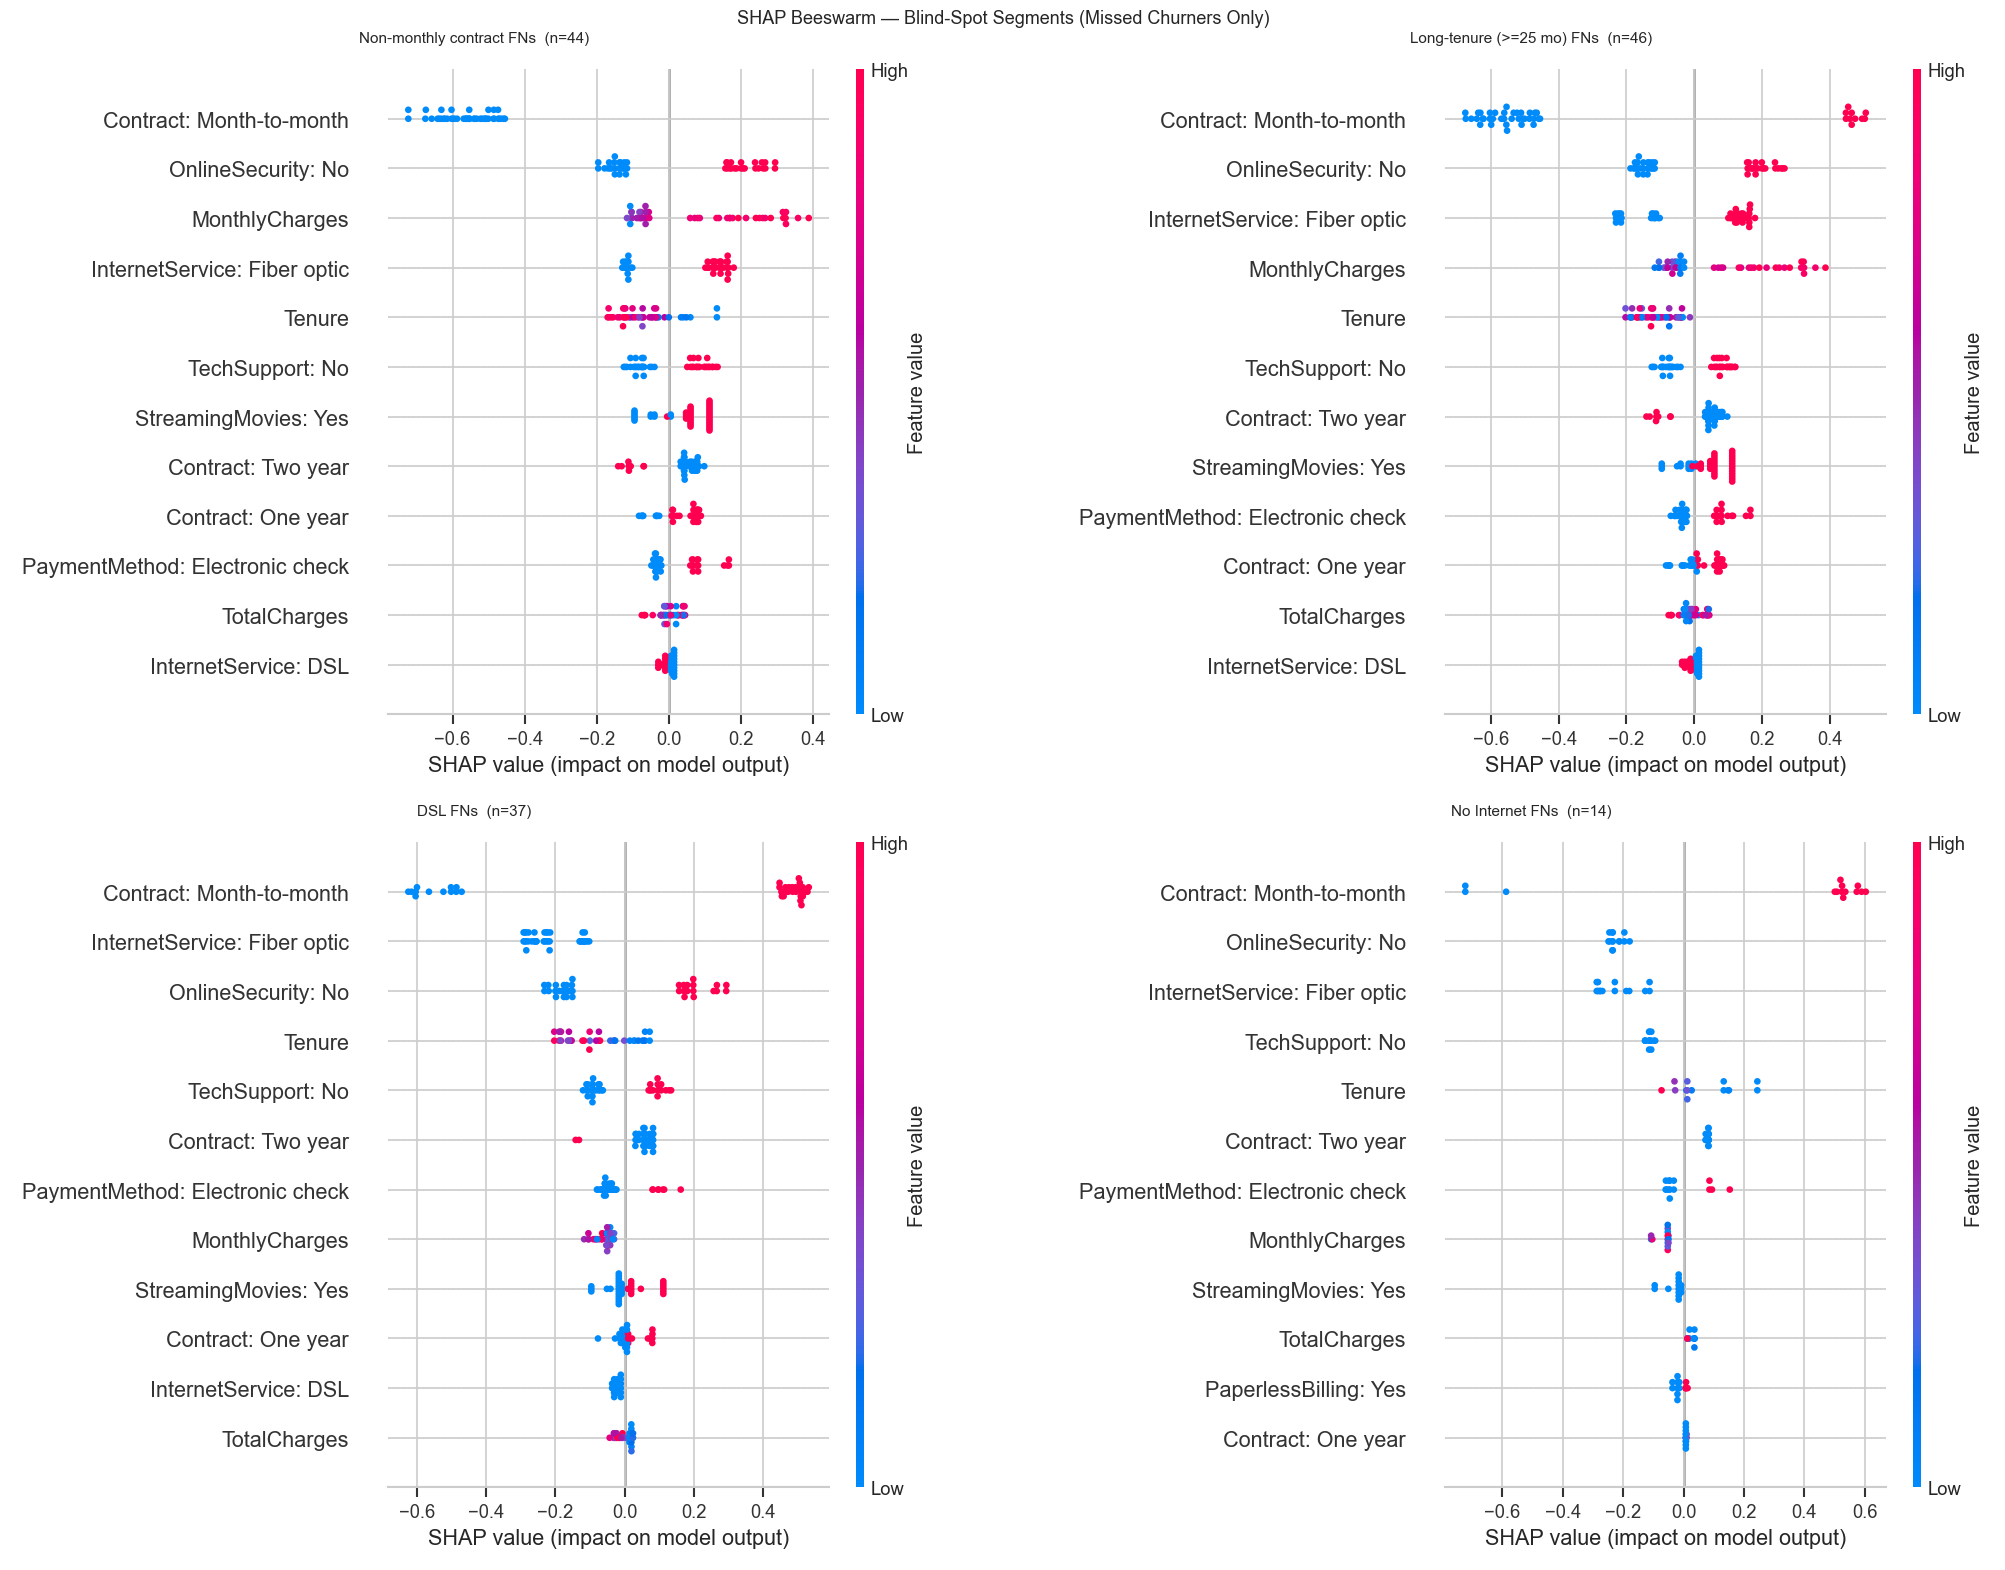

Protected attribute SHAP check (test set):
  Feature                         Mean |SHAP|      Rank
  Gender: Male                         0.0000  #23 of 40
  Partner: Yes                         0.0000  #21 of 40
  SeniorCitizen                        0.0000  #40 of 40

  Mean |SHAP| across all 40 features: 0.0378
  Protected attributes should be well below this to confirm no material influence.
SHAP figures + protected attribute metrics logged to cal_pipe run  (run_id=971c9002…)


In [55]:
import shap

# Extract base pipeline from fold 0 (feature names identical across all folds)
_base_pipe_t  = cal_pipe.calibrated_classifiers_[0].estimator
_pre_step_t   = _base_pipe_t.named_steps['pre']
_lgbm_step_t  = _base_pipe_t.named_steps['model']
_feat_names_t = _pre_step_t.get_feature_names_out()

# ── 1. Clean feature names ────────────────────────────────────────────────────
def _clean_name(n):
    n = re.sub(r'^(onehot|numeric|binary|remainder)__', '', n)
    n = n[0].upper() + n[1:]
    return n.replace('_', ': ', 1) if '_' in n else n

_feat_names_clean = [_clean_name(n) for n in _feat_names_t]

X_test_t = _pre_step_t.transform(X_test)
X_shap_t = pd.DataFrame(X_test_t, columns=_feat_names_clean)

explainer_t = shap.TreeExplainer(_lgbm_step_t)
sv_raw_t    = explainer_t.shap_values(X_shap_t)
sv_t        = sv_raw_t[1] if isinstance(sv_raw_t, list) else sv_raw_t
base_val_t  = explainer_t.expected_value
if isinstance(base_val_t, (list, np.ndarray)):
    base_val_t = float(base_val_t[1])

print(f"SHAP base value (test set): {base_val_t:.4f}")

def _shap_img_t(plot_fn):
    plot_fn()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    plt.close('all')
    buf.seek(0)
    return plt.imread(buf)

# ── 2. Bar + Beeswarm ─────────────────────────────────────────────────────────
img_bar_t      = _shap_img_t(lambda: shap.summary_plot(sv_t, X_shap_t, plot_type='bar', max_display=15, show=False))
img_beeswarm_t = _shap_img_t(lambda: shap.summary_plot(sv_t, X_shap_t, max_display=15, show=False))

fig, axes = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={'width_ratios': [1, 1.5]})
axes[0].imshow(img_bar_t);      axes[0].axis('off')
axes[0].set_title('Mean |SHAP| — Global Feature Importance', fontsize=11)
axes[1].imshow(img_beeswarm_t); axes[1].axis('off')
axes[1].set_title('SHAP Beeswarm — Test Set', fontsize=11)
fig.suptitle(f'SHAP Feature Importance — {BEST_MODEL_NAME} (Test Set, n={len(X_test)})', fontsize=13)
fig.tight_layout()
plt.show()

if RETRAIN_BEST or LOG_ARTIFACTS:
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_figure(fig, "shap_summary.png")
plt.close(fig)

# ── 3. Waterfall plots — all prediction outcomes ──────────────
_y_true_t = y_test.values
_y_pred_t = (proba_test >= PROD_THRESHOLD).astype(int)

_fn_mask = (_y_true_t == 1) & (_y_pred_t == 0)
_fn_idx  = int(np.where(_fn_mask, proba_test, np.inf).argmin())

_fp_mask = (_y_true_t == 0) & (_y_pred_t == 1)
_fp_idx  = int(np.where(_fp_mask, proba_test, -np.inf).argmax())

_tp_mask = (_y_true_t == 1) & (_y_pred_t == 1)
_tp_idx  = int(np.where(_tp_mask, proba_test, -np.inf).argmax())

_tn_mask = (_y_true_t == 0) & (_y_pred_t == 0)
_tn_idx  = int(np.where(_tn_mask, proba_test, np.inf).argmin())

def _waterfall_img_t(idx):
    exp = shap.Explanation(
        values=sv_t[idx],
        base_values=base_val_t,
        data=X_shap_t.iloc[idx].values,
        feature_names=_feat_names_clean,
    )
    shap.plots.waterfall(exp, max_display=12, show=False)
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    plt.close('all')
    buf.seek(0)
    return plt.imread(buf)

img_fn = _waterfall_img_t(_fn_idx)
img_fp = _waterfall_img_t(_fp_idx)
img_tp = _waterfall_img_t(_tp_idx)
img_tn = _waterfall_img_t(_tn_idx)

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes[0, 0].imshow(img_fn); axes[0, 0].axis('off')
axes[0, 0].set_title(
    f'Missed churner — FN  (churn probability {proba_test[_fn_idx]:.3f} < threshold {PROD_THRESHOLD:.4f})',
    fontsize=11, pad=8)
axes[0, 1].imshow(img_fp); axes[0, 1].axis('off')
axes[0, 1].set_title(
    f'Over-flagged non-churner — FP  (churn probability {proba_test[_fp_idx]:.3f} >= threshold {PROD_THRESHOLD:.4f})',
    fontsize=11, pad=8)
axes[1, 0].imshow(img_tp); axes[1, 0].axis('off')
axes[1, 0].set_title(
    f'Most confident churner — TP  (churn probability {proba_test[_tp_idx]:.3f} >= threshold {PROD_THRESHOLD:.4f})',
    fontsize=11, pad=8)
axes[1, 1].imshow(img_tn); axes[1, 1].axis('off')
axes[1, 1].set_title(
    f'Most confident non-churner — TN  (churn probability {proba_test[_tn_idx]:.3f} < threshold {PROD_THRESHOLD:.4f})',
    fontsize=11, pad=8)
fig.suptitle('SHAP Waterfall — All Prediction Outcomes (Test Set)', fontsize=13)
fig.tight_layout()
plt.show()

if RETRAIN_BEST or LOG_ARTIFACTS:
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_figure(fig, "shap_waterfall.png")
plt.close(fig)

# ── 4. Blind-spot segment beeswarm ───────────────────────────────────────────
_contract_vals  = X_test['Contract'].values
_tenure_vals    = X_test['tenure'].values
_internet_vals  = X_test['InternetService'].values

_annual_fn_mask = (
    (_y_true_t == 1) & (_y_pred_t == 0) &
    ((_contract_vals == 'One year') | (_contract_vals == 'Two year'))
)
_longte_fn_mask = (_y_true_t == 1) & (_y_pred_t == 0) & (_tenure_vals >= 25)
_dsl_fn_mask    = (_y_true_t == 1) & (_y_pred_t == 0) & (_internet_vals == 'DSL')
_noint_fn_mask  = (_y_true_t == 1) & (_y_pred_t == 0) & (_internet_vals == 'No')

_seg_configs = [
    (_annual_fn_mask, f'Non-monthly contract FNs  (n={_annual_fn_mask.sum()})'),
    (_longte_fn_mask, f'Long-tenure (>=25 mo) FNs  (n={_longte_fn_mask.sum()})'),
    (_dsl_fn_mask,   f'DSL FNs  (n={_dsl_fn_mask.sum()})'),
    (_noint_fn_mask, f'No Internet FNs  (n={_noint_fn_mask.sum()})'),
]

# Collect images BEFORE creating the display figure — _shap_img_t calls
# plt.close('all') which would kill a figure created before the loop
_seg_imgs = []
for mask, title in _seg_configs:
    _sv_seg = sv_t[mask]
    _X_seg  = X_shap_t[mask].reset_index(drop=True)
    _seg_imgs.append((
        _shap_img_t(lambda sv=_sv_seg, X=_X_seg: shap.summary_plot(sv, X, max_display=12, show=False)),
        title,
    ))

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.flatten()
for ax, (img_seg, title) in zip(axes, _seg_imgs, strict=False):
    ax.imshow(img_seg); ax.axis('off')
    ax.set_title(title, fontsize=11)

fig.suptitle('SHAP Beeswarm — Blind-Spot Segments (Missed Churners Only)', fontsize=13)
fig.tight_layout()
plt.show()

if RETRAIN_BEST or LOG_ARTIFACTS:
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        mlflow.log_figure(fig, "shap_blindspot_segments.png")
plt.close(fig)

# ── 5. Protected attribute check ──────────────────────────────────────────────
_mean_abs_t = pd.Series(np.abs(sv_t).mean(axis=0), index=_feat_names_clean)
_ranked_idx = _mean_abs_t.sort_values(ascending=False).index.tolist()
_protected  = [n for n in _feat_names_clean
               if any(k in n.lower() for k in ('gender', 'senior', 'partner'))]

print('Protected attribute SHAP check (test set):')
print(f"  {'Feature':<30} {'Mean |SHAP|':>12}  {'Rank':>8}")
for feat in _protected:
    rank = _ranked_idx.index(feat) + 1
    print(f"  {feat:<30} {_mean_abs_t[feat]:>12.4f}  #{rank} of {len(_feat_names_clean)}")
print(f"\n  Mean |SHAP| across all {len(_feat_names_clean)} features: {_mean_abs_t.mean():.4f}")
print("  Protected attributes should be well below this to confirm no material influence.")

# ── Log protected attribute SHAP metrics to cal_pipe run ────────────────────
# Scalar mean |SHAP| per protected attribute — enables cross-version fairness comparison.
if RETRAIN_BEST or LOG_ARTIFACTS:
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    with mlflow.start_run(run_id=CAL_RUN_ID):
        for _feat in _protected:
            _mkey = "shap_protected_" + re.sub(r"[^a-z0-9]", "_", _feat.lower()).strip("_")
            mlflow.log_metric(_mkey, float(_mean_abs_t[_feat]))
    print(f"SHAP figures + protected attribute metrics logged to cal_pipe run  (run_id={CAL_RUN_ID[:8]}…)")

**Observations — §16.5 Explainability**

**Global ranking — consistency with §13**
- The top-10 ranking on the test set is identical to §13's validation-set ranking: `Contract: Month-to-month` (#1), `OnlineSecurity: No` (#2), `InternetService: Fiber optic` (#3), `Tenure` (#4), `TechSupport: No` (#5), `MonthlyCharges` (#6), `PaymentMethod: Electronic check` (#7), `Contract: Two year` (#8), `StreamingMovies: Yes` (#9), `TotalCharges` (#10). Zero rank shifts across the top 10 — no feature inconsistency between training and production pipelines.
- `Contract: Month-to-month` dominates at mean |SHAP| ~0.57, roughly 3x the next feature. All beeswarm directions mirror §13.

**Waterfall — missed churner (FN, churn probability 0.025)**
- Every feature points left — three suppressors stack to drive the churn probability down. `Contract: Month-to-month = 0` (-0.62) and `Contract: Two year = 1` (-0.13) translate a long-term contract into the model's strongest loyalty signal. `Tenure = 55` months (-0.07) reads as embedded loyalty rather than a lagging indicator of disengagement. The absence of fiber optic removes the model's top churn risk signal entirely. All three blind spots are active simultaneously — annual contract, long tenure, and non-fiber internet — compounding into a churn probability the model has no mechanism to push above threshold.

**Waterfall — over-flagged non-churner (FP, churn probability 0.732)**
- Every feature except `Contract: One year` drives the churn probability up. `Contract: Month-to-month = 1` (+0.65) dominates, compounded by 1 month of tenure (+0.27), `OnlineSecurity: No` (+0.19), `InternetService: Fiber optic` (+0.16), and `TechSupport: No` (+0.11) — every risk factor the model has learned, active simultaneously. The model is not wrong to flag this profile; the FP arises because within it a minority of customers stay, and no available feature separates them from those who leave.

**Waterfall — most confident churner (TP, churn probability 0.738)**
- Every top feature points right, assembling the same high-risk profile as the FP case. `Contract: Month-to-month = 1` dominates (+0.59), compounded by very short tenure (+0.38), `OnlineSecurity: No` (+0.11), `InternetService: Fiber optic` (+0.09), and `TechSupport: No` (+0.07). The feature pattern is near-identical to the FP above — both are new month-to-month fiber subscribers with no add-on services. The model correctly flags this customer; the TP and FP are distinguishable only by ground truth, not by any feature the model has access to.

**Waterfall — most confident non-churner (TN, churn probability 0.020)**
- Every feature points left — the same suppressor stack as the FN above, now applied to a customer who genuinely stays. `Contract: Two year = 1` dominates, translating a long-term commitment into the model's strongest loyalty signal. Long tenure compounds it, read as embedded loyalty reinforcing the contract signal. The absence of fiber optic removes the model's primary churn risk signal entirely. The profile is near-identical to the FN missed churner — long contract, long tenure, non-fiber internet — and the model reaches the same low churn score. The difference is ground truth: here the customer is not churning, so the suppressors are working as intended. The same mechanism that creates the FN blind spot produces the correct answer when the customer's intent aligns with what the features signal.

**Blind-spot segment beeswarm**

*Non-monthly contract FNs (n=44):*
- `Contract: Month-to-month = 0` (all blue, far left) dominates for all 44 customers — the model has learned that non-monthly contracts overwhelmingly predict loyalty, so it assigns a large negative SHAP that pushes the churn probability far below the 0.35 threshold. The segment contains more One-year than Two-year customers (visible from the larger number of red dots in the `Contract: One year` row). **Two-year customers** are maximally suppressed: `Contract: Two year = 1` (red, far left) adds a second large negative push — the model treats a two-year commitment as strong evidence of loyalty, with no offsetting signal. **One-year customers** tell a different story: `Contract: One year = 1` (red, slightly right of zero) gives a small positive SHAP — the model reads a one-year contract as slightly riskier than two-year, nudging the score marginally toward churn. `Contract: Two year = 0` (blue, also slightly right in that row) adds a second small positive nudge. These small positive pushes partially offset the dominant suppression but fall far short of crossing the threshold. The blind spot: all 44 customers genuinely churn, yet `Month-to-month = 0` is strong enough to override every other risk signal the model has access to. The model is not wrong in general — non-monthly contracts do predict loyalty most of the time — but it cannot see past the contractual signal to identify the minority who hold a non-monthly contract and churn anyway.

*Long-tenure (≥25 mo) FNs (n=46):*
- **Contract: Month-to-month** remains the dominant feature. The blue cluster (far left, ~-0.6) is larger than the red — most long-tenure FNs also hold non-monthly contracts, meaning the same contractual suppressor from the left panel is active here too, now compounded by long tenure. The smaller red cluster (far right, ~+0.3) represents month-to-month customers whose M2M signal promotes churn but is not enough to cross the threshold. Tenure dots cluster left for all 46 customers with both colours indistinguishable — the suppression is consistent across the segment but the colour mixing makes it hard to isolate tenure's individual contribution. Other risk signals — `OnlineSecurity: No`, `InternetService: Fiber optic`, high `MonthlyCharges` — are visible to the right in both sub-groups but too weak to overcome the dominant suppressors. The blind spot here is partly the same as the left panel: contractual commitment vetoes the prediction; long tenure compounds it.

*DSL FNs (n=37):*
- `Contract: Month-to-month` splits this segment into the same bimodal pattern as the top panels. The DSL-specific suppressor is `InternetService: Fiber optic`: all 37 customers have DSL so Fiber optic = 0 for all of them, producing a uniform cluster of blue dots far left. The model learned fiber optic as its primary churn signal — the absence of fiber is treated as active evidence of lower risk, pushing the score down regardless of other features. Most other features scatter near zero, though `OnlineSecurity`, `TechSupport`, and `MonthlyCharges` show modest but non-negligible contributions away from zero. The blind spot: DSL customers are suppressed by the model's strong negative SHAP for Fiber optic = 0 — the model has no mechanism to detect churn risk in customers who lack the feature it most associates with risk.

*No Internet FNs (n=14):*
- No Internet customers have no internet service at all, so every internet-related feature is zero for all 14 simultaneously: `InternetService: Fiber optic = 0` gives a large negative SHAP (the model's strongest churn signal is absent); `OnlineSecurity` and `TechSupport` are encoded as 0 because their value is "No internet service" rather than "No" — each adds another negative push; streaming features likewise. Every missing internet feature is treated by the model as active evidence of lower churn risk, so they all suppress the score at once. `Contract: Month-to-month` is still bimodal — the monthly vs. non-monthly split is still visible — but the stacked suppressors overwhelm it. DSL customers are held down by one missing feature (fiber optic = 0); No Internet customers accumulate several at once. The suppression is structural: the model's churn-risk signals are all internet-related, and No Internet customers can never activate them — so even genuine behavioral signals like a month-to-month contract or electronic check payment are buried by the accumulated negative SHAPs, and the model cannot score them above threshold regardless of their behavior.

**Protected attribute check**
- All three protected attributes contribute zero marginal signal at the individual prediction level. The model's churn scores are driven entirely by behavioural and contractual features, not demographic proxies. Safe to document in the model card as non-influential.

## Limitations and Next Steps

- **Uplift modelling:** the model identifies *who will churn*, not *who will respond to intervention*. Uplift modelling — requiring A/B test data (treated vs untreated groups) — separates 'persuadables' from 'lost causes' and 'sure things', and is the natural next step to sharpen the business case.
- **Re-contact suppression:** customers flagged in one cycle should be suppressed for ~90 days to avoid intervention fatigue.
- **Production monitoring:** these figures will drift as the customer base and churn dynamics evolve. Schedule periodic model re-evaluation.

### 17.1 Full-Data Production Refit

Retraining on the complete dataset (train + val + test) gives the production model all
available signal. All evaluation decisions were finalised on held-out data, so there is
no leakage risk: metrics reported in §16 came from the sealed test set and are unaffected
by what is trained here.

Two steps before registering:

1. Retrain + recalibrate on `X_full` with the same hyperparameters found in §10.7.
2. Re-derive the production threshold via OOF cost minimisation on `X_full` — the
   threshold from §14.3 was found on `X_train` only and should be rechecked on the
   fuller distribution.

**Prerequisite:** §16.1 must have run so `add_features()` has already been applied to
`X_test`.

Set `RETRAIN_FULL = True` on first run; flip back to `False` to reload the saved artifact.

In [56]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict

RETRAIN_FULL = False  # set True once to train; flip back to load from MLflow
if RETRAIN_BEST:
    RETRAIN_FULL = True  # new best model was trained -> full refit must follow

if RETRAIN_FULL:
    # ── 1. Guard: X_test must already have engineered features (applied in §16.1) ──
    if callable(globals().get('add_features')) and globals().get('ADOPT_ENG', False):
        if 'is_long_month_to_month' not in X_test.columns:
            raise RuntimeError(
                'Run §16.1 before §17.1 so that add_features() is applied to X_test.'
            )

    # ── 2. Assemble full dataset ──────────────────────────────────────────────
    X_full = pd.concat([X_train, X_val, X_test]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val, y_test]).reset_index(drop=True)
    print(f'Full dataset: {X_full.shape[0]} rows  '
          f'({int(y_full.sum())} churners, {int((y_full == 0).sum())} non-churners)')

    # ── 3. Rebuild pipeline — same hyperparams, scale_pos_weight on full data ──
    _spw_full = float((y_full == 0).sum() / (y_full == 1).sum())
    if BEST_MODEL_NAME == 'XGBoost':
        _full_params = {**best_params, 'scale_pos_weight': _spw_full}
        _model_for_cal = XGBClassifier(**_full_params)
    elif BEST_MODEL_NAME == 'LightGBM':
        _full_params = best_params.copy()
        _model_for_cal = LGBMClassifier(**_full_params)
    else:
        _full_params = best_params.copy()
        _model_for_cal = RandomForestClassifier(**_full_params)

    # ── 4. Fit calibrated pipeline on full data ───────────────────────────────
    print('Fitting calibrated pipeline on full dataset ...')
    cal_pipe_full = CalibratedClassifierCV(
        Pipeline([('pre', clone(preprocessor)), ('model', _model_for_cal)]),
        method='sigmoid', cv=5,
    )
    cal_pipe_full.fit(X_full, y_full)
    print('  Done.')

    # ── 5. Re-derive OOF threshold on full data ───────────────────────────────
    # cross_val_predict needs an unfitted estimator — build a fresh one.
    if BEST_MODEL_NAME == 'XGBoost':
        _model_oof = XGBClassifier(**_full_params)
    elif BEST_MODEL_NAME == 'LightGBM':
        _model_oof = LGBMClassifier(**_full_params)
    else:
        _model_oof = RandomForestClassifier(**_full_params)

    _pipe_oof = CalibratedClassifierCV(
        Pipeline([('pre', clone(preprocessor)), ('model', _model_oof)]),
        method='sigmoid', cv=5,
    )
    print('Running OOF cross_val_predict on full dataset (5-fold outer x 5-fold cal) ...')
    oof_proba_full = cross_val_predict(
        _pipe_oof, X_full, y_full,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        method='predict_proba', n_jobs=-1,
    )[:, 1]
    print('  Done.')

    y_full_np = y_full.values
    _, _s_ltv, _s_ret, _s_cost = next(s for s in SCENARIOS if s[0] == THRESHOLD_SCENARIO)
    _oof_costs_full = []
    for _t in thresholds_cs:
        _pred = (oof_proba_full >= _t).astype(int)
        _tn, _fp, _fn, _tp = confusion_matrix(y_full_np, _pred).ravel()
        _oof_costs_full.append(_fp * _s_cost + _fn * _s_ret * _s_ltv)

    prod_threshold_full = float(thresholds_cs[np.argmin(_oof_costs_full)])
    print(f'\n  Train-set prod_threshold : {prod_threshold:.4f}')
    print(f'  Full-data prod_threshold : {prod_threshold_full:.4f}')

    # ── 6. Save to MLflow ─────────────────────────────────────────────────────
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    mlflow.set_experiment('Telco Churn - Final Model')
    with mlflow.start_run(run_name=f'{BEST_MODEL_NAME}_full_refit') as _full_run:
        FULL_PIPE_RUN_ID = _full_run.info.run_id
        mlflow.set_tag('artifact_type', 'full_refit')
        mlflow.log_params({
            'dataset':             'train+val+test',
            'n_rows_full':         len(X_full),
            'prod_threshold_full': round(prod_threshold_full, 4),
            'calibration_method':  'sigmoid',
            'calibration_cv':      5,
            'evaluated_run_id':    CAL_RUN_ID,  # traceability: cal_pipe run evaluated on sealed test set
        })
        mlflow.sklearn.log_model(cal_pipe_full, artifact_path='cal_pipeline_full')
    print(f'\nFull refit saved  ->  FULL_PIPE_RUN_ID = "{FULL_PIPE_RUN_ID}"')
    print('Set RETRAIN_FULL = False to load this artifact on future runs.')

else:
    # ── Load saved full refit from MLflow ─────────────────────────────────────
    mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
    _full_runs = mlflow.search_runs(
        experiment_names=['Telco Churn - Final Model'],
        filter_string="tags.artifact_type = 'full_refit'",
        order_by=['start_time DESC'],
    )
    if _full_runs.empty:
        raise RuntimeError(
            'No full refit found in MLflow.\n'
            'Set RETRAIN_FULL = True and re-run this cell to train and save.'
        )
    FULL_PIPE_RUN_ID    = _full_runs.iloc[0]['run_id']
    cal_pipe_full       = mlflow.sklearn.load_model(f'runs:/{FULL_PIPE_RUN_ID}/cal_pipeline_full')
    prod_threshold_full = float(_full_runs.iloc[0].get('params.prod_threshold_full', prod_threshold))
    print(f'Loaded full refit from MLflow run {FULL_PIPE_RUN_ID[:8]}')
    print(f'  prod_threshold_full = {prod_threshold_full:.4f}')


Loaded full refit from MLflow run f81665fa
  prod_threshold_full = 0.3596


### 17.2 Register Final Model

Logs the full-data `cal_pipe_full`, preprocessing artifacts, OOF metrics, and production threshold to the MLflow Model Registry. The registered version is staged to `Staging`; a smoke test on 3 rows confirms correct serialisation.

Set `REGISTER_FINAL = True` to execute; leave `False` to skip on subsequent runs.

In [57]:
import json as _json_mod
import os
import pickle
import tempfile

REGISTER_FINAL = False  # set True to log and register; leave False to skip
if RETRAIN_FULL:
    REGISTER_FINAL = True

if REGISTER_FINAL:
    # ── Extract feature columns and preprocessor ───────────────────────────────
    _base_pipe      = cal_pipe_full.calibrated_classifiers_[0].estimator
    _fitted_pre     = _base_pipe.named_steps['pre']
    feature_columns = list(_fitted_pre.get_feature_names_out())

    # ── Pin environment from requirements.txt ─────────────────────────────────
    _req_file = MLRUNS_PATH.parent / 'requirements.txt'
    with open(_req_file) as _f:
        _pip_reqs = [l.strip() for l in _f if l.strip() and not l.startswith('#')]

    with tempfile.TemporaryDirectory() as _tmpdir:
        _fc_path  = os.path.join(_tmpdir, 'feature_columns.txt')
        _pre_path = os.path.join(_tmpdir, 'preprocessing.pkl')
        _mc_path  = os.path.join(_tmpdir, 'model_card.json')

        with open(_fc_path, 'w') as _f:
            _f.write('\n'.join(feature_columns))
        with open(_pre_path, 'wb') as _f:
            pickle.dump(_fitted_pre, _f)

        mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
        mlflow.set_experiment('Telco Churn - Final Model')

        with mlflow.start_run(run_name=f'{BEST_MODEL_NAME}_prod_registered') as reg_run:
            mlflow.log_params({
                'base_model':         BEST_MODEL_NAME,
                'calibration_method': 'sigmoid',
                'calibration_cv':     5,
                'dataset':            'train+val+test',
                'prod_threshold':     round(prod_threshold_full, 4),
                'evaluated_run_id':   CAL_RUN_ID,
            })

            # ── OOF metrics ───────────────────────────────────────────────────
            _oof_p       = globals().get('oof_proba_full')
            _y_fnp       = globals().get('y_full_np')
            _new_oof_rec = None
            _new_oof_ap  = None
            if _oof_p is not None and _y_fnp is not None:
                _pred_full   = (_oof_p >= prod_threshold_full).astype(int)
                _new_oof_rec = float(recall_score(_y_fnp, _pred_full, zero_division=0))
                _new_oof_ap  = float(average_precision_score(_y_fnp, _oof_p))
                mlflow.log_metrics({
                    'oof_recall':      _new_oof_rec,
                    'oof_precision':   float(precision_score(_y_fnp, _pred_full, zero_division=0)),
                    'oof_f1':          float(f1_score(_y_fnp, _pred_full, zero_division=0)),
                    'oof_avg_prec':    _new_oof_ap,
                    'n_rows_full':     float(len(_y_fnp)),
                    'churn_rate_full': float(_y_fnp.mean()),
                    'n_features':      float(len(feature_columns)),
                })

            # ── Log model with signature, input example, pinned environment ───
            _sig = mlflow.models.infer_signature(
                X_full.iloc[:5],
                cal_pipe_full.predict_proba(X_full.iloc[:5]),
            )
            # Dataset lineage — MLflow 2.4+; skipped gracefully on older versions
            try:
                _ds = mlflow.data.from_pandas(
                    pd.concat([X_full, y_full.rename("Churn")], axis=1),
                    name="telco-churn-full",
                    targets="Churn",
                )
                mlflow.log_input(_ds, context="training")
            except Exception:
                pass  # mlflow.data not available in this MLflow version
            model_info = mlflow.sklearn.log_model(
                cal_pipe_full,
                artifact_path='calibrated_pipeline',
                registered_model_name='telco-churn-pipeline',
                signature=_sig,
                input_example=X_full.iloc[:3],
                pip_requirements=_pip_reqs,
            )

            # _new_ver is now known — build model card here so 'version' is valid
            _new_ver    = model_info.registered_model_version

            # ── Resolve selected threshold scenario for model card ─────────────
            _sel_s    = next(s for s in SCENARIOS if s[0] == THRESHOLD_SCENARIO)
            _sel_ltv  = _sel_s[1]
            _sel_ret  = _sel_s[2]
            _sel_cost = _sel_s[3]

            _model_card = {
                # ── Identity ──────────────────────────────────────────────────
                'model_name':    'telco-churn-pipeline',
                'version':       _new_ver,
                'model_type':    f'CalibratedClassifierCV({BEST_MODEL_NAME}, sigmoid, cv=5) wrapped in sklearn Pipeline',
                'owner':         'frimpongrichlove@gmail.com',
                'training_date': str(__import__('datetime').date.today()),

                # ── Use ───────────────────────────────────────────────────────
                'intended_use': (
                    'Monthly batch scoring of telecom customers for churn risk; '
                    'output used to prioritise retention outreach.'
                ),
                'out_of_scope_use': [
                    'Real-time decisioning with latency SLA < 100 ms.',
                    'Automated cancellation or penalty without human review.',
                    'Customer segments outside the IBM Telco dataset distribution '
                    '(e.g., enterprise accounts, wholesale, IoT-only subscribers).',
                ],

                # ── Data ──────────────────────────────────────────────────────
                'training_data': {
                    'source':     'IBM Telco Customer Churn (public)',
                    'n_rows':     int(len(X_full)),
                    'split':      'train+val+test combined after sealed-test evaluation',
                    'label':      'Churn (Yes=1 / No=0); base rate ~26.5 %',
                    'date_range': 'Static snapshot — no temporal information in dataset',
                },
                'evaluation_data': {
                    'method':        'Stratified hold-out (20 %) sealed before any modelling',
                    'n_rows':        int(len(y_test)),
                    'evaluated_run': CAL_RUN_ID,
                },

                # ── Performance ───────────────────────────────────────────────
                'evaluation': {
                    'test_recall':        round(float(test_recall),    4),
                    'test_precision':     round(float(test_precision), 4),
                    'test_f1':            round(float(test_f1),        4),
                    'test_avg_precision': round(float(test_avg_prec),  4),
                    'ks_statistic':       round(float(ks_stat_test),   4),
                    'test_roc_auc':       round(float(test_auc),       4),
                    'test_bss':           round(float(bss_t),          4),
                    'threshold':          round(float(prod_threshold_full), 4),
                    'threshold_method': (
                        f'OOF cost-minimisation — {THRESHOLD_SCENARIO} scenario: '
                        f'FN cost = {_sel_ret:.0%} retention x ${_sel_ltv} LTV '
                        f'= ${_sel_ret * _sel_ltv:.0f}; '
                        f'FP cost = ${_sel_cost} intervention; '
                        f'FN/FP ratio = {_sel_ret * _sel_ltv / _sel_cost:.2f}:1. '
                        'LTV derived from training-set churner ARPU x 60% margin x 12 months.'
                    ),
                    'calibration':        'sigmoid_cv5 — probabilities are calibrated; safe for ranking and EV calculations',
                },

                # ── Input schema ──────────────────────────────────────────────
                'input_schema': {
                    'n_features': len(feature_columns),
                    'key_features': [
                        {'name': 'tenure',          'type': 'int',   'range': '0-72 months'},
                        {'name': 'MonthlyCharges',  'type': 'float', 'range': '18-120 USD'},
                        {'name': 'TotalCharges',    'type': 'float', 'range': '0-8700 USD'},
                        {'name': 'Contract',        'type': 'str',   'values': 'Month-to-month | One year | Two year'},
                        {'name': 'InternetService', 'type': 'str',   'values': 'DSL | Fiber optic | No'},
                        {'name': 'PaymentMethod',   'type': 'str',   'values': 'Electronic check | Mailed check | Bank transfer | Credit card'},
                    ],
                    'full_feature_list': 'See artifacts/feature_columns.txt',
                },

                # ── Business performance ────────────────────────────────────────────
                'business_performance': {
                    'confusion_matrix_at_threshold': {
                        'TP':        int(tp_p),
                        'FP':        int(fp_p),
                        'FN':        int(fn_p),
                        'TN':        int(tn_p),
                        'n_flagged': int(n_contacted),
                        'n_test':    int(n_test),
                    },
                    'vs_random_at_same_budget': {
                        'incremental_churners_caught': int(incremental_churners_t),
                        'lift':                        round(float(tp_p / n_contacted / base_churnrate_t), 3),
                    },
                    'monetary_impact': {
                        'scenario':                 THRESHOLD_SCENARIO,
                        'test_net_pnl_usd':         int(round(float(model_net_t),    0)),
                        'pnl_uplift_vs_random_usd': int(round(float(value_uplift_t), 0)),
                        'annualised_net_pnl_usd':   int(round(float(model_net_t) * (TOTAL_CUSTOMERS_LIVE / n_test) * SCORING_CYCLES_YR, 0)),
                        'assumptions': {
                            'ltv_usd':              _sel_ltv,
                            'retention_rate':        round(_sel_ret, 2),
                            'intervention_cost_usd': _sel_cost,
                            'total_customers_live':  TOTAL_CUSTOMERS_LIVE,
                            'scoring_cycles_yr':     SCORING_CYCLES_YR,
                        },
                    },
                },

                # ── Limitations ───────────────────────────────────────────────
                'known_limitations': [
                    'Annual/multi-year contract churners: near-total blind spot (FN rate 0.97-1.00)',
                    'Long-tenure (25+ months) segment: FN rate 0.465',
                    'No uplift modelling — identifies churn risk, not retention persuadability',
                    'No re-contact suppression built in',
                    'Static dataset — no temporal drift detection; staleness threshold: 6 months',
                ],

                # ── Fairness ──────────────────────────────────────────────────
                'fairness': {
                    'gender_shap_rank':         '23 of 40 (mean |SHAP| ~0)',
                    'senior_citizen_shap_rank': '40 of 40 (mean |SHAP| ~0)',
                    'assessment':               'Predictions driven by behavioural/contractual features only',
                    'method':                   'SHAP feature importance ranking on sealed test set',
                },

                # ── Production guidance ───────────────────────────────────────
                'monitoring': {
                    'recommended_signals': [
                        'PSI on tenure, MonthlyCharges, Contract (flag if PSI > 0.2)',
                        'Predicted churn rate (flag if drift > \u00b15 pp from training base rate)',
                        'Recall on labelled feedback loop (flag if < 0.60)',
                        'Brier skill score (BSS) on labelled feedback loop (flag if BSS < 0.20)',
                    ],
                    'refresh_cadence': 'Retrain if any monitoring flag triggers, or after 6 months without a flag',
                },
                'contact': 'frimpongrichlove@gmail.com',
            }
            with open(_mc_path, 'w') as _f:
                _json_mod.dump(_model_card, _f, indent=2)

            mlflow.log_artifact(_fc_path,  artifact_path='artifacts')
            mlflow.log_artifact(_pre_path, artifact_path='artifacts')
            mlflow.log_artifact(_mc_path,  artifact_path='artifacts')
            _reg_run_id = reg_run.info.run_id  # capture before with-block exits

    # ── Registry metadata: description + tags ─────────────────────────────────
    client = mlflow.MlflowClient()

    client.update_model_version(
        name='telco-churn-pipeline',
        version=_new_ver,
        description=(
            f"Full-data production refit. Evaluated on sealed test set "
            f"(run {CAL_RUN_ID}): recall={test_recall:.4f}, "
            f"precision={test_precision:.4f}, BSS={bss_t:.4f}. "
            f"Threshold {prod_threshold_full:.4f} (OOF cost-minimised)."
        ),
    )
    client.update_registered_model(
        name='telco-churn-pipeline',
        description=(
            "Monthly batch churn scorer for telecom customers. "
            f"Base model: {BEST_MODEL_NAME} wrapped in CalibratedClassifierCV (sigmoid, cv=5). "
            "Trained on IBM Telco dataset (public). "
            "Owner: frimpongrichlove@gmail.com"
        ),
    )

    _tags = [
        ('production_threshold', str(round(prod_threshold_full, 4))),
        ('calibration',          'sigmoid_cv5'),
        ('training_data',        'train+val+test'),
        ('evaluated_run_id',     CAL_RUN_ID),
        ('test_recall',          f'{test_recall:.4f}'),
        ('test_precision',      f'{test_precision:.4f}'),
        ('test_bss',             f'{bss_t:.4f}'),
    ]
    if _new_oof_rec is not None:
        _tags.append(('oof_avg_prec', f'{_new_oof_ap:.4f}'))
        _tags.append(('oof_recall',   f'{_new_oof_rec:.4f}'))
    for _k, _v in _tags:
        client.set_model_version_tag('telco-churn-pipeline', _new_ver, _k, _v)

    # ── Champion / challenger gate ─────────────────────────────────────────────
    # @challenger is assigned immediately; @champion only if OOF recall does
    # not regress more than 0.005 below the current champion.
    client.set_registered_model_alias('telco-churn-pipeline', 'challenger', _new_ver)
    _champion_rec = None
    try:
        _champ_mv     = client.get_model_version_by_alias('telco-churn-pipeline', 'champion')
        _rec_str      = _champ_mv.tags.get('oof_recall')
        _champion_rec = float(_rec_str) if _rec_str else None
    except Exception:
        pass  # no champion exists yet

    _new_s   = f'{_new_oof_rec:.4f}'  if _new_oof_rec  is not None else 'n/a'
    _champ_s = f'{_champion_rec:.4f}' if _champion_rec is not None else 'none'

    if _new_oof_rec is None:
        print('WARNING: OOF recall unavailable (RETRAIN_FULL=False) — gate passed without comparison')
    if _champion_rec is None or _new_oof_rec is None or _new_oof_rec >= _champion_rec - 0.005:
        client.set_registered_model_alias('telco-churn-pipeline', 'champion', _new_ver)
        _gate = f'PASSED  — promoted to @champion  (new OOF recall {_new_s} >= champion {_champ_s})'
    else:
        _gate = f'BLOCKED — remains @challenger  (new OOF recall {_new_s} < champion {_champ_s} - 0.005 tolerance)'
        print(f'WARNING: champion gate {_gate}')

    # ── Smoke test ────────────────────────────────────────────────────────────
    _loaded = mlflow.sklearn.load_model(f'runs:/{_reg_run_id}/calibrated_pipeline')
    _       = _loaded.predict_proba(X_full.iloc[:3])
    print('Smoke test    : PASSED (model reloaded and scored 3 rows)')

    # ── Summary ───────────────────────────────────────────────────────────────
    print('Experiment    : Telco Churn - Final Model')
    print(f'Registered    : telco-churn-pipeline v{_new_ver}')
    print(f'Run ID        : {_reg_run_id}')
    print(f'Threshold     : {round(prod_threshold_full, 4)}')
    print(f'Champion gate : {_gate}')
    print(f'Evaluated run : {CAL_RUN_ID}  (§16 test metrics)')
    print(f'Test recall   : {test_recall:.4f}  |  OOF recall : {_new_s}')
    print(f'Features      : {len(feature_columns)} columns')
    print('Artifacts     : feature_columns.txt | preprocessing.pkl | model_card.json')
